## Model Loading

In [27]:
import torch
from pathlib import Path
import sys

# 루트 경로 추가 (Model, dataset 로딩 위해)
root_dir = Path('/storage/personal/eungyeop/LLM/tabular/ProtoLLM')
sys.path.append(str(root_dir))

from models.TabularFLM_S import Model
from dataset.data_dataloaders import prepare_embedding_dataloaders
from utils.util import fix_seed
from ot.batch import solve_gromov_batch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-0.3_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.01_description-XTFORMER_EVALUATION100/50/20260225_221853/best_joint.pt"
target_rr_ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Few/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-0.3_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.01_description-XTFORMER_EVALUATION100/50/20260225_221853/Embed:carte_Edge:mlp_A:gat_v1_S:50_20260225_221853.pt"

# checkpoint load
ckpt = torch.load(ckpt_path, map_location=device)
args = ckpt['args']

# 모델 초기화
model = Model(
    args,
    args.input_dim,
    args.hidden_dim,
    args.output_dim,
    args.dropout_rate,
    args.llm_model,
    experiment_id="viz",
    mode="viz"
).to(device)

sd = ckpt['model_state_dict']
missing, unexpected = model.load_state_dict(sd, strict=False)
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

model.eval()


Missing keys: []
Unexpected keys: []


Model(
  (latent_graph): LatentCompositeGraph()
  (graph_quantizer): GraphQuantizer()
  (gnn_experts): LatentCompositeGNN(
    (graph_gnns): ModuleList(
      (0-7): 8 x ModuleList(
        (0-1): 2 x lightGraphNeuralNet(
          (dropout): Dropout(p=0.1, inplace=False)
          (linear): Linear(in_features=768, out_features=192, bias=True)
          (update): Linear(in_features=192, out_features=768, bias=True)
          (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
      )
    )
    (readouts): ModuleList(
      (0-7): 8 x GraphReadout(
        (attn): Sequential(
          (0): Linear(in_features=768, out_features=192, bias=True)
          (1): Tanh()
          (2): Linear(in_features=192, out_features=1, bias=True)
        )
        (proj): Sequential(
          (0): Linear(in_features=768, out_features=192, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=192, out_features=768, bias=True)
 

In [28]:
import torch
ckpt = torch.load(ckpt_path, map_location='cpu')
print(ckpt['args'].orth_reg)

0.1


## Source Loading

In [29]:
args2 = args
fix_seed(args2.random_seed)

# source_data가 리스트일 경우 여러 개
sources = args2.source_data if isinstance(args2.source_data, (list, tuple)) else [args2.source_data]

loaders = {}
for src in sources:
    print(f"Loading dataloader for source: {src}")
    res = prepare_embedding_dataloaders(args2, src)
    tr, va, te = res['loaders']
    
    from torch.utils.data import ConcatDataset, DataLoader
    ds = ConcatDataset([tr.dataset, va.dataset, te.dataset])
    
    loaders[src] = DataLoader(ds, batch_size=32, shuffle=False)


>>> [System] Seed 50 FIXED. Deterministic algorithms ENABLED.
Loading dataloader for source: Medicaldataset
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_Medicaldataset.pkl
>>> [DataLoader] Created isolated generator with seed 50
Training data size: 791
Validation data size: 264
Test data size: 264
Loading dataloader for source: Cardiovascular_Disease_Dataset
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_Cardiovascular_Disease_Dataset.pkl
>>> [DataLoader] Created isolated generator with seed 50
Training data size: 600
Validation data size: 200
Test data size: 200
Loading dataloader for source: Heart_disease_statlog
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_Heart_disease_statlog.pkl
>>> [DataLoader] Created isolated generator with seed 50
Training data size: 162
Validation data s

In [30]:
import torch.nn.functional as F

model.eval()
src_cls = {}

with torch.no_grad():
    for src_name, loader in loaders.items():
        batch = next(iter(loader))
        batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
        
        name_embs, val_embs = [], []
        if 'cat_name_embeddings' in batch: name_embs.append(batch['cat_name_embeddings'])
        if 'num_name_embeddings' in batch: name_embs.append(batch['num_name_embeddings'])
        if 'cat_value_embeddings' in batch: val_embs.append(batch['cat_value_embeddings'])
        if 'num_prompt_embeddings' in batch: val_embs.append(batch['num_prompt_embeddings'])
        
        name = torch.cat(name_embs, dim=1)
        val = torch.cat(val_embs, dim=1)
        x = torch.cat([model.basis_cls.expand(val.size(0), 1, model.input_dim), val], dim=1)
        for l in range(model.num_basis_layers):
            norm_x = model.basis_layer_norms[l](x)
            out, _ = model.basis_layers[l](name, norm_x)
            x = x + out.reshape(x.size(0), x.size(1), model.input_dim)
        
        src_cls[src_name] = x[:, 0, :]
        print(f"{src_name}: shape={x[:, 0, :].shape}")

# Source 간 비교
keys = list(src_cls.keys())
print("\n=== Source 간 cos_sim ===")
for i in range(len(keys)):
    for j in range(i+1, len(keys)):
        cos = F.cosine_similarity(src_cls[keys[i]].mean(0, keepdim=True),
                                   src_cls[keys[j]].mean(0, keepdim=True))
        print(f"  {keys[i]} vs {keys[j]}: {cos.item():.4f}")

# Source 내 샘플 간 비교
print("\n=== Source 내 intra cos_sim ===")
for k in keys:
    feat = src_cls[k]
    sim = F.cosine_similarity(feat.unsqueeze(1), feat.unsqueeze(0), dim=2)
    mask = ~torch.eye(feat.size(0), dtype=bool, device=feat.device)
    print(f"  {k}: mean={sim[mask].mean():.4f}, min={sim[mask].min():.4f}, max={sim[mask].max():.4f}")

Medicaldataset: shape=torch.Size([32, 768])
Cardiovascular_Disease_Dataset: shape=torch.Size([32, 768])
Heart_disease_statlog: shape=torch.Size([32, 768])
Erbil_Cardiovascular_Health_Dataset: shape=torch.Size([32, 768])
cardio_SAheart: shape=torch.Size([32, 768])
heart_failure_clinical_records: shape=torch.Size([32, 768])

=== Source 간 cos_sim ===
  Medicaldataset vs Cardiovascular_Disease_Dataset: -0.5870
  Medicaldataset vs Heart_disease_statlog: 0.0682
  Medicaldataset vs Erbil_Cardiovascular_Health_Dataset: 0.3510
  Medicaldataset vs cardio_SAheart: 0.8724
  Medicaldataset vs heart_failure_clinical_records: 0.9483
  Cardiovascular_Disease_Dataset vs Heart_disease_statlog: 0.7363
  Cardiovascular_Disease_Dataset vs Erbil_Cardiovascular_Health_Dataset: 0.4936
  Cardiovascular_Disease_Dataset vs cardio_SAheart: -0.2059
  Cardiovascular_Disease_Dataset vs heart_failure_clinical_records: -0.6104
  Heart_disease_statlog vs Erbil_Cardiovascular_Health_Dataset: 0.8487
  Heart_disease_statl

In [31]:
# Source별 attention pattern 비교
with torch.no_grad():
    for src_name, loader in loaders.items():
        batch = next(iter(loader))
        batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
        
        name_embs, val_embs = [], []
        if 'cat_name_embeddings' in batch: name_embs.append(batch['cat_name_embeddings'])
        if 'num_name_embeddings' in batch: name_embs.append(batch['num_name_embeddings'])
        if 'cat_value_embeddings' in batch: val_embs.append(batch['cat_value_embeddings'])
        if 'num_prompt_embeddings' in batch: val_embs.append(batch['num_prompt_embeddings'])
        
        name = torch.cat(name_embs, dim=1)
        val = torch.cat(val_embs, dim=1)
        x = torch.cat([model.basis_cls.expand(val.size(0), 1, model.input_dim), val], dim=1)
        for l in range(model.num_basis_layers):
            norm_x = model.basis_layer_norms[l](x)
            out, attn = model.basis_layers[l](name, norm_x)
            x = x + out.reshape(x.size(0), x.size(1), model.input_dim)
        
        # 마지막 layer의 attention
        cs = -torch.log(attn.clamp_min(1e-8))  # 우리가 쓰는 CS
        print(f"{src_name}: CS mean={cs.mean():.4f}, std={cs.std():.4f}, "
              f"intra_sample_std={cs.std(dim=(1,2)).mean():.4f}")

Medicaldataset: CS mean=10.0997, std=6.7915, intra_sample_std=1.8047
Cardiovascular_Disease_Dataset: CS mean=8.4220, std=6.2072, intra_sample_std=1.5771


Heart_disease_statlog: CS mean=9.0289, std=6.2560, intra_sample_std=1.5910
Erbil_Cardiovascular_Health_Dataset: CS mean=4.5077, std=3.3910, intra_sample_std=0.5427
cardio_SAheart: CS mean=4.0726, std=4.6231, intra_sample_std=0.4447
heart_failure_clinical_records: CS mean=12.0568, std=6.3215, intra_sample_std=2.3798


## Multi-Source Joint checkpoint

In [32]:
joint_ckpt_pretrain = torch.load(ckpt_path, map_location=device)
joint_args = joint_ckpt_pretrain['args']

# Joint 모델 초기화
joint_model_pretrain = Model(
    joint_args,
    joint_args.input_dim,
    joint_args.hidden_dim,
    joint_args.output_dim,
    joint_args.dropout_rate,
    joint_args.llm_model,
    experiment_id="joint_viz",
    mode="Full"
).to(device)

joint_sd = joint_ckpt_pretrain['model_state_dict']
missing, unexpected = joint_model_pretrain.load_state_dict(joint_sd, strict=False)
print("Joint Model Loaded")
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

joint_model_pretrain.eval()

Joint Model Loaded
Missing keys: []
Unexpected keys: []


Model(
  (latent_graph): LatentCompositeGraph()
  (graph_quantizer): GraphQuantizer()
  (gnn_experts): LatentCompositeGNN(
    (graph_gnns): ModuleList(
      (0-7): 8 x ModuleList(
        (0-1): 2 x lightGraphNeuralNet(
          (dropout): Dropout(p=0.1, inplace=False)
          (linear): Linear(in_features=768, out_features=192, bias=True)
          (update): Linear(in_features=192, out_features=768, bias=True)
          (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
      )
    )
    (readouts): ModuleList(
      (0-7): 8 x GraphReadout(
        (attn): Sequential(
          (0): Linear(in_features=768, out_features=192, bias=True)
          (1): Tanh()
          (2): Linear(in_features=192, out_features=1, bias=True)
        )
        (proj): Sequential(
          (0): Linear(in_features=768, out_features=192, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=192, out_features=768, bias=True)
 

## 0. UTILS

In [33]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

def extract_feature_names( batch):
    names = []
    if 'cat_desc_texts' in batch:
        for t in batch['cat_desc_texts']:
            names.append(str(t[0] if isinstance(t, tuple) else t).split(",")[0].split("'")[0])
    if 'num_desc_texts' in batch:
        for t in batch['num_desc_texts']:
            names.append(str(t[0] if isinstance(t, tuple) else t).split(",")[0].split("'")[0])
    uniq = []
    seen = set()
    for n in names:
        if n not in seen:
            seen.add(n); uniq.append(n)
    return uniq


@torch.no_grad()
def collect_pi_and_affinity_for_one_source(model, loader, device, extract_feature_names_fn):
    model.eval()
    model.args.use_lcg = True

    all_pis = []
    all_ys = []
    all_affs = []       # FGW용: q90 정규화된 structure
    all_affs_raw = []   # 시각화용: raw attention [0,1]
    all_names = []

    for batch in loader:
        batch_t = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}

        # --- pi 수집 ---
        _ = model.predict(batch_t, return_all=True)
        pi = model.graph_quantizer.last_pi  # [B, M]
        if pi is None:
            raise RuntimeError("last_pi is None. use_lcg=True?")

        # --- attention 수집 (collect_all_samples_from_source와 동일) ---
        name_embeddings, value_embeddings = [], []
        if all(k in batch_t for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
            name_embeddings.append(batch_t['cat_name_embeddings'])
            value_embeddings.append(batch_t['cat_value_embeddings'])
        if all(k in batch_t for k in ['num_prompt_embeddings', 'num_desc_embeddings']):
            name_embeddings.append(batch_t['num_name_embeddings'])
            value_embeddings.append(batch_t['num_prompt_embeddings'])

        name = torch.cat(name_embeddings, dim=1)
        value = torch.cat(value_embeddings, dim=1)
        B = value.size(0)

        x_basis = torch.cat([model.basis_cls.expand(B, 1, model.input_dim), value], dim=1)
        last_att = None
        for l in range(model.num_basis_layers):
            norm_x = model.basis_layer_norms[l](x_basis)
            basis_outputs, att = model.basis_layers[l](name, norm_x)
            last_att = att
            x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)

        last_att = last_att[:, 0, :, :]  # [B, T, T]

        # --- feature names ---
        var_names = extract_feature_names_fn(batch_t)

        for b in range(B):
            raw_attn = last_att[b, 1:, 1:].detach().cpu()  # [N, N]

            # FGW용: 모델과 동일한 q90 정규화
            log_attn = -torch.log(raw_attn.clamp_min(1e-8))
            q90 = torch.quantile(log_attn.flatten(), 0.9).clamp_min(1e-8)
            P_basis = (log_attn / q90).clamp_max(1.0)

            all_pis.append(pi[b].detach().cpu().numpy())
            all_ys.append(int(batch_t['y'][b].item()))
            all_affs.append(P_basis.numpy())          # FGW용
            all_affs_raw.append(raw_attn.numpy())      # 시각화용
            all_names.append(var_names)

    pis = np.stack(all_pis, axis=0)     # [N_total, M]
    ys = np.array(all_ys)               # [N_total]
    return pis, ys, all_affs, all_affs_raw, all_names

## 1. Label-wise Coordinate 

Total samples: 3637, Coordinate dim: 8
Label dist: {0: 1769, 1: 1868}


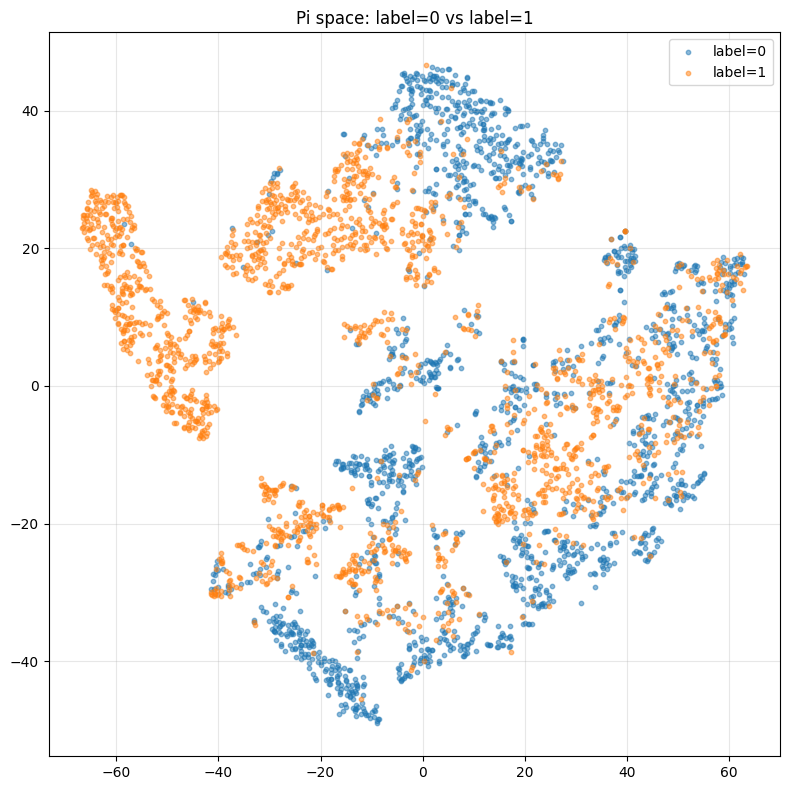

Silhouette (label): 0.1065


In [34]:
"""
전체 source의 pi를 모아서 t-SNE label scatter
"""

# ============================================================
# 1. 모든 source에서 pi, label, source name 수집
# ============================================================
all_pis_list = []
all_ys_list = []
all_src_names = []

for src_name in sources:
    loader = loaders[src_name]
    pis, ys, _, _, _ = collect_pi_and_affinity_for_one_source(
        joint_model_pretrain, loader, device, extract_feature_names
    )
    all_pis_list.append(pis)
    all_ys_list.append(ys)
    all_src_names.extend([src_name] * len(ys))

all_pis = np.concatenate(all_pis_list, axis=0)
all_ys = np.concatenate(all_ys_list, axis=0)
all_src_names = np.array(all_src_names)

print(f"Total samples: {len(all_ys)}, Coordinate dim: {all_pis.shape[1]}")
print(f"Label dist: {dict(zip(*np.unique(all_ys, return_counts=True)))}")

# ============================================================
# 2. t-SNE
# ============================================================
perp = max(5, min(40, (len(all_pis) - 1) // 3))
xy = TSNE(n_components=2, perplexity=perp, random_state=42).fit_transform(all_pis)

# ============================================================
# 3. Scatter: color by label
# ============================================================
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

for label in [0, 1]:
    mask = (all_ys == label)
    ax.scatter(xy[mask, 0], xy[mask, 1], s=10, alpha=0.5,
               label=f"label={label}", color=f"C{label}")

ax.set_title("Pi space: label=0 vs label=1")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
from sklearn.metrics import silhouette_score
sil = silhouette_score(pis, ys)
print(f"Silhouette (label): {sil:.4f}")

## 1. Source-wise Model Prediction 

Source별 Train / Val / Test Prediction 정확도 검증
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_Medicaldataset.pkl


>>> [DataLoader] Created isolated generator with seed 50
Training data size: 791
Validation data size: 264
Test data size: 264

──────────────────────────────────────────────────────────────────────
[Medicaldataset]
──────────────────────────────────────────────────────────────────────
  [Train] N= 791 (pos=486, neg=305) | Acc=0.823 AUC=0.917 | TP=371 TN=280 FP= 25 FN=115 | Recall=0.763 Prec=0.937 | MeanProb(y=1)=0.756 MeanProb(y=0)=0.220
  [Val  ] N= 264 (pos=162, neg=102) | Acc=0.848 AUC=0.915 | TP=130 TN= 94 FP=  8 FN= 32 | Recall=0.802 Prec=0.942 | MeanProb(y=1)=0.774 MeanProb(y=0)=0.208
  [Test ] N= 264 (pos=162, neg=102) | Acc=0.837 AUC=0.918 | TP=127 TN= 94 FP=  8 FN= 35 | Recall=0.784 Prec=0.941 | MeanProb(y=1)=0.746 MeanProb(y=0)=0.193
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_Cardiovascular_Disease_Dataset.pkl
>>> [DataLoader] Created isolated generator with seed 50
Training data size: 600
Validation dat

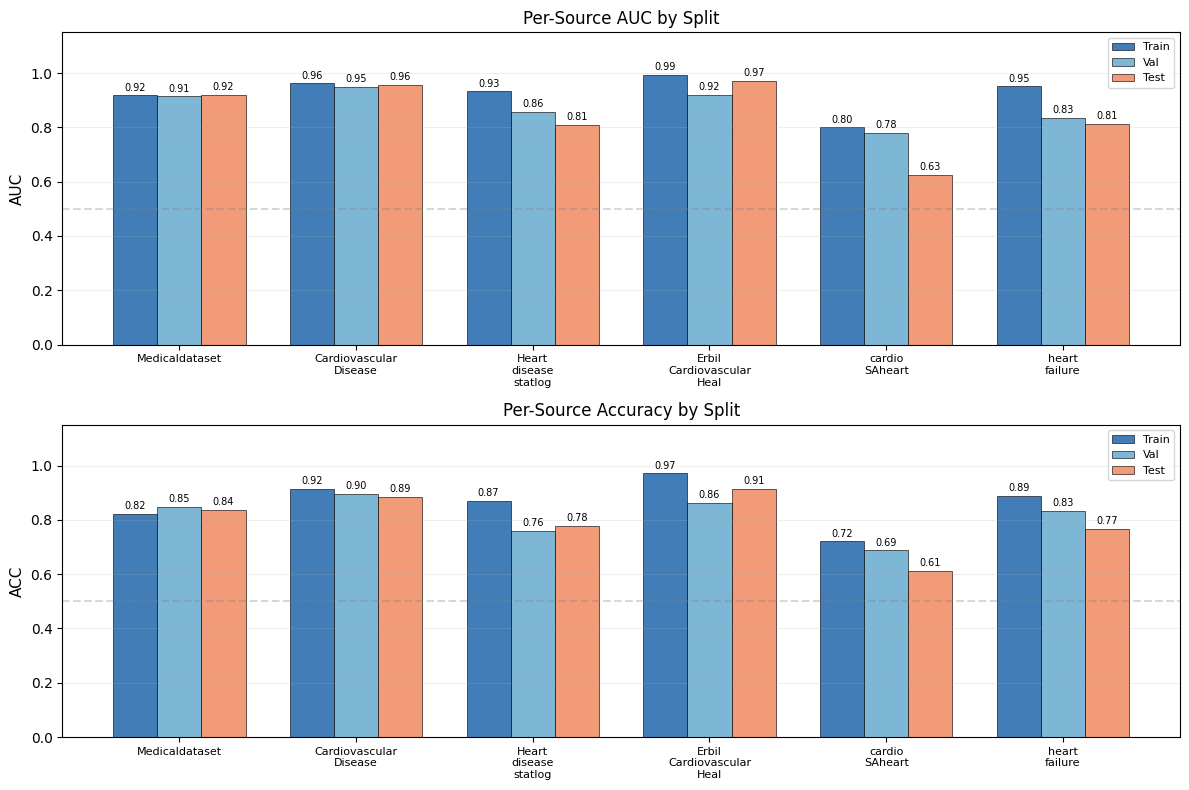

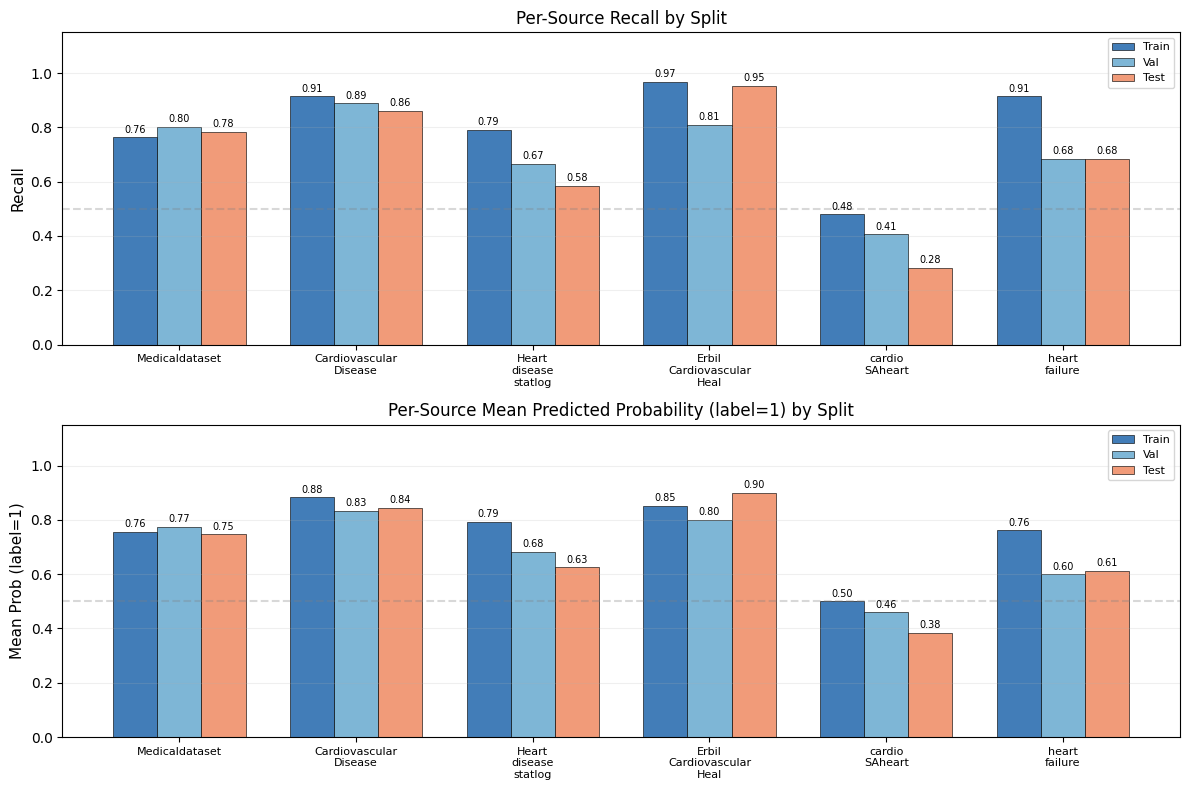

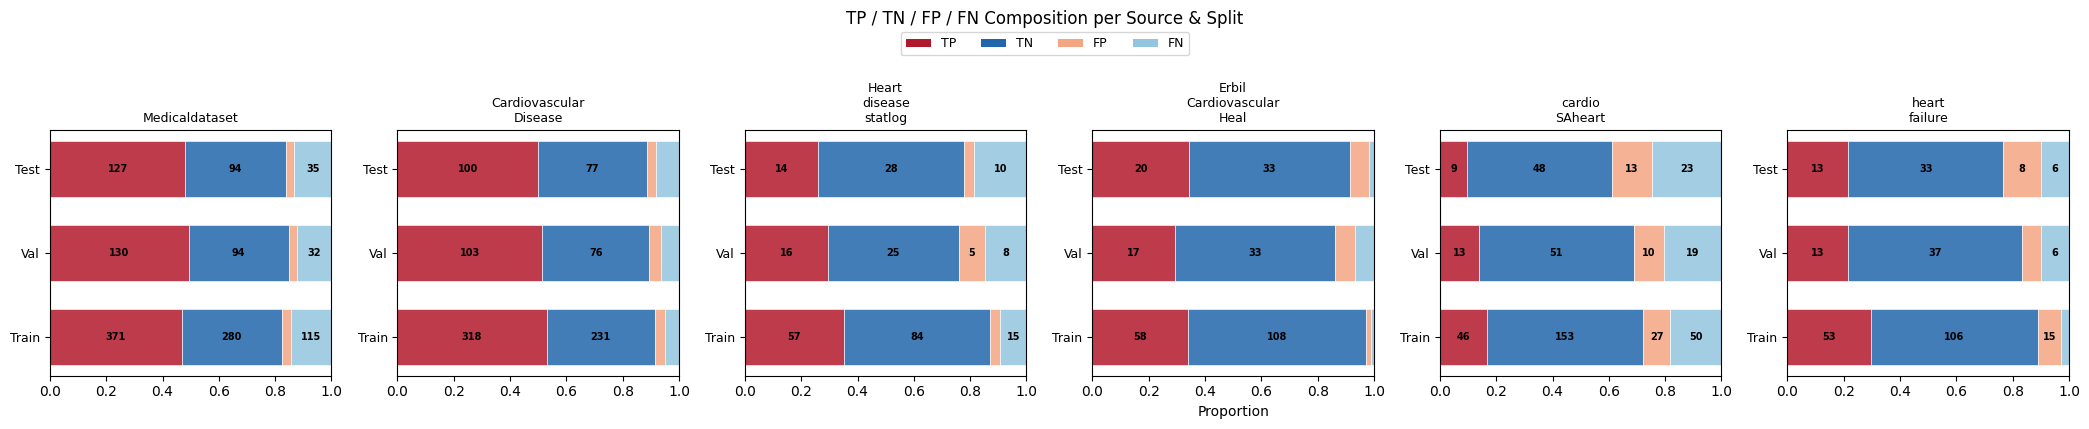

In [ ]:
"""
각 Source별 Train / Val / Test 분리 Prediction 정확도 검증
+ 시각화 (bar chart)
"""

import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

@torch.no_grad()
def check_prediction_per_source_split(model, args, sources, device, prepare_embedding_dataloaders_fn):
    model.eval()
    
    print(f"{'='*90}")
    print(f"Source별 Train / Val / Test Prediction 정확도 검증")
    print(f"{'='*90}")
    
    # 결과 저장용
    all_results = {}
    
    for src_name in sources:
        res = prepare_embedding_dataloaders_fn(args, src_name)
        tr_loader, va_loader, te_loader = res['loaders']
        
        print(f"\n{'─'*70}")
        print(f"[{src_name}]")
        print(f"{'─'*70}")
        
        src_results = {}
        for split_name, loader in [('Train', tr_loader), ('Val', va_loader), ('Test', te_loader)]:
            all_y = []
            all_prob = []
            
            for batch in loader:
                batch_t = {k: (v.to(device) if isinstance(v, torch.Tensor) else v)
                           for k, v in batch.items()}
                
                out = model.predict(batch_t, return_all=True)
                if isinstance(out, tuple):
                    global_pred, local_pred = out
                else:
                    global_pred = out
                
                prob = torch.sigmoid(global_pred).squeeze(-1)
                all_y.append(batch_t['y'].cpu().view(-1).numpy())
                all_prob.append(prob.cpu().view(-1).numpy())
            
            ys = np.concatenate(all_y)
            probs = np.concatenate(all_prob)
            preds = (probs >= 0.5).astype(int)
            
            n = len(ys)
            n_pos = int((ys == 1).sum())
            n_neg = int((ys == 0).sum())
            
            tp = int(((preds == 1) & (ys == 1)).sum())
            tn = int(((preds == 0) & (ys == 0)).sum())
            fp = int(((preds == 1) & (ys == 0)).sum())
            fn = int(((preds == 0) & (ys == 1)).sum())
            
            acc = (tp + tn) / n
            recall = tp / max(n_pos, 1)
            precision = tp / max(tp + fp, 1)
            
            try:
                auc = roc_auc_score(ys, probs)
            except:
                auc = float('nan')
            
            mean_prob_1 = float(probs[ys == 1].mean()) if n_pos > 0 else float('nan')
            mean_prob_0 = float(probs[ys == 0].mean()) if n_neg > 0 else float('nan')
            
            src_results[split_name] = {
                'n': n, 'n_pos': n_pos, 'n_neg': n_neg,
                'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn,
                'acc': acc, 'auc': auc, 'recall': recall, 'precision': precision,
                'mean_prob_1': mean_prob_1, 'mean_prob_0': mean_prob_0,
            }
            
            print(f"  [{split_name:5s}] N={n:4d} (pos={n_pos}, neg={n_neg}) | "
                  f"Acc={acc:.3f} AUC={auc:.3f} | "
                  f"TP={tp:3d} TN={tn:3d} FP={fp:3d} FN={fn:3d} | "
                  f"Recall={recall:.3f} Prec={precision:.3f} | "
                  f"MeanProb(y=1)={mean_prob_1:.3f} MeanProb(y=0)={mean_prob_0:.3f}")
        
        all_results[src_name] = src_results
    
    # ============================================================
    # 시각화
    # ============================================================
    n_src = len(sources)
    splits = ['Train', 'Val', 'Test']
    split_colors = {'Train': '#2166ac', 'Val': '#67a9cf', 'Test': '#ef8a62'}
    
    short_names = [s.replace('_Dataset', '').replace('_Health_Dataset', '')
                     .replace('_clinical_records', '').replace('_', '\n')[:25] 
                   for s in sources]
    
    # --- Figure 1: AUC + Accuracy ---
    fig, axes = plt.subplots(2, 1, figsize=(max(10, n_src * 2), 8))
    
    x = np.arange(n_src)
    width = 0.25
    
    for row, metric in enumerate(['auc', 'acc']):
        ax = axes[row]
        for i, split in enumerate(splits):
            vals = [all_results[s][split][metric] for s in sources]
            bars = ax.bar(x + i * width, vals, width, label=split, 
                         color=split_colors[split], alpha=0.85, edgecolor='black', linewidth=0.5)
            for bar, v in zip(bars, vals):
                ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                        f'{v:.2f}', ha='center', va='bottom', fontsize=7)
        
        ax.set_xticks(x + width)
        ax.set_xticklabels(short_names, fontsize=8)
        ax.set_ylabel(metric.upper(), fontsize=11)
        ax.set_ylim(0, 1.15)
        ax.axhline(0.5, color='gray', linestyle='--', alpha=0.3)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.2, axis='y')
    
    axes[0].set_title('Per-Source AUC by Split', fontsize=12)
    axes[1].set_title('Per-Source Accuracy by Split', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    # --- Figure 2: Recall + Mean Prob ---
    fig, axes = plt.subplots(2, 1, figsize=(max(10, n_src * 2), 8))
    
    for row, metric in enumerate(['recall', 'mean_prob_1']):
        ax = axes[row]
        for i, split in enumerate(splits):
            vals = [all_results[s][split][metric] for s in sources]
            bars = ax.bar(x + i * width, vals, width, label=split,
                         color=split_colors[split], alpha=0.85, edgecolor='black', linewidth=0.5)
            for bar, v in zip(bars, vals):
                ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                        f'{v:.2f}', ha='center', va='bottom', fontsize=7)
        
        ax.set_xticks(x + width)
        ax.set_xticklabels(short_names, fontsize=8)
        ylabel = 'Recall' if metric == 'recall' else 'Mean Prob (label=1)'
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_ylim(0, 1.15)
        ax.axhline(0.5, color='gray', linestyle='--', alpha=0.3)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.2, axis='y')
    
    axes[0].set_title('Per-Source Recall by Split', fontsize=12)
    axes[1].set_title('Per-Source Mean Predicted Probability (label=1) by Split', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    # --- Figure 3: TP/TN/FP/FN stacked per source (all splits) ---
    fig, axes = plt.subplots(1, n_src, figsize=(3.5 * n_src, 4))
    if n_src == 1:
        axes = [axes]
    
    group_names = ['TP', 'TN', 'FP', 'FN']
    group_colors_4 = ['#b2182b', '#2166ac', '#f4a582', '#92c5de']
    
    for col, src_name in enumerate(sources):
        ax = axes[col]
        for split_idx, split in enumerate(splits):
            r = all_results[src_name][split]
            counts = [r['tp'], r['tn'], r['fp'], r['fn']]
            total = sum(counts)
            ratios = [c / total for c in counts]
            
            bottom = split_idx * 1.2
            left = 0
            for g_idx, (ratio, count) in enumerate(zip(ratios, counts)):
                ax.barh(bottom, ratio, left=left, height=0.8,
                       color=group_colors_4[g_idx], alpha=0.85,
                       edgecolor='white', linewidth=0.5)
                if ratio > 0.08:
                    ax.text(left + ratio/2, bottom, f'{count}',
                           ha='center', va='center', fontsize=7, fontweight='bold')
                left += ratio
        
        ax.set_yticks([i * 1.2 for i in range(3)])
        ax.set_yticklabels(splits, fontsize=9)
        ax.set_xlim(0, 1)
        ax.set_title(short_names[col], fontsize=9)
        ax.set_xlabel('Proportion' if col == n_src // 2 else '')
    
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=c, label=n) for c, n in zip(group_colors_4, group_names)]
    fig.legend(handles=legend_elements, loc='upper center', ncol=4, fontsize=9,
              bbox_to_anchor=(0.5, 1.02))
    
    fig.suptitle('TP / TN / FP / FN Composition per Source & Split', fontsize=12, y=1.06)
    plt.tight_layout()
    plt.show()
    
    return all_results


# 호출
results = check_prediction_per_source_split(joint_model_pretrain, args, sources, device, prepare_embedding_dataloaders)

One-Hot Basis Risk (model intrinsic)
  M = 8 bases
  B0: one-hot prob = 0.0240 → LOW risk
  B1: one-hot prob = 0.9376 → HIGH risk
  B2: one-hot prob = 0.8102 → HIGH risk
  B3: one-hot prob = 0.2488 → LOW risk
  B4: one-hot prob = 0.4551 → LOW risk
  B5: one-hot prob = 0.0379 → LOW risk
  B6: one-hot prob = 0.8174 → HIGH risk
  B7: one-hot prob = 0.9943 → HIGH risk

Per-Source Basis Label Ratio

  [Medicaldataset] N=1319, overall pos=0.614
    B0: n= 179, pos_rate=0.145
    B1: n=   5, pos_rate=0.000
    B2: n=   0, pos_rate=nan
    B3: n= 459, pos_rate=0.444
    B4: n= 256, pos_rate=0.738
    B5: n=  58, pos_rate=0.534
    B6: n= 152, pos_rate=0.987
    B7: n= 210, pos_rate=1.000

  [Cardiovascular_Disease] N=1000, overall pos=0.580
    B0: n=  12, pos_rate=0.000
    B1: n= 184, pos_rate=0.342
    B2: n=   0, pos_rate=nan
    B3: n= 321, pos_rate=0.209
    B4: n= 134, pos_rate=0.881
    B5: n=   0, pos_rate=nan
    B6: n=  63, pos_rate=0.825
    B7: n= 286, pos_rate=0.979

  [Heart_dis

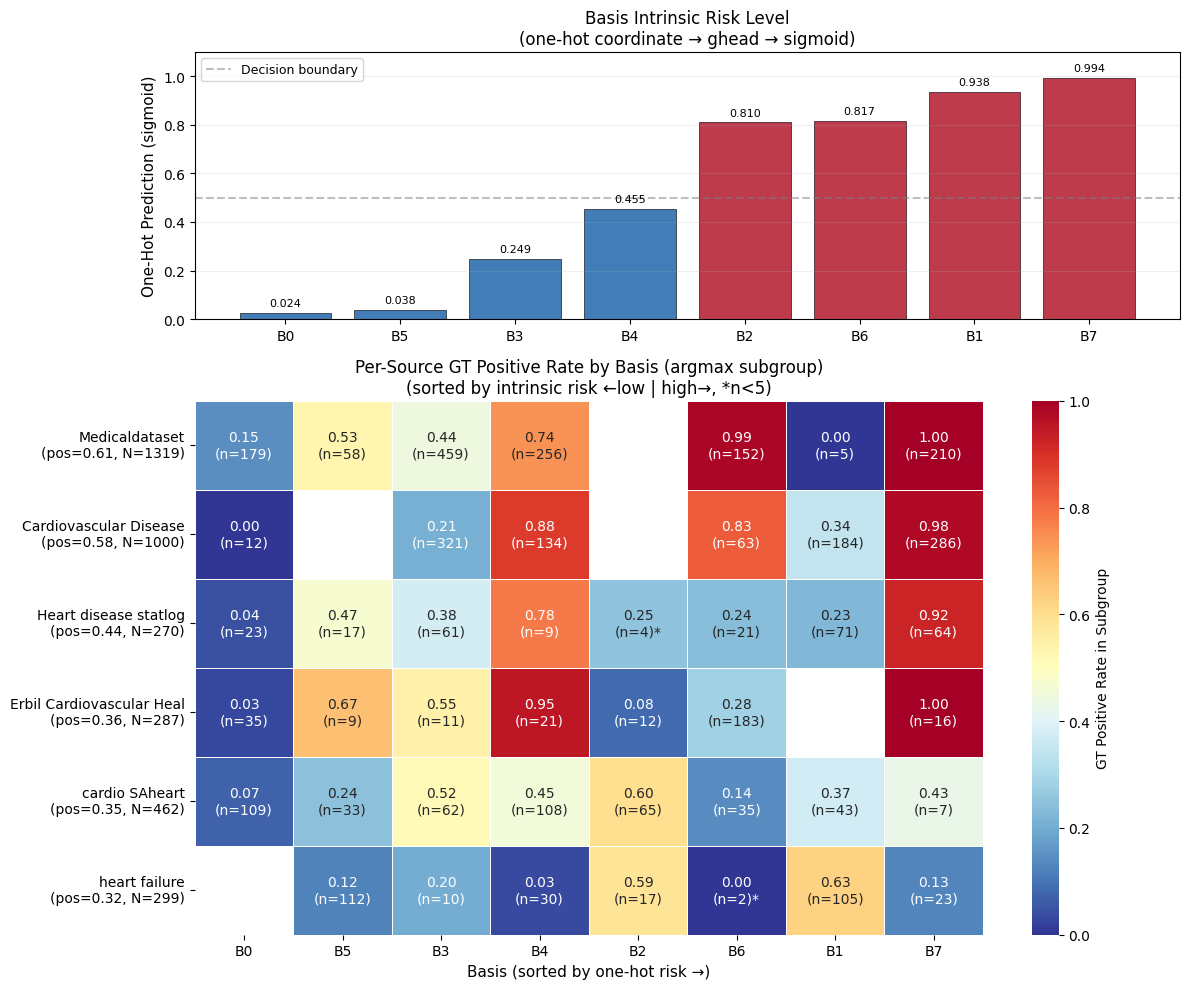


Risk Consistency Analysis
  High-risk bases (one-hot > 0.5): ['B1', 'B2', 'B6', 'B7']
  Low-risk bases (one-hot ≤ 0.5):  ['B0', 'B3', 'B4', 'B5']

  [Medicaldataset]
    High-risk bases: avg pos_rate = 0.981 (n=367)
    Low-risk bases:  avg pos_rate = 0.473 (n=952)
    → ✓ CONSISTENT

  [Cardiovascular_Disease]
    High-risk bases: avg pos_rate = 0.741 (n=533)
    Low-risk bases:  avg pos_rate = 0.396 (n=467)
    → ✓ CONSISTENT

  [Heart_disease_statlog]
    High-risk bases: avg pos_rate = 0.506 (n=160)
    Low-risk bases:  avg pos_rate = 0.355 (n=110)
    → ✓ CONSISTENT

  [Erbil_Cardiovascular_Heal]
    High-risk bases: avg pos_rate = 0.327 (n=211)
    Low-risk bases:  avg pos_rate = 0.434 (n=76)
    → ✗ INCONSISTENT

  [cardio_SAheart]
    High-risk bases: avg pos_rate = 0.420 (n=150)
    Low-risk bases:  avg pos_rate = 0.311 (n=312)
    → ✓ CONSISTENT

  [heart_failure_clinical_re]
    High-risk bases: avg pos_rate = 0.537 (n=147)
    Low-risk bases:  avg pos_rate = 0.112 (n=152)


In [36]:
"""
Basis Risk Verification
1. One-hot coordinate → ghead → prediction: 각 basis의 intrinsic risk level
2. 데이터셋별 각 basis에 배정된 sample의 GT label 비율
3. 대조: basis의 intrinsic risk와 실제 label 비율이 일관되는가?
"""

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# 1. One-hot prediction: 각 basis의 intrinsic risk
# ============================================================

@torch.no_grad()
def compute_onehot_basis_risk(model, device):
    """
    Coordinate를 one-hot으로 넣어서 각 basis 단독의 prediction value를 확인.
    이건 데이터셋과 무관한 모델 자체의 속성.
    """
    model.eval()
    
    # expert_outputs를 한 번 뽑아야 하는데, one-hot coordinate만으로는 안 됨
    # gnn_experts는 LCG feat/struct를 받아서 expert_outputs를 만드니까
    # 먼저 LCG에서 expert_outputs를 뽑고, 그 위에 one-hot coordinate를 적용
    
    lcg_feat, lcg_struct = model.latent_graph()
    M = lcg_feat.shape[0]
    
    # expert_outputs: [1, M, D] (batch=1로)
    lcg_feat_batch = lcg_feat.unsqueeze(0)      # [1, M, K, D]
    lcg_struct_batch = lcg_struct.unsqueeze(0)   # [1, M, K, K]
    expert_outputs = model.gnn_experts(lcg_feat_batch, lcg_struct_batch)  # [1, M, D]
    
    print(f"{'='*60}")
    print(f"One-Hot Basis Risk (model intrinsic)")
    print(f"{'='*60}")
    print(f"  M = {M} bases")
    
    onehot_probs = []
    
    for k in range(M):
        # one-hot coordinate: [1, M]
        pi_onehot = torch.zeros(1, M, device=device)
        pi_onehot[0, k] = 1.0
        
        # weighted sum
        weighted = (pi_onehot.unsqueeze(-1) * expert_outputs).sum(dim=1)  # [1, D]
        
        # ghead
        current_mode = getattr(model, 'mode', 'Full')
        if current_mode == 'Few':
            logit = model.ghead2(weighted)
        else:
            logit = model.ghead(weighted)
        
        prob = torch.sigmoid(logit).item()
        onehot_probs.append(prob)
        
        risk_label = "HIGH" if prob > 0.5 else "LOW"
        print(f"  B{k}: one-hot prob = {prob:.4f} → {risk_label} risk")
    
    return np.array(onehot_probs)


# ============================================================
# 2. 데이터셋별 basis 배정 + GT label 비율
# ============================================================

@torch.no_grad()
def compute_per_source_basis_label_ratio(model, loaders, sources, device):
    """
    각 source에서 각 basis(argmax)에 배정된 sample의 GT label 비율
    """
    model.eval()
    
    all_results = {}
    
    for src_name in sources:
        loader = loaders[src_name]
        all_pi = []
        all_y = []
        
        for batch in loader:
            batch_t = {k: (v.to(device) if isinstance(v, torch.Tensor) else v)
                       for k, v in batch.items()}
            out = model.predict(batch_t, return_all=True)
            pi = model.graph_quantizer.last_pi
            
            all_pi.append(pi.cpu().numpy())
            all_y.append(batch_t['y'].cpu().view(-1).numpy())
        
        pis = np.concatenate(all_pi, axis=0)
        ys = np.concatenate(all_y, axis=0).astype(int)
        argmax = pis.argmax(axis=1)
        M = pis.shape[1]
        
        basis_info = {}
        for k in range(M):
            mask = (argmax == k)
            n = mask.sum()
            if n > 0:
                pos_rate = ys[mask].mean()
                n_pos = ys[mask].sum()
            else:
                pos_rate = np.nan
                n_pos = 0
            basis_info[k] = {'n': int(n), 'n_pos': int(n_pos), 'pos_rate': float(pos_rate)}
        
        overall_pos = ys.mean()
        all_results[src_name] = {
            'basis_info': basis_info,
            'M': M,
            'N': len(ys),
            'overall_pos': float(overall_pos),
        }
    
    return all_results


# ============================================================
# 3. 시각화: One-hot risk + per-source label ratio 대조
# ============================================================

def plot_basis_risk_verification(onehot_probs, source_results, sources):
    """
    상단: one-hot basis risk (모델 intrinsic)
    하단: 데이터셋별 basis내 GT positive rate (heatmap)
    """
    M = len(onehot_probs)
    n_src = len(sources)
    
    short_names = [s.replace('_Dataset', '').replace('_Health_Dataset', '')
                     .replace('_clinical_records', '').replace('_', ' ')[:25]
                   for s in sources]
    
    # basis를 one-hot risk 순으로 정렬
    sorted_idx = np.argsort(onehot_probs)
    
    fig, axes = plt.subplots(2, 1, figsize=(max(10, M * 1.5), 10),
                              gridspec_kw={'height_ratios': [1, 2]})
    
    # --- 상단: One-hot risk bar ---
    ax = axes[0]
    colors = ['#2166ac' if p < 0.5 else '#b2182b' for p in onehot_probs[sorted_idx]]
    bars = ax.bar(range(M), onehot_probs[sorted_idx], color=colors, alpha=0.85,
                  edgecolor='black', linewidth=0.5)
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Decision boundary')
    
    for i, (bar, idx) in enumerate(zip(bars, sorted_idx)):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                f'{onehot_probs[idx]:.3f}', ha='center', va='bottom', fontsize=8)
    
    ax.set_xticks(range(M))
    ax.set_xticklabels([f'B{idx}' for idx in sorted_idx], fontsize=10)
    ax.set_ylabel('One-Hot Prediction (sigmoid)', fontsize=11)
    ax.set_ylim(0, 1.1)
    ax.set_title('Basis Intrinsic Risk Level\n(one-hot coordinate → ghead → sigmoid)', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2, axis='y')
    
    # --- 하단: Heatmap (source × basis, value=pos_rate) ---
    ax = axes[1]
    
    heatmap_data = np.full((n_src, M), np.nan)
    annot_data = np.full((n_src, M), '', dtype=object)
    
    for i, src_name in enumerate(sources):
        info = source_results[src_name]['basis_info']
        overall = source_results[src_name]['overall_pos']
        for j, basis_idx in enumerate(sorted_idx):
            bi = info[basis_idx]
            if bi['n'] >= 5:
                heatmap_data[i, j] = bi['pos_rate']
                annot_data[i, j] = f"{bi['pos_rate']:.2f}\n(n={bi['n']})"
            elif bi['n'] > 0:
                heatmap_data[i, j] = bi['pos_rate']
                annot_data[i, j] = f"{bi['pos_rate']:.2f}\n(n={bi['n']})*"
    
    # source 이름에 overall pos rate 추가
    y_labels = [f"{sn}\n(pos={source_results[s]['overall_pos']:.2f}, N={source_results[s]['N']})"
                for sn, s in zip(short_names, sources)]
    
    sns.heatmap(
        heatmap_data,
        annot=annot_data, fmt='',
        xticklabels=[f'B{idx}' for idx in sorted_idx],
        yticklabels=y_labels,
        cmap='RdYlBu_r',
        center=0.5,
        vmin=0, vmax=1,
        linewidths=0.5,
        ax=ax,
        cbar_kws={'label': 'GT Positive Rate in Subgroup'},
    )
    
    ax.set_title('Per-Source GT Positive Rate by Basis (argmax subgroup)\n'
                 '(sorted by intrinsic risk ←low | high→, *n<5)', fontsize=12)
    ax.set_xlabel('Basis (sorted by one-hot risk →)', fontsize=11)
    
    plt.tight_layout()
    plt.show()


# ============================================================
# 4. Consistency 정량 분석
# ============================================================

def analyze_risk_consistency(onehot_probs, source_results, sources):
    """
    One-hot risk direction과 실제 GT positive rate의 일관성 확인
    - 각 source에서 high-risk basis(one-hot > 0.5)의 avg pos_rate가
      low-risk basis(one-hot < 0.5)의 avg pos_rate보다 높은지?
    """
    M = len(onehot_probs)
    high_risk_bases = [k for k in range(M) if onehot_probs[k] > 0.5]
    low_risk_bases = [k for k in range(M) if onehot_probs[k] <= 0.5]
    
    print(f"\n{'='*60}")
    print(f"Risk Consistency Analysis")
    print(f"{'='*60}")
    print(f"  High-risk bases (one-hot > 0.5): {['B'+str(k) for k in high_risk_bases]}")
    print(f"  Low-risk bases (one-hot ≤ 0.5):  {['B'+str(k) for k in low_risk_bases]}")
    
    consistent_count = 0
    total_count = 0
    
    for src_name in sources:
        info = source_results[src_name]['basis_info']
        
        # high-risk basis들의 weighted average pos_rate
        high_n, high_pos = 0, 0
        for k in high_risk_bases:
            high_n += info[k]['n']
            high_pos += info[k]['n_pos']
        high_rate = high_pos / max(high_n, 1)
        
        # low-risk basis들의 weighted average pos_rate
        low_n, low_pos = 0, 0
        for k in low_risk_bases:
            low_n += info[k]['n']
            low_pos += info[k]['n_pos']
        low_rate = low_pos / max(low_n, 1)
        
        is_consistent = high_rate > low_rate
        if is_consistent:
            consistent_count += 1
        total_count += 1
        
        short_name = src_name.replace('_Dataset', '')[:25]
        status = "✓ CONSISTENT" if is_consistent else "✗ INCONSISTENT"
        print(f"\n  [{short_name}]")
        print(f"    High-risk bases: avg pos_rate = {high_rate:.3f} (n={high_n})")
        print(f"    Low-risk bases:  avg pos_rate = {low_rate:.3f} (n={low_n})")
        print(f"    → {status}")
    
    print(f"\n  Overall: {consistent_count}/{total_count} sources consistent "
          f"({consistent_count/total_count*100:.0f}%)")


# ============================================================
# 5. 실행
# ============================================================

def run_basis_risk_verification(model, loaders, sources, device):
    """전체 파이프라인"""
    
    # (1) One-hot basis risk
    onehot_probs = compute_onehot_basis_risk(model, device)
    
    # (2) Per-source basis label ratio
    print(f"\n{'='*60}")
    print(f"Per-Source Basis Label Ratio")
    print(f"{'='*60}")
    source_results = compute_per_source_basis_label_ratio(model, loaders, sources, device)
    
    for src_name in sources:
        r = source_results[src_name]
        short = src_name.replace('_Dataset', '')[:25]
        print(f"\n  [{short}] N={r['N']}, overall pos={r['overall_pos']:.3f}")
        for k in range(r['M']):
            bi = r['basis_info'][k]
            print(f"    B{k}: n={bi['n']:4d}, pos_rate={bi['pos_rate']:.3f}")
    
    # (3) 시각화
    plot_basis_risk_verification(onehot_probs, source_results, sources)
    
    # (4) Consistency 분석
    analyze_risk_consistency(onehot_probs, source_results, sources)
    
    return {
        'onehot_probs': onehot_probs,
        'source_results': source_results,
    }


# 호출
risk_result = run_basis_risk_verification(joint_model_pretrain, loaders, sources, device)

One-Hot Basis Risk (model intrinsic)
  M = 8 bases
  B0: one-hot prob = 0.0240 → LOW risk
  B1: one-hot prob = 0.9376 → HIGH risk
  B2: one-hot prob = 0.8102 → HIGH risk
  B3: one-hot prob = 0.2488 → LOW risk
  B4: one-hot prob = 0.4551 → LOW risk
  B5: one-hot prob = 0.0379 → LOW risk
  B6: one-hot prob = 0.8174 → HIGH risk
  B7: one-hot prob = 0.9943 → HIGH risk


Total: 299 samples, pos=0.321

[heart_failure] Basis별 Actual Prediction vs GT Label
Basis     N  GT pos%  Mean Pred  Pred>0.5%  One-Hot
-------------------------------------------------------
B0       0      n/a        n/a        n/a 0.0239802747964859
B1     105    0.629      0.689      0.829    0.938
B2      17    0.588      0.565      0.647    0.810
B3      10    0.200      0.371      0.100    0.249
B4      30    0.033      0.092      0.067    0.455
B5     112    0.125      0.112      0.009    0.038
B6       2    0.000      0.193      0.000    0.817 ← ⚠️ HIGH risk basis, LOW GT
B7      23    0.130      0.174      0.174    0.994 ← ⚠️ HIGH risk basis, LOW GT

[heart_failure] B7에 배정된 23개 sample 상세

  GT Label 분포: label=0: 20, label=1: 3
  Mean predicted prob: 0.1739
  Pred >= 0.5 (label=1 예측): 4/23

   idx  GT    Pred  argmax    c[0]   c[1]   c[2]   c[3]   c[4]   c[5]   c[6]   c[7]
  ---------------------------------------------------------------------------------
     6   1  0.8714 B 

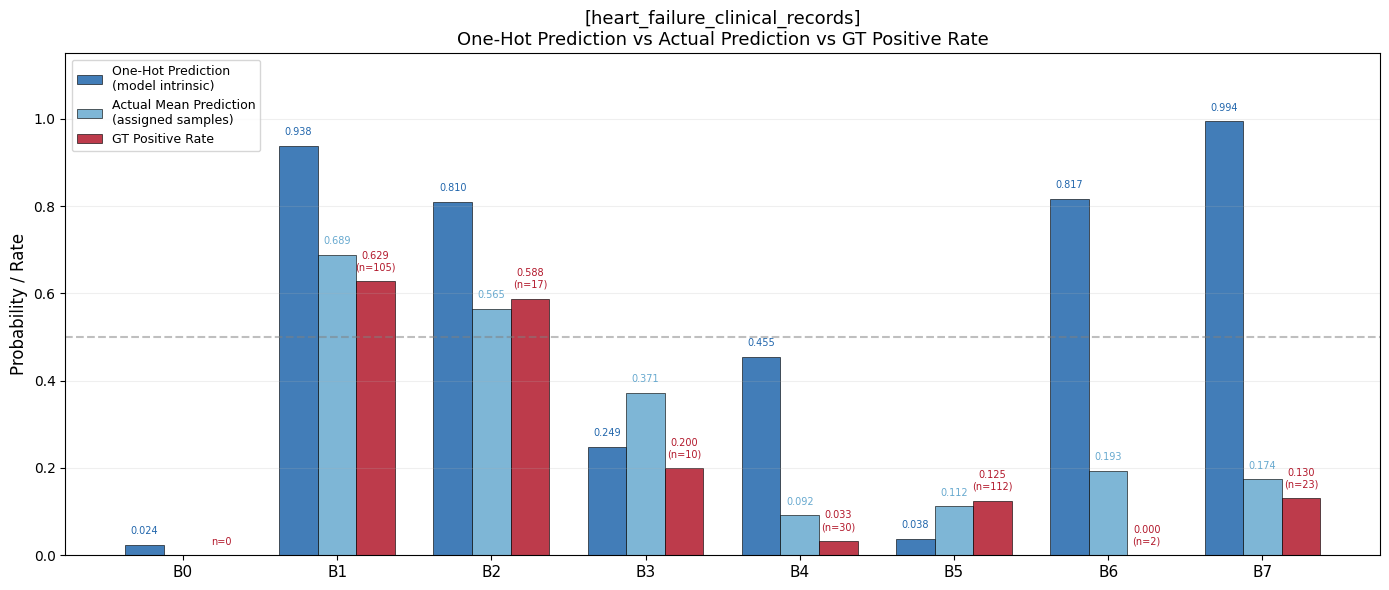

In [37]:
"""
Heart_failure_clinical_records 심층 분석
1. 각 basis별 실제 배정된 sample들의 actual prediction 확인
2. B7에 배정된 23개 sample의 coordinate, prediction, GT label 까보기
3. One-hot vs actual coordinate로 prediction이 어떻게 달라지는지
"""

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. Heart_failure sample별 전체 정보 추출
# ============================================================

@torch.no_grad()
def extract_heart_failure_details(model, loader, device):
    """Heart_failure의 모든 sample에 대해 상세 정보 추출"""
    model.eval()
    
    all_pi = []
    all_y = []
    all_prob = []
    all_sidx = []
    
    for batch in loader:
        batch_t = {k: (v.to(device) if isinstance(v, torch.Tensor) else v)
                   for k, v in batch.items()}
        
        out = model.predict(batch_t, return_all=True)
        if isinstance(out, tuple):
            global_pred, local_pred = out
        else:
            global_pred = out
        
        pi = model.graph_quantizer.last_pi
        prob = torch.sigmoid(global_pred).squeeze(-1)
        
        all_pi.append(pi.cpu().numpy())
        all_y.append(batch_t['y'].cpu().view(-1).numpy())
        all_prob.append(prob.cpu().view(-1).numpy())
        
        if 's_idx' in batch_t:
            sidx = batch_t['s_idx']
            if isinstance(sidx, torch.Tensor):
                all_sidx.append(sidx.cpu().view(-1).numpy())
            else:
                all_sidx.append(np.array([sidx] * pi.shape[0]))
    
    return {
        'pi': np.concatenate(all_pi, axis=0),
        'y': np.concatenate(all_y, axis=0).astype(int),
        'prob': np.concatenate(all_prob, axis=0),
    }


# ============================================================
# 2. Basis별 actual prediction 분석
# ============================================================

def analyze_basis_actual_prediction(data, onehot_probs=None):
    """
    각 basis(argmax)에 배정된 sample들의 actual prediction 분포
    vs one-hot prediction 대조
    """
    pi = data['pi']
    y = data['y']
    prob = data['prob']
    M = pi.shape[1]
    argmax = pi.argmax(axis=1)
    
    print(f"\n{'='*70}")
    print(f"[heart_failure] Basis별 Actual Prediction vs GT Label")
    print(f"{'='*70}")
    print(f"{'Basis':<6} {'N':>4} {'GT pos%':>8} {'Mean Pred':>10} {'Pred>0.5%':>10} {'One-Hot':>8}")
    print("-" * 55)
    
    for k in range(M):
        mask = (argmax == k)
        n = mask.sum()
        if n == 0:
            print(f"B{k:<4} {n:>4} {'n/a':>8} {'n/a':>10} {'n/a':>10} {onehot_probs[k] if onehot_probs is not None else 'n/a':>8}")
            continue
        
        gt_pos = y[mask].mean()
        mean_pred = prob[mask].mean()
        pred_pos = (prob[mask] >= 0.5).mean()
        oh = f"{onehot_probs[k]:.3f}" if onehot_probs is not None else "n/a"
        
        # 불일치 표시
        flag = ""
        if onehot_probs is not None:
            if onehot_probs[k] > 0.5 and gt_pos < 0.3:
                flag = " ← ⚠️ HIGH risk basis, LOW GT"
            elif onehot_probs[k] < 0.5 and gt_pos > 0.7:
                flag = " ← ⚠️ LOW risk basis, HIGH GT"
        
        print(f"B{k:<4} {n:>4} {gt_pos:>8.3f} {mean_pred:>10.3f} {pred_pos:>10.3f} {oh:>8}{flag}")


# ============================================================
# 3. B7 배정 sample 심층 분석
# ============================================================

def analyze_b7_samples(data, basis_idx=7):
    """
    특정 basis에 배정된 sample들의 상세 분석
    - 실제 coordinate vector
    - actual prediction
    - GT label
    """
    pi = data['pi']
    y = data['y']
    prob = data['prob']
    M = pi.shape[1]
    argmax = pi.argmax(axis=1)
    
    mask = (argmax == basis_idx)
    n = mask.sum()
    
    print(f"\n{'='*70}")
    print(f"[heart_failure] B{basis_idx}에 배정된 {n}개 sample 상세")
    print(f"{'='*70}")
    
    if n == 0:
        print("  No samples assigned to this basis")
        return
    
    pi_sub = pi[mask]
    y_sub = y[mask]
    prob_sub = prob[mask]
    
    print(f"\n  GT Label 분포: label=0: {(y_sub==0).sum()}, label=1: {(y_sub==1).sum()}")
    print(f"  Mean predicted prob: {prob_sub.mean():.4f}")
    print(f"  Pred >= 0.5 (label=1 예측): {(prob_sub >= 0.5).sum()}/{n}")
    
    # 각 sample별 상세
    print(f"\n  {'idx':>4} {'GT':>3} {'Pred':>7} {'argmax':>7} ", end="")
    for k in range(M):
        print(f"{'c['+str(k)+']':>7}", end="")
    print()
    print("  " + "-" * (25 + 7 * M))
    
    indices = np.where(mask)[0]
    for i, global_idx in enumerate(indices):
        gt = y_sub[i]
        pred = prob_sub[i]
        am = argmax[global_idx]
        print(f"  {global_idx:>4} {gt:>3} {pred:>7.4f} B{am:>5} ", end="")
        for k in range(M):
            val = pi_sub[i, k]
            marker = "**" if k == basis_idx else "  "
            print(f"{val:>5.3f}{marker}", end="")
        print()
    
    return pi_sub, y_sub, prob_sub


# ============================================================
# 4. 시각화: 각 basis별 one-hot prediction vs actual prediction vs GT
# ============================================================

def plot_basis_prediction_comparison(data, onehot_probs):
    """
    각 basis에 대해 3가지를 나란히:
    - One-hot prediction (모델 intrinsic)
    - Actual mean prediction (배정된 sample들의 평균)
    - GT positive rate
    """
    pi = data['pi']
    y = data['y']
    prob = data['prob']
    M = pi.shape[1]
    argmax = pi.argmax(axis=1)
    
    bases = list(range(M))
    oh_vals = [onehot_probs[k] for k in bases]
    
    actual_pred = []
    gt_pos = []
    ns = []
    for k in bases:
        mask = (argmax == k)
        n = mask.sum()
        ns.append(n)
        if n > 0:
            actual_pred.append(prob[mask].mean())
            gt_pos.append(y[mask].mean())
        else:
            actual_pred.append(0)
            gt_pos.append(0)
    
    x = np.arange(M)
    width = 0.25
    
    fig, ax = plt.subplots(1, 1, figsize=(14, 6))
    
    bars1 = ax.bar(x - width, oh_vals, width, label='One-Hot Prediction\n(model intrinsic)',
                   color='#2166ac', alpha=0.85, edgecolor='black', linewidth=0.5)
    bars2 = ax.bar(x, actual_pred, width, label='Actual Mean Prediction\n(assigned samples)',
                   color='#67a9cf', alpha=0.85, edgecolor='black', linewidth=0.5)
    bars3 = ax.bar(x + width, gt_pos, width, label='GT Positive Rate',
                   color='#b2182b', alpha=0.85, edgecolor='black', linewidth=0.5)
    
    # 값 표시
    for bar, v in zip(bars1, oh_vals):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7, color='#2166ac')
    for bar, v, n in zip(bars2, actual_pred, ns):
        if n > 0:
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=7, color='#67a9cf')
    for bar, v, n in zip(bars3, gt_pos, ns):
        label = f'{v:.3f}\n(n={n})' if n > 0 else 'n=0'
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                label, ha='center', va='bottom', fontsize=7, color='#b2182b')
    
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels([f'B{k}' for k in bases], fontsize=11)
    ax.set_ylabel('Probability / Rate', fontsize=12)
    ax.set_ylim(0, 1.15)
    ax.set_title('[heart_failure_clinical_records]\n'
                 'One-Hot Prediction vs Actual Prediction vs GT Positive Rate', fontsize=13)
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(True, alpha=0.2, axis='y')
    
    plt.tight_layout()
    plt.show()


# ============================================================
# 5. 실행
# ============================================================

def run_heart_failure_analysis(model, loaders, sources, device):
    """Heart_failure 심층 분석 파이프라인"""
    
    # onehot_probs는 이미 basis_risk_verification에서 뽑았으니 재사용
    # 만약 없으면 직접:
    onehot_probs = compute_onehot_basis_risk(joint_model_pretrain, device)

    # heart_failure 데이터 추출
    hf_name = 'heart_failure_clinical_records'
    data = extract_heart_failure_details(joint_model_pretrain, loaders[hf_name], device)
    print(f"Total: {len(data['y'])} samples, pos={data['y'].mean():.3f}")

    # (1) Basis별 actual prediction
    analyze_basis_actual_prediction(data, onehot_probs)

    # (2) B7 상세
    analyze_b7_samples(data, basis_idx=7)

    # (3) 시각화
    plot_basis_prediction_comparison(data, onehot_probs)
    
    return data, onehot_probs


# 호출
hf_data, oh_probs = run_heart_failure_analysis(joint_model_pretrain, loaders, sources, device)

## 2. In-domain Feature Analysis 


- 한 도메인 내에서 argmax 기반 subgroup 형성
- 각 subgroup의 feature value 분포 비교 
- Subgroup마다 중요한 feature subset이 다른지를 확인
- 눈에 띄는 한두 개에 대해 domain literature로 뒷받침 (예정)

Total samples: 3637, M=8

=== Subgroup별 GT Label 비율 ===
  Basis 0: N=358, GT positive rate=0.101
  Basis 1: N=408, GT positive rate=0.395
  Basis 2: N=98, GT positive rate=0.520
  Basis 3: N=924, GT positive rate=0.361
  Basis 4: N=558, GT positive rate=0.688
  Basis 5: N=229, GT positive rate=0.293
  Basis 6: N=456, GT positive rate=0.579
  Basis 7: N=606, GT positive rate=0.942


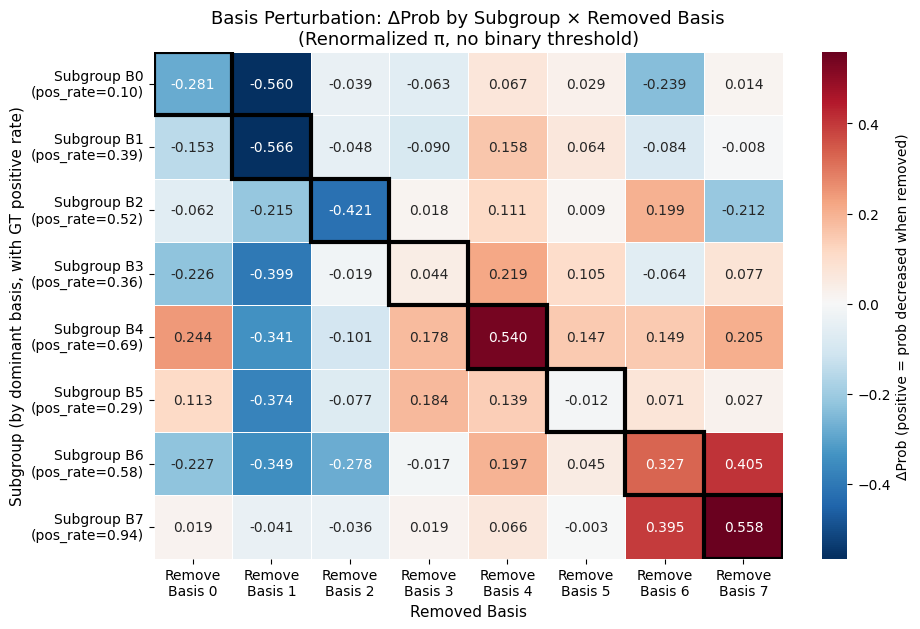


=== Diagonal vs Off-diagonal (|ΔProb|) ===
  Diagonal (dominant removed):  mean |ΔProb| = 0.3436
  Off-diagonal (other removed): mean |ΔProb| = 0.1428
  Ratio: 2.41x


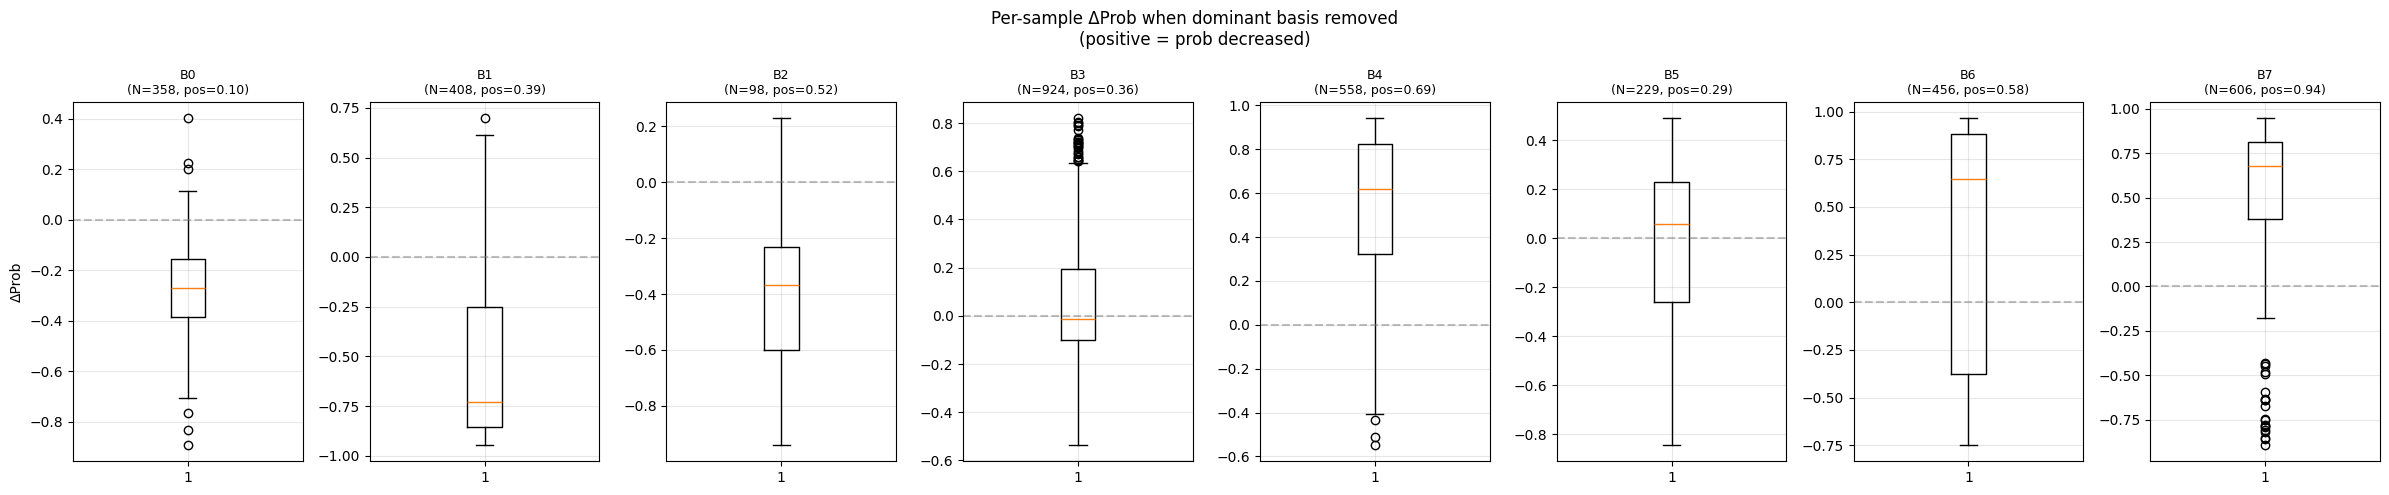


=== Basis 역할 분석 (ΔProb 방향 + GT positive rate) ===
Subgroup     GT pos_rate  Dominant ΔProb   해석
------------------------------------------------------------
  B0        0.101        -0.2814          negative 방향 기여 (제거시 prob↑)
  B1        0.395        -0.5661          negative 방향 기여 (제거시 prob↑)
  B2        0.520        -0.4205          negative 방향 기여 (제거시 prob↑)
  B3        0.361        0.0443           약한 기여
  B4        0.688        0.5396           positive 방향 기여 (제거시 prob↓)
  B5        0.293        -0.0116          약한 기여
  B6        0.579        0.3268           positive 방향 기여 (제거시 prob↓)
  B7        0.942        0.5585           positive 방향 기여 (제거시 prob↓)


In [38]:
"""
Exp 1. Basis Perturbation (v2 — 교수님 피드백 반영)

변경사항:
1. ΔAcc → ΔProb (sigmoid probability 변화량, binary threshold 안 씀)
2. π[k]=0 후 renormalize (합=1 유지)
3. Subgroup별 GT label 비율 표시 (acc 대신)
4. Heatmap: prediction이 얼마나 바뀌는지를 직접 보여줌

- joint_model_pretrain, args, loaders, sources, device 이미 로딩된 상태
"""

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 1. Expert outputs + coordinates + probability 추출
# ============================================================

@torch.no_grad()
def extract_experts_and_coords(model, loader, device):
    """
    각 샘플에 대해:
    - expert_outputs: [B, M, D]
    - pi: [B, M]
    - y: [B] (GT label)
    - prob: [B] (sigmoid probability, continuous)
    """
    model.eval()
    
    all_expert_out = []
    all_pi = []
    all_y = []
    all_prob = []
    
    captured = {}
    def hook_fn(module, input, output):
        captured['expert_out'] = output.detach()
    
    handle = model.gnn_experts.register_forward_hook(hook_fn)
    
    for batch in loader:
        batch_t = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
        
        out = model.predict(batch_t, return_all=True)
        if isinstance(out, tuple):
            global_pred, local_pred = out
        else:
            global_pred = out
        
        pi = model.graph_quantizer.last_pi
        expert_out = captured['expert_out']
        
        # sigmoid probability (binary threshold 없이)
        prob = torch.sigmoid(global_pred).squeeze(-1)
        
        all_expert_out.append(expert_out.cpu())
        all_pi.append(pi.cpu())
        all_y.append(batch_t['y'].cpu().view(-1))
        all_prob.append(prob.cpu().view(-1))
    
    handle.remove()
    
    return (
        torch.cat(all_expert_out, dim=0),
        torch.cat(all_pi, dim=0),
        torch.cat(all_y, dim=0),
        torch.cat(all_prob, dim=0),
    )

# ============================================================
# 2. Perturbed probability 계산 (renormalize 포함)
# ============================================================

@torch.no_grad()
def compute_prob_with_perturbation(model, expert_outputs, pi, remove_basis=None):
    """
    Returns: prob [N] (sigmoid probability, continuous)
    
    π[k]=0 후 renormalize하여 합=1 유지
    """
    pi_perturbed = pi.clone()
    if remove_basis is not None:
        pi_perturbed[:, remove_basis] = 0.0
        # ★ renormalize: 나머지의 합이 1이 되도록
        row_sum = pi_perturbed.sum(dim=1, keepdim=True)
        # 합이 0인 경우 방지 (모든 basis가 0이면 uniform)
        row_sum = torch.clamp(row_sum, min=1e-8)
        pi_perturbed = pi_perturbed / row_sum
    
    # weighted sum: [N, D]
    weighted = (pi_perturbed.unsqueeze(-1) * expert_outputs).sum(dim=1)
    weighted = weighted.to(next(model.parameters()).device)
    
    current_mode = getattr(model, 'mode', 'Full')
    if current_mode == 'Few':
        logits = model.ghead2(weighted)
    else:
        logits = model.ghead(weighted)
    
    prob = torch.sigmoid(logits).squeeze(-1)
    return prob.cpu()

# ============================================================
# 3. 전체 source에 대해 perturbation 실험
# ============================================================

def run_perturbation_experiment_v2(model, loaders, sources, device):
    """ΔProb 기반 perturbation 실험"""
    
    all_expert = []
    all_pi = []
    all_y = []
    all_prob = []
    all_src = []
    
    for src_name in sources:
        loader = loaders[src_name]
        expert_out, pi, y, prob = extract_experts_and_coords(model, loader, device)
        all_expert.append(expert_out)
        all_pi.append(pi)
        all_y.append(y)
        all_prob.append(prob)
        all_src.extend([src_name] * len(y))
    
    expert_outputs = torch.cat(all_expert, dim=0)
    pis = torch.cat(all_pi, dim=0)
    ys = torch.cat(all_y, dim=0)
    orig_probs = torch.cat(all_prob, dim=0)
    
    M = pis.shape[1]
    argmax_basis = pis.numpy().argmax(axis=1)
    ys_np = ys.numpy().astype(int)
    orig_probs_np = orig_probs.numpy()
    
    print(f"Total samples: {len(ys_np)}, M={M}")
    
    # 각 basis를 제거한 probability
    perturbed_probs = {}
    for k in range(M):
        prob_k = compute_prob_with_perturbation(model, expert_outputs, pis, remove_basis=k)
        perturbed_probs[k] = prob_k.numpy()
    
    # Subgroup 정보
    active_bases = sorted(set(argmax_basis))
    active_bases = [b for b in active_bases if (argmax_basis == b).sum() >= 10]
    
    # 각 subgroup의 GT label 비율
    print("\n=== Subgroup별 GT Label 비율 ===")
    gt_pos_rates = {}
    for sg in active_bases:
        mask = (argmax_basis == sg)
        n = mask.sum()
        pos_rate = ys_np[mask].mean()
        gt_pos_rates[sg] = pos_rate
        print(f"  Basis {sg}: N={n}, GT positive rate={pos_rate:.3f}")
    
    return {
        'M': M,
        'active_bases': active_bases,
        'argmax_basis': argmax_basis,
        'ys': ys_np,
        'orig_probs': orig_probs_np,
        'perturbed_probs': perturbed_probs,
        'gt_pos_rates': gt_pos_rates,
        'all_src': np.array(all_src),
    }

# ============================================================
# 4. Heatmap: ΔProb (prediction 변화량)
# ============================================================

def plot_perturbation_delta_prob(result):
    """
    Heatmap: 각 subgroup에서 basis k를 제거했을 때 
    평균 probability가 얼마나 변하는지 (ΔProb)
    """
    M = result['M']
    active_bases = result['active_bases']
    argmax_basis = result['argmax_basis']
    orig_probs = result['orig_probs']
    perturbed_probs = result['perturbed_probs']
    gt_pos_rates = result['gt_pos_rates']
    
    delta_prob = np.zeros((len(active_bases), M))
    
    for i, sg in enumerate(active_bases):
        mask = (argmax_basis == sg)
        orig_mean = orig_probs[mask].mean()
        for k in range(M):
            pert_mean = perturbed_probs[k][mask].mean()
            delta_prob[i, k] = orig_mean - pert_mean  # 양수 = prob 감소 (basis가 positive 방향으로 기여)
    
    # Heatmap
    fig, ax = plt.subplots(1, 1, figsize=(max(8, M * 1.2), max(5, len(active_bases) * 0.8)))
    
    sns.heatmap(
        delta_prob,
        annot=True, fmt='.3f',
        xticklabels=[f'Remove\nBasis {k}' for k in range(M)],
        yticklabels=[f'Subgroup B{sg}\n(pos_rate={gt_pos_rates[sg]:.2f})' for sg in active_bases],
        cmap='RdBu_r',
        center=0,
        ax=ax,
        linewidths=0.5,
        cbar_kws={'label': 'ΔProb (positive = prob decreased when removed)'}
    )
    
    # 대각선 강조
    for i, sg in enumerate(active_bases):
        if sg < M:
            ax.add_patch(plt.Rectangle((sg, i), 1, 1, fill=False,
                                        edgecolor='black', linewidth=3))
    
    ax.set_title('Basis Perturbation: ΔProb by Subgroup × Removed Basis\n'
                 '(Renormalized π, no binary threshold)', fontsize=13)
    ax.set_xlabel('Removed Basis', fontsize=11)
    ax.set_ylabel('Subgroup (by dominant basis, with GT positive rate)', fontsize=11)
    
    plt.tight_layout()
    
    plt.show()
    
    # 대각선 vs 비대각선 비교
    diag_vals = []
    off_diag_vals = []
    for i, sg in enumerate(active_bases):
        for k in range(M):
            if sg == k:
                diag_vals.append(abs(delta_prob[i, k]))
            else:
                off_diag_vals.append(abs(delta_prob[i, k]))
    
    if diag_vals and off_diag_vals:
        print(f"\n=== Diagonal vs Off-diagonal (|ΔProb|) ===")
        print(f"  Diagonal (dominant removed):  mean |ΔProb| = {np.mean(diag_vals):.4f}")
        print(f"  Off-diagonal (other removed): mean |ΔProb| = {np.mean(off_diag_vals):.4f}")
        print(f"  Ratio: {np.mean(diag_vals) / (np.mean(off_diag_vals) + 1e-8):.2f}x")


# ============================================================
# 5. 개별 샘플의 probability shift 분포 (boxplot)
# ============================================================

def plot_prob_shift_distribution(result):
    """
    각 subgroup에서 dominant basis를 제거했을 때
    개별 샘플의 ΔProb 분포 (boxplot)
    → 평균뿐 아니라 분산도 볼 수 있음
    """
    M = result['M']
    active_bases = result['active_bases']
    argmax_basis = result['argmax_basis']
    orig_probs = result['orig_probs']
    perturbed_probs = result['perturbed_probs']
    gt_pos_rates = result['gt_pos_rates']
    
    fig, axes = plt.subplots(1, len(active_bases), 
                              figsize=(3 * len(active_bases), 5))
    if len(active_bases) == 1:
        axes = [axes]
    
    for idx, sg in enumerate(active_bases):
        ax = axes[idx]
        mask = (argmax_basis == sg)
        
        # dominant basis 제거 시 개별 ΔProb
        if sg < M:
            delta_individual = orig_probs[mask] - perturbed_probs[sg][mask]
        else:
            continue
        
        ax.boxplot(delta_individual, vert=True)
        ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
        ax.set_title(f'B{sg}\n(N={mask.sum()}, pos={gt_pos_rates[sg]:.2f})', fontsize=9)
        ax.set_ylabel('ΔProb' if idx == 0 else '')
        ax.grid(True, alpha=0.3)
    
    fig.suptitle('Per-sample ΔProb when dominant basis removed\n'
                 '(positive = prob decreased)', fontsize=12)
    plt.tight_layout()
    plt.show()


# ============================================================
# 6. GT positive rate에 따른 basis 역할 분석
# ============================================================

def plot_basis_role_analysis(result):
    """
    각 subgroup의 GT positive rate vs 
    basis 제거 시 ΔProb 방향으로 basis의 역할 파악
    
    ΔProb > 0: 이 basis는 positive 방향으로 기여 (제거하면 prob 감소)
    ΔProb < 0: 이 basis는 negative 방향으로 기여 (제거하면 prob 증가)
    """
    M = result['M']
    active_bases = result['active_bases']
    argmax_basis = result['argmax_basis']
    orig_probs = result['orig_probs']
    perturbed_probs = result['perturbed_probs']
    gt_pos_rates = result['gt_pos_rates']
    
    print("\n=== Basis 역할 분석 (ΔProb 방향 + GT positive rate) ===")
    print(f"{'Subgroup':<12} {'GT pos_rate':<12} {'Dominant ΔProb':<16} {'해석'}")
    print("-" * 60)
    
    for sg in active_bases:
        mask = (argmax_basis == sg)
        pos_rate = gt_pos_rates[sg]
        
        if sg < M:
            delta = orig_probs[mask].mean() - perturbed_probs[sg][mask].mean()
            
            if delta > 0.05:
                role = "positive 방향 기여 (제거시 prob↓)"
            elif delta < -0.05:
                role = "negative 방향 기여 (제거시 prob↑)"
            else:
                role = "약한 기여"
            
            print(f"  B{sg:<8} {pos_rate:<12.3f} {delta:<16.4f} {role}")


# ============================================================
# 7. 실행
# ============================================================
result = run_perturbation_experiment_v2(joint_model_pretrain, loaders, sources, device)
plot_perturbation_delta_prob(result)
plot_prob_shift_distribution(result)
plot_basis_role_analysis(result)

/tmp/ipykernel_1808760/112231460.py:93: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1808760/112231460.py:93: UserWarning: Glyph 54840 (\N{HANGUL SYLLABLE HO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/eungyeop/anaconda3/envs/protollm/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/eungyeop/anaconda3/envs/protollm/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54840 (\N{HANGUL SYLLABLE HO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


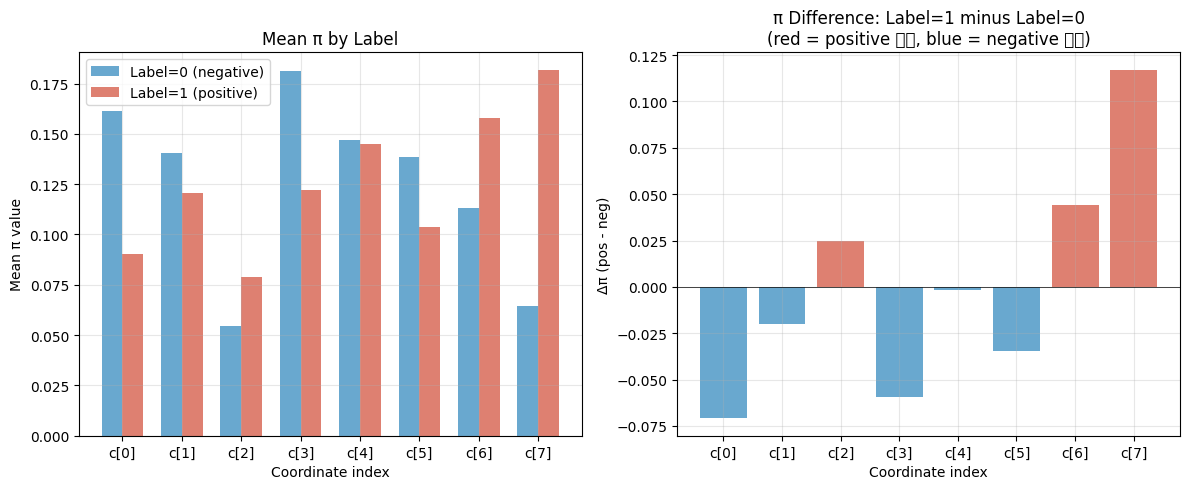


=== Label별 평균 π ===
Coord    π(y=0)       π(y=1)       Δπ           선호
-------------------------------------------------------
c[0]    0.1612       0.0904       -0.0709      Negative 선호
c[1]    0.1404       0.1205       -0.0200      Negative 선호
c[2]    0.0544       0.0790       +0.0246      Positive 선호
c[3]    0.1811       0.1219       -0.0592      Negative 선호
c[4]    0.1468       0.1452       -0.0017      중립
c[5]    0.1384       0.1039       -0.0345      Negative 선호
c[6]    0.1133       0.1577       +0.0444      Positive 선호
c[7]    0.0644       0.1815       +0.1172      Positive 선호


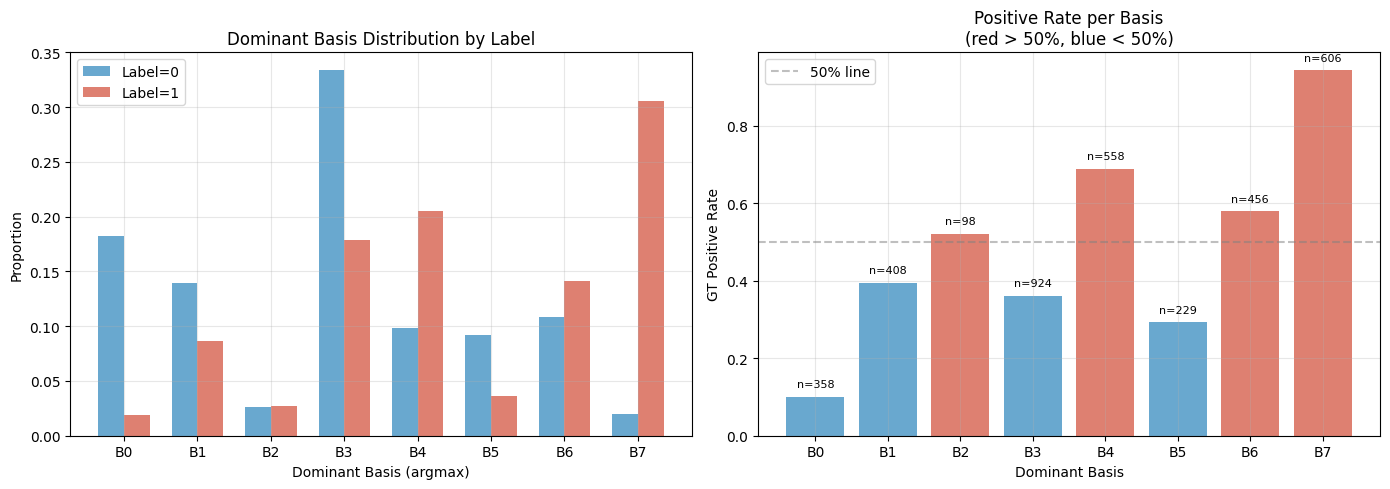


=== Dominant Basis별 Label 분포 ===
Basis    N(y=0)     N(y=1)     Total      pos_rate   주 배정 label
----------------------------------------------------------
B0      322        36         358        0.101      Label=0
B1      247        161        408        0.395      Label=0
B2      47         51         98         0.520      Label=1
B3      590        334        924        0.361      Label=0
B4      174        384        558        0.688      Label=1
B5      162        67         229        0.293      Label=0
B6      192        264        456        0.579      Label=1
B7      35         571        606        0.942      Label=1


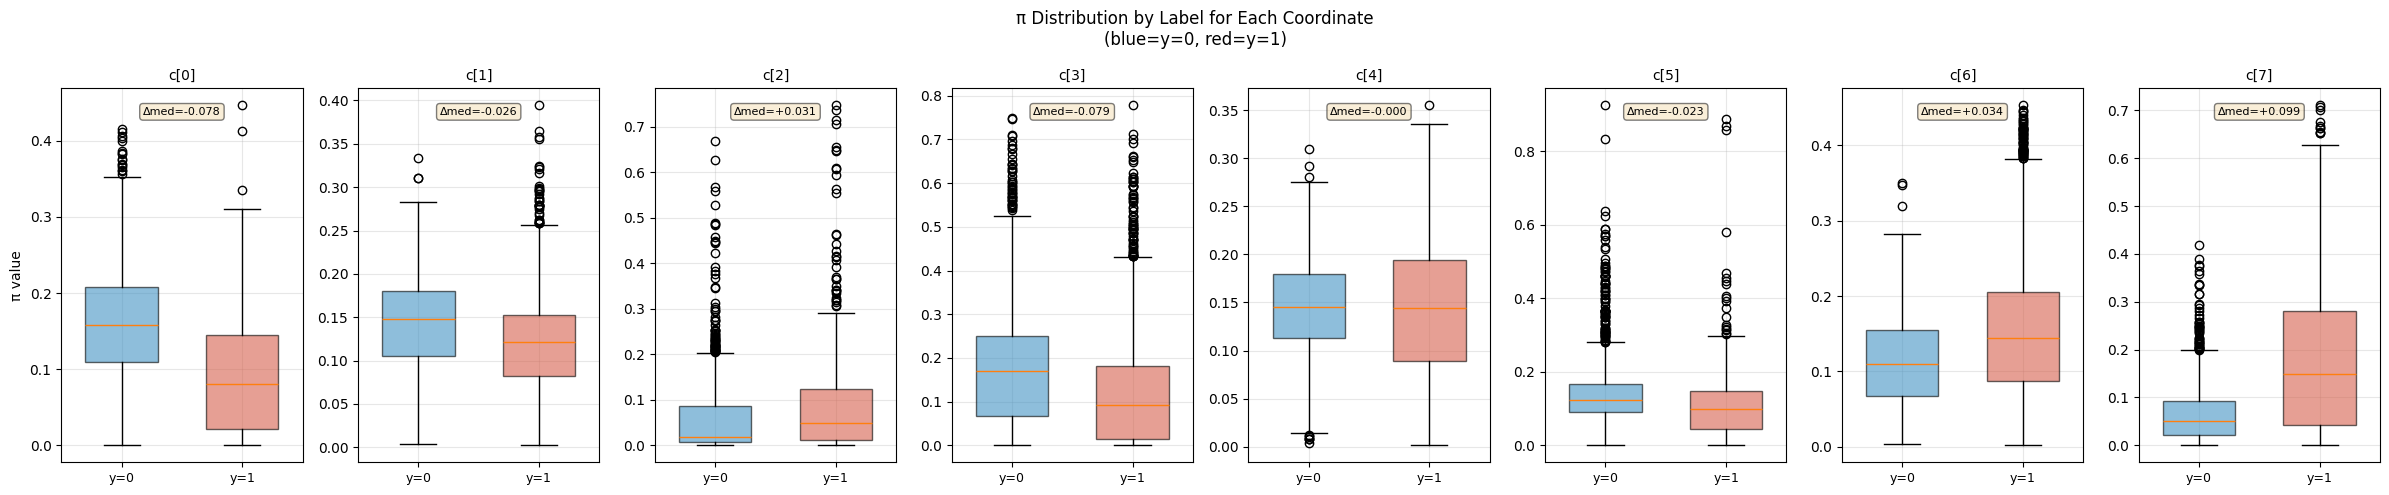

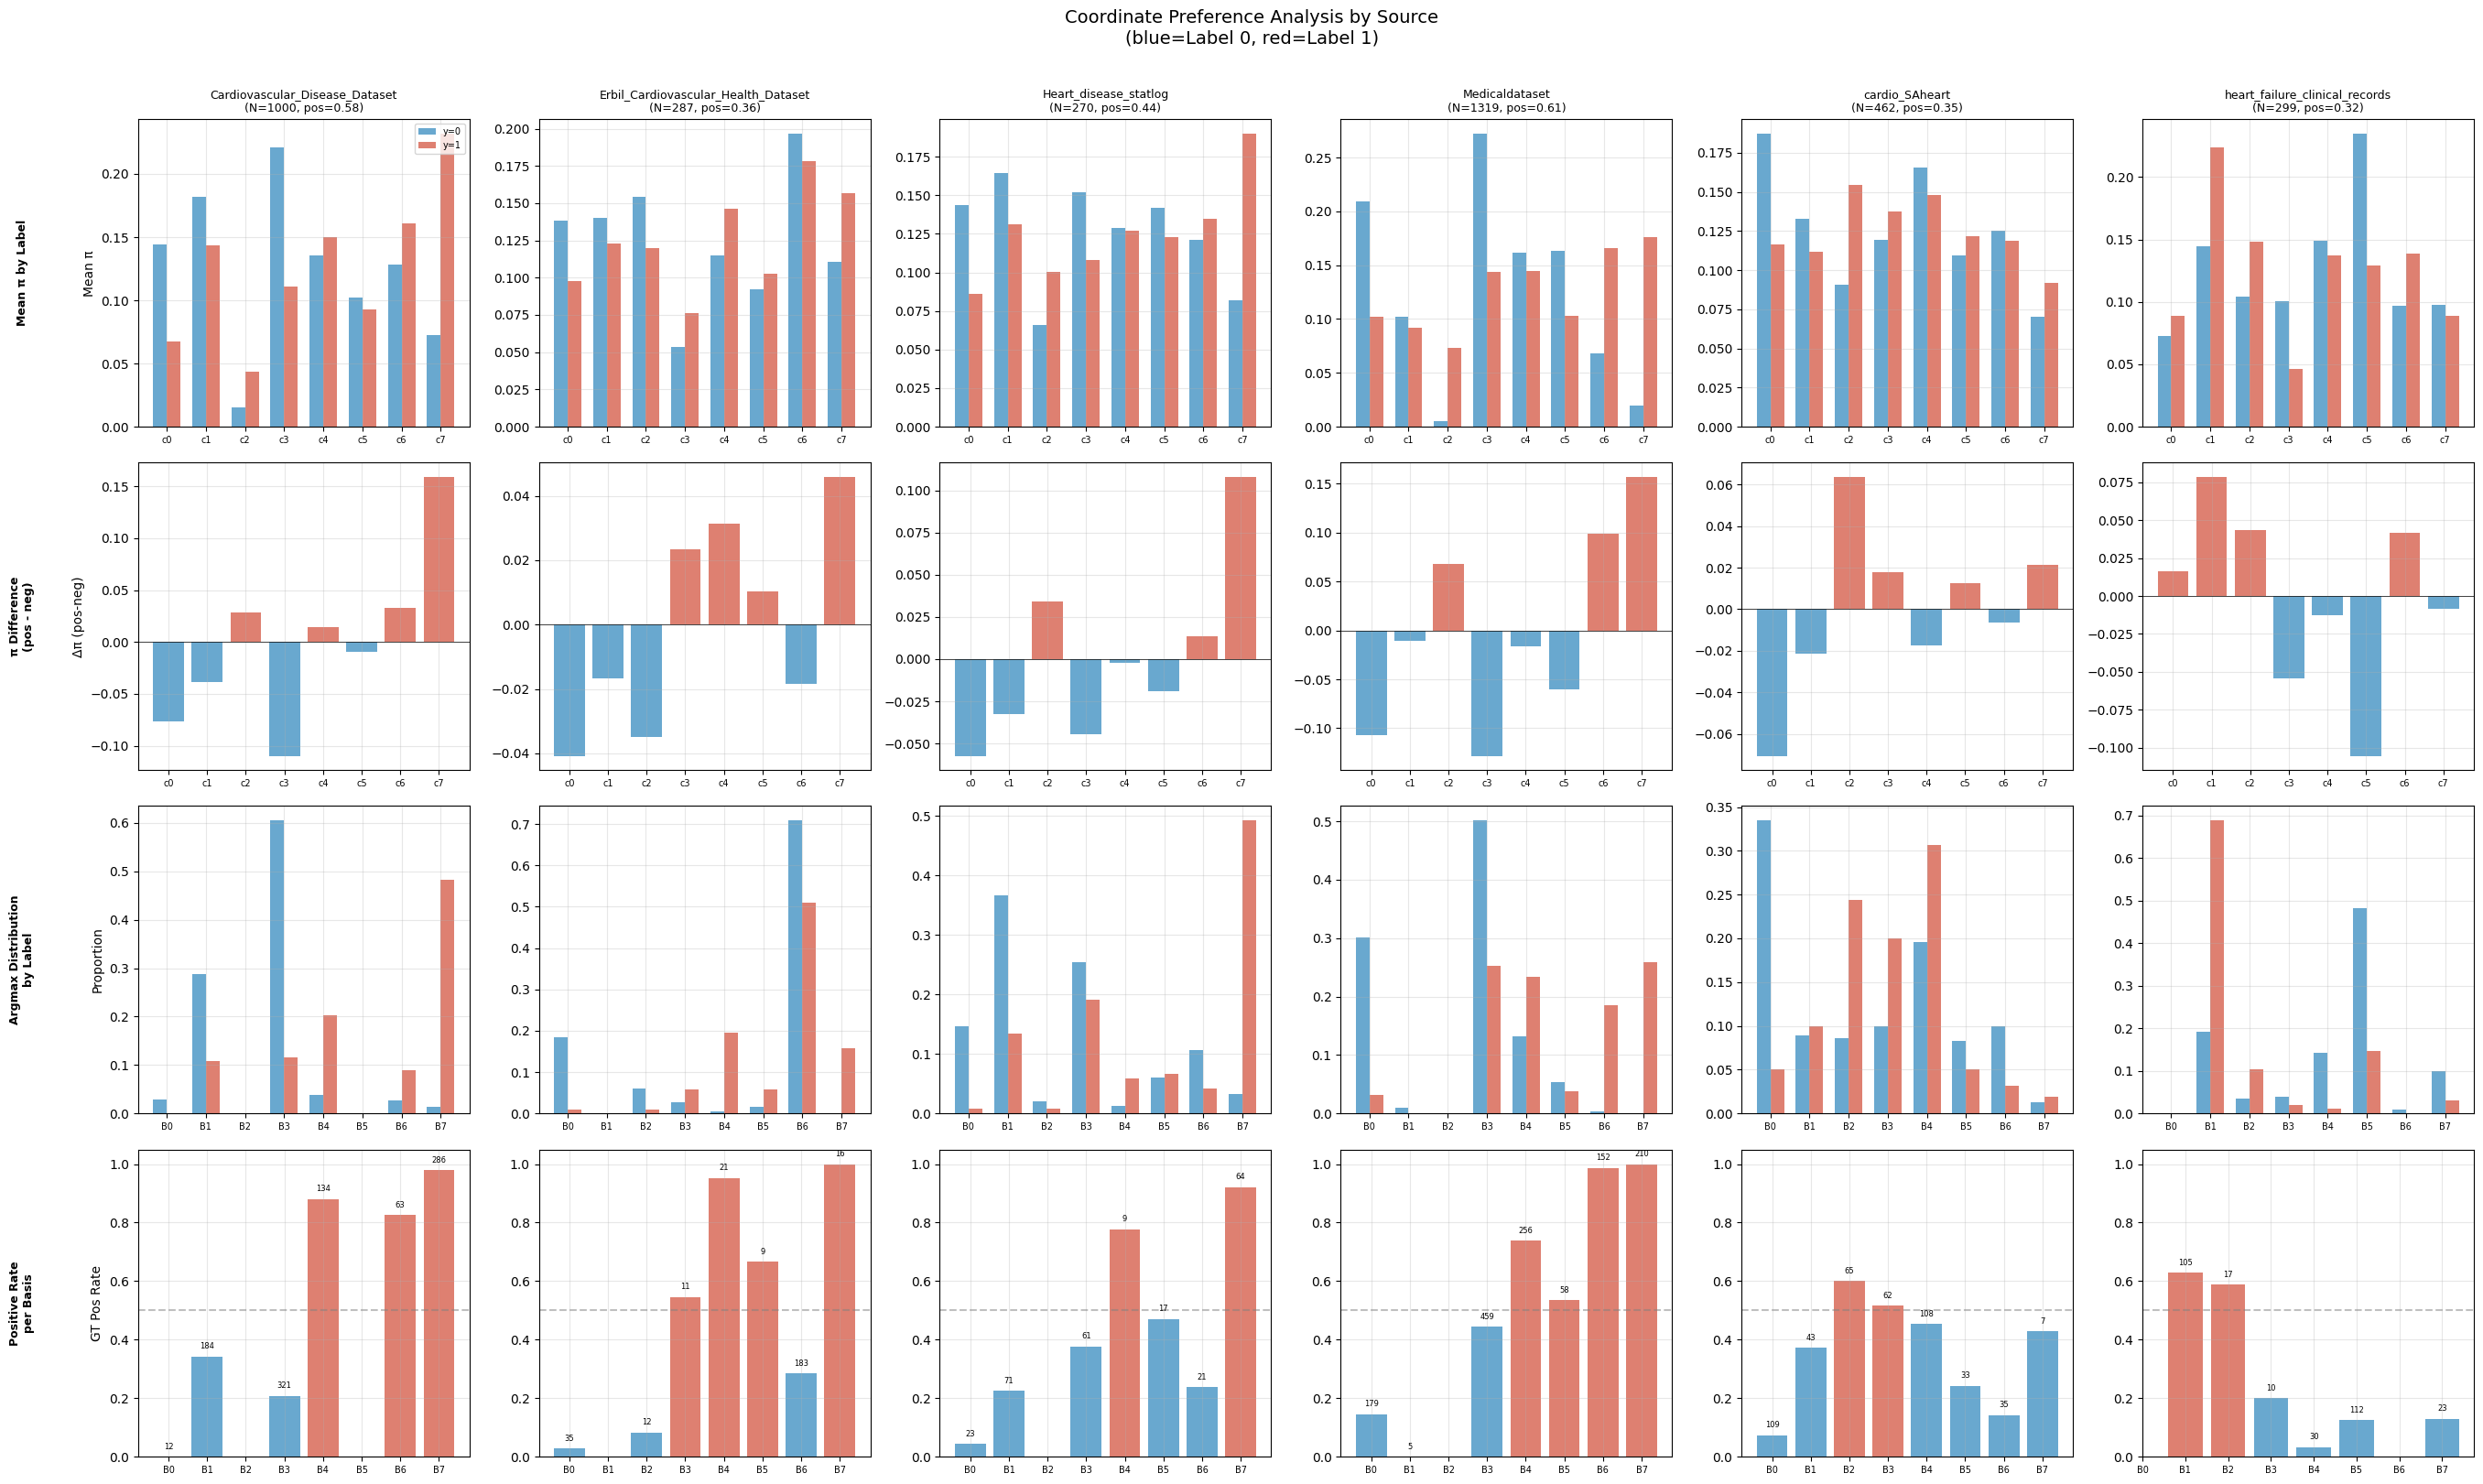

In [39]:
"""
Exp 3. Coordinate Preference Analysis by Label

질문: "label=0 샘플은 어떤 coordinate를 크게 받고, label=1은 어떤 coordinate를 크게 받는가?"

기존 ΔProb 분석은 "basis의 역할(positive/negative 방향)"을 봤지만,
이건 "샘플이 실제로 어떤 coordinate에 배정되는가"를 직접 봄.

- joint_model_pretrain, args, loaders, sources, device 이미 로딩된 상태
"""

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 1. π + label 수집
# ============================================================

@torch.no_grad()
def extract_pi_and_labels(model, loaders, sources, device):
    """전체 source에서 pi, y 수집"""
    model.eval()
    
    all_pi = []
    all_y = []
    all_src = []
    
    for src_name in sources:
        loader = loaders[src_name]
        for batch in loader:
            batch_t = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
            out = model.predict(batch_t, return_all=True)
            pi = model.graph_quantizer.last_pi
            
            all_pi.append(pi.cpu().numpy())
            all_y.append(batch_t['y'].cpu().view(-1).numpy())
            all_src.extend([src_name] * pi.shape[0])
    
    return {
        'pi': np.concatenate(all_pi, axis=0),
        'y': np.concatenate(all_y, axis=0).astype(int),
        'src': np.array(all_src),
    }


# ============================================================
# 2. Label별 평균 π 비교 (bar chart)
# ============================================================

def plot_mean_pi_by_label(data):
    """
    Label=0 vs Label=1의 평균 π 벡터 비교
    → 어떤 coordinate가 양성/음성에서 더 큰 값을 받는지
    """
    pi = data['pi']
    y = data['y']
    M = pi.shape[1]
    
    mean_pi_neg = pi[y == 0].mean(axis=0)
    mean_pi_pos = pi[y == 1].mean(axis=0)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # (a) 나란히 bar chart
    ax = axes[0]
    x = np.arange(M)
    width = 0.35
    ax.bar(x - width/2, mean_pi_neg, width, label='Label=0 (negative)', color='#4393c3', alpha=0.8)
    ax.bar(x + width/2, mean_pi_pos, width, label='Label=1 (positive)', color='#d6604d', alpha=0.8)
    ax.set_xlabel('Coordinate index')
    ax.set_ylabel('Mean π value')
    ax.set_title('Mean π by Label')
    ax.set_xticks(x)
    ax.set_xticklabels([f'c[{i}]' for i in range(M)])
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # (b) 차이 (pos - neg)
    ax = axes[1]
    diff = mean_pi_pos - mean_pi_neg
    colors = ['#d6604d' if d > 0 else '#4393c3' for d in diff]
    ax.bar(x, diff, color=colors, alpha=0.8)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_xlabel('Coordinate index')
    ax.set_ylabel('Δπ (pos - neg)')
    ax.set_title('π Difference: Label=1 minus Label=0\n(red = positive 선호, blue = negative 선호)')
    ax.set_xticks(x)
    ax.set_xticklabels([f'c[{i}]' for i in range(M)])
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 콘솔 출력
    print("\n=== Label별 평균 π ===")
    print(f"{'Coord':<8} {'π(y=0)':<12} {'π(y=1)':<12} {'Δπ':<12} {'선호'}")
    print("-" * 55)
    for k in range(M):
        pref = "Positive 선호" if diff[k] > 0.01 else ("Negative 선호" if diff[k] < -0.01 else "중립")
        print(f"c[{k}]    {mean_pi_neg[k]:<12.4f} {mean_pi_pos[k]:<12.4f} {diff[k]:<+12.4f} {pref}")


# ============================================================
# 3. Label별 argmax 분포 비교
# ============================================================

def plot_argmax_distribution_by_label(data):
    """
    Label=0 vs Label=1에서 dominant basis(argmax) 분포 비교
    → 음성 환자가 어떤 basis에 많이 배정되고, 양성 환자는 어디에 많이 배정되는지
    """
    pi = data['pi']
    y = data['y']
    M = pi.shape[1]
    argmax = pi.argmax(axis=1)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # (a) 비율 기반 비교
    ax = axes[0]
    x = np.arange(M)
    width = 0.35
    
    # 각 label의 argmax 비율
    neg_counts = np.zeros(M)
    pos_counts = np.zeros(M)
    for k in range(M):
        neg_counts[k] = ((argmax == k) & (y == 0)).sum()
        pos_counts[k] = ((argmax == k) & (y == 1)).sum()
    
    neg_ratio = neg_counts / neg_counts.sum()
    pos_ratio = pos_counts / pos_counts.sum()
    
    ax.bar(x - width/2, neg_ratio, width, label='Label=0', color='#4393c3', alpha=0.8)
    ax.bar(x + width/2, pos_ratio, width, label='Label=1', color='#d6604d', alpha=0.8)
    ax.set_xlabel('Dominant Basis (argmax)')
    ax.set_ylabel('Proportion')
    ax.set_title('Dominant Basis Distribution by Label')
    ax.set_xticks(x)
    ax.set_xticklabels([f'B{i}' for i in range(M)])
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # (b) Label=1 비율 (각 basis 내에서)
    ax = axes[1]
    pos_rate_per_basis = []
    for k in range(M):
        mask = (argmax == k)
        if mask.sum() > 0:
            pos_rate_per_basis.append(y[mask].mean())
        else:
            pos_rate_per_basis.append(0)
    
    colors = ['#d6604d' if pr > 0.5 else '#4393c3' for pr in pos_rate_per_basis]
    bars = ax.bar(x, pos_rate_per_basis, color=colors, alpha=0.8)
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='50% line')
    ax.set_xlabel('Dominant Basis')
    ax.set_ylabel('GT Positive Rate')
    ax.set_title('Positive Rate per Basis\n(red > 50%, blue < 50%)')
    ax.set_xticks(x)
    ax.set_xticklabels([f'B{i}' for i in range(M)])
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 각 bar 위에 샘플 수 표시
    for k, bar in enumerate(bars):
        n = int(neg_counts[k] + pos_counts[k])
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                f'n={n}', ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    # 콘솔 출력
    print("\n=== Dominant Basis별 Label 분포 ===")
    print(f"{'Basis':<8} {'N(y=0)':<10} {'N(y=1)':<10} {'Total':<10} {'pos_rate':<10} {'주 배정 label'}")
    print("-" * 58)
    for k in range(M):
        n0 = int(neg_counts[k])
        n1 = int(pos_counts[k])
        total = n0 + n1
        pr = pos_rate_per_basis[k]
        dominant = "Label=1" if pr > 0.5 else "Label=0"
        if total > 0:
            print(f"B{k:<6} {n0:<10} {n1:<10} {total:<10} {pr:<10.3f} {dominant}")


# ============================================================
# 4. π 분포 boxplot (label별)
# ============================================================

def plot_pi_distribution_by_label(data):
    """
    각 coordinate에 대해 label=0 vs label=1의 π 값 분포를 boxplot으로 비교
    → 평균뿐 아니라 분산까지 확인
    """
    pi = data['pi']
    y = data['y']
    M = pi.shape[1]
    
    fig, axes = plt.subplots(1, M, figsize=(3 * M, 5))
    if M == 1:
        axes = [axes]
    
    for k in range(M):
        ax = axes[k]
        
        pi_neg = pi[y == 0, k]
        pi_pos = pi[y == 1, k]
        
        bp = ax.boxplot([pi_neg, pi_pos], patch_artist=True, widths=0.6)
        colors = ['#4393c3', '#d6604d']
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.6)
        
        ax.set_xticklabels(['y=0', 'y=1'], fontsize=9)
        ax.set_title(f'c[{k}]', fontsize=10)
        ax.set_ylabel('π value' if k == 0 else '')
        ax.grid(True, alpha=0.3)
        
        # median 표시
        med_neg = np.median(pi_neg)
        med_pos = np.median(pi_pos)
        ax.text(0.5, 0.95, f'Δmed={med_pos - med_neg:+.3f}',
                transform=ax.transAxes, ha='center', va='top', fontsize=8,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    fig.suptitle('π Distribution by Label for Each Coordinate\n'
                 '(blue=y=0, red=y=1)', fontsize=12)
    plt.tight_layout()
    plt.show()


# ============================================================
# 5. Source별 4×N 그리드 (Mean π, Δπ, Argmax분포, Pos Rate)
# ============================================================

def plot_per_source_grid(data):
    """
    4 rows × N_sources columns
    Row 0: Mean π by Label
    Row 1: π Difference (pos - neg)
    Row 2: Dominant Basis Distribution by Label
    Row 3: Positive Rate per Basis
    """
    pi = data['pi']
    y = data['y']
    src = data['src']
    M = pi.shape[1]
    
    unique_sources = sorted(set(src))
    N_src = len(unique_sources)
    
    fig, axes = plt.subplots(4, N_src, figsize=(4.5 * N_src, 16))
    if N_src == 1:
        axes = axes[:, np.newaxis]
    
    for col, src_name in enumerate(unique_sources):
        mask = (src == src_name)
        pi_s = pi[mask]
        y_s = y[mask]
        argmax_s = pi_s.argmax(axis=1)
        
        n_total = mask.sum()
        n_pos = y_s.sum()
        n_neg = n_total - n_pos
        
        mean_pi_neg = pi_s[y_s == 0].mean(axis=0) if (y_s == 0).sum() > 0 else np.zeros(M)
        mean_pi_pos = pi_s[y_s == 1].mean(axis=0) if (y_s == 1).sum() > 0 else np.zeros(M)
        diff = mean_pi_pos - mean_pi_neg
        
        x = np.arange(M)
        width = 0.35
        
        # --- Row 0: Mean π by Label ---
        ax = axes[0, col]
        ax.bar(x - width/2, mean_pi_neg, width, color='#4393c3', alpha=0.8)
        ax.bar(x + width/2, mean_pi_pos, width, color='#d6604d', alpha=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels([f'c{i}' for i in range(M)], fontsize=7)
        ax.set_ylabel('Mean π' if col == 0 else '')
        # source 이름 짧게
        short_name = src_name.replace('_', '\n')[:25]
        ax.set_title(f'{src_name}\n(N={n_total}, pos={n_pos/n_total:.2f})', fontsize=9)
        ax.grid(True, alpha=0.3)
        if col == 0:
            ax.legend(['y=0', 'y=1'], fontsize=7, loc='upper right')
        
        # --- Row 1: Δπ ---
        ax = axes[1, col]
        colors = ['#d6604d' if d > 0 else '#4393c3' for d in diff]
        ax.bar(x, diff, color=colors, alpha=0.8)
        ax.axhline(0, color='black', linewidth=0.5)
        ax.set_xticks(x)
        ax.set_xticklabels([f'c{i}' for i in range(M)], fontsize=7)
        ax.set_ylabel('Δπ (pos-neg)' if col == 0 else '')
        ax.grid(True, alpha=0.3)
        
        # --- Row 2: Argmax Distribution by Label ---
        ax = axes[2, col]
        neg_counts = np.zeros(M)
        pos_counts = np.zeros(M)
        for k in range(M):
            neg_counts[k] = ((argmax_s == k) & (y_s == 0)).sum()
            pos_counts[k] = ((argmax_s == k) & (y_s == 1)).sum()
        
        neg_ratio = neg_counts / max(neg_counts.sum(), 1)
        pos_ratio = pos_counts / max(pos_counts.sum(), 1)
        
        ax.bar(x - width/2, neg_ratio, width, color='#4393c3', alpha=0.8)
        ax.bar(x + width/2, pos_ratio, width, color='#d6604d', alpha=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels([f'B{i}' for i in range(M)], fontsize=7)
        ax.set_ylabel('Proportion' if col == 0 else '')
        ax.grid(True, alpha=0.3)
        
        # --- Row 3: Positive Rate per Basis ---
        ax = axes[3, col]
        pos_rates = []
        ns = []
        for k in range(M):
            k_mask = (argmax_s == k)
            n_k = k_mask.sum()
            ns.append(n_k)
            if n_k >= 5:
                pos_rates.append(y_s[k_mask].mean())
            else:
                pos_rates.append(np.nan)
        
        bar_colors = ['#d6604d' if (not np.isnan(pr) and pr > 0.5) else '#4393c3' for pr in pos_rates]
        bars = ax.bar(x, pos_rates, color=bar_colors, alpha=0.8)
        ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
        ax.set_xticks(x)
        ax.set_xticklabels([f'B{i}' for i in range(M)], fontsize=7)
        ax.set_ylabel('GT Pos Rate' if col == 0 else '')
        ax.set_ylim(0, 1.05)
        ax.grid(True, alpha=0.3)
        
        for k, bar in enumerate(bars):
            if ns[k] >= 5:
                ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                        f'{ns[k]}', ha='center', va='bottom', fontsize=6)
    
    # Row labels
    row_labels = ['Mean π by Label', 'π Difference\n(pos - neg)', 
                  'Argmax Distribution\nby Label', 'Positive Rate\nper Basis']
    for i, label in enumerate(row_labels):
        axes[i, 0].annotate(label, xy=(-0.35, 0.5), xycoords='axes fraction',
                           fontsize=9, fontweight='bold', ha='center', va='center',
                           rotation=90)
    
    fig.suptitle('Coordinate Preference Analysis by Source\n'
                 '(blue=Label 0, red=Label 1)', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()


# ============================================================
# 6. 실행
# ============================================================

data = extract_pi_and_labels(joint_model_pretrain, loaders, sources, device)

# 전체 합산 분석
plot_mean_pi_by_label(data)
plot_argmax_distribution_by_label(data)
plot_pi_distribution_by_label(data)

# ★ Source별 분석
plot_per_source_grid(data)

Total samples: 3637, M=8

=== Subgroup별 GT Label 비율 ===
  Basis 0: N=358, GT positive rate=0.101
  Basis 1: N=408, GT positive rate=0.395
  Basis 2: N=98, GT positive rate=0.520
  Basis 3: N=924, GT positive rate=0.361
  Basis 4: N=558, GT positive rate=0.688
  Basis 5: N=229, GT positive rate=0.293
  Basis 6: N=456, GT positive rate=0.579
  Basis 7: N=606, GT positive rate=0.942


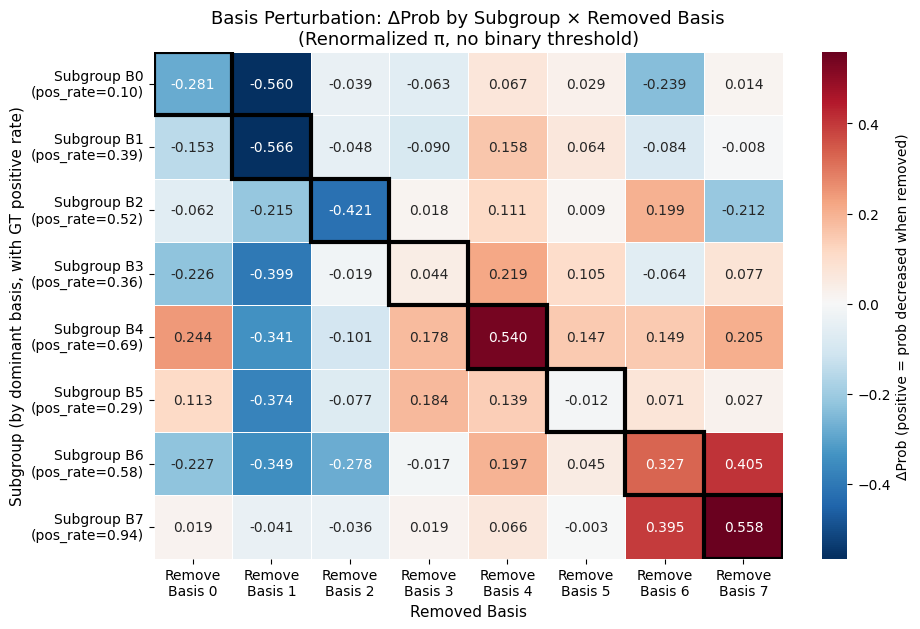


=== Diagonal vs Off-diagonal (|ΔProb|) ===
  Diagonal (dominant removed):  mean |ΔProb| = 0.3436
  Off-diagonal (other removed): mean |ΔProb| = 0.1428
  Ratio: 2.41x


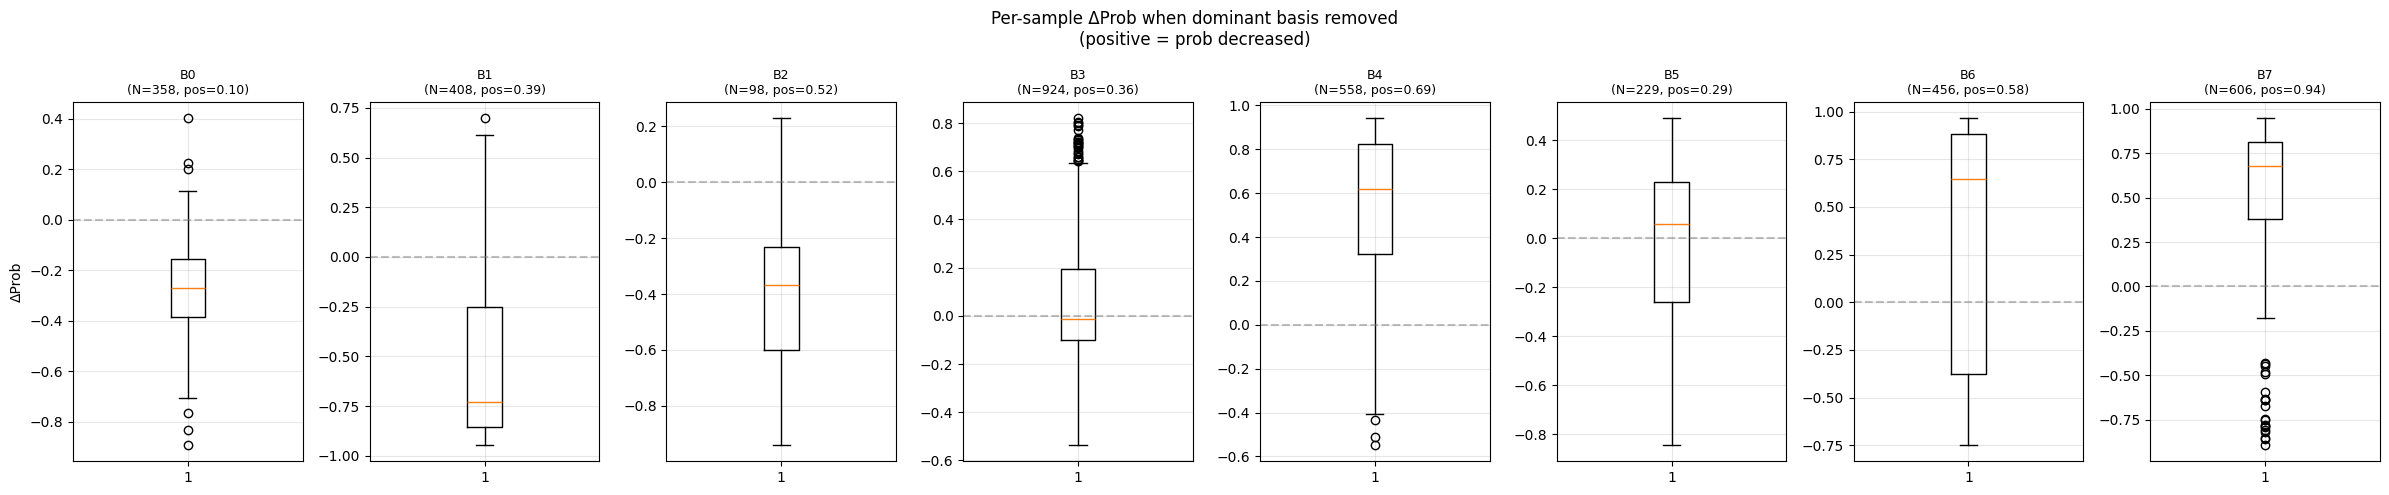


=== Basis 역할 분석 (ΔProb 방향 + GT positive rate) ===
Subgroup     GT pos_rate  Dominant ΔProb   해석
------------------------------------------------------------
  B0        0.101        -0.2814          negative 방향 기여 (제거시 prob↑)
  B1        0.395        -0.5661          negative 방향 기여 (제거시 prob↑)
  B2        0.520        -0.4205          negative 방향 기여 (제거시 prob↑)
  B3        0.361        0.0443           약한 기여
  B4        0.688        0.5396           positive 방향 기여 (제거시 prob↓)
  B5        0.293        -0.0116          약한 기여
  B6        0.579        0.3268           positive 방향 기여 (제거시 prob↓)
  B7        0.942        0.5585           positive 방향 기여 (제거시 prob↓)


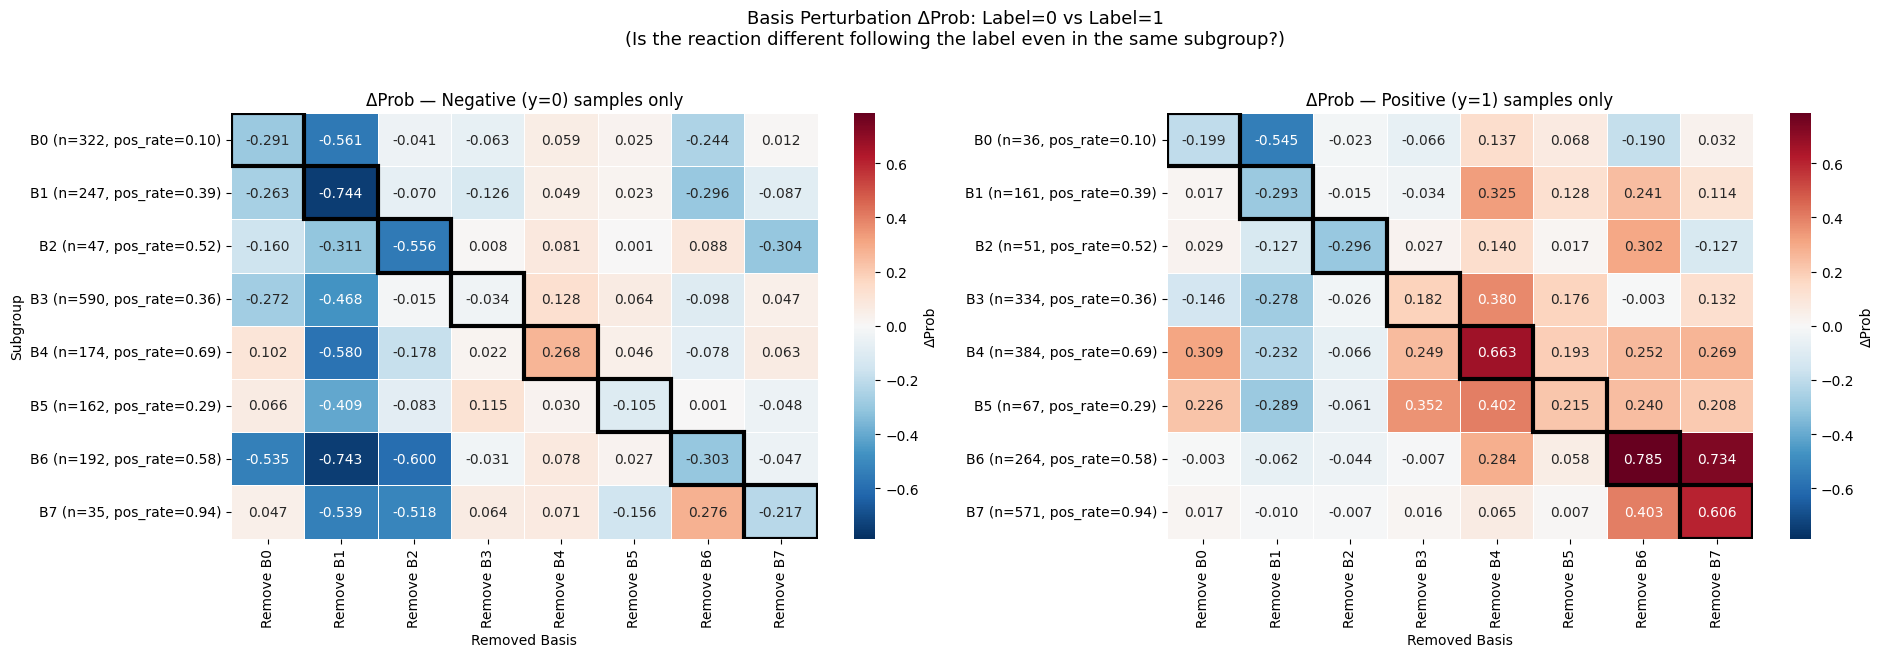

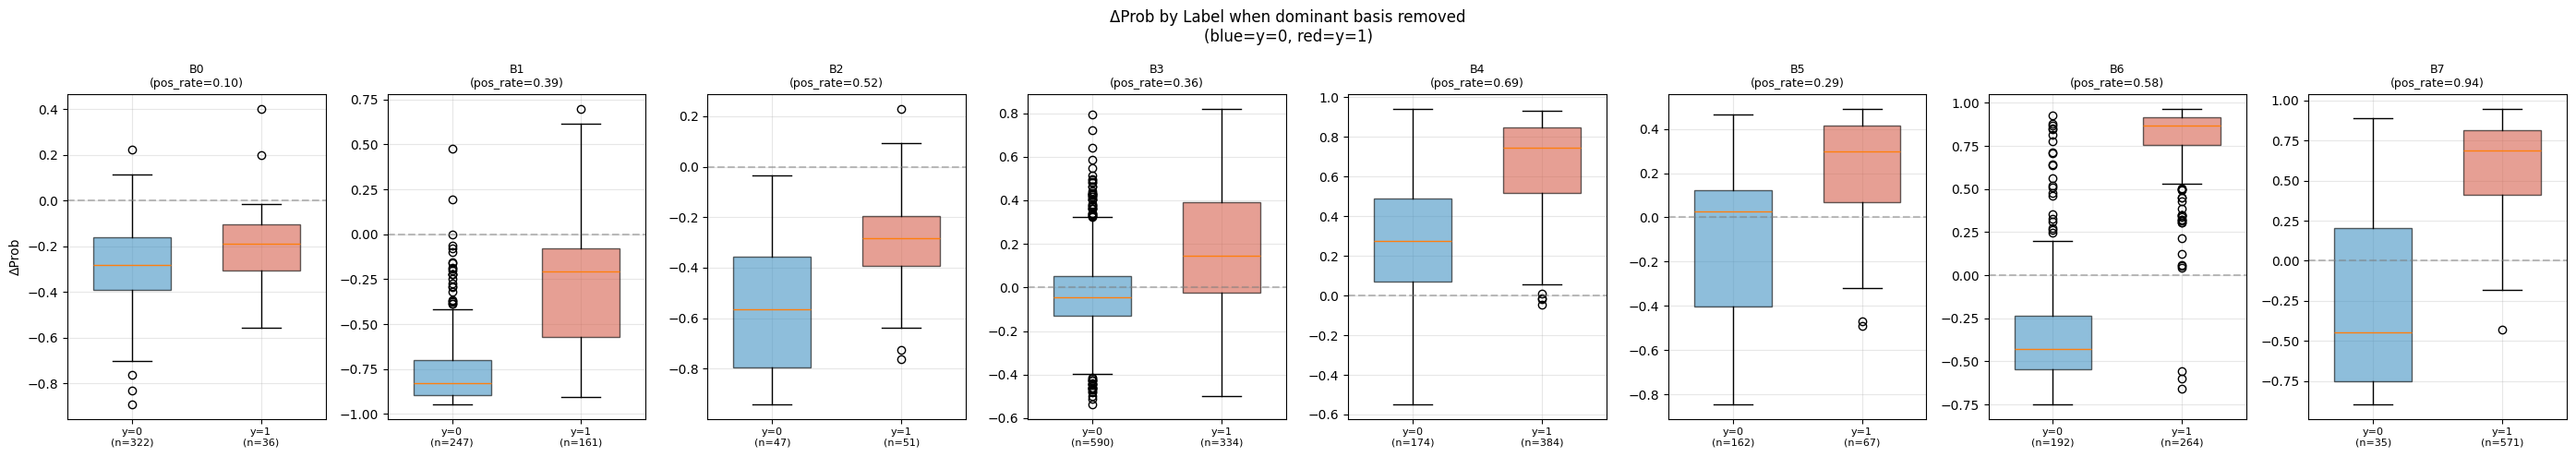


=== Label wise ΔProb (dominant basis Deletion) ===
Subgroup pos_rate   N(y=0)   ΔProb(y=0)   N(y=1)   ΔProb(y=1)   차이         해석
-----------------------------------------------------------------------------------------------
  B0     0.101      322      -0.2907      36       -0.1989      0.0918     label 무관하게 균일 기여
  B1     0.395      247      -0.7438      161      -0.2934      0.4504     y=1에 더 강하게 기여 → selective expert
  B2     0.520      47       -0.5556      51       -0.2961      0.2596     y=1에 더 강하게 기여 → selective expert
  B3     0.361      590      -0.0339      334      0.1823       0.2162     y=1에 더 강하게 기여 → selective expert
  B4     0.688      174      0.2681       384      0.6626       0.3945     y=1에 더 강하게 기여 → selective expert
  B5     0.293      162      -0.1052      67       0.2148       0.3200     y=1에 더 강하게 기여 → selective expert
  B6     0.579      192      -0.3032      264      0.7850       1.0883     y=1에 더 강하게 기여 → selective expert
  B7     0.942      35       -0.21

In [40]:
"""
Exp 1. Basis Perturbation (v2 — 교수님 피드백 반영)

변경사항:
1. ΔAcc → ΔProb (sigmoid probability 변화량, binary threshold 안 씀)
2. π[k]=0 후 renormalize (합=1 유지)
3. Subgroup별 GT label 비율 표시 (acc 대신)
4. Heatmap: prediction이 얼마나 바뀌는지를 직접 보여줌

- joint_model_pretrain, args, loaders, sources, device 이미 로딩된 상태
"""

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 1. Expert outputs + coordinates + probability 추출
# ============================================================

@torch.no_grad()
def extract_experts_and_coords(model, loader, device):
    """
    각 샘플에 대해:
    - expert_outputs: [B, M, D]
    - pi: [B, M]
    - y: [B] (GT label)
    - prob: [B] (sigmoid probability, continuous)
    """
    model.eval()
    
    all_expert_out = []
    all_pi = []
    all_y = []
    all_prob = []
    
    captured = {}
    def hook_fn(module, input, output):
        captured['expert_out'] = output.detach()
    
    handle = model.gnn_experts.register_forward_hook(hook_fn)
    
    for batch in loader:
        batch_t = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
        
        out = model.predict(batch_t, return_all=True)
        if isinstance(out, tuple):
            global_pred, local_pred = out
        else:
            global_pred = out
        
        pi = model.graph_quantizer.last_pi
        expert_out = captured['expert_out']
        
        # sigmoid probability (binary threshold 없이)
        prob = torch.sigmoid(global_pred).squeeze(-1)
        
        all_expert_out.append(expert_out.cpu())
        all_pi.append(pi.cpu())
        all_y.append(batch_t['y'].cpu().view(-1))
        all_prob.append(prob.cpu().view(-1))
    
    handle.remove()
    
    return (
        torch.cat(all_expert_out, dim=0),
        torch.cat(all_pi, dim=0),
        torch.cat(all_y, dim=0),
        torch.cat(all_prob, dim=0),
    )

# ============================================================
# 2. Perturbed probability 계산 (renormalize 포함)
# ============================================================

@torch.no_grad()
def compute_prob_with_perturbation(model, expert_outputs, pi, remove_basis=None):
    """
    Returns: prob [N] (sigmoid probability, continuous)
    
    π[k]=0 후 renormalize하여 합=1 유지
    """
    pi_perturbed = pi.clone()
    if remove_basis is not None:
        pi_perturbed[:, remove_basis] = 0.0
        # ★ renormalize: 나머지의 합이 1이 되도록
        row_sum = pi_perturbed.sum(dim=1, keepdim=True)
        # 합이 0인 경우 방지 (모든 basis가 0이면 uniform)
        row_sum = torch.clamp(row_sum, min=1e-8)
        pi_perturbed = pi_perturbed / row_sum
    
    # weighted sum: [N, D]
    weighted = (pi_perturbed.unsqueeze(-1) * expert_outputs).sum(dim=1)
    weighted = weighted.to(next(model.parameters()).device)
    
    current_mode = getattr(model, 'mode', 'Full')
    if current_mode == 'Few':
        logits = model.ghead2(weighted)
    else:
        logits = model.ghead(weighted)
    
    prob = torch.sigmoid(logits).squeeze(-1)
    return prob.cpu()

# ============================================================
# 3. 전체 source에 대해 perturbation 실험
# ============================================================

def run_perturbation_experiment_v2(model, loaders, sources, device):
    """ΔProb 기반 perturbation 실험"""
    
    all_expert = []
    all_pi = []
    all_y = []
    all_prob = []
    all_src = []
    
    for src_name in sources:
        loader = loaders[src_name]
        expert_out, pi, y, prob = extract_experts_and_coords(model, loader, device)
        all_expert.append(expert_out)
        all_pi.append(pi)
        all_y.append(y)
        all_prob.append(prob)
        all_src.extend([src_name] * len(y))
    
    expert_outputs = torch.cat(all_expert, dim=0)
    pis = torch.cat(all_pi, dim=0)
    ys = torch.cat(all_y, dim=0)
    orig_probs = torch.cat(all_prob, dim=0)
    
    M = pis.shape[1]
    argmax_basis = pis.numpy().argmax(axis=1)
    ys_np = ys.numpy().astype(int)
    orig_probs_np = orig_probs.numpy()
    
    print(f"Total samples: {len(ys_np)}, M={M}")
    
    # 각 basis를 제거한 probability
    perturbed_probs = {}
    for k in range(M):
        prob_k = compute_prob_with_perturbation(model, expert_outputs, pis, remove_basis=k)
        perturbed_probs[k] = prob_k.numpy()
    
    # Subgroup 정보
    active_bases = sorted(set(argmax_basis))
    active_bases = [b for b in active_bases if (argmax_basis == b).sum() >= 10]
    
    # 각 subgroup의 GT label 비율
    print("\n=== Subgroup별 GT Label 비율 ===")
    gt_pos_rates = {}
    for sg in active_bases:
        mask = (argmax_basis == sg)
        n = mask.sum()
        pos_rate = ys_np[mask].mean()
        gt_pos_rates[sg] = pos_rate
        print(f"  Basis {sg}: N={n}, GT positive rate={pos_rate:.3f}")
    
    return {
        'M': M,
        'active_bases': active_bases,
        'argmax_basis': argmax_basis,
        'ys': ys_np,
        'orig_probs': orig_probs_np,
        'perturbed_probs': perturbed_probs,
        'gt_pos_rates': gt_pos_rates,
        'all_src': np.array(all_src),
    }

# ============================================================
# 4. Heatmap: ΔProb (prediction 변화량)
# ============================================================

def plot_perturbation_delta_prob(result):
    """
    Heatmap: 각 subgroup에서 basis k를 제거했을 때 
    평균 probability가 얼마나 변하는지 (ΔProb)
    """
    M = result['M']
    active_bases = result['active_bases']
    argmax_basis = result['argmax_basis']
    orig_probs = result['orig_probs']
    perturbed_probs = result['perturbed_probs']
    gt_pos_rates = result['gt_pos_rates']
    
    delta_prob = np.zeros((len(active_bases), M))
    
    for i, sg in enumerate(active_bases):
        mask = (argmax_basis == sg)
        orig_mean = orig_probs[mask].mean()
        for k in range(M):
            pert_mean = perturbed_probs[k][mask].mean()
            delta_prob[i, k] = orig_mean - pert_mean  # 양수 = prob 감소 (basis가 positive 방향으로 기여)
    
    # Heatmap
    fig, ax = plt.subplots(1, 1, figsize=(max(8, M * 1.2), max(5, len(active_bases) * 0.8)))
    
    sns.heatmap(
        delta_prob,
        annot=True, fmt='.3f',
        xticklabels=[f'Remove\nBasis {k}' for k in range(M)],
        yticklabels=[f'Subgroup B{sg}\n(pos_rate={gt_pos_rates[sg]:.2f})' for sg in active_bases],
        cmap='RdBu_r',
        center=0,
        ax=ax,
        linewidths=0.5,
        cbar_kws={'label': 'ΔProb (positive = prob decreased when removed)'}
    )
    
    # 대각선 강조
    for i, sg in enumerate(active_bases):
        if sg < M:
            ax.add_patch(plt.Rectangle((sg, i), 1, 1, fill=False,
                                        edgecolor='black', linewidth=3))
    
    ax.set_title('Basis Perturbation: ΔProb by Subgroup × Removed Basis\n'
                 '(Renormalized π, no binary threshold)', fontsize=13)
    ax.set_xlabel('Removed Basis', fontsize=11)
    ax.set_ylabel('Subgroup (by dominant basis, with GT positive rate)', fontsize=11)
    
    plt.tight_layout()
    plt.show()
    
    # 대각선 vs 비대각선 비교
    diag_vals = []
    off_diag_vals = []
    for i, sg in enumerate(active_bases):
        for k in range(M):
            if sg == k:
                diag_vals.append(abs(delta_prob[i, k]))
            else:
                off_diag_vals.append(abs(delta_prob[i, k]))
    
    if diag_vals and off_diag_vals:
        print(f"\n=== Diagonal vs Off-diagonal (|ΔProb|) ===")
        print(f"  Diagonal (dominant removed):  mean |ΔProb| = {np.mean(diag_vals):.4f}")
        print(f"  Off-diagonal (other removed): mean |ΔProb| = {np.mean(off_diag_vals):.4f}")
        print(f"  Ratio: {np.mean(diag_vals) / (np.mean(off_diag_vals) + 1e-8):.2f}x")


# ============================================================
# 5. 개별 샘플의 probability shift 분포 (boxplot)
# ============================================================

def plot_prob_shift_distribution(result):
    """
    각 subgroup에서 dominant basis를 제거했을 때
    개별 샘플의 ΔProb 분포 (boxplot)
    → 평균뿐 아니라 분산도 볼 수 있음
    """
    M = result['M']
    active_bases = result['active_bases']
    argmax_basis = result['argmax_basis']
    orig_probs = result['orig_probs']
    perturbed_probs = result['perturbed_probs']
    gt_pos_rates = result['gt_pos_rates']
    
    fig, axes = plt.subplots(1, len(active_bases), 
                              figsize=(3 * len(active_bases), 5))
    if len(active_bases) == 1:
        axes = [axes]
    
    for idx, sg in enumerate(active_bases):
        ax = axes[idx]
        mask = (argmax_basis == sg)
        
        # dominant basis 제거 시 개별 ΔProb
        if sg < M:
            delta_individual = orig_probs[mask] - perturbed_probs[sg][mask]
        else:
            continue
        
        ax.boxplot(delta_individual, vert=True)
        ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
        ax.set_title(f'B{sg}\n(N={mask.sum()}, pos={gt_pos_rates[sg]:.2f})', fontsize=9)
        ax.set_ylabel('ΔProb' if idx == 0 else '')
        ax.grid(True, alpha=0.3)
    
    fig.suptitle('Per-sample ΔProb when dominant basis removed\n'
                 '(positive = prob decreased)', fontsize=12)
    plt.tight_layout()
    plt.show()


# ============================================================
# 6. GT positive rate에 따른 basis 역할 분석
# ============================================================

def plot_basis_role_analysis(result):
    """
    각 subgroup의 GT positive rate vs 
    basis 제거 시 ΔProb 방향으로 basis의 역할 파악
    
    ΔProb > 0: 이 basis는 positive 방향으로 기여 (제거하면 prob 감소)
    ΔProb < 0: 이 basis는 negative 방향으로 기여 (제거하면 prob 증가)
    """
    M = result['M']
    active_bases = result['active_bases']
    argmax_basis = result['argmax_basis']
    orig_probs = result['orig_probs']
    perturbed_probs = result['perturbed_probs']
    gt_pos_rates = result['gt_pos_rates']
    
    print("\n=== Basis 역할 분석 (ΔProb 방향 + GT positive rate) ===")
    print(f"{'Subgroup':<12} {'GT pos_rate':<12} {'Dominant ΔProb':<16} {'해석'}")
    print("-" * 60)
    
    for sg in active_bases:
        mask = (argmax_basis == sg)
        pos_rate = gt_pos_rates[sg]
        
        if sg < M:
            delta = orig_probs[mask].mean() - perturbed_probs[sg][mask].mean()
            
            if delta > 0.05:
                role = "positive 방향 기여 (제거시 prob↓)"
            elif delta < -0.05:
                role = "negative 방향 기여 (제거시 prob↑)"
            else:
                role = "약한 기여"
            
            print(f"  B{sg:<8} {pos_rate:<12.3f} {delta:<16.4f} {role}")


# ============================================================
# 7. Label별 ΔProb 분석 (label=0 vs label=1 분리)
# ============================================================

def plot_perturbation_by_label(result):
    """
    Heatmap 2개: label=0 샘플과 label=1 샘플에서
    basis 제거 시 ΔProb이 어떻게 다른지 비교
    
    → basis가 진짜 positive/negative 전문가인지 검증
    """
    M = result['M']
    active_bases = result['active_bases']
    argmax_basis = result['argmax_basis']
    ys = result['ys']
    orig_probs = result['orig_probs']
    perturbed_probs = result['perturbed_probs']
    gt_pos_rates = result['gt_pos_rates']
    
    delta_by_label = {}
    for label in [0, 1]:
        delta_mat = np.full((len(active_bases), M), np.nan)
        for i, sg in enumerate(active_bases):
            mask = (argmax_basis == sg) & (ys == label)
            n = mask.sum()
            if n < 5:  # 최소 5개 이상
                continue
            orig_mean = orig_probs[mask].mean()
            for k in range(M):
                pert_mean = perturbed_probs[k][mask].mean()
                delta_mat[i, k] = orig_mean - pert_mean
        delta_by_label[label] = delta_mat
    
    # --- Heatmap 2개 나란히 ---
    fig, axes = plt.subplots(1, 2, figsize=(max(16, M * 2.4), max(5, len(active_bases) * 0.8)))
    
    # 공통 color range
    all_vals = np.concatenate([delta_by_label[0].flatten(), delta_by_label[1].flatten()])
    all_vals = all_vals[~np.isnan(all_vals)]
    vmax = max(abs(all_vals.min()), abs(all_vals.max())) if len(all_vals) > 0 else 1
    
    for ax_idx, label in enumerate([0, 1]):
        ax = axes[ax_idx]
        mat = delta_by_label[label]
        
        # subgroup별 해당 label 샘플 수
        y_labels = []
        for sg in active_bases:
            mask = (argmax_basis == sg) & (ys == label)
            n = mask.sum()
            y_labels.append(f'B{sg} (n={n}, pos_rate={gt_pos_rates[sg]:.2f})')
        
        sns.heatmap(
            mat, annot=True, fmt='.3f',
            xticklabels=[f'Remove B{k}' for k in range(M)],
            yticklabels=y_labels,
            cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax,
            ax=ax, linewidths=0.5,
            mask=np.isnan(mat),
            cbar_kws={'label': 'ΔProb'}
        )
        
        # 대각선 강조
        for i, sg in enumerate(active_bases):
            if sg < M:
                ax.add_patch(plt.Rectangle((sg, i), 1, 1, fill=False,
                                            edgecolor='black', linewidth=3))
        
        label_name = 'Negative (y=0)' if label == 0 else 'Positive (y=1)'
        ax.set_title(f'ΔProb — {label_name} samples only', fontsize=12)
        ax.set_xlabel('Removed Basis')
        ax.set_ylabel('Subgroup' if ax_idx == 0 else '')
    
    fig.suptitle('Basis Perturbation ΔProb: Label=0 vs Label=1\n'
                 '(Is the reaction different following the label even in the same subgroup?)',
                 fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
    
    return delta_by_label


def plot_prob_shift_by_label(result):
    """
    Boxplot: 각 subgroup에서 dominant basis 제거 시
    label=0 vs label=1 샘플의 ΔProb 분포 비교
    
    → 같은 subgroup 내 positive/negative 환자가
       동일 basis 제거에 다르게 반응하는지
    """
    M = result['M']
    active_bases = result['active_bases']
    argmax_basis = result['argmax_basis']
    ys = result['ys']
    orig_probs = result['orig_probs']
    perturbed_probs = result['perturbed_probs']
    gt_pos_rates = result['gt_pos_rates']
    
    fig, axes = plt.subplots(1, len(active_bases),
                              figsize=(3.5 * len(active_bases), 5))
    if len(active_bases) == 1:
        axes = [axes]
    
    for idx, sg in enumerate(active_bases):
        ax = axes[idx]
        if sg >= M:
            continue
        
        mask_all = (argmax_basis == sg)
        delta_all = orig_probs[mask_all] - perturbed_probs[sg][mask_all]
        labels_sg = ys[mask_all]
        
        # label별 분리
        delta_neg = delta_all[labels_sg == 0]
        delta_pos = delta_all[labels_sg == 1]
        
        data_to_plot = []
        tick_labels = []
        colors = []
        
        if len(delta_neg) >= 3:
            data_to_plot.append(delta_neg)
            tick_labels.append(f'y=0\n(n={len(delta_neg)})')
            colors.append('#4393c3')  # blue
        if len(delta_pos) >= 3:
            data_to_plot.append(delta_pos)
            tick_labels.append(f'y=1\n(n={len(delta_pos)})')
            colors.append('#d6604d')  # red
        
        if data_to_plot:
            bp = ax.boxplot(data_to_plot, vert=True, patch_artist=True,
                           widths=0.6)
            for patch, color in zip(bp['boxes'], colors):
                patch.set_facecolor(color)
                patch.set_alpha(0.6)
            ax.set_xticklabels(tick_labels, fontsize=8)
        
        ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
        ax.set_title(f'B{sg}\n(pos_rate={gt_pos_rates[sg]:.2f})', fontsize=9)
        ax.set_ylabel('ΔProb' if idx == 0 else '')
        ax.grid(True, alpha=0.3)
    
    fig.suptitle('ΔProb by Label when dominant basis removed\n'
                 '(blue=y=0, red=y=1)', fontsize=12)
    plt.tight_layout()
    plt.show()


def print_label_separated_summary(result):
    """Label별 ΔProb 요약 테이블"""
    M = result['M']
    active_bases = result['active_bases']
    argmax_basis = result['argmax_basis']
    ys = result['ys']
    orig_probs = result['orig_probs']
    perturbed_probs = result['perturbed_probs']
    gt_pos_rates = result['gt_pos_rates']
    
    print("\n=== Label wise ΔProb (dominant basis Deletion) ===")
    print(f"{'Subgroup':<8} {'pos_rate':<10} {'N(y=0)':<8} {'ΔProb(y=0)':<12} "
          f"{'N(y=1)':<8} {'ΔProb(y=1)':<12} {'차이':<10} {'해석'}")
    print("-" * 95)
    
    for sg in active_bases:
        if sg >= M:
            continue
        mask = (argmax_basis == sg)
        pos_rate = gt_pos_rates[sg]
        
        delta_all = orig_probs[mask] - perturbed_probs[sg][mask]
        labels_sg = ys[mask]
        
        n0 = (labels_sg == 0).sum()
        n1 = (labels_sg == 1).sum()
        
        d0 = delta_all[labels_sg == 0].mean() if n0 >= 3 else float('nan')
        d1 = delta_all[labels_sg == 1].mean() if n1 >= 3 else float('nan')
        
        diff = d1 - d0 if not (np.isnan(d0) or np.isnan(d1)) else float('nan')
        
        # 해석
        if np.isnan(diff):
            interp = "샘플 부족"
        elif diff > 0.1:
            interp = "y=1에 더 강하게 기여 → selective expert"
        elif diff < -0.1:
            interp = "y=0에 더 강하게 기여 → inverse pattern"
        else:
            interp = "label 무관하게 균일 기여"
        
        print(f"  B{sg:<5} {pos_rate:<10.3f} {n0:<8} {d0:<12.4f} "
              f"{n1:<8} {d1:<12.4f} {diff:<10.4f} {interp}")


# ============================================================
# 8. 실행
# ============================================================
result = run_perturbation_experiment_v2(joint_model_pretrain, loaders, sources, device)

# 기존 분석
plot_perturbation_delta_prob(result)
plot_prob_shift_distribution(result)
plot_basis_role_analysis(result)

# ★ 추가: label별 분리 분석
delta_by_label = plot_perturbation_by_label(result)
plot_prob_shift_by_label(result)
print_label_separated_summary(result)


[Medicaldataset] Original shape: (1319, 8), Features: ['Age', 'Gender', 'Heart rate', 'Systolic blood pressure', 'Diastolic blood pressure', 'Blood sugar', 'CK-MB', 'Troponin']



[Medicaldataset] Subgroup별 GT Label 비율
  Basis 0: N=179, Label=1: 26/179 (0.145)
  Basis 3: N=459, Label=1: 204/459 (0.444)
  Basis 4: N=256, Label=1: 189/256 (0.738)
  Basis 5: N=58, Label=1: 31/58 (0.534)
  Basis 6: N=152, Label=1: 150/152 (0.987)
  Basis 7: N=210, Label=1: 210/210 (1.000)
  Overall positive rate: 0.614
  Positive rate range: 0.855


/tmp/ipykernel_1808760/752000701.py:210: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_sg, labels=labels_sg, patch_artist=True)
/tmp/ipykernel_1808760/752000701.py:210: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_sg, labels=labels_sg, patch_artist=True)
/tmp/ipykernel_1808760/752000701.py:210: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_sg, labels=labels_sg, patch_artist=True)
/tmp/ipykernel_1808760/752000701.py:210: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; suppor

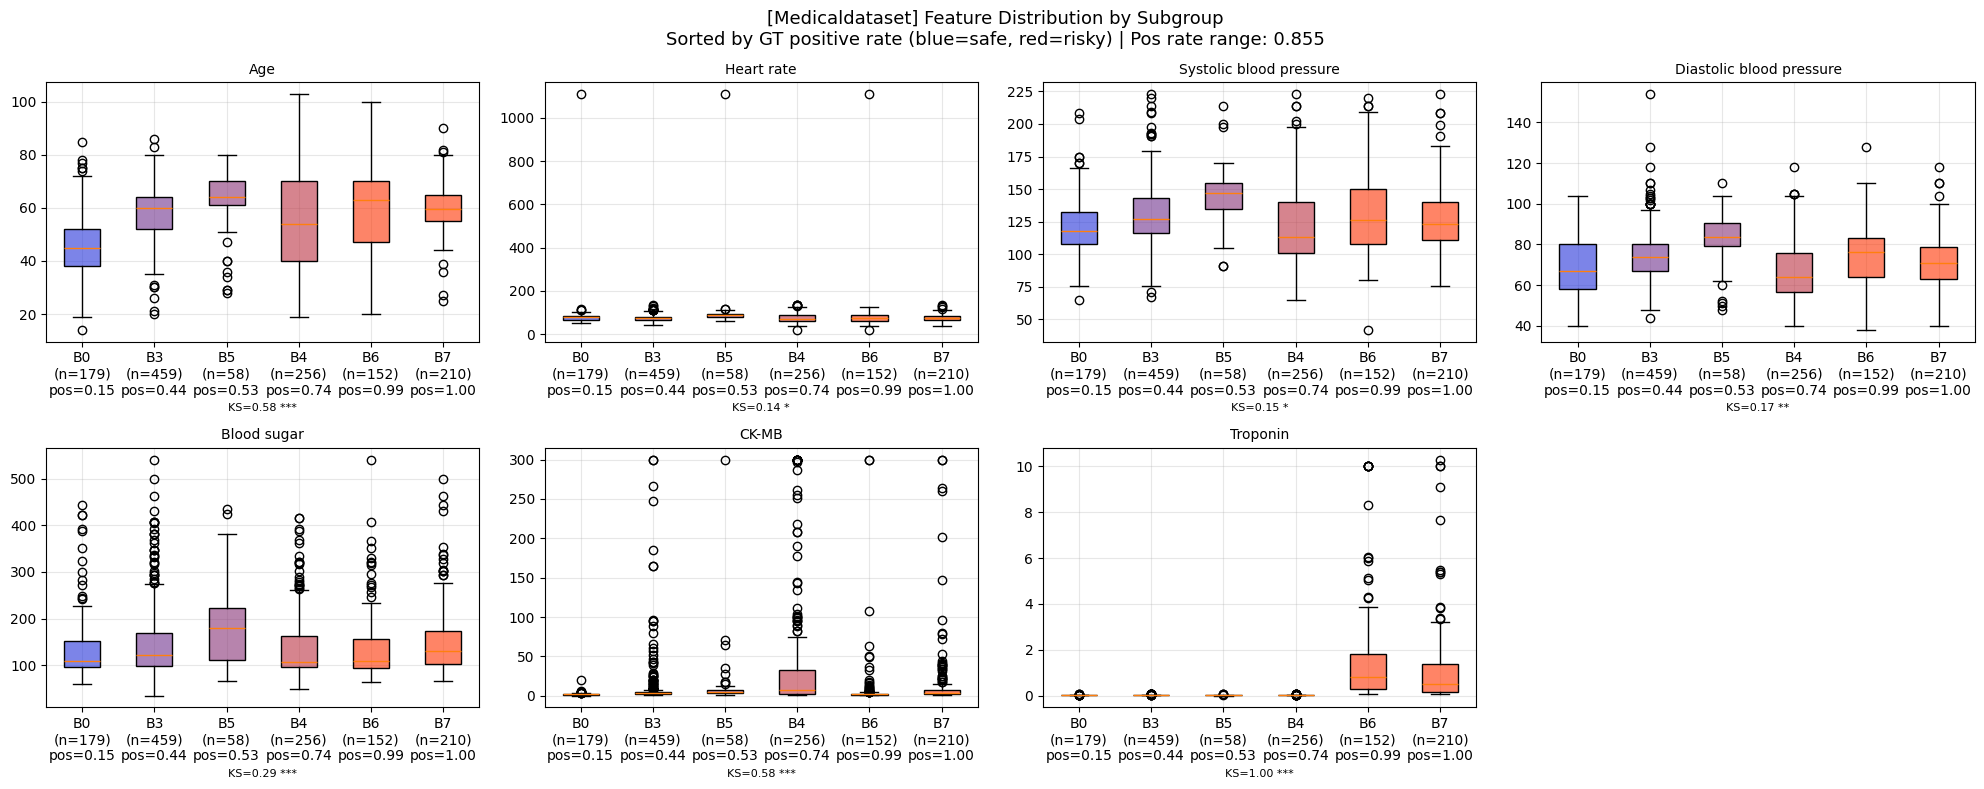


[Medicaldataset] Feature Risk Summary
  Safest subgroup: B0 (pos_rate=0.145)
  Riskiest subgroup: B7 (pos_rate=1.000)

  Feature                        Safe median     Risky median    Direction  KS
  -------------------------------------------------------------------------------------
  Age                            45.00           59.50           ↑          0.58 ***
  Heart rate                     79.00           74.00           ↓          0.14 *
  Systolic blood pressure        118.00          123.50          ↑          0.15 *
  Diastolic blood pressure       67.00           71.00           ↑          0.17 **
  Blood sugar                    108.00          130.00          ↑          0.29 ***
  CK-MB                          1.70            3.45            ↑          0.58 ***
  Troponin                       0.01            0.50            ↑          1.00 ***

[Cardiovascular_Disease_Dataset] Original shape: (1000, 13), Features: ['patientid', 'age', 'gender', 'chestpain', 'restin

/tmp/ipykernel_1808760/752000701.py:210: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_sg, labels=labels_sg, patch_artist=True)
/tmp/ipykernel_1808760/752000701.py:210: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_sg, labels=labels_sg, patch_artist=True)
/tmp/ipykernel_1808760/752000701.py:210: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_sg, labels=labels_sg, patch_artist=True)
/tmp/ipykernel_1808760/752000701.py:210: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; suppor

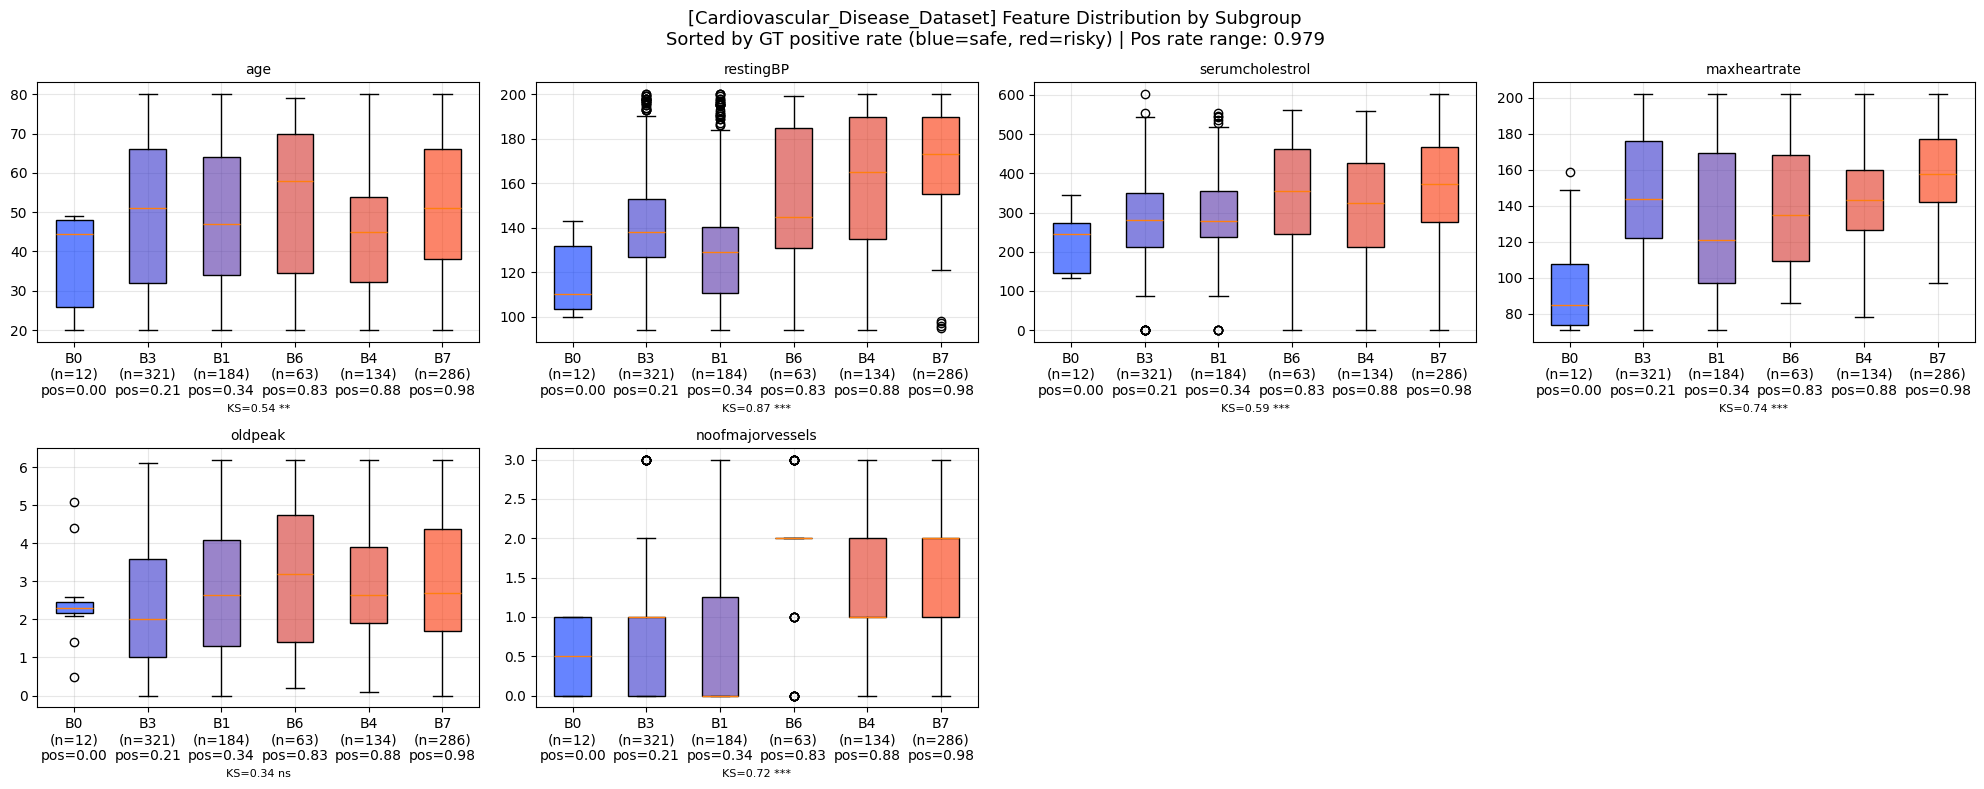


[Cardiovascular_Disease_Dataset] Feature Risk Summary
  Safest subgroup: B0 (pos_rate=0.000)
  Riskiest subgroup: B7 (pos_rate=0.979)

  Feature                        Safe median     Risky median    Direction  KS
  -------------------------------------------------------------------------------------
  age                            44.50           51.00           ↑          0.54 **
  restingBP                      110.00          173.00          ↑          0.87 ***
  serumcholestrol                244.50          372.00          ↑          0.59 ***
  maxheartrate                   85.00           157.50          ↑          0.74 ***
  oldpeak                        2.30            2.70            ↑          0.34 ns
  noofmajorvessels               0.50            2.00            ↑          0.72 ***

[Heart_disease_statlog] Original shape: (270, 13), Features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

[Heart_diseas

/tmp/ipykernel_1808760/752000701.py:210: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_sg, labels=labels_sg, patch_artist=True)
/tmp/ipykernel_1808760/752000701.py:210: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_sg, labels=labels_sg, patch_artist=True)
/tmp/ipykernel_1808760/752000701.py:210: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_sg, labels=labels_sg, patch_artist=True)
/tmp/ipykernel_1808760/752000701.py:210: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; suppor

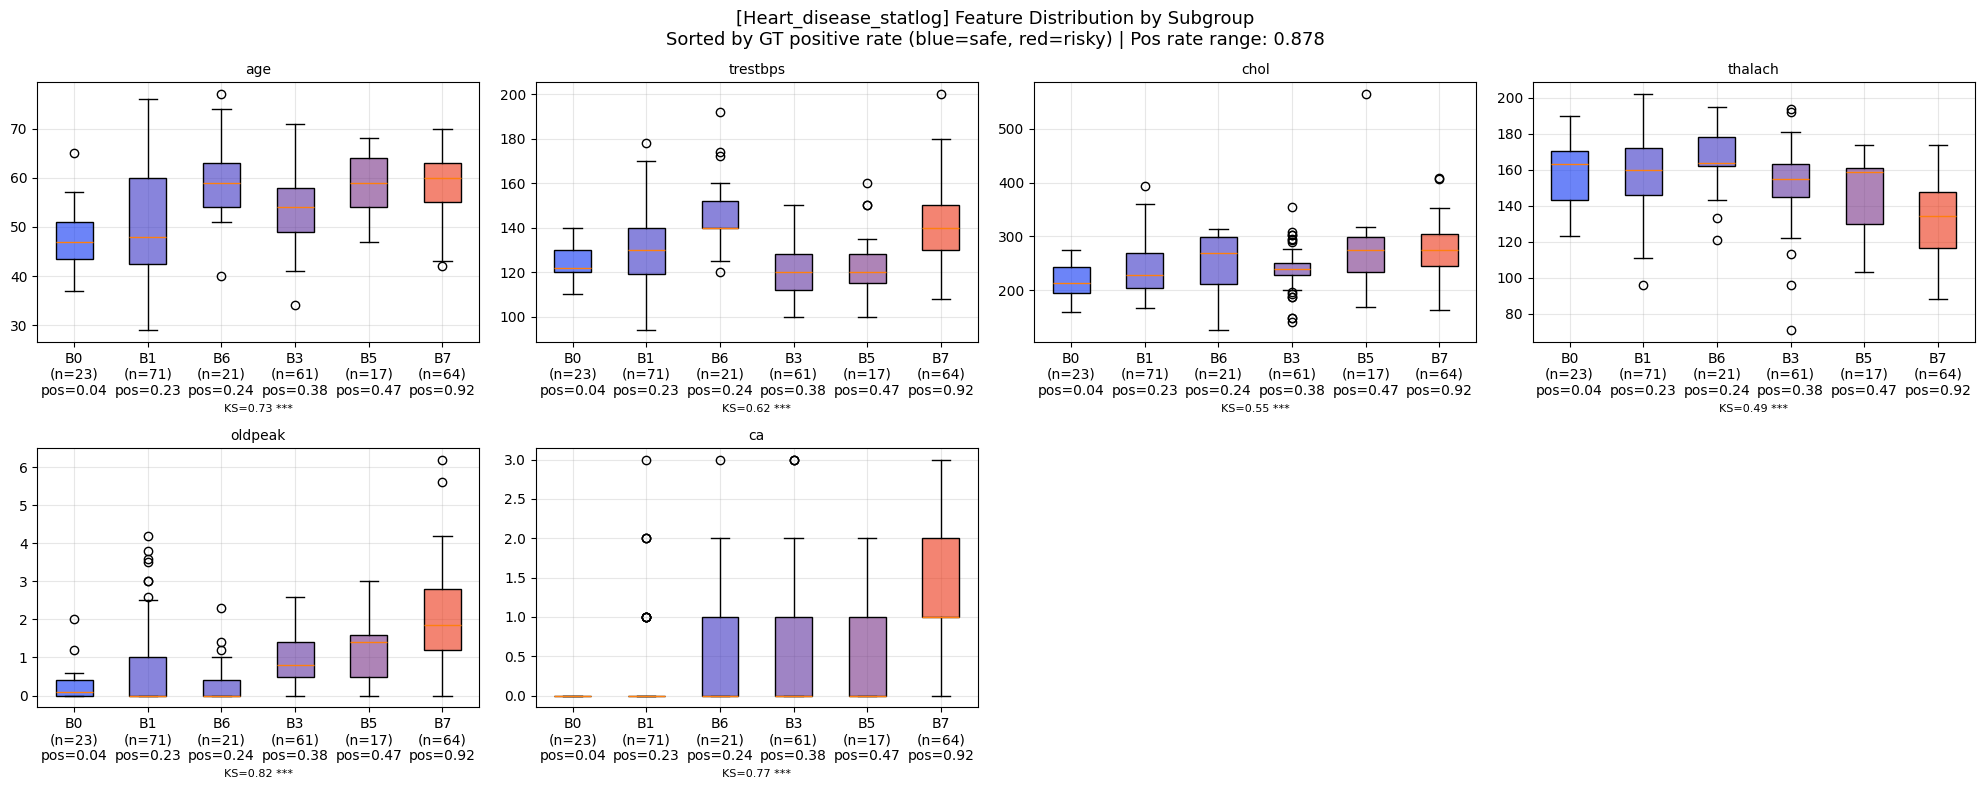


[Heart_disease_statlog] Feature Risk Summary
  Safest subgroup: B0 (pos_rate=0.043)
  Riskiest subgroup: B7 (pos_rate=0.922)

  Feature                        Safe median     Risky median    Direction  KS
  -------------------------------------------------------------------------------------
  age                            47.00           60.00           ↑          0.73 ***
  trestbps                       122.00          140.00          ↑          0.62 ***
  chol                           214.00          274.00          ↑          0.55 ***
  thalach                        163.00          134.50          ↓          0.49 ***
  oldpeak                        0.10            1.85            ↑          0.82 ***
  ca                             0.00            1.00            ↑          0.77 ***

[Erbil_Cardiovascular_Health_Dataset] Original shape: (287, 20), Features: ['AGE', 'SEX', 'HEIGHT', 'WEIGHT', 'LIFESTYLE', 'FAMILY_HISTORY', 'PHYSICALLY_ACTIVE', 'SMOKING', 'YEARS_SMOKING', 'DIAB

/tmp/ipykernel_1808760/752000701.py:210: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_sg, labels=labels_sg, patch_artist=True)
/tmp/ipykernel_1808760/752000701.py:210: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_sg, labels=labels_sg, patch_artist=True)
/tmp/ipykernel_1808760/752000701.py:210: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_sg, labels=labels_sg, patch_artist=True)
/tmp/ipykernel_1808760/752000701.py:210: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; suppor

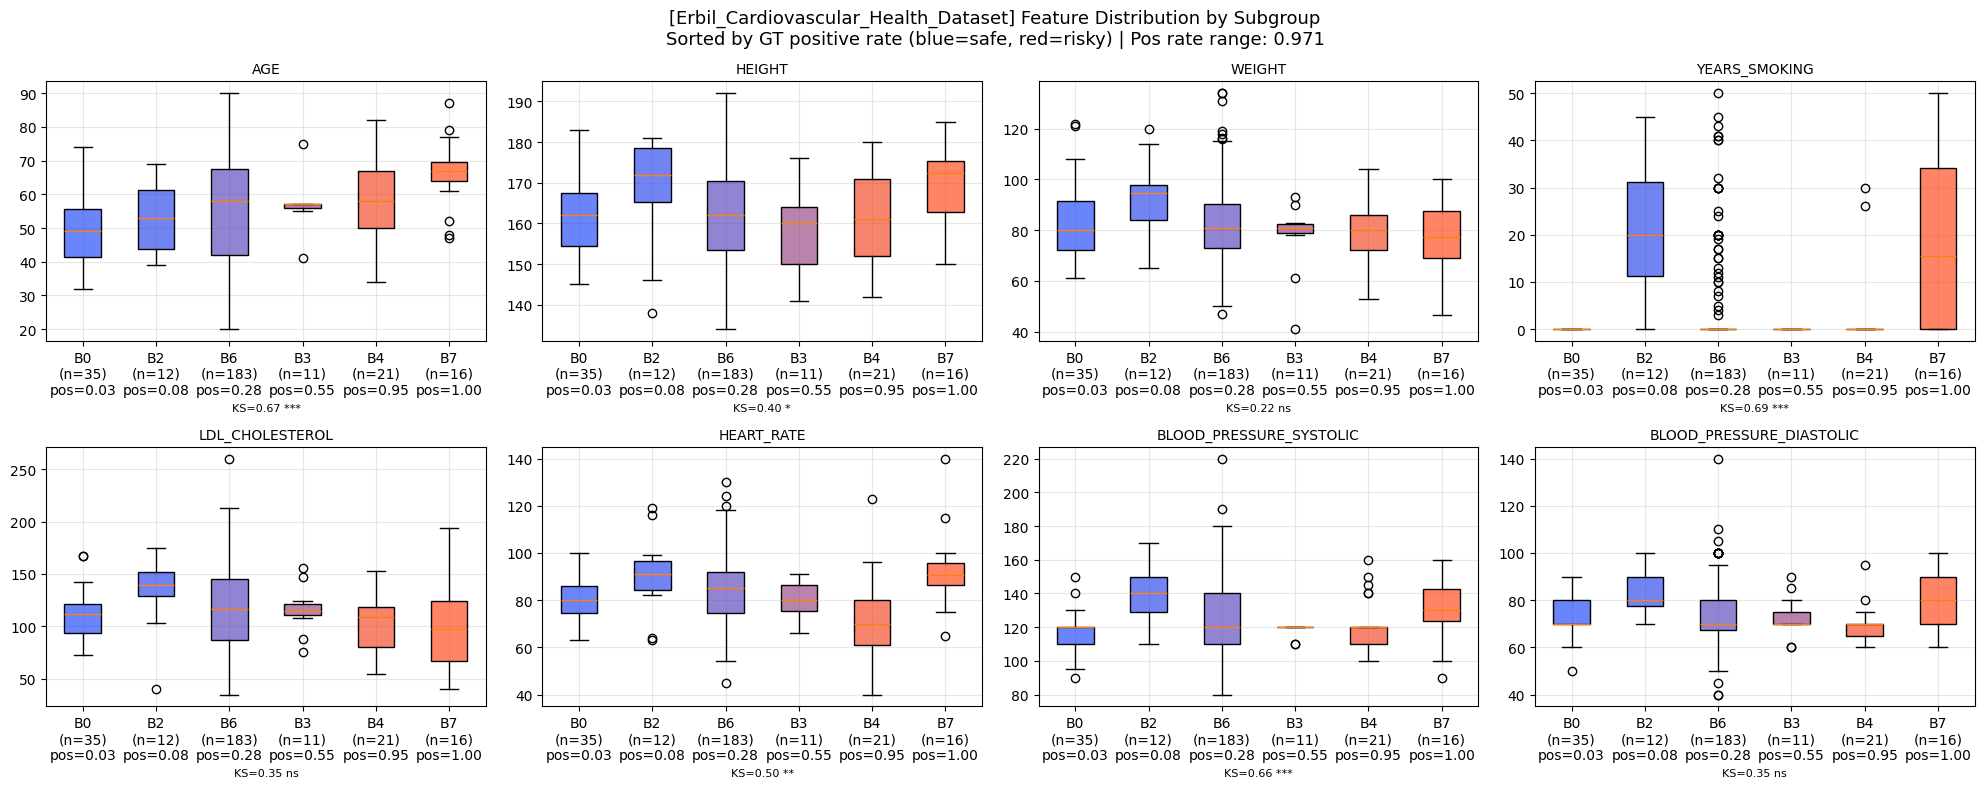


[Erbil_Cardiovascular_Health_Dataset] Feature Risk Summary
  Safest subgroup: B0 (pos_rate=0.029)
  Riskiest subgroup: B7 (pos_rate=1.000)

  Feature                        Safe median     Risky median    Direction  KS
  -------------------------------------------------------------------------------------
  AGE                            49.00           67.00           ↑          0.67 ***
  HEIGHT                         162.00          172.50          ↑          0.40 *
  WEIGHT                         80.00           77.50           ↓          0.22 ns
  YEARS_SMOKING                  0.00            15.50           ↑          0.69 ***
  LDL_CHOLESTEROL                112.00          97.75           ↓          0.35 ns
  HEART_RATE                     80.00           90.50           ↑          0.50 **
  BLOOD_PRESSURE_SYSTOLIC        120.00          130.00          ↑          0.66 ***
  BLOOD_PRESSURE_DIASTOLIC       70.00           80.00           ↑          0.35 ns

[cardio_SAheart] 

/tmp/ipykernel_1808760/752000701.py:210: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_sg, labels=labels_sg, patch_artist=True)
/tmp/ipykernel_1808760/752000701.py:210: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_sg, labels=labels_sg, patch_artist=True)
/tmp/ipykernel_1808760/752000701.py:210: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_sg, labels=labels_sg, patch_artist=True)
/tmp/ipykernel_1808760/752000701.py:210: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; suppor

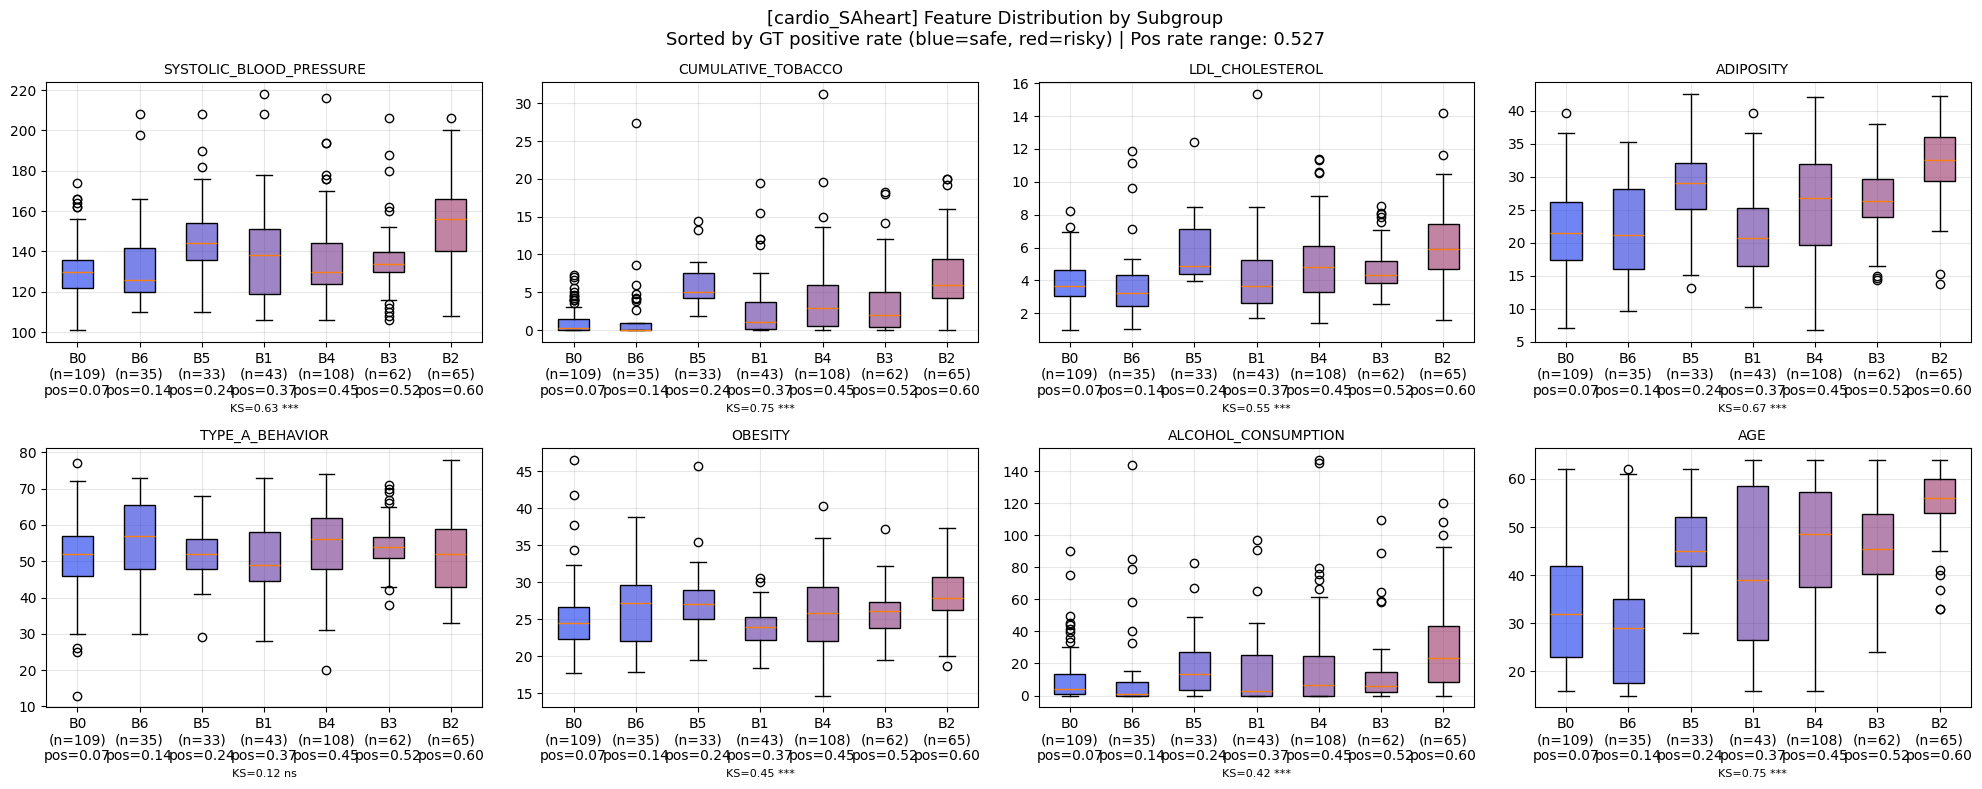


[cardio_SAheart] Feature Risk Summary
  Safest subgroup: B0 (pos_rate=0.073)
  Riskiest subgroup: B2 (pos_rate=0.600)

  Feature                        Safe median     Risky median    Direction  KS
  -------------------------------------------------------------------------------------
  SYSTOLIC_BLOOD_PRESSURE        130.00          156.00          ↑          0.63 ***
  CUMULATIVE_TOBACCO             0.21            6.00            ↑          0.75 ***
  LDL_CHOLESTEROL                3.67            5.90            ↑          0.55 ***
  ADIPOSITY                      21.39           32.48           ↑          0.67 ***
  TYPE_A_BEHAVIOR                52.00           52.00           ↓          0.12 ns
  OBESITY                        24.54           27.84           ↑          0.45 ***
  ALCOHOL_CONSUMPTION            4.03            23.66           ↑          0.42 ***
  AGE                            32.00           56.00           ↑          0.75 ***

[heart_failure_clinical_records] 

/tmp/ipykernel_1808760/752000701.py:210: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_sg, labels=labels_sg, patch_artist=True)
/tmp/ipykernel_1808760/752000701.py:210: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_sg, labels=labels_sg, patch_artist=True)
/tmp/ipykernel_1808760/752000701.py:210: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_sg, labels=labels_sg, patch_artist=True)
/tmp/ipykernel_1808760/752000701.py:210: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; suppor

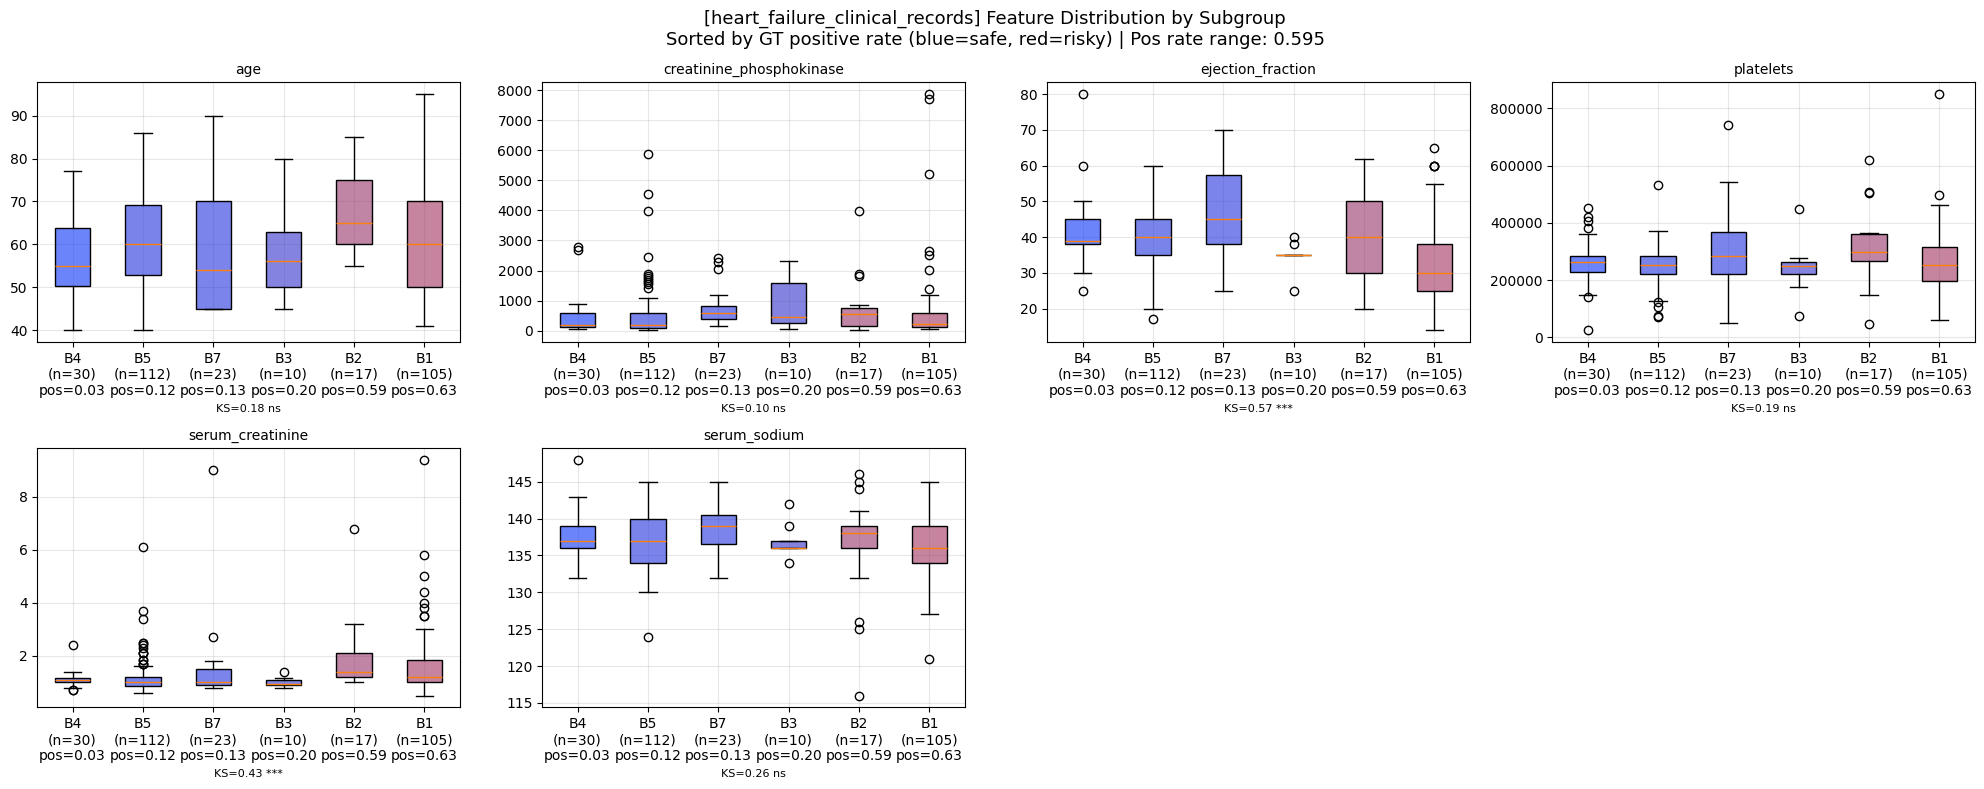


[heart_failure_clinical_records] Feature Risk Summary
  Safest subgroup: B4 (pos_rate=0.033)
  Riskiest subgroup: B1 (pos_rate=0.629)

  Feature                        Safe median     Risky median    Direction  KS
  -------------------------------------------------------------------------------------
  age                            55.00           60.00           ↑          0.18 ns
  creatinine_phosphokinase       207.00          231.00          ↑          0.10 ns
  ejection_fraction              39.00           30.00           ↓          0.57 ***
  platelets                      263358.03       254000.00       ↓          0.19 ns
  serum_creatinine               1.10            1.20            ↑          0.43 ***
  serum_sodium                   137.00          136.00          ↓          0.26 ns


In [41]:
"""
Exp 2. In-domain Subgroup Feature Analysis (v2 — 교수님 피드백 반영)

변경사항:
1. Acc → GT label 비율 (positive rate)
2. Binary prediction 안 씀
3. "이 subgroup이 위험한 그룹인지 아닌지"를 GT로 판단
4. Feature 분포와 GT positive rate의 연관성을 보여줌

- joint_model_pretrain, args, loaders, sources, device 이미 로딩된 상태
"""

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ★ 의미 없는 변수 제외 (ID, leakage 등)
EXCLUDE_FEATURES = {
    'patientid', 'patient_id', 'id', 'ID',
    'time',  # follow-up period = outcome proxy (leakage)
}

# ============================================================
# 1. 원본 CSV 로드 (기존과 동일)
# ============================================================
base_table_path = "/storage/personal/eungyeop/dataset/table/origin_table"

dataset_and_class = {
    "heart": ['target_binary', ['no','yes']],
    "Cardiovascular_Disease_Dataset": ['target_binary', ['no', 'yes']],
    "Medicaldataset": ['target_binary', ['no', 'yes']],
    "Heart_disease_statlog": ['target_binary', ['no','yes']],
    "Erbil_Cardiovascular_Health_Dataset": ['target_binary', ['no','yes']],
    "cardio_SAheart": ['target_binary', ['no','yes']],
    "heart_failure_clinical_records": ['target_binary', ['no','yes']],
}

label_col_map = {
    "Cardiovascular_Disease_Dataset": "target",
    "Medicaldataset": "Result",
    "heart1": "output",
}

def load_original_tabular(dataset_name):
    csv_path = f"{base_table_path}/{dataset_name}.csv"
    df = pd.read_csv(csv_path)
    
    class_info = dataset_and_class.get(dataset_name)
    if class_info is None:
        for col in ['target_binary', 'target', 'Result', 'output', 'target_multiclass']:
            if col in df.columns:
                y = df[col]
                X = df.drop(col, axis=1)
                return X.reset_index(drop=True), y.reset_index(drop=True)
        raise ValueError(f"Cannot find label column for {dataset_name}")
    
    class_name = class_info[0]
    
    if dataset_name in label_col_map:
        orig_col = label_col_map[dataset_name]
        if orig_col in df.columns:
            df[class_name] = df[orig_col]
            df = df.drop(orig_col, axis=1)
    
    if class_name in df.columns:
        X = df.drop(class_name, axis=1)
        y = df[class_name]
    else:
        raise ValueError(f"Label column '{class_name}' not found in {dataset_name}")
    
    return X.reset_index(drop=True), y.reset_index(drop=True)

# ============================================================
# 2. pi + s_idx 수집 → 원본 tabular 매핑
# ============================================================
def analyze_one_source_v2(model, loader, device, dataset_name, extract_feature_names_fn):
    """pi, s_idx, y 수집 + 원본 tabular 매핑 (prediction 안 씀)"""
    
    X_orig, y_orig = load_original_tabular(dataset_name)
    print(f"\n{'='*60}")
    print(f"[{dataset_name}] Original shape: {X_orig.shape}, Features: {list(X_orig.columns)}")
    
    all_pi = []
    all_sidx = []
    all_y = []
    
    model.eval()
    with torch.no_grad():
        for batch in loader:
            batch_t = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
            
            out = model.predict(batch_t, return_all=True)
            
            pi = model.graph_quantizer.last_pi
            
            all_pi.append(pi.cpu().numpy())
            all_y.append(batch_t['y'].cpu().view(-1).numpy())
            
            if 's_idx' in batch_t:
                sidx = batch_t['s_idx']
                if isinstance(sidx, torch.Tensor):
                    all_sidx.append(sidx.cpu().view(-1).numpy())
                else:
                    all_sidx.append(np.array([sidx]))
            else:
                start = sum(len(s) for s in all_sidx)
                all_sidx.append(np.arange(start, start + pi.shape[0]))
    
    pis = np.concatenate(all_pi, axis=0)
    sidxs = np.concatenate(all_sidx, axis=0).astype(int)
    ys = np.concatenate(all_y, axis=0)
    
    argmax_basis = np.argmax(pis, axis=1)
    
    valid_mask = sidxs < len(X_orig)
    if not valid_mask.all():
        print(f"  Warning: {(~valid_mask).sum()} samples skipped")
        pis = pis[valid_mask]
        sidxs = sidxs[valid_mask]
        ys = ys[valid_mask]
        argmax_basis = argmax_basis[valid_mask]
    
    X_mapped = X_orig.iloc[sidxs].reset_index(drop=True)
    
    return {
        'dataset_name': dataset_name,
        'X': X_mapped,
        'pis': pis,
        'ys': ys,
        'argmax': argmax_basis,
        'feature_names': list(X_orig.columns),
    }

# ============================================================
# 3. Subgroup별 Feature 분포 + GT label 비율 시각화
# ============================================================
def plot_subgroup_features_v2(result, max_features=12):
    """
    교수님 방식: GT label 비율로 subgroup 특성 파악
    - 각 subgroup의 positive rate 표시
    - Feature boxplot으로 "왜 이 그룹이 위험한지" 보여줌
    - Label별로 나누지 않고, 전체에서 봄
    """
    dataset_name = result['dataset_name']
    X = result['X']
    ys = result['ys'].astype(int)
    argmax = result['argmax']
    
    # numerical columns (exclude meaningless features)
    num_cols = [c for c in X.select_dtypes(include=[np.number]).columns
                if c.lower() not in {f.lower() for f in EXCLUDE_FEATURES}][:max_features]
    if len(num_cols) == 0:
        print(f"  No numerical columns for {dataset_name}")
        return
    
    # active subgroups
    unique_sg, counts = np.unique(argmax, return_counts=True)
    active_sg = unique_sg[counts >= 10]
    
    if len(active_sg) < 2:
        print(f"  Not enough active subgroups")
        return
    
    # ★ GT label 비율 계산 (Acc 대신)
    print(f"\n[{dataset_name}] Subgroup별 GT Label 비율")
    pos_rates = {}
    for sg in active_sg:
        sg_mask = (argmax == sg)
        n = sg_mask.sum()
        n_pos = ys[sg_mask].sum()
        pos_rate = ys[sg_mask].mean()
        pos_rates[sg] = pos_rate
        print(f"  Basis {sg}: N={n}, Label=1: {n_pos}/{n} ({pos_rate:.3f})")
    
    # positive rate 기준 정렬
    sorted_sg = sorted(active_sg, key=lambda s: pos_rates[s])
    
    overall_pos_rate = ys.mean()
    pos_rate_range = max(pos_rates.values()) - min(pos_rates.values())
    print(f"  Overall positive rate: {overall_pos_rate:.3f}")
    print(f"  Positive rate range: {pos_rate_range:.3f}")
    
    # Boxplot (positive rate 순으로 정렬)
    n_cols = len(num_cols)
    n_rows = (n_cols + 3) // 4
    fig, axes = plt.subplots(n_rows, min(4, n_cols), figsize=(5 * min(4, n_cols), 4 * n_rows))
    if n_rows == 1 and min(4, n_cols) == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = axes[np.newaxis, :]
    elif min(4, n_cols) == 1:
        axes = axes[:, np.newaxis]
    
    for i, col in enumerate(num_cols):
        row, c = i // 4, i % 4
        ax = axes[row, c]
        
        data_per_sg = []
        labels_sg = []
        for sg in sorted_sg:
            sg_mask = (argmax == sg)
            vals = pd.to_numeric(X.loc[sg_mask, col], errors='coerce').dropna().values.astype(float)
            if len(vals) > 0:
                data_per_sg.append(vals)
                labels_sg.append(f"B{sg}\n(n={sg_mask.sum()})\npos={pos_rates[sg]:.2f}")
        
        if data_per_sg:
            bp = ax.boxplot(data_per_sg, labels=labels_sg, patch_artist=True)
            # 색상: positive rate가 높을수록 빨갛게
            for j, (patch, sg) in enumerate(zip(bp['boxes'], sorted_sg)):
                pr = pos_rates[sg]
                # 파랑(안전) → 빨강(위험)
                r = pr
                b = 1 - pr
                patch.set_facecolor((r, 0.2, b, 0.6))
        
        ax.set_title(col, fontsize=10)
        ax.grid(True, alpha=0.3)
        
        # KS test (가장 낮은 pos_rate vs 가장 높은 pos_rate)
        if len(data_per_sg) >= 2:
            ks_stat, ks_p = stats.ks_2samp(data_per_sg[0], data_per_sg[-1])
            sig = "***" if ks_p < 0.001 else "**" if ks_p < 0.01 else "*" if ks_p < 0.05 else "ns"
            ax.set_xlabel(f"KS={ks_stat:.2f} {sig}", fontsize=8)
    
    for i in range(n_cols, n_rows * min(4, n_cols)):
        row, c = i // 4, i % 4
        axes[row, c].set_visible(False)
    
    fig.suptitle(
        f"[{dataset_name}] Feature Distribution by Subgroup\n"
        f"Sorted by GT positive rate (blue=safe, red=risky) | "
        f"Pos rate range: {pos_rate_range:.3f}",
        fontsize=13
    )
    plt.tight_layout()
    plt.show()


# ============================================================
# 4. Positive rate vs Feature 상관 요약표
# ============================================================
def print_feature_risk_summary(result, top_k=5):
    """
    각 feature에 대해: positive rate가 높은 subgroup vs 낮은 subgroup에서
    feature 값이 어떻게 다른지 요약
    """
    dataset_name = result['dataset_name']
    X = result['X']
    ys = result['ys'].astype(int)
    argmax = result['argmax']
    
    unique_sg, counts = np.unique(argmax, return_counts=True)
    active_sg = unique_sg[counts >= 10]
    
    pos_rates = {sg: ys[argmax == sg].mean() for sg in active_sg}
    
    # 가장 안전한 vs 가장 위험한 subgroup
    safest = min(active_sg, key=lambda s: pos_rates[s])
    riskiest = max(active_sg, key=lambda s: pos_rates[s])
    
    print(f"\n[{dataset_name}] Feature Risk Summary")
    print(f"  Safest subgroup: B{safest} (pos_rate={pos_rates[safest]:.3f})")
    print(f"  Riskiest subgroup: B{riskiest} (pos_rate={pos_rates[riskiest]:.3f})")
    print(f"\n  {'Feature':<30} {'Safe median':<15} {'Risky median':<15} {'Direction':<10} {'KS'}")
    print("  " + "-" * 85)
    
    num_cols = [c for c in X.select_dtypes(include=[np.number]).columns
                if c.lower() not in {f.lower() for f in EXCLUDE_FEATURES}]
    
    feature_diffs = []
    for col in num_cols:
        safe_vals = pd.to_numeric(X.loc[argmax == safest, col], errors='coerce').dropna().values
        risky_vals = pd.to_numeric(X.loc[argmax == riskiest, col], errors='coerce').dropna().values
        
        if len(safe_vals) > 5 and len(risky_vals) > 5:
            safe_med = np.median(safe_vals)
            risky_med = np.median(risky_vals)
            direction = "↑" if risky_med > safe_med else "↓"
            ks_stat, ks_p = stats.ks_2samp(safe_vals, risky_vals)
            sig = "***" if ks_p < 0.001 else "**" if ks_p < 0.01 else "*" if ks_p < 0.05 else "ns"
            
            feature_diffs.append((col, safe_med, risky_med, direction, ks_stat, sig))
            print(f"  {col:<30} {safe_med:<15.2f} {risky_med:<15.2f} {direction:<10} {ks_stat:.2f} {sig}")


# ============================================================
# 5. 실행
# ============================================================
results_v2 = {}
for src_name in sources:
    loader = loaders[src_name]
    res = analyze_one_source_v2(
        joint_model_pretrain, loader, device, src_name, extract_feature_names
    )
    results_v2[src_name] = res
    
    # 전체에서 GT positive rate 기반으로 시각화
    plot_subgroup_features_v2(res)
    print_feature_risk_summary(res)

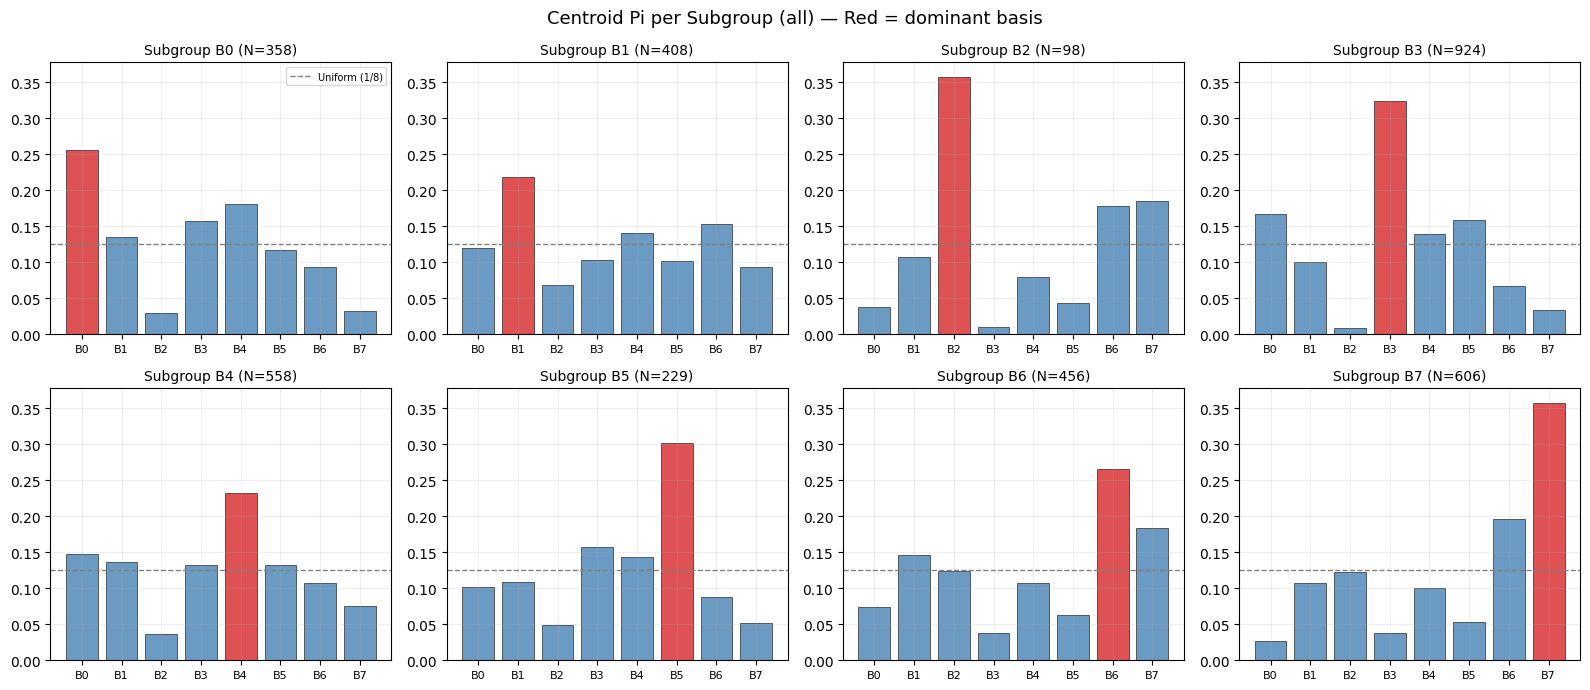

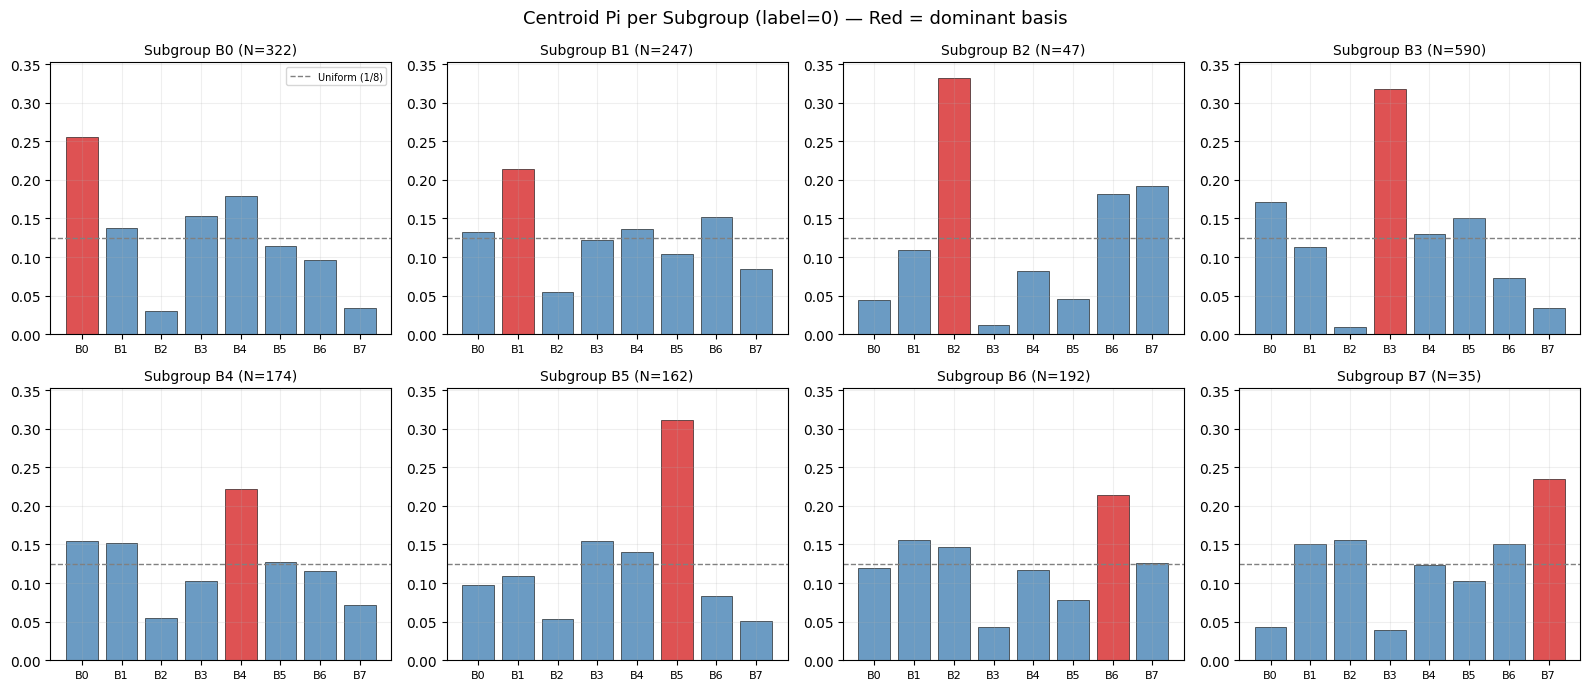

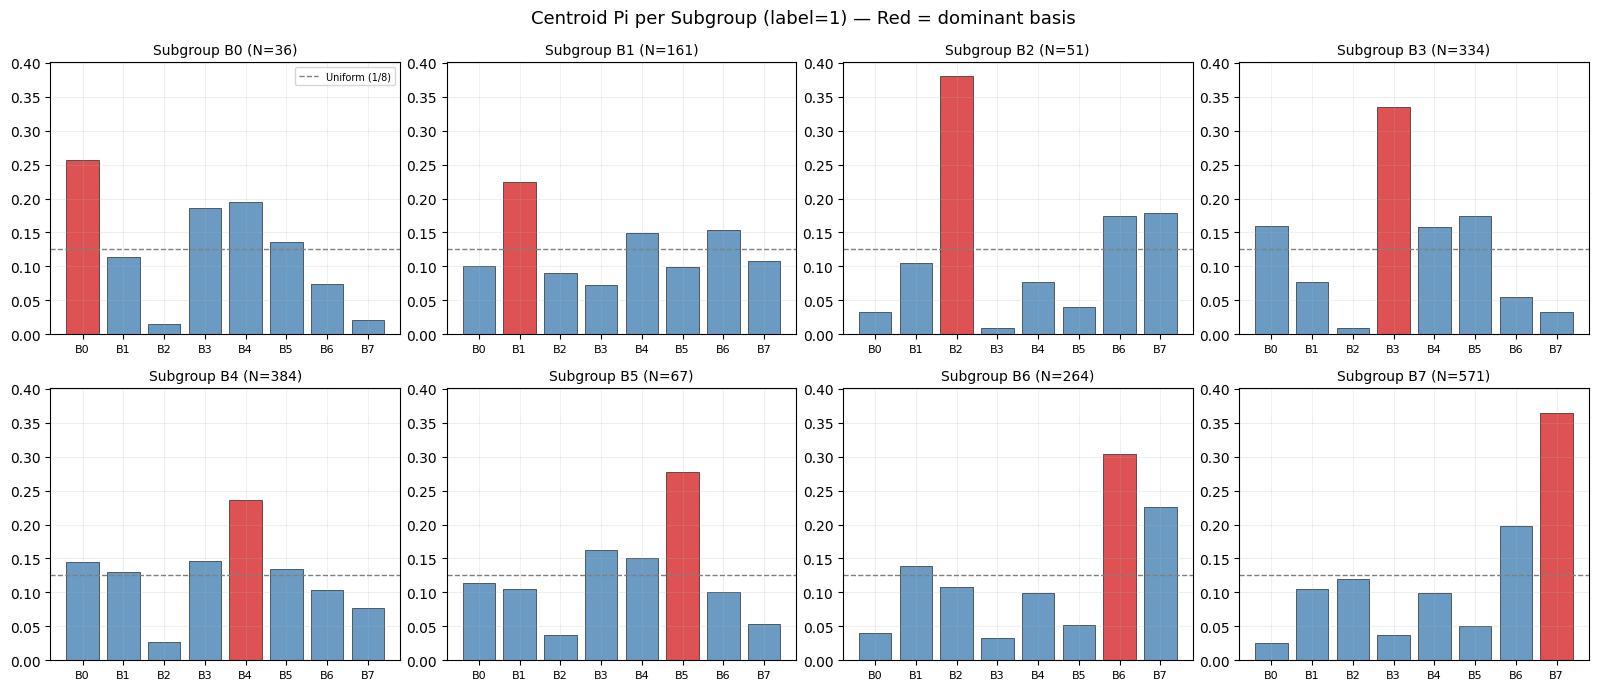

In [42]:
"""
Subgroup별 평균 coordinate (centroid pi) bar chart
- perturbation heatmap과 나란히 보면 스토리가 연결됨
- result는 run_perturbation_experiment()에서 나온 dict 사용
"""

import numpy as np
import matplotlib.pyplot as plt

def plot_centroid_pi(result, label=None, pis_all=None, ys_all=None):
    """
    Subgroup별 centroid pi bar chart
    
    label: None이면 전체, 0 또는 1이면 해당 label만
    pis_all, ys_all: 외부에서 전달 가능 (없으면 result에서 가져옴)
    """
    
    # result에서 가져오기
    if pis_all is None:
        # run_perturbation_experiment에서 pis를 저장하지 않았으므로
        # all_pi, all_y를 다시 사용해야 함
        # 대신 argmax_basis와 M은 있음
        print("pis_all을 직접 전달해주세요 (all_pis, all_ys)")
        return
    
    argmax_basis = np.argmax(pis_all, axis=1)
    M = pis_all.shape[1]
    
    # label 필터
    if label is not None:
        mask = (ys_all == label)
        pis_filtered = pis_all[mask]
        argmax_filtered = argmax_basis[mask]
    else:
        pis_filtered = pis_all
        argmax_filtered = argmax_basis
    
    # active subgroups
    unique_sg, counts = np.unique(argmax_filtered, return_counts=True)
    active_sg = unique_sg[counts >= 10]
    
    n_sg = len(active_sg)
    if n_sg == 0:
        print("No active subgroups")
        return
    
    # centroid 계산
    centroids = {}
    for sg in active_sg:
        sg_mask = (argmax_filtered == sg)
        centroids[sg] = pis_filtered[sg_mask].mean(axis=0)
    
    # 그림
    n_cols = min(4, n_sg)
    n_rows = (n_sg + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows))
    
    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = axes[np.newaxis, :]
    elif n_cols == 1:
        axes = axes[:, np.newaxis]
    
    # 공통 y축 범위
    all_vals = np.concatenate([centroids[sg] for sg in active_sg])
    y_max = all_vals.max() + 0.02
    
    for idx, sg in enumerate(active_sg):
        r, c = idx // n_cols, idx % n_cols
        ax = axes[r, c]
        
        cent = centroids[sg]
        colors = ['C3' if k == sg else 'steelblue' for k in range(M)]
        
        ax.bar(range(M), cent, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
        ax.axhline(1.0 / M, linestyle='--', color='gray', linewidth=1, label=f'Uniform (1/{M})')
        ax.set_ylim(0, y_max)
        ax.set_xticks(range(M))
        ax.set_xticklabels([f'B{k}' for k in range(M)], fontsize=8)
        
        n_samples = (argmax_filtered == sg).sum()
        ax.set_title(f'Subgroup B{sg} (N={n_samples})', fontsize=10)
        ax.grid(True, alpha=0.2)
        
        if idx == 0:
            ax.legend(fontsize=7)
    
    # 빈 subplot 숨기기
    for idx in range(n_sg, n_rows * n_cols):
        r, c = idx // n_cols, idx % n_cols
        axes[r, c].set_visible(False)
    
    label_str = f'label={label}' if label is not None else 'all'
    fig.suptitle(f'Centroid Pi per Subgroup ({label_str}) — Red = dominant basis', fontsize=13)
    plt.tight_layout()
    plt.show()


# ============================================================
# 실행: 먼저 전체 source에서 pi, y를 다시 수집
# (이미 all_pis, all_ys가 있으면 그걸 쓰면 됨)
# ============================================================

# 모든 source에서 pi, y 수집
all_pis_for_plot = []
all_ys_for_plot = []

joint_model_pretrain.eval()
with torch.no_grad():
    for src_name in sources:
        loader = loaders[src_name]
        pis, ys, _, _, _ = collect_pi_and_affinity_for_one_source(
            joint_model_pretrain, loader, device, extract_feature_names
        )
        all_pis_for_plot.append(pis)
        all_ys_for_plot.append(ys)

all_pis_for_plot = np.concatenate(all_pis_for_plot, axis=0)
all_ys_for_plot = np.concatenate(all_ys_for_plot, axis=0).astype(int)

# 전체
plot_centroid_pi(result, label=None, pis_all=all_pis_for_plot, ys_all=all_ys_for_plot)

# label별
plot_centroid_pi(result, label=0, pis_all=all_pis_for_plot, ys_all=all_ys_for_plot)
plot_centroid_pi(result, label=1, pis_all=all_pis_for_plot, ys_all=all_ys_for_plot)

## A3 : Subgroup 간 transition — 정상(label 0)인데 고위험 subgroup에 배치된 sample, 또는 그 반대인 sample들의 feature 값이 실제로 borderline한지 확인


[Medicaldataset] Transition Analysis
  Low-risk subgroups (pos<0.25): ['B0(pos=0.15)']
  High-risk subgroups (pos>=0.5): ['B4(pos=0.74)', 'B5(pos=0.53)', 'B6(pos=0.99)', 'B7(pos=1.00)']

  Transition samples:
    (A) Label=0 in high-risk subgroup: 96 samples
    (B) Label=1 in low-risk subgroup:  26 samples
  Normal placement:
    (C) Label=0 in low-risk subgroup:  153 samples
    (D) Label=1 in high-risk subgroup: 580 samples


/tmp/ipykernel_1808760/694672529.py:193: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_groups, labels=valid_labels, patch_artist=True, widths=0.6)
/tmp/ipykernel_1808760/694672529.py:193: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_groups, labels=valid_labels, patch_artist=True, widths=0.6)
/tmp/ipykernel_1808760/694672529.py:193: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_groups, labels=valid_labels, patch_artist=True, widths=0.6)
/tmp/ipykernel_1808760/694672529.py:193: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renam

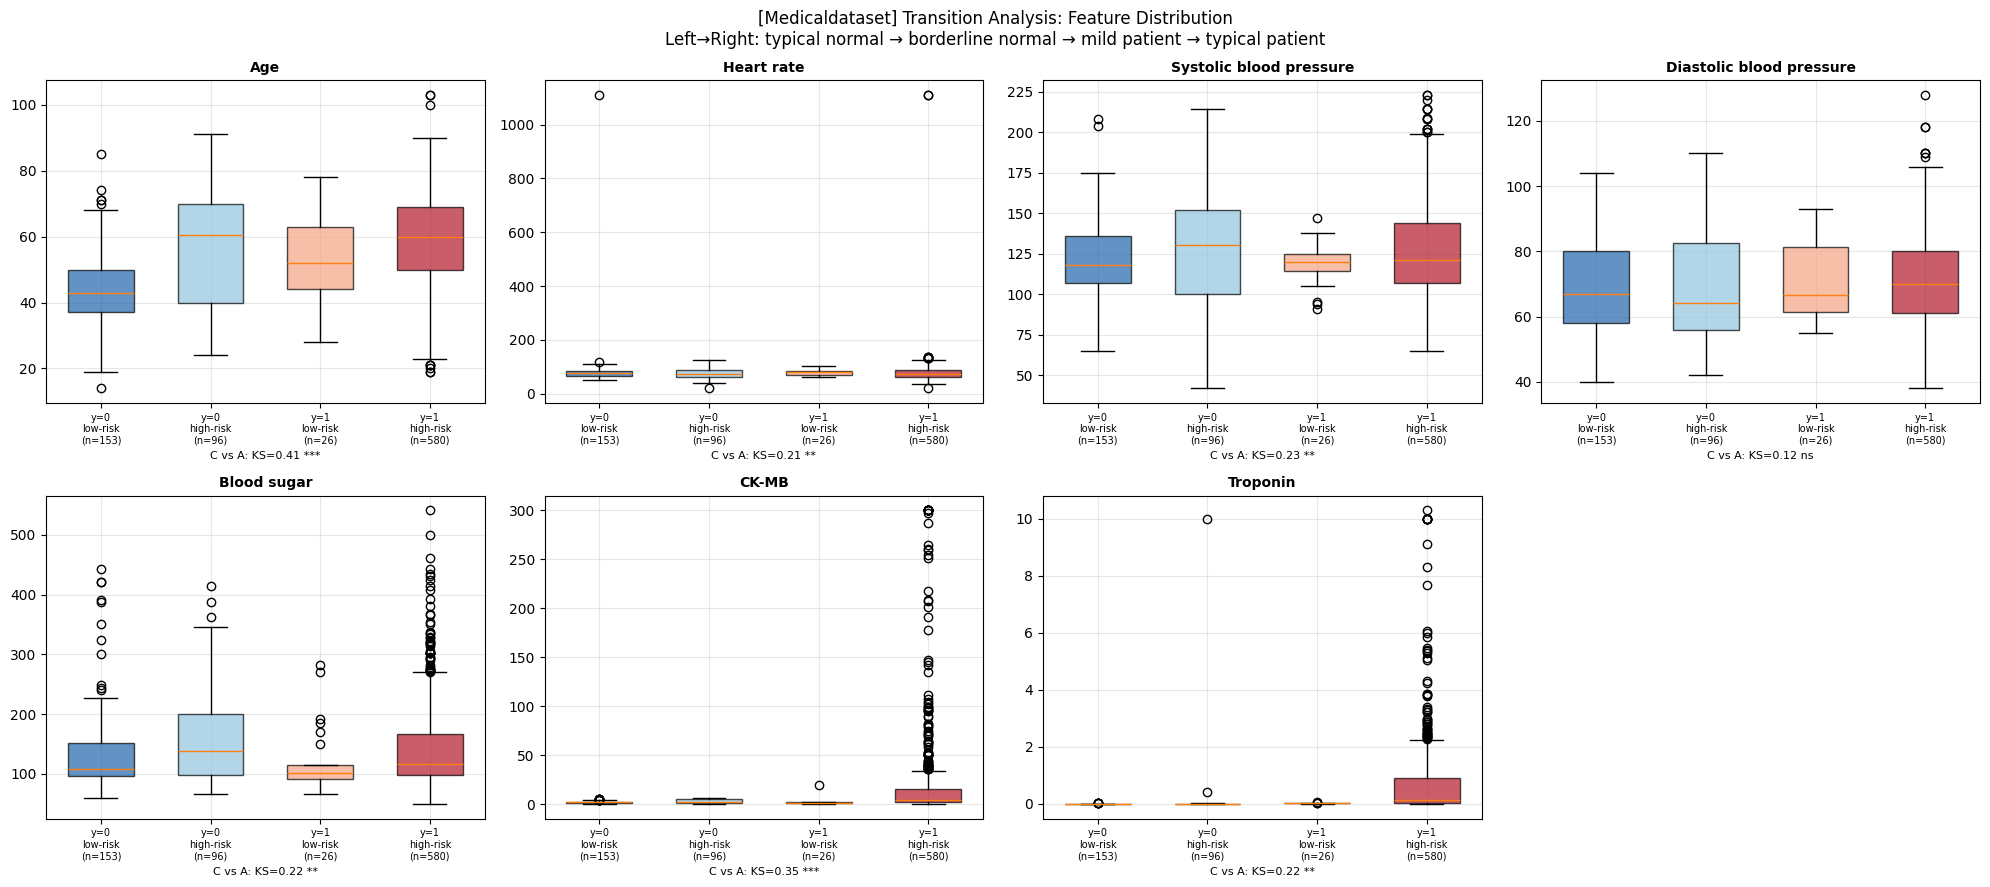

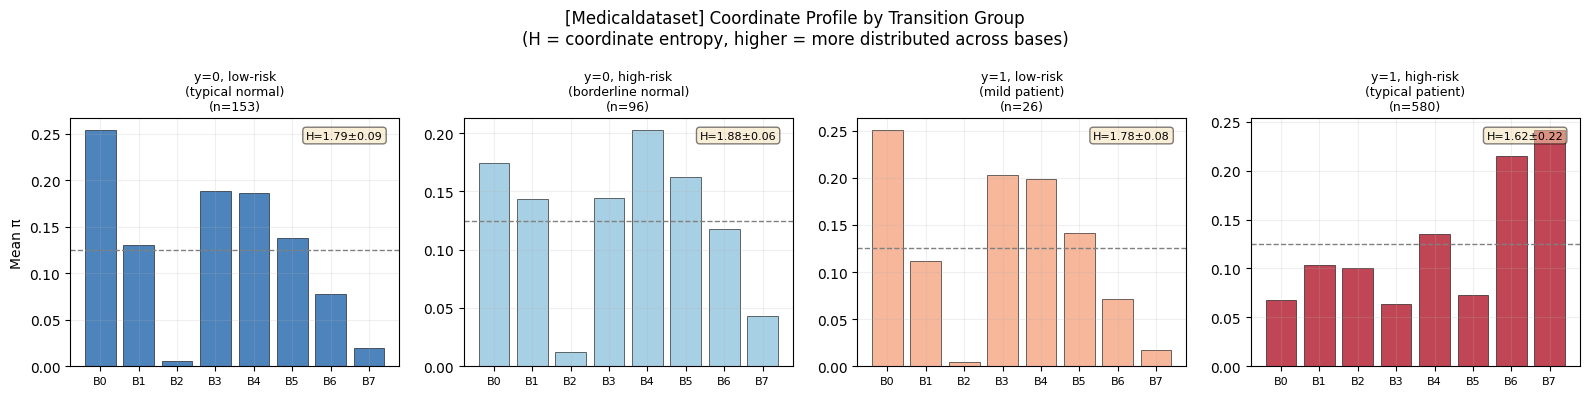


[Medicaldataset] Feature Median by Transition Group
  기대: C < A ≈ B < D (위험 feature의 경우)
  Feature                        C(정상)        A(border)    B(mild)      D(환자)        Monotonic?
  ----------------------------------------------------------------------------------
  Age                            43.00        60.50        52.00        60.00        No
  Heart rate                     78.00        73.50        79.50        74.00        No
  Systolic blood pressure        118.00       130.50       120.00       121.00       No
  Diastolic blood pressure       67.00        64.00        66.50        70.00        No
  Blood sugar                    109.00       138.00       102.00       116.00       No
  CK-MB                          1.76         1.81         1.63         4.28         No
  Troponin                       0.01         0.01         0.02         0.12         Yes ↑

  Monotonic features: 1/7 (14%)
  → Weak evidence that coordinate reflects actual risk gradient

[Cardiovascu

/tmp/ipykernel_1808760/694672529.py:193: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_groups, labels=valid_labels, patch_artist=True, widths=0.6)
/tmp/ipykernel_1808760/694672529.py:193: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_groups, labels=valid_labels, patch_artist=True, widths=0.6)
/tmp/ipykernel_1808760/694672529.py:193: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_groups, labels=valid_labels, patch_artist=True, widths=0.6)
/tmp/ipykernel_1808760/694672529.py:193: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renam

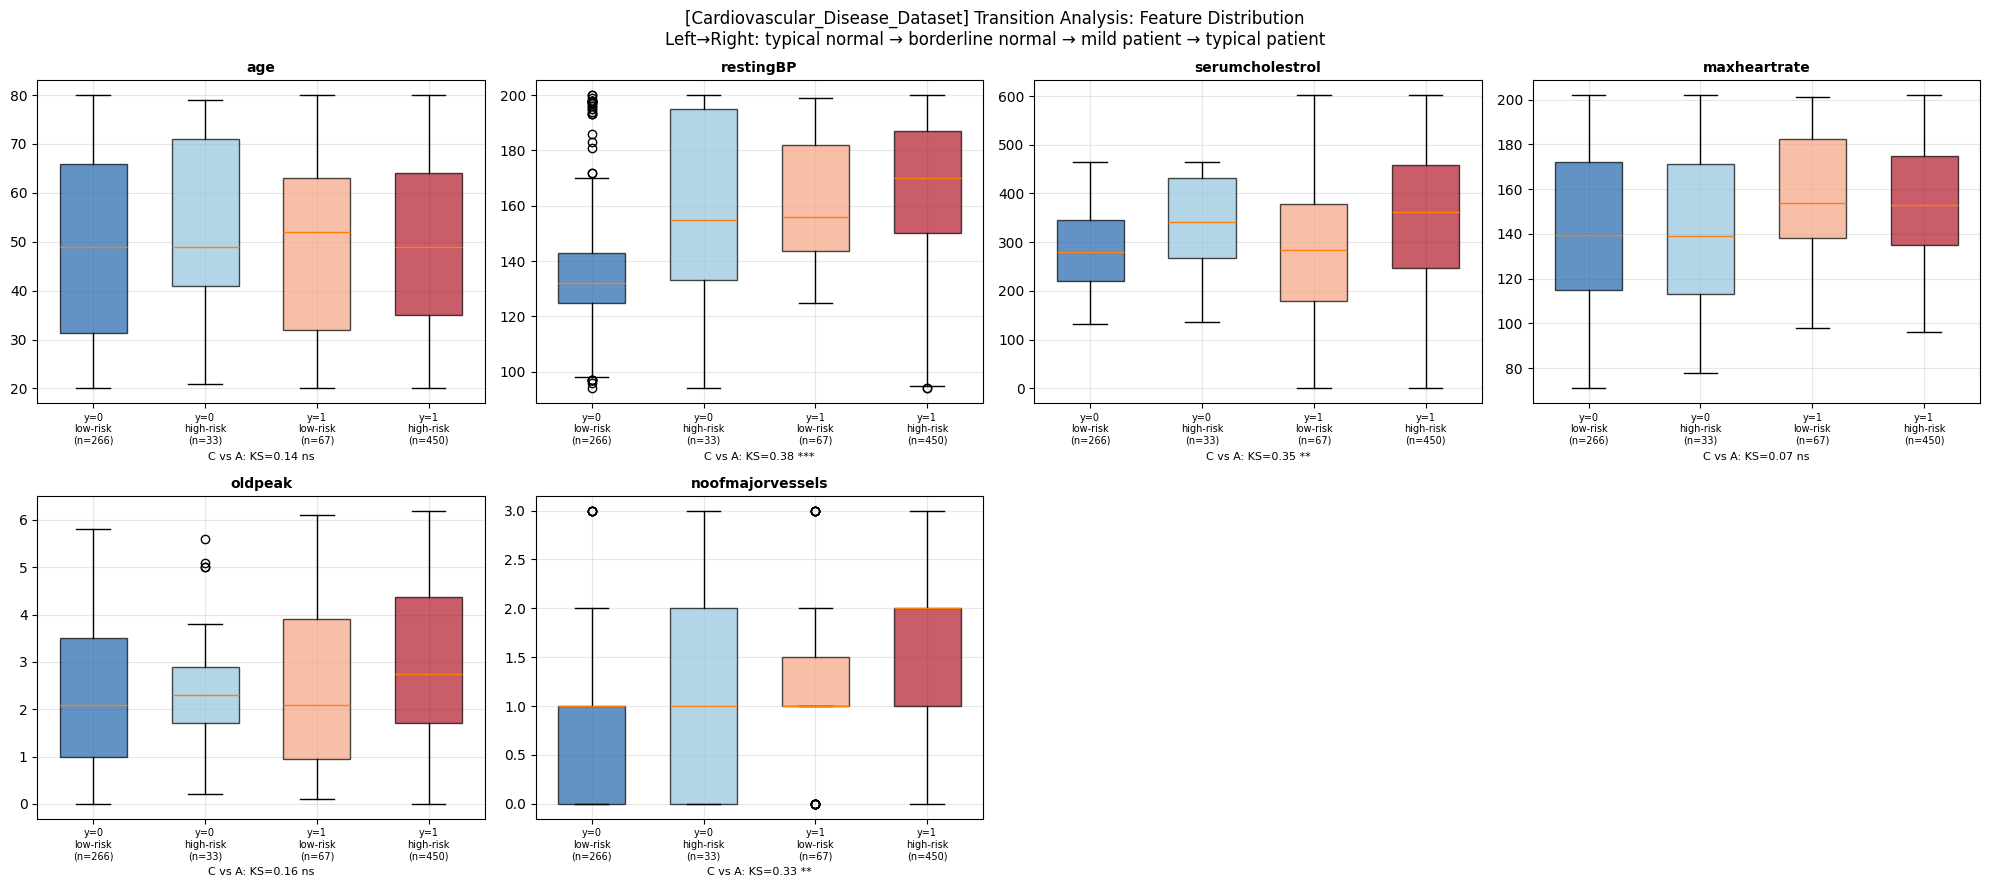

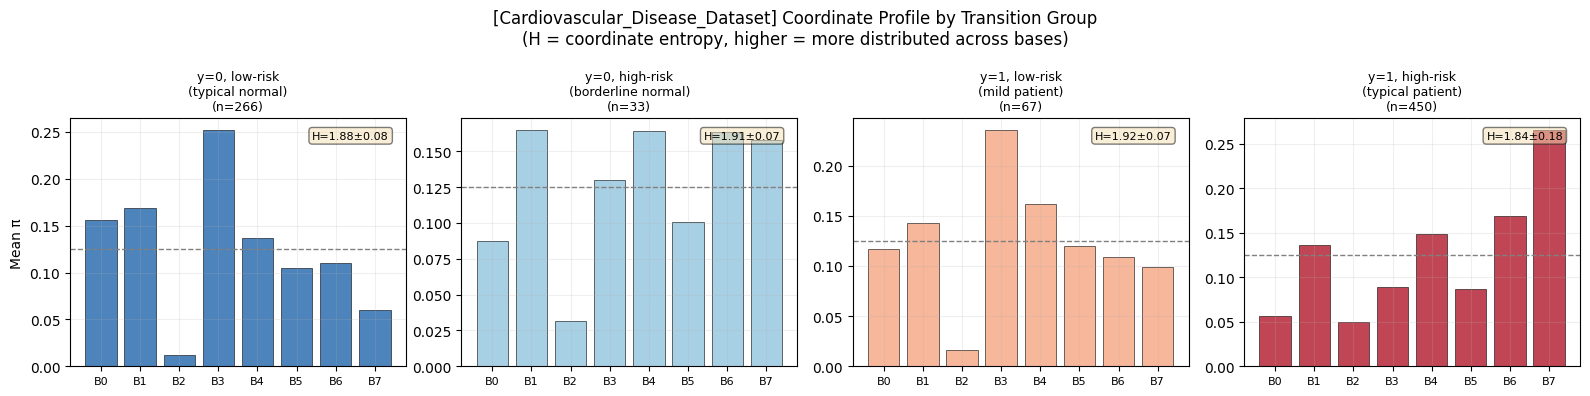


[Cardiovascular_Disease_Dataset] Feature Median by Transition Group
  기대: C < A ≈ B < D (위험 feature의 경우)
  Feature                        C(정상)        A(border)    B(mild)      D(환자)        Monotonic?
  ----------------------------------------------------------------------------------
  age                            49.00        49.00        52.00        49.00        No
  restingBP                      132.00       155.00       156.00       170.00       Yes ↑
  serumcholestrol                279.00       342.00       284.00       362.00       No
  maxheartrate                   139.50       139.00       154.00       153.00       No
  oldpeak                        2.10         2.30         2.10         2.75         No
  noofmajorvessels               1.00         1.00         1.00         2.00         Yes ↑

  Monotonic features: 2/6 (33%)
  → Weak evidence that coordinate reflects actual risk gradient

[Heart_disease_statlog] Transition Analysis
  Low-risk subgroups (pos<0.25): ['B0

/tmp/ipykernel_1808760/694672529.py:193: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_groups, labels=valid_labels, patch_artist=True, widths=0.6)
/tmp/ipykernel_1808760/694672529.py:193: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_groups, labels=valid_labels, patch_artist=True, widths=0.6)
/tmp/ipykernel_1808760/694672529.py:193: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_groups, labels=valid_labels, patch_artist=True, widths=0.6)
/tmp/ipykernel_1808760/694672529.py:193: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renam

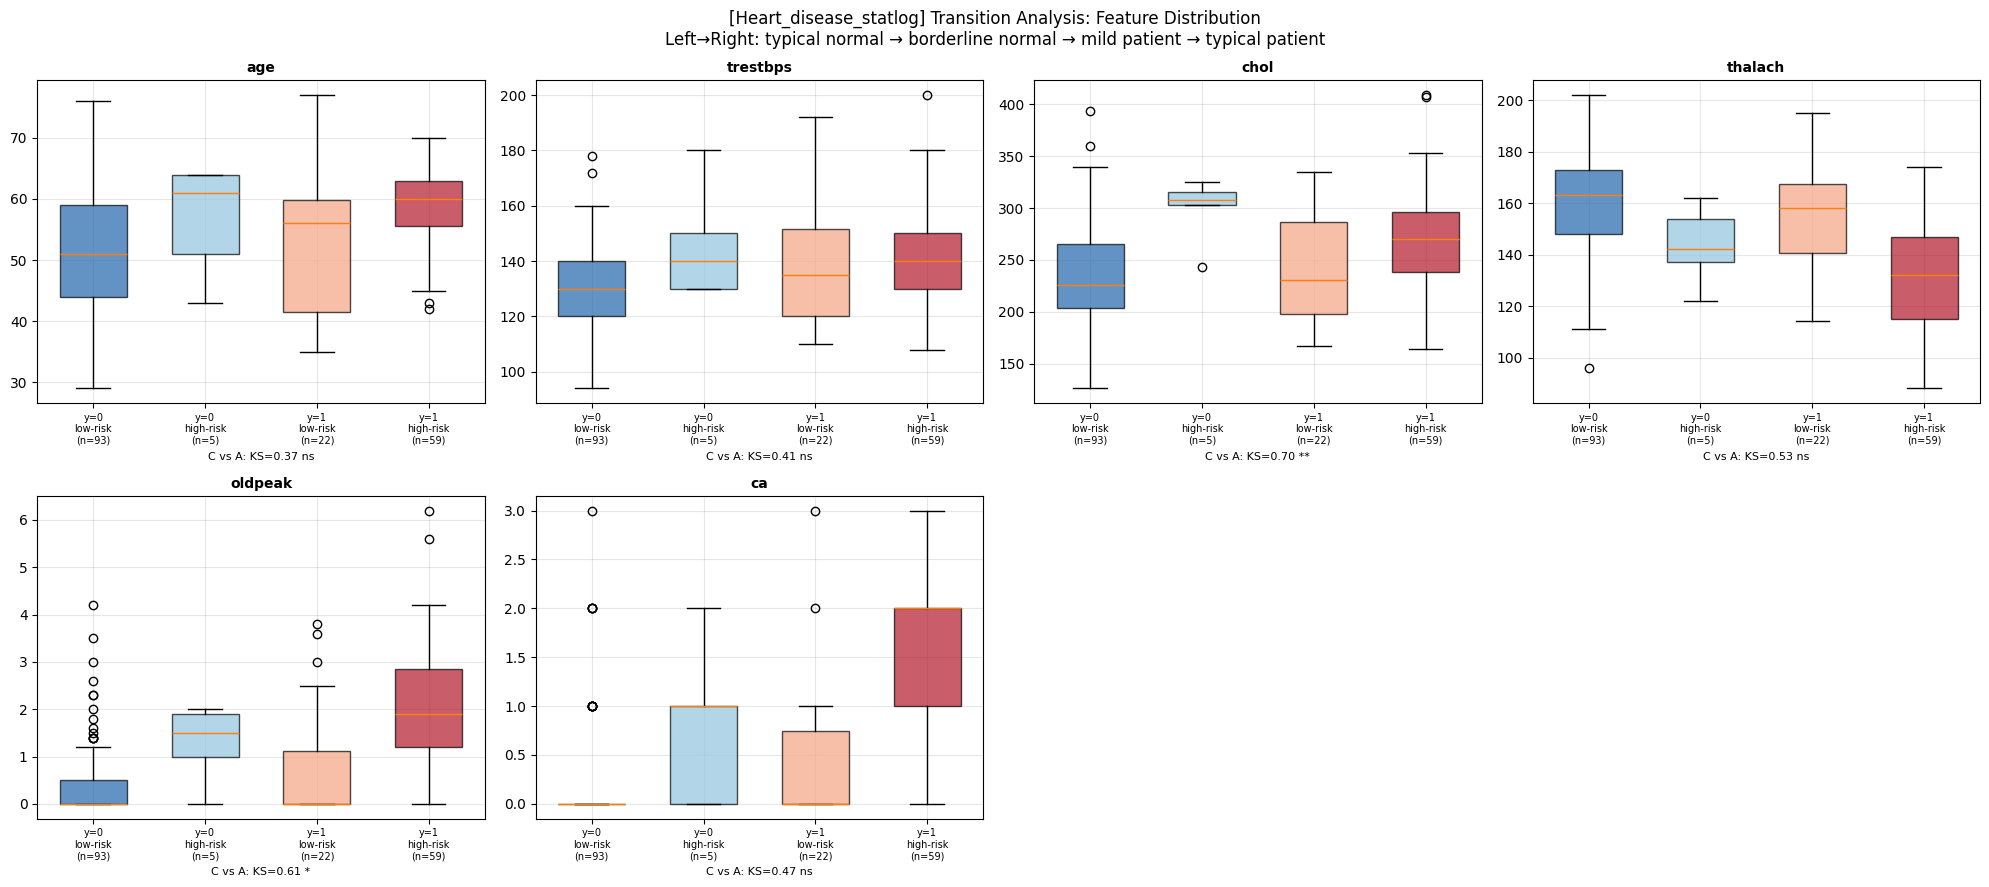

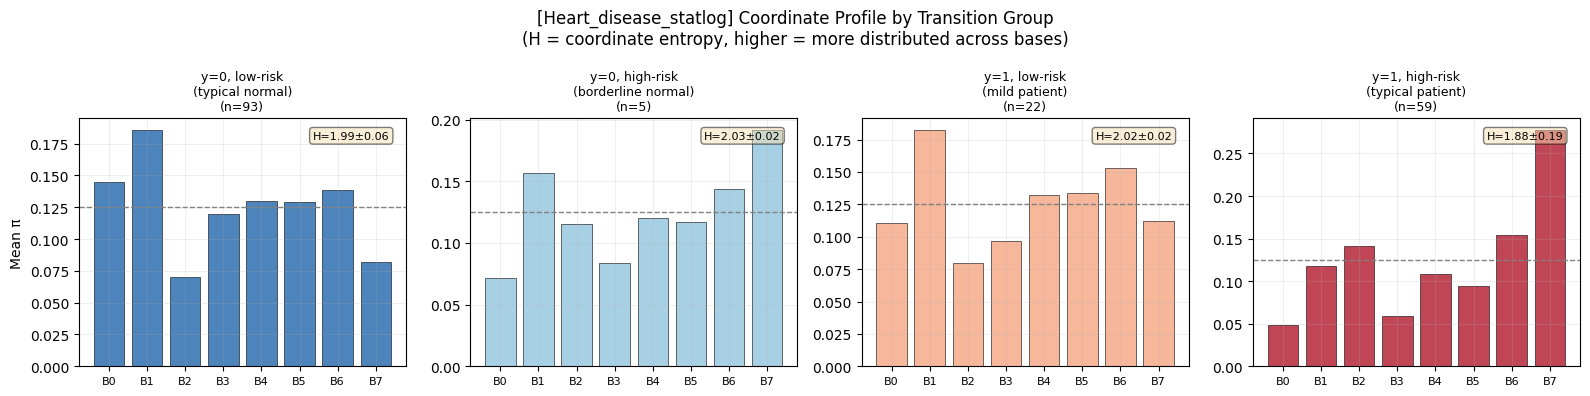


[Heart_disease_statlog] Feature Median by Transition Group
  기대: C < A ≈ B < D (위험 feature의 경우)
  Feature                        C(정상)        A(border)    B(mild)      D(환자)        Monotonic?
  ----------------------------------------------------------------------------------
  age                            51.00        61.00        56.00        60.00        No
  trestbps                       130.00       140.00       135.00       140.00       No
  chol                           226.00       308.00       231.00       270.00       No
  thalach                        163.00       142.00       158.00       132.00       No
  oldpeak                        0.00         1.50         0.00         1.90         No
  ca                             0.00         1.00         0.00         2.00         No

  Monotonic features: 0/6 (0%)
  → Weak evidence that coordinate reflects actual risk gradient

[Erbil_Cardiovascular_Health_Dataset] Transition Analysis
  Low-risk subgroups (pos<0.25): ['B0(p

/tmp/ipykernel_1808760/694672529.py:193: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_groups, labels=valid_labels, patch_artist=True, widths=0.6)
/tmp/ipykernel_1808760/694672529.py:193: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_groups, labels=valid_labels, patch_artist=True, widths=0.6)
/tmp/ipykernel_1808760/694672529.py:193: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_groups, labels=valid_labels, patch_artist=True, widths=0.6)
/tmp/ipykernel_1808760/694672529.py:193: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renam

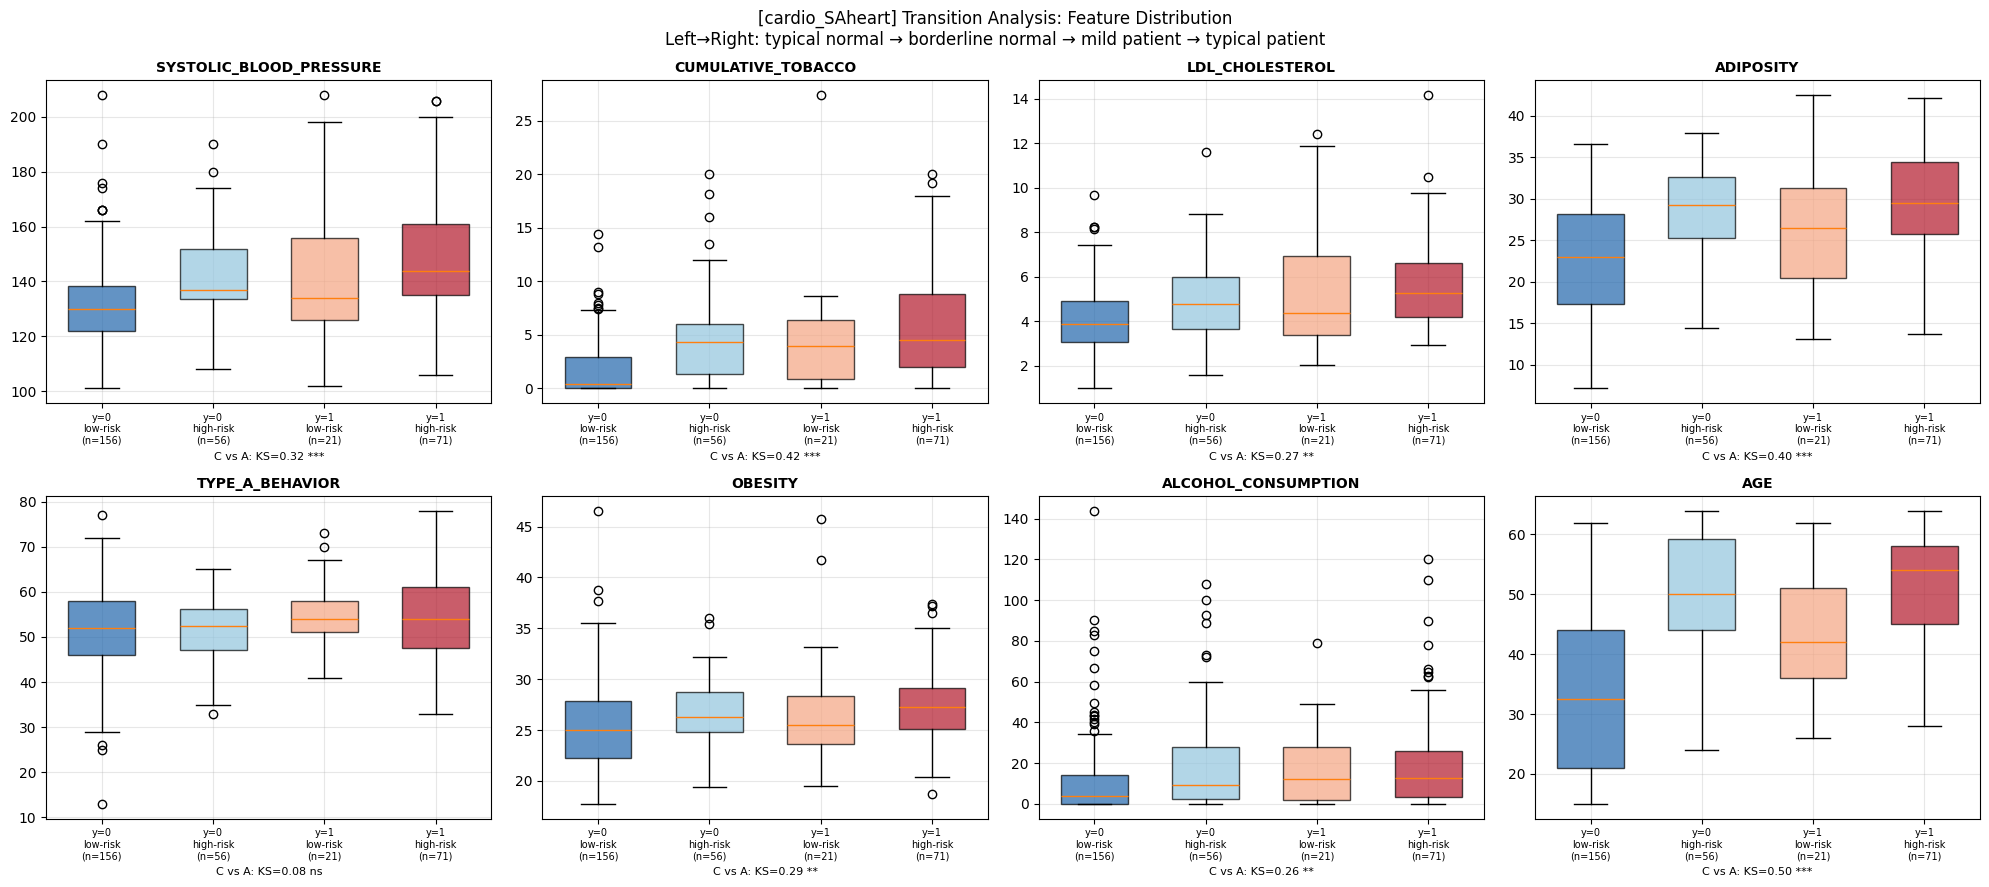

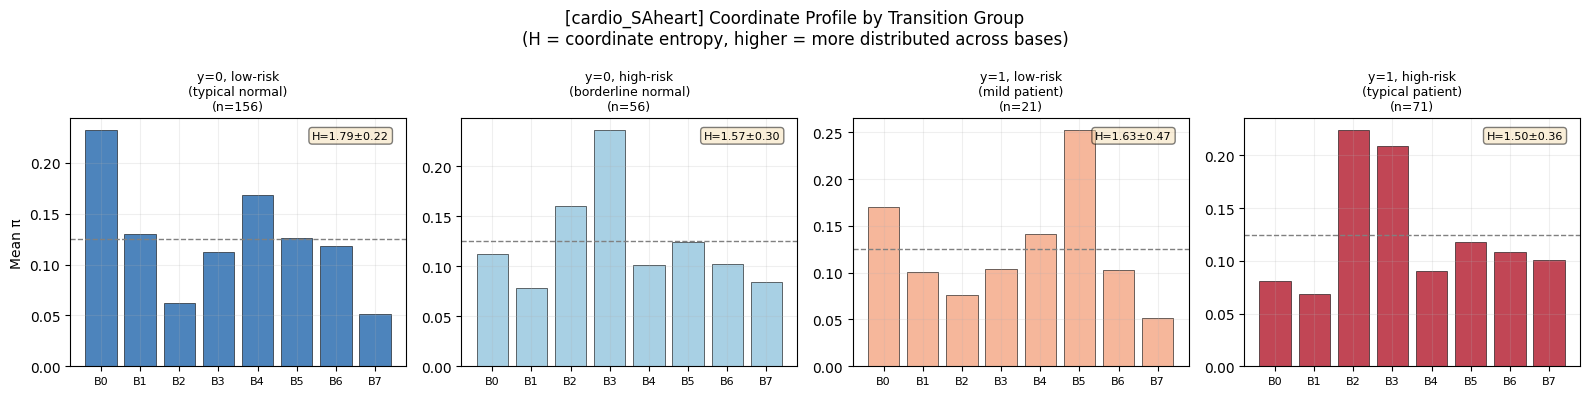


[cardio_SAheart] Feature Median by Transition Group
  기대: C < A ≈ B < D (위험 feature의 경우)
  Feature                        C(정상)        A(border)    B(mild)      D(환자)        Monotonic?
  ----------------------------------------------------------------------------------
  SYSTOLIC_BLOOD_PRESSURE        130.00       137.00       134.00       144.00       No
  CUMULATIVE_TOBACCO             0.40         4.33         4.00         4.50         No
  LDL_CHOLESTEROL                3.88         4.78         4.37         5.28         No
  ADIPOSITY                      22.97        29.21        26.50        29.45        No
  TYPE_A_BEHAVIOR                52.00        52.50        54.00        54.00        Yes ↑
  OBESITY                        24.96        26.26        25.52        27.29        No
  ALCOHOL_CONSUMPTION            3.81         9.46         12.34        12.86        Yes ↑
  AGE                            32.50        50.00        42.00        54.00        No

  Monotonic featur

/tmp/ipykernel_1808760/694672529.py:193: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_groups, labels=valid_labels, patch_artist=True, widths=0.6)
/tmp/ipykernel_1808760/694672529.py:193: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_groups, labels=valid_labels, patch_artist=True, widths=0.6)
/tmp/ipykernel_1808760/694672529.py:193: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_groups, labels=valid_labels, patch_artist=True, widths=0.6)
/tmp/ipykernel_1808760/694672529.py:193: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renam

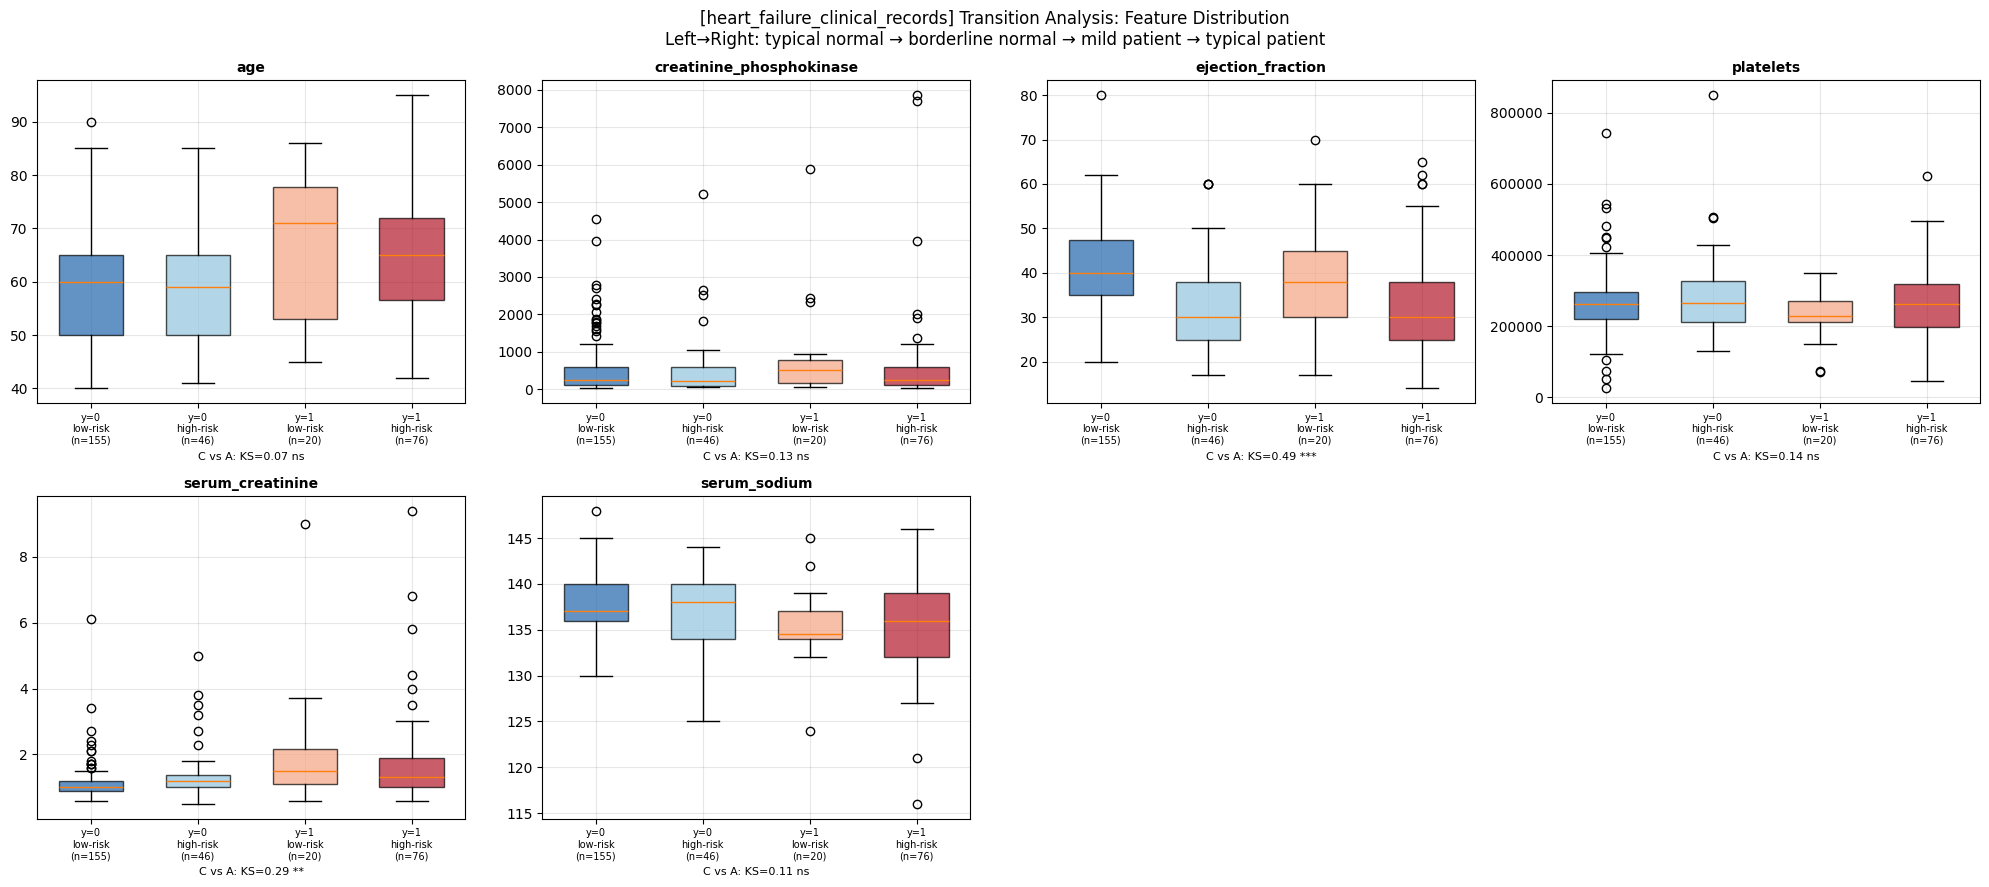

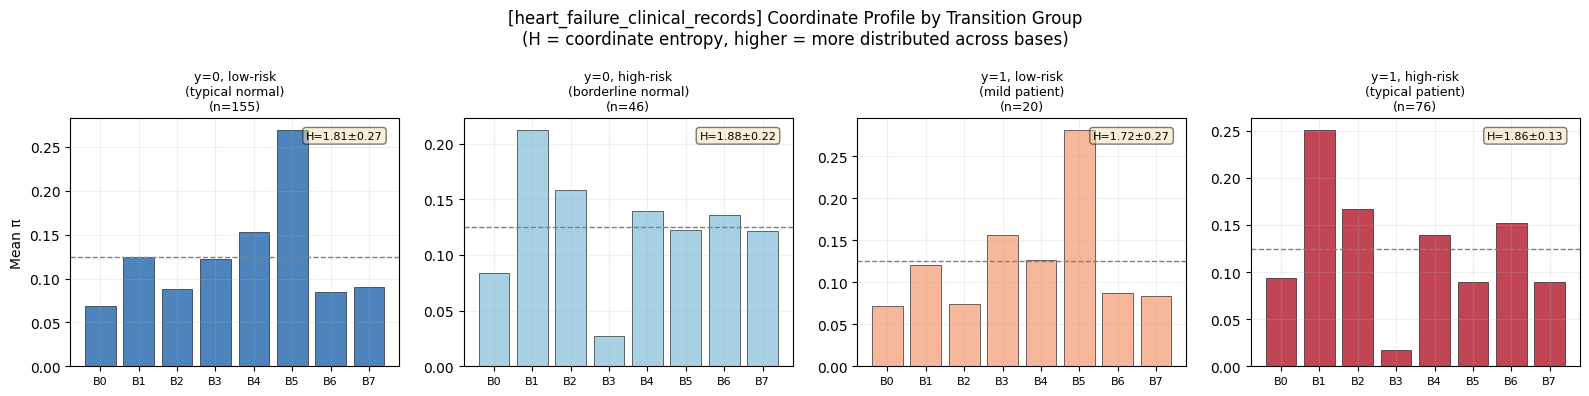


[heart_failure_clinical_records] Feature Median by Transition Group
  기대: C < A ≈ B < D (위험 feature의 경우)
  Feature                        C(정상)        A(border)    B(mild)      D(환자)        Monotonic?
  ----------------------------------------------------------------------------------
  age                            60.00        59.00        71.00        65.00        No
  creatinine_phosphokinase       245.00       231.50       504.50       249.50       No
  ejection_fraction              40.00        30.00        38.00        30.00        No
  platelets                      262000.00    264179.02    230000.00    263358.03    No
  serum_creatinine               1.00         1.20         1.50         1.30         No
  serum_sodium                   137.00       138.00       134.50       136.00       No

  Monotonic features: 0/6 (0%)
  → Weak evidence that coordinate reflects actual risk gradient


In [43]:
"""
Exp A3. Subgroup Transition Analysis

핵심 질문: 
- Label=0인데 고위험 subgroup에 배치된 sample → feature 값이 borderline한가?
- Label=1인데 저위험 subgroup에 배치된 sample → feature 값이 정상에 가까운가?

이것이 보여지면:
→ coordinate가 단순히 label을 외운 게 아니라, 실제 risk level을 반영한다는 근거

- results_v2 (Exp 2에서 나온 dict) 재활용
- joint_model_pretrain, args, loaders, sources, device 이미 로딩된 상태
"""

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

EXCLUDE_FEATURES = {
    'patientid', 'patient_id', 'id', 'ID',
    'time',
}


# ============================================================
# 1. Transition sample 추출
# ============================================================

def identify_transition_samples(result, low_threshold=0.25, high_threshold=0.50):
    """
    Subgroup의 positive rate를 기준으로:
    - 저위험 subgroup: pos_rate < low_threshold
    - 고위험 subgroup: pos_rate >= high_threshold
    
    그 안에서 "misplaced" sample을 찾는다:
    - Label=0 in 고위험 subgroup (정상인데 위험 그룹에 배치)
    - Label=1 in 저위험 subgroup (환자인데 안전 그룹에 배치)
    
    Returns:
        dict with transition sample info
    """
    dataset_name = result['dataset_name']
    X = result['X']
    ys = result['ys'].astype(int)
    argmax = result['argmax']
    pis = result['pis']
    
    # subgroup별 pos_rate
    unique_sg, counts = np.unique(argmax, return_counts=True)
    active_sg = unique_sg[counts >= 10]
    
    pos_rates = {}
    for sg in active_sg:
        pos_rates[sg] = ys[argmax == sg].mean()
    
    low_risk_sg = [sg for sg in active_sg if pos_rates[sg] < low_threshold]
    high_risk_sg = [sg for sg in active_sg if pos_rates[sg] >= high_threshold]
    
    print(f"\n{'='*60}")
    print(f"[{dataset_name}] Transition Analysis")
    print(f"  Low-risk subgroups (pos<{low_threshold}): {['B'+str(s)+f'(pos={pos_rates[s]:.2f})' for s in low_risk_sg]}")
    print(f"  High-risk subgroups (pos>={high_threshold}): {['B'+str(s)+f'(pos={pos_rates[s]:.2f})' for s in high_risk_sg]}")
    
    # Transition samples
    # (A) Label=0 in 고위험 subgroup
    label0_in_high = np.zeros(len(ys), dtype=bool)
    for sg in high_risk_sg:
        label0_in_high |= ((argmax == sg) & (ys == 0))
    
    # (B) Label=1 in 저위험 subgroup  
    label1_in_low = np.zeros(len(ys), dtype=bool)
    for sg in low_risk_sg:
        label1_in_low |= ((argmax == sg) & (ys == 1))
    
    # (C) "정상" 배치: Label=0 in 저위험, Label=1 in 고위험
    label0_in_low = np.zeros(len(ys), dtype=bool)
    for sg in low_risk_sg:
        label0_in_low |= ((argmax == sg) & (ys == 0))
    
    label1_in_high = np.zeros(len(ys), dtype=bool)
    for sg in high_risk_sg:
        label1_in_high |= ((argmax == sg) & (ys == 1))
    
    n_a = label0_in_high.sum()
    n_b = label1_in_low.sum()
    n_c = label0_in_low.sum()
    n_d = label1_in_high.sum()
    
    print(f"\n  Transition samples:")
    print(f"    (A) Label=0 in high-risk subgroup: {n_a} samples")
    print(f"    (B) Label=1 in low-risk subgroup:  {n_b} samples")
    print(f"  Normal placement:")
    print(f"    (C) Label=0 in low-risk subgroup:  {n_c} samples")
    print(f"    (D) Label=1 in high-risk subgroup: {n_d} samples")
    
    return {
        'dataset_name': dataset_name,
        'X': X,
        'ys': ys,
        'argmax': argmax,
        'pis': pis,
        'pos_rates': pos_rates,
        'label0_in_high': label0_in_high,  # (A)
        'label1_in_low': label1_in_low,    # (B)
        'label0_in_low': label0_in_low,    # (C)
        'label1_in_high': label1_in_high,  # (D)
        'low_risk_sg': low_risk_sg,
        'high_risk_sg': high_risk_sg,
    }


# ============================================================
# 2. Transition sample Feature 비교 (boxplot)
# ============================================================

def plot_transition_feature_comparison(trans, max_features=8):
    """
    4개 그룹의 feature 분포를 나란히 비교:
    
    (C) Label=0, low-risk subgroup  → "전형적 정상"
    (A) Label=0, high-risk subgroup → "정상인데 위험 그룹" (borderline?)
    (B) Label=1, low-risk subgroup  → "환자인데 안전 그룹" (mild?)
    (D) Label=1, high-risk subgroup → "전형적 환자"
    
    기대: A는 C보다 feature가 나쁘고 D보다는 낫다 (borderline)
          B는 D보다 feature가 좋고 C보다는 나쁘다 (mild)
    """
    dataset_name = trans['dataset_name']
    X = trans['X']
    
    mask_C = trans['label0_in_low']
    mask_A = trans['label0_in_high']
    mask_B = trans['label1_in_low']
    mask_D = trans['label1_in_high']
    
    n_C, n_A, n_B, n_D = mask_C.sum(), mask_A.sum(), mask_B.sum(), mask_D.sum()
    
    # 최소 sample 수 체크
    min_n = min(n_C, n_A, n_B, n_D)
    if min_n < 3:
        print(f"  [Skip] Insufficient transition samples (min group = {min_n})")
        return
    
    num_cols = [c for c in X.select_dtypes(include=[np.number]).columns
                if c.lower() not in {f.lower() for f in EXCLUDE_FEATURES}][:max_features]
    
    if len(num_cols) == 0:
        print(f"  No numerical columns for {dataset_name}")
        return
    
    group_labels = [
        f"y=0\nlow-risk\n(n={n_C})",     # C: 전형적 정상
        f"y=0\nhigh-risk\n(n={n_A})",     # A: borderline 정상
        f"y=1\nlow-risk\n(n={n_B})",      # B: mild 환자
        f"y=1\nhigh-risk\n(n={n_D})",     # D: 전형적 환자
    ]
    group_colors = ['#2166ac', '#92c5de', '#f4a582', '#b2182b']
    masks = [mask_C, mask_A, mask_B, mask_D]
    
    n_cols_plot = min(4, len(num_cols))
    n_rows_plot = (len(num_cols) + n_cols_plot - 1) // n_cols_plot
    
    fig, axes = plt.subplots(n_rows_plot, n_cols_plot, 
                              figsize=(5 * n_cols_plot, 4.5 * n_rows_plot))
    if n_rows_plot == 1 and n_cols_plot == 1:
        axes = np.array([[axes]])
    elif n_rows_plot == 1:
        axes = axes[np.newaxis, :]
    elif n_cols_plot == 1:
        axes = axes[:, np.newaxis]
    
    for i, col in enumerate(num_cols):
        row, c = i // n_cols_plot, i % n_cols_plot
        ax = axes[row, c]
        
        data_groups = []
        valid_labels = []
        valid_colors = []
        
        for g_idx, (mask, label, color) in enumerate(zip(masks, group_labels, group_colors)):
            vals = pd.to_numeric(X.loc[mask, col], errors='coerce').dropna().values.astype(float)
            if len(vals) >= 3:
                data_groups.append(vals)
                valid_labels.append(label)
                valid_colors.append(color)
        
        if len(data_groups) < 2:
            ax.set_visible(False)
            continue
        
        bp = ax.boxplot(data_groups, labels=valid_labels, patch_artist=True, widths=0.6)
        for patch, color in zip(bp['boxes'], valid_colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        
        ax.set_title(col, fontsize=10, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='x', labelsize=7)
        
        # 전형적 정상 vs borderline 정상 KS test
        if len(data_groups) >= 2:
            vals_C = pd.to_numeric(X.loc[mask_C, col], errors='coerce').dropna().values
            vals_A = pd.to_numeric(X.loc[mask_A, col], errors='coerce').dropna().values
            if len(vals_C) >= 5 and len(vals_A) >= 5:
                ks_stat, ks_p = stats.ks_2samp(vals_C, vals_A)
                sig = "***" if ks_p < 0.001 else "**" if ks_p < 0.01 else "*" if ks_p < 0.05 else "ns"
                ax.set_xlabel(f"C vs A: KS={ks_stat:.2f} {sig}", fontsize=8)
    
    # 빈 subplot 숨기기
    for i in range(len(num_cols), n_rows_plot * n_cols_plot):
        row, c = i // n_cols_plot, i % n_cols_plot
        axes[row, c].set_visible(False)
    
    fig.suptitle(
        f"[{dataset_name}] Transition Analysis: Feature Distribution\n"
        f"Left→Right: typical normal → borderline normal → mild patient → typical patient",
        fontsize=12
    )
    plt.tight_layout()
    plt.show()


# ============================================================
# 3. Transition sample의 coordinate entropy 비교
# ============================================================

def plot_transition_coordinate_profile(trans):
    """
    4개 그룹의 평균 coordinate vector 비교
    → borderline sample들이 여러 basis에 분산되어 있는지 확인
    """
    dataset_name = trans['dataset_name']
    pis = trans['pis']
    M = pis.shape[1]
    
    mask_C = trans['label0_in_low']
    mask_A = trans['label0_in_high']
    mask_B = trans['label1_in_low']
    mask_D = trans['label1_in_high']
    
    groups = {
        'y=0, low-risk\n(typical normal)': mask_C,
        'y=0, high-risk\n(borderline normal)': mask_A,
        'y=1, low-risk\n(mild patient)': mask_B,
        'y=1, high-risk\n(typical patient)': mask_D,
    }
    colors = ['#2166ac', '#92c5de', '#f4a582', '#b2182b']
    
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    for idx, ((label, mask), color) in enumerate(zip(groups.items(), colors)):
        ax = axes[idx]
        n = mask.sum()
        if n < 3:
            ax.set_title(f"{label}\n(n={n}, insufficient)", fontsize=9)
            ax.set_visible(False)
            continue
        
        mean_pi = pis[mask].mean(axis=0)
        
        ax.bar(range(M), mean_pi, color=color, alpha=0.8, edgecolor='black', linewidth=0.5)
        ax.axhline(1.0 / M, linestyle='--', color='gray', linewidth=1)
        ax.set_xticks(range(M))
        ax.set_xticklabels([f'B{k}' for k in range(M)], fontsize=8)
        ax.set_title(f"{label}\n(n={n})", fontsize=9)
        ax.set_ylabel('Mean π' if idx == 0 else '')
        ax.grid(True, alpha=0.2)
        
        # entropy 계산
        pi_mean = pis[mask]
        entropies = -np.sum(pi_mean * np.log(pi_mean + 1e-8), axis=1)
        ax.text(0.95, 0.95, f"H={entropies.mean():.2f}±{entropies.std():.2f}",
                transform=ax.transAxes, ha='right', va='top', fontsize=8,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    fig.suptitle(
        f"[{dataset_name}] Coordinate Profile by Transition Group\n"
        f"(H = coordinate entropy, higher = more distributed across bases)",
        fontsize=12
    )
    plt.tight_layout()
    plt.show()


# ============================================================
# 4. Transition 요약 통계
# ============================================================

def print_transition_summary(trans):
    """
    각 그룹의 feature median을 테이블로 출력
    → borderline sample이 실제로 중간 값을 갖는지 확인
    """
    dataset_name = trans['dataset_name']
    X = trans['X']
    
    mask_C = trans['label0_in_low']
    mask_A = trans['label0_in_high']
    mask_B = trans['label1_in_low']
    mask_D = trans['label1_in_high']
    
    num_cols = [c for c in X.select_dtypes(include=[np.number]).columns
                if c.lower() not in {f.lower() for f in EXCLUDE_FEATURES}]
    
    print(f"\n[{dataset_name}] Feature Median by Transition Group")
    print(f"  기대: C < A ≈ B < D (위험 feature의 경우)")
    print(f"  {'Feature':<30} {'C(정상)':<12} {'A(border)':<12} {'B(mild)':<12} {'D(환자)':<12} {'Monotonic?'}")
    print("  " + "-" * 82)
    
    monotonic_count = 0
    total_count = 0
    
    for col in num_cols:
        medians = []
        for mask in [mask_C, mask_A, mask_B, mask_D]:
            vals = pd.to_numeric(X.loc[mask, col], errors='coerce').dropna().values
            if len(vals) >= 3:
                medians.append(np.median(vals))
            else:
                medians.append(np.nan)
        
        if any(np.isnan(m) for m in medians):
            continue
        
        total_count += 1
        
        # monotonic 여부: C→A→B→D 순으로 증가 또는 감소
        diffs = [medians[i+1] - medians[i] for i in range(3)]
        is_increasing = all(d >= 0 for d in diffs)
        is_decreasing = all(d <= 0 for d in diffs)
        is_monotonic = is_increasing or is_decreasing
        
        if is_monotonic:
            monotonic_count += 1
        
        direction = "↑" if is_increasing else ("↓" if is_decreasing else "~")
        mono_str = f"Yes {direction}" if is_monotonic else "No"
        
        print(f"  {col:<30} {medians[0]:<12.2f} {medians[1]:<12.2f} {medians[2]:<12.2f} {medians[3]:<12.2f} {mono_str}")
    
    if total_count > 0:
        print(f"\n  Monotonic features: {monotonic_count}/{total_count} "
              f"({monotonic_count/total_count*100:.0f}%)")
        print(f"  → {'Strong' if monotonic_count/total_count > 0.5 else 'Weak'} evidence "
              f"that coordinate reflects actual risk gradient")


# ============================================================
# 5. 실행
# ============================================================

def run_a3_analysis(results_v2, low_threshold=0.25, high_threshold=0.50):
    """
    Args:
        results_v2: Exp 2의 결과 dict
        low_threshold: 저위험 subgroup 기준 (pos_rate < 이 값)
        high_threshold: 고위험 subgroup 기준 (pos_rate >= 이 값)
    """
    all_trans = {}
    
    for src_name, result in results_v2.items():
        trans = identify_transition_samples(result, low_threshold, high_threshold)
        
        # 충분한 transition sample이 있는 경우만 시각화
        n_min = min(trans['label0_in_high'].sum(), trans['label1_in_low'].sum())
        if n_min >= 3:
            plot_transition_feature_comparison(trans)
            plot_transition_coordinate_profile(trans)
            print_transition_summary(trans)
        else:
            print(f"  [Skip] {src_name}: insufficient transition samples (min={n_min})")
        
        all_trans[src_name] = trans
    
    return all_trans


# ============================================================
# 호출 (results_v2가 이미 있다면)
# ============================================================
all_trans = run_a3_analysis(results_v2)

## C1 : TP/TN/FP/FN 4-group coordinate 분석

Step 1: Extracting pi, labels, predictions


  Total: 3637 samples
  Label dist: {0: 1769, 1: 1868}
  Pred prob range: [0.007, 0.999]

Step 2: 4-Group Classification
4-Group Classification (threshold=0.5):
  TP: 1479 (y=1, pred=1)
  TN: 1589 (y=0, pred=0)
  FP: 180 (y=0, pred=1)
  FN: 389 (y=1, pred=0)
  Accuracy: 0.844

Step 3: t-SNE Visualization
  Running t-SNE (perplexity=40)...


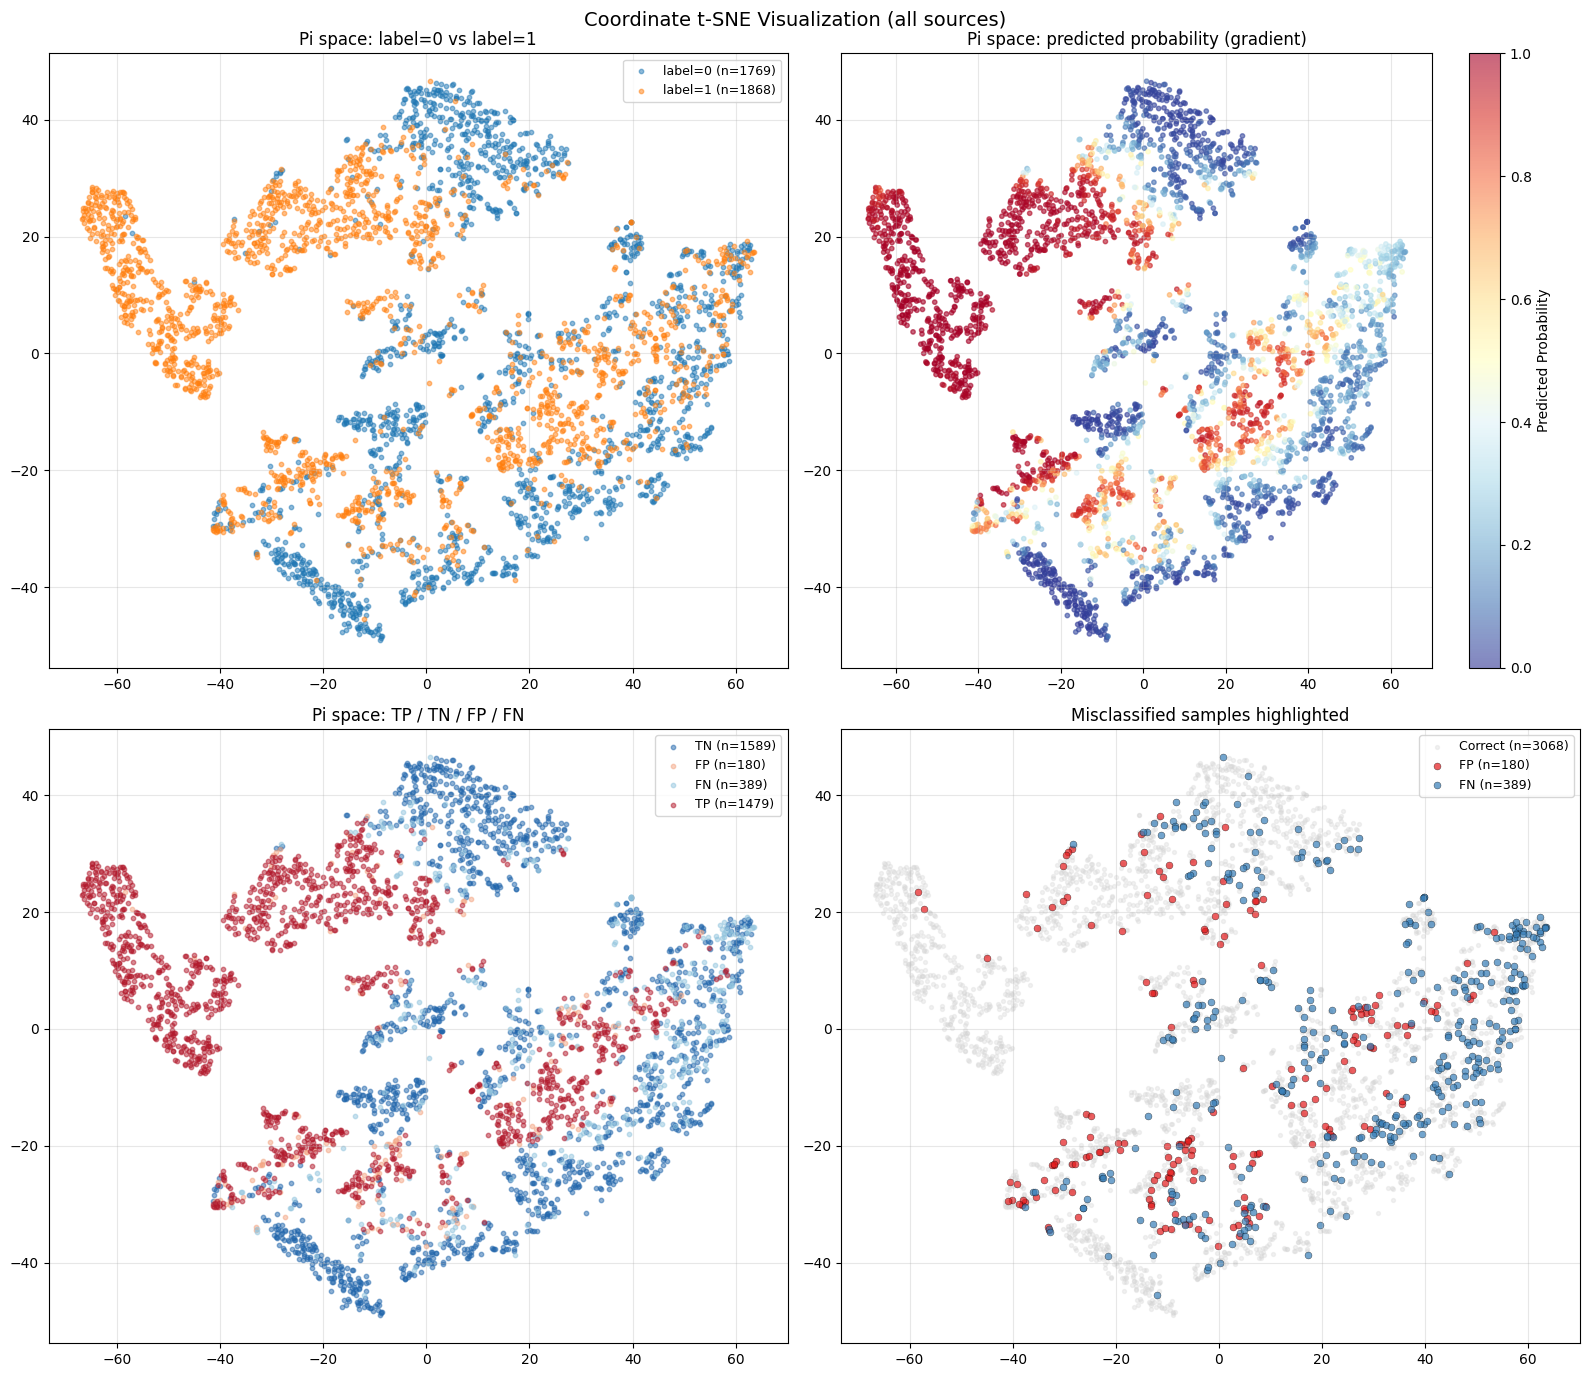


Step 4: Coordinate Distance Analysis

Coordinate Distance Analysis

  FP (y=0 predicted as 1):
    L2 distance to TP centroid: 0.2356
    L2 distance to TN centroid: 0.2237
    Cosine distance to TP: 0.1839
    Cosine distance to TN: 0.1739
    → 46.7% closer to TP, 53.3% closer to TN
    ✗ FP coordinates are closer to TN → unexpected

  FN (y=1 predicted as 0):
    L2 distance to TP centroid: 0.3377
    L2 distance to TN centroid: 0.2119
    Cosine distance to TP: 0.3205
    Cosine distance to TN: 0.1222
    → 87.7% closer to TN, 12.3% closer to TP
    ✓ FN coordinates are closer to TN → model is coordinate-consistent

Step 5: Coordinate Profiles


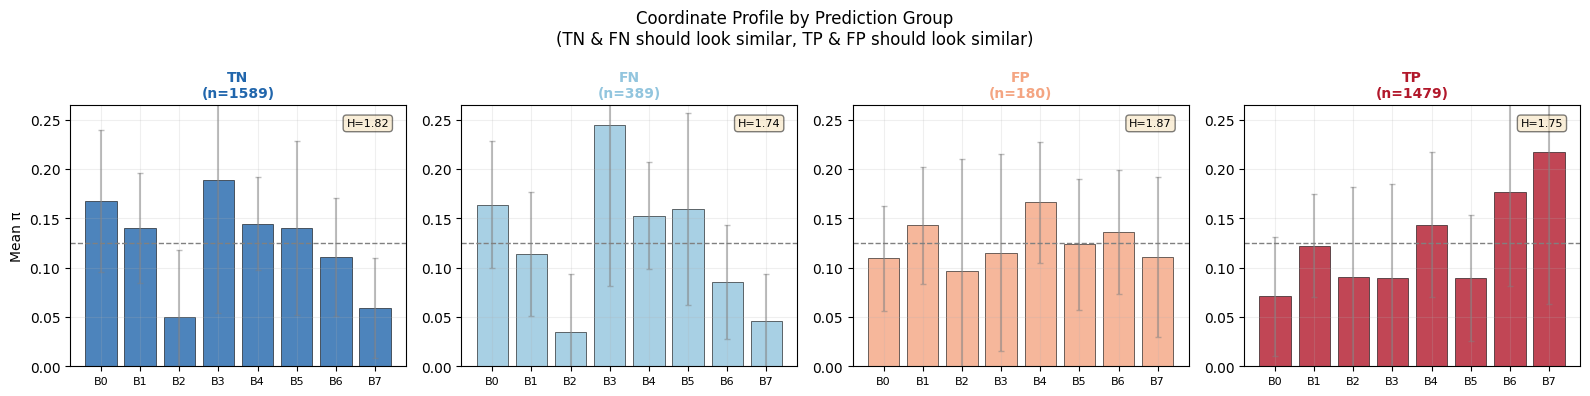


Step 6: Per-Source Analysis


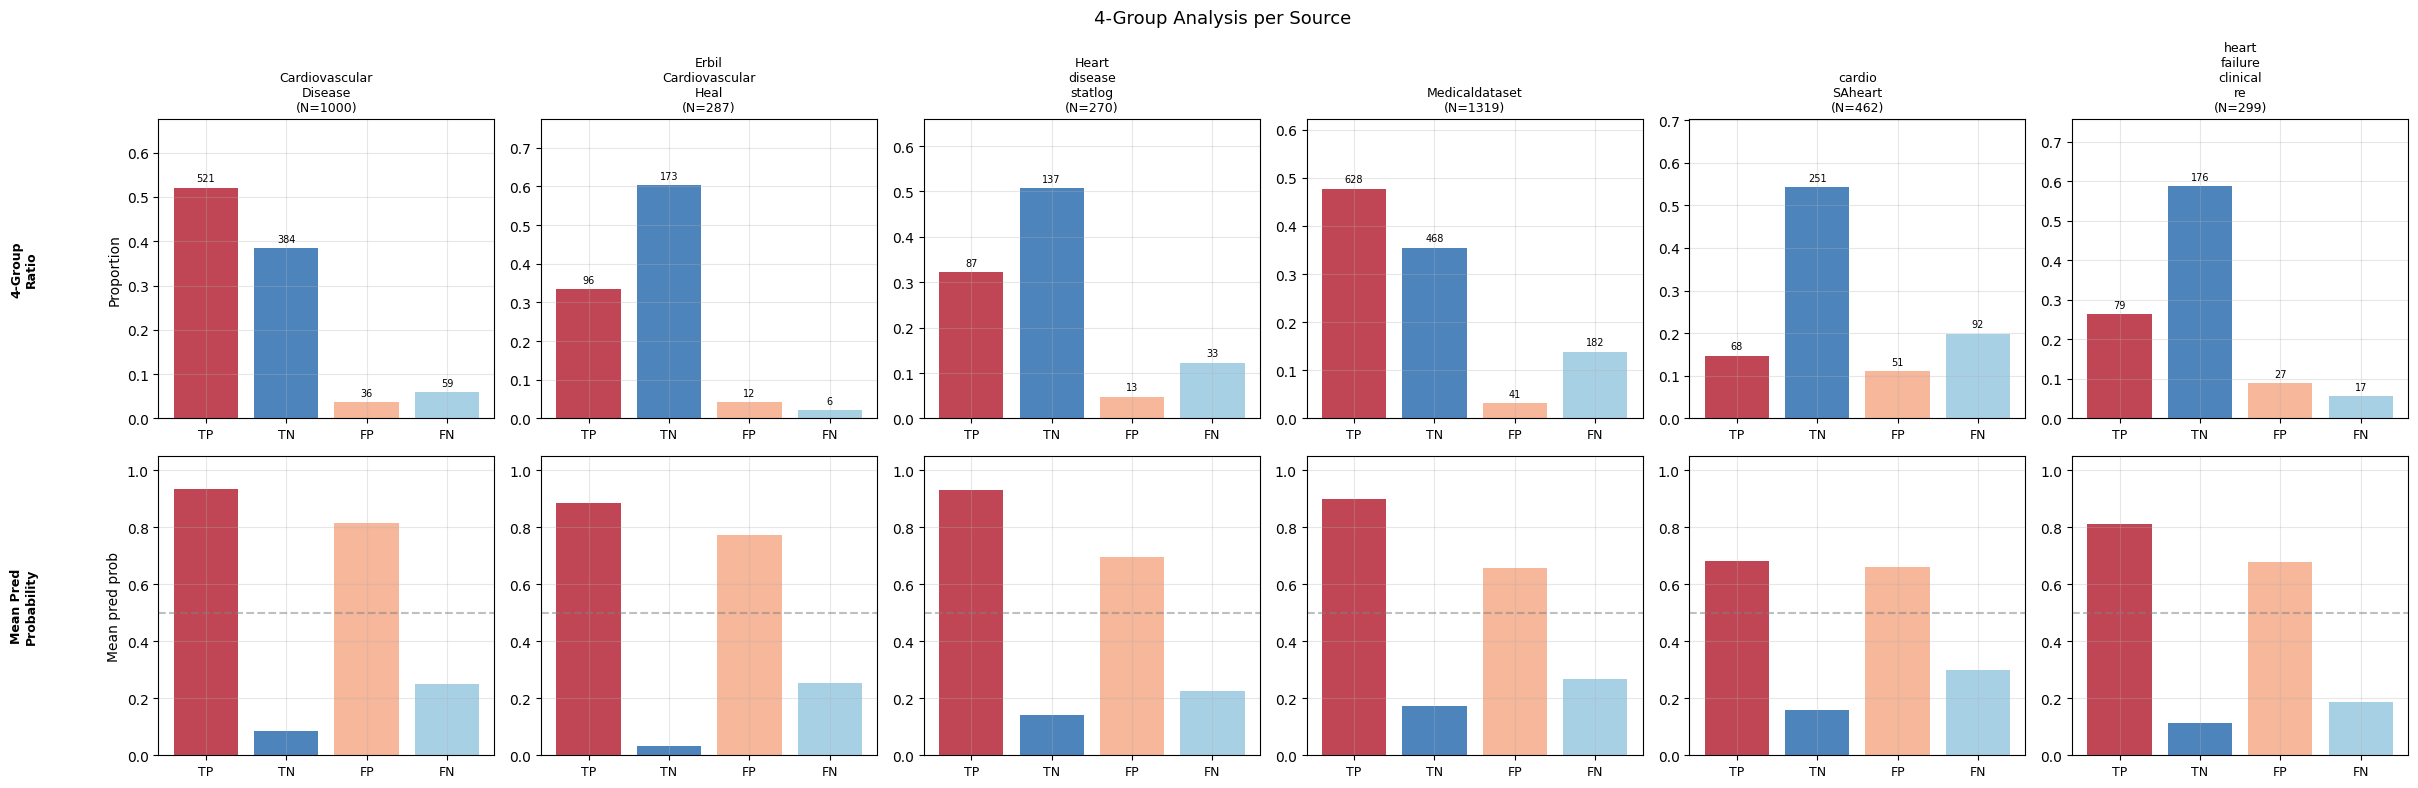


Step 7: Probability Distribution


/tmp/ipykernel_1808760/3355113456.py:443: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_list, labels=labels, patch_artist=True, widths=0.6)


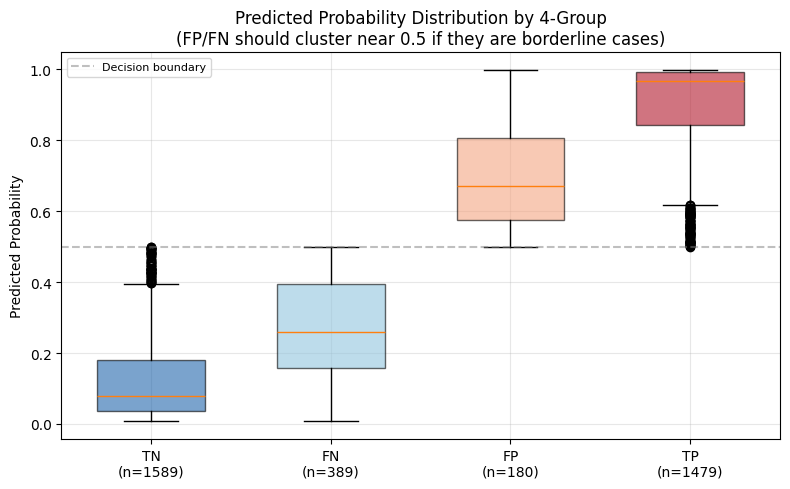

In [44]:
"""
Exp C1. TP/TN/FP/FN Coordinate Analysis

핵심 질문:
- FP(실제 0인데 1로 예측)의 coordinate가 TN보다 TP에 가까운가?
  → 그렇다면 모델이 coordinate 기반으로 일관되게 판단했다는 뜻
- FN(실제 1인데 0으로 예측)의 coordinate가 TP보다 TN에 가까운가?

이것이 보여지면:
→ coordinate가 prediction과 일관되게 연결되어 있다는 근거
→ 모델이 틀릴 때도 coordinate 관점에서는 합리적이었다는 해석

- joint_model_pretrain, args, loaders, sources, device 이미 로딩된 상태
"""

import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.spatial.distance import cdist


# ============================================================
# 1. pi, GT label, predicted probability 수집
# ============================================================

@torch.no_grad()
def extract_pi_label_pred(model, loaders, sources, device):
    """
    모든 source에서 pi, GT label, predicted probability 수집
    """
    model.eval()
    
    all_pi = []
    all_y = []
    all_prob = []
    all_src = []
    
    for src_name in sources:
        loader = loaders[src_name]
        for batch in loader:
            batch_t = {k: (v.to(device) if isinstance(v, torch.Tensor) else v)
                       for k, v in batch.items()}
            
            out = model.predict(batch_t, return_all=True)
            if isinstance(out, tuple):
                global_pred, local_pred = out
            else:
                global_pred = out
            
            pi = model.graph_quantizer.last_pi
            prob = torch.sigmoid(global_pred).squeeze(-1)
            
            all_pi.append(pi.cpu().numpy())
            all_y.append(batch_t['y'].cpu().view(-1).numpy())
            all_prob.append(prob.cpu().view(-1).numpy())
            all_src.extend([src_name] * pi.shape[0])
    
    return {
        'pi': np.concatenate(all_pi, axis=0),
        'y': np.concatenate(all_y, axis=0).astype(int),
        'prob': np.concatenate(all_prob, axis=0),
        'src': np.array(all_src),
    }


# ============================================================
# 2. 4-group 분류
# ============================================================

def classify_4groups(data, threshold=0.5):
    """
    GT label × prediction 기준 4-group 분류
    """
    y = data['y']
    prob = data['prob']
    pred = (prob >= threshold).astype(int)
    
    tp = (y == 1) & (pred == 1)
    tn = (y == 0) & (pred == 0)
    fp = (y == 0) & (pred == 1)
    fn = (y == 1) & (pred == 0)
    
    print(f"4-Group Classification (threshold={threshold}):")
    print(f"  TP: {tp.sum()} (y=1, pred=1)")
    print(f"  TN: {tn.sum()} (y=0, pred=0)")
    print(f"  FP: {fp.sum()} (y=0, pred=1)")
    print(f"  FN: {fn.sum()} (y=1, pred=0)")
    print(f"  Accuracy: {(tp.sum()+tn.sum()) / len(y):.3f}")
    
    return {'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn, 'pred': pred}


# ============================================================
# 3. PCA scatter: 위치=coordinate, 색=prob, shape=GT label
# ============================================================

def plot_tsne_scatter_4group(data, groups):
    """
    t-SNE 2D scatter (4종):
    (a) color=label (기존 스타일)
    (b) color=predicted probability (gradient)
    (c) color=4-group
    (d) misclassified 강조
    """
    pi = data['pi']
    y = data['y']
    prob = data['prob']
    
    perp = max(5, min(40, (len(pi) - 1) // 3))
    print(f"  Running t-SNE (perplexity={perp})...")
    xy = TSNE(n_components=2, perplexity=perp, random_state=42).fit_transform(pi)
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    
    # --- (a) 색=label (기존 스타일) ---
    ax = axes[0, 0]
    for label_val, color, label_name in [(0, 'C0', 'label=0'), (1, 'C1', 'label=1')]:
        mask = (y == label_val)
        ax.scatter(xy[mask, 0], xy[mask, 1], s=10, alpha=0.5,
                   color=color, label=f'{label_name} (n={mask.sum()})')
    ax.set_title('Pi space: label=0 vs label=1')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # --- (b) 색=predicted probability ---
    ax = axes[0, 1]
    sc = ax.scatter(xy[:, 0], xy[:, 1], c=prob, cmap='RdYlBu_r',
                    vmin=0, vmax=1, s=10, alpha=0.6)
    plt.colorbar(sc, ax=ax, label='Predicted Probability')
    ax.set_title('Pi space: predicted probability (gradient)')
    ax.grid(True, alpha=0.3)
    
    # --- (c) 색=4-group ---
    ax = axes[1, 0]
    group_plot_info = [
        ('TN', groups['tn'], '#2166ac'),
        ('FP', groups['fp'], '#f4a582'),
        ('FN', groups['fn'], '#92c5de'),
        ('TP', groups['tp'], '#b2182b'),
    ]
    for name, mask, color in group_plot_info:
        n = mask.sum()
        ax.scatter(xy[mask, 0], xy[mask, 1], c=color, s=10, alpha=0.5,
                   label=f'{name} (n={n})')
    ax.set_title('Pi space: TP / TN / FP / FN')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # --- (d) Misclassified 강조 ---
    ax = axes[1, 1]
    correct = groups['tp'] | groups['tn']
    ax.scatter(xy[correct, 0], xy[correct, 1], c='lightgray',
               s=8, alpha=0.3, label=f'Correct (n={correct.sum()})')
    ax.scatter(xy[groups['fp'], 0], xy[groups['fp'], 1], c='#e41a1c',
               s=25, alpha=0.7, edgecolors='black', linewidth=0.3,
               label=f'FP (n={groups["fp"].sum()})')
    ax.scatter(xy[groups['fn'], 0], xy[groups['fn'], 1], c='#377eb8',
               s=25, alpha=0.7, edgecolors='black', linewidth=0.3,
               label=f'FN (n={groups["fn"].sum()})')
    ax.set_title('Misclassified samples highlighted')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    
    fig.suptitle('Coordinate t-SNE Visualization (all sources)', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    return xy  # 다른 분석에서 재사용 가능


# ============================================================
# 4. Coordinate distance 분석: FP→TP vs FP→TN
# ============================================================

def analyze_coordinate_distances(data, groups):
    """
    FP의 coordinate가 TP에 가까운지 TN에 가까운지 정량적 분석.
    FN도 동일하게.
    
    기대:
    - FP→TP < FP→TN (FP는 coordinate 관점에서 TP에 가깝다)
    - FN→TN < FN→TP (FN은 coordinate 관점에서 TN에 가깝다)
    """
    pi = data['pi']
    
    tp_mean = pi[groups['tp']].mean(axis=0, keepdims=True)
    tn_mean = pi[groups['tn']].mean(axis=0, keepdims=True)
    
    results = {}
    
    for group_name, target_mask in [('FP', groups['fp']), ('FN', groups['fn'])]:
        if target_mask.sum() < 3:
            print(f"  {group_name}: insufficient samples ({target_mask.sum()})")
            continue
        
        group_pi = pi[target_mask]
        
        # 각 sample에서 TP centroid, TN centroid까지 거리
        dist_to_tp = np.linalg.norm(group_pi - tp_mean, axis=1)
        dist_to_tn = np.linalg.norm(group_pi - tn_mean, axis=1)
        
        # cosine distance도
        cos_to_tp = cdist(group_pi, tp_mean, metric='cosine').flatten()
        cos_to_tn = cdist(group_pi, tn_mean, metric='cosine').flatten()
        
        closer_to_tp = (dist_to_tp < dist_to_tn).mean()
        closer_to_tn = (dist_to_tp > dist_to_tn).mean()
        
        results[group_name] = {
            'dist_to_tp_mean': dist_to_tp.mean(),
            'dist_to_tn_mean': dist_to_tn.mean(),
            'cos_to_tp_mean': cos_to_tp.mean(),
            'cos_to_tn_mean': cos_to_tn.mean(),
            'closer_to_tp_pct': closer_to_tp,
            'closer_to_tn_pct': closer_to_tn,
        }
    
    # 출력
    print(f"\n{'='*60}")
    print(f"Coordinate Distance Analysis")
    print(f"{'='*60}")
    
    if 'FP' in results:
        r = results['FP']
        print(f"\n  FP (y=0 predicted as 1):")
        print(f"    L2 distance to TP centroid: {r['dist_to_tp_mean']:.4f}")
        print(f"    L2 distance to TN centroid: {r['dist_to_tn_mean']:.4f}")
        print(f"    Cosine distance to TP: {r['cos_to_tp_mean']:.4f}")
        print(f"    Cosine distance to TN: {r['cos_to_tn_mean']:.4f}")
        print(f"    → {r['closer_to_tp_pct']*100:.1f}% closer to TP, "
              f"{r['closer_to_tn_pct']*100:.1f}% closer to TN")
        
        if r['dist_to_tp_mean'] < r['dist_to_tn_mean']:
            print(f"    ✓ FP coordinates are closer to TP → model is coordinate-consistent")
        else:
            print(f"    ✗ FP coordinates are closer to TN → unexpected")
    
    if 'FN' in results:
        r = results['FN']
        print(f"\n  FN (y=1 predicted as 0):")
        print(f"    L2 distance to TP centroid: {r['dist_to_tp_mean']:.4f}")
        print(f"    L2 distance to TN centroid: {r['dist_to_tn_mean']:.4f}")
        print(f"    Cosine distance to TP: {r['cos_to_tp_mean']:.4f}")
        print(f"    Cosine distance to TN: {r['cos_to_tn_mean']:.4f}")
        print(f"    → {r['closer_to_tn_pct']*100:.1f}% closer to TN, "
              f"{r['closer_to_tp_pct']*100:.1f}% closer to TP")
        
        if r['dist_to_tn_mean'] < r['dist_to_tp_mean']:
            print(f"    ✓ FN coordinates are closer to TN → model is coordinate-consistent")
        else:
            print(f"    ✗ FN coordinates are closer to TP → unexpected")
    
    return results


# ============================================================
# 5. 4-group 평균 coordinate profile 비교
# ============================================================

def plot_4group_coordinate_profiles(data, groups):
    """
    4개 그룹의 평균 coordinate vector를 나란히 비교
    
    기대:
    - TP와 FP의 coordinate profile이 유사 (둘 다 positive로 예측)
    - TN과 FN의 coordinate profile이 유사 (둘 다 negative로 예측)
    """
    pi = data['pi']
    M = pi.shape[1]
    
    group_info = [
        ('TN', groups['tn'], '#2166ac'),
        ('FN', groups['fn'], '#92c5de'),
        ('FP', groups['fp'], '#f4a582'),
        ('TP', groups['tp'], '#b2182b'),
    ]
    
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    # 공통 y축 범위
    all_means = []
    for name, mask, color in group_info:
        if mask.sum() >= 3:
            all_means.append(pi[mask].mean(axis=0))
    if all_means:
        y_max = max(m.max() for m in all_means) + 0.02
    else:
        y_max = 0.5
    
    for idx, (name, mask, color) in enumerate(group_info):
        ax = axes[idx]
        n = mask.sum()
        
        if n < 3:
            ax.set_title(f"{name}\n(n={n}, insufficient)", fontsize=10)
            ax.set_visible(False)
            continue
        
        mean_pi = pi[mask].mean(axis=0)
        std_pi = pi[mask].std(axis=0)
        
        ax.bar(range(M), mean_pi, color=color, alpha=0.8,
               edgecolor='black', linewidth=0.5)
        ax.errorbar(range(M), mean_pi, yerr=std_pi, fmt='none',
                    ecolor='gray', capsize=2, alpha=0.5)
        ax.axhline(1.0 / M, linestyle='--', color='gray', linewidth=1)
        ax.set_ylim(0, y_max)
        ax.set_xticks(range(M))
        ax.set_xticklabels([f'B{k}' for k in range(M)], fontsize=8)
        ax.set_title(f"{name}\n(n={n})", fontsize=10, color=color, fontweight='bold')
        ax.set_ylabel('Mean π' if idx == 0 else '')
        ax.grid(True, alpha=0.2)
        
        # entropy
        entropies = -np.sum(pi[mask] * np.log(pi[mask] + 1e-8), axis=1)
        ax.text(0.95, 0.95, f"H={entropies.mean():.2f}",
                transform=ax.transAxes, ha='right', va='top', fontsize=8,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    fig.suptitle(
        "Coordinate Profile by Prediction Group\n"
        "(TN & FN should look similar, TP & FP should look similar)",
        fontsize=12
    )
    plt.tight_layout()
    plt.show()


# ============================================================
# 6. Source별 4-group 분석
# ============================================================

def plot_4group_per_source(data, groups):
    """
    Source별로 4-group 비율과 coordinate 특성을 비교
    """
    pi = data['pi']
    y = data['y']
    prob = data['prob']
    src = data['src']
    
    unique_sources = sorted(set(src))
    n_src = len(unique_sources)
    
    fig, axes = plt.subplots(2, n_src, figsize=(4 * n_src, 8))
    if n_src == 1:
        axes = axes[:, np.newaxis]
    
    group_names = ['TP', 'TN', 'FP', 'FN']
    group_masks = [groups['tp'], groups['tn'], groups['fp'], groups['fn']]
    group_colors = ['#b2182b', '#2166ac', '#f4a582', '#92c5de']
    
    for col, src_name in enumerate(unique_sources):
        s_mask = (src == src_name)
        n_s = s_mask.sum()
        
        # Row 0: 4-group 비율 (pie chart 대신 stacked bar)
        ax = axes[0, col]
        counts = [((s_mask) & gm).sum() for gm in group_masks]
        ratios = [c / n_s for c in counts]
        
        bars = ax.bar(range(4), ratios, color=group_colors, alpha=0.8)
        ax.set_xticks(range(4))
        ax.set_xticklabels(group_names, fontsize=9)
        ax.set_ylim(0, max(ratios) * 1.2 + 0.05)
        
        short_name = src_name.replace('_Dataset', '').replace('_', '\n')[:25]
        ax.set_title(f"{short_name}\n(N={n_s})", fontsize=9)
        ax.set_ylabel('Proportion' if col == 0 else '')
        ax.grid(True, alpha=0.3)
        
        for bar, count in zip(bars, counts):
            if count > 0:
                ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                        f'{count}', ha='center', va='bottom', fontsize=7)
        
        # Row 1: 4-group mean predicted probability
        ax = axes[1, col]
        mean_probs = []
        for gm in group_masks:
            combined = s_mask & gm
            if combined.sum() > 0:
                mean_probs.append(prob[combined].mean())
            else:
                mean_probs.append(0)
        
        ax.bar(range(4), mean_probs, color=group_colors, alpha=0.8)
        ax.set_xticks(range(4))
        ax.set_xticklabels(group_names, fontsize=9)
        ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
        ax.set_ylim(0, 1.05)
        ax.set_ylabel('Mean pred prob' if col == 0 else '')
        ax.grid(True, alpha=0.3)
    
    axes[0, 0].annotate('4-Group\nRatio', xy=(-0.4, 0.5), xycoords='axes fraction',
                         fontsize=9, fontweight='bold', ha='center', va='center', rotation=90)
    axes[1, 0].annotate('Mean Pred\nProbability', xy=(-0.4, 0.5), xycoords='axes fraction',
                         fontsize=9, fontweight='bold', ha='center', va='center', rotation=90)
    
    fig.suptitle("4-Group Analysis per Source", fontsize=13)
    plt.tight_layout()
    plt.show()


# ============================================================
# 7. Predicted probability 분포 by 4-group (violin)
# ============================================================

def plot_prob_distribution_4group(data, groups):
    """
    4개 그룹의 predicted probability 분포를 violin plot으로 비교
    
    기대:
    - TP: prob가 1에 가까이 분포
    - TN: prob가 0에 가까이 분포
    - FP: prob가 0.5 근처 (borderline)
    - FN: prob가 0.5 근처 (borderline)
    """
    prob = data['prob']
    
    group_info = [
        ('TN', groups['tn'], '#2166ac'),
        ('FN', groups['fn'], '#92c5de'),
        ('FP', groups['fp'], '#f4a582'),
        ('TP', groups['tp'], '#b2182b'),
    ]
    
    fig, ax = plt.subplots(1, 1, figsize=(8, 5))
    
    data_list = []
    labels = []
    colors = []
    
    for name, mask, color in group_info:
        n = mask.sum()
        if n >= 3:
            data_list.append(prob[mask])
            labels.append(f"{name}\n(n={n})")
            colors.append(color)
    
    bp = ax.boxplot(data_list, labels=labels, patch_artist=True, widths=0.6)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Decision boundary')
    ax.set_ylabel('Predicted Probability')
    ax.set_title('Predicted Probability Distribution by 4-Group\n'
                 '(FP/FN should cluster near 0.5 if they are borderline cases)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


# ============================================================
# 8. 전체 실행
# ============================================================

def run_c1_analysis(model, loaders, sources, device, threshold=0.5):
    """C1 전체 파이프라인"""
    
    # (1) 수집
    print("="*60)
    print("Step 1: Extracting pi, labels, predictions")
    print("="*60)
    data = extract_pi_label_pred(model, loaders, sources, device)
    print(f"  Total: {len(data['y'])} samples")
    print(f"  Label dist: {dict(zip(*np.unique(data['y'], return_counts=True)))}")
    print(f"  Pred prob range: [{data['prob'].min():.3f}, {data['prob'].max():.3f}]")
    
    # (2) 4-group 분류
    print(f"\n{'='*60}")
    print("Step 2: 4-Group Classification")
    print("="*60)
    groups = classify_4groups(data, threshold=threshold)
    
    # (3) PCA scatter
    print(f"\n{'='*60}")
    print("Step 3: t-SNE Visualization")
    print("="*60)
    tsne_xy = plot_tsne_scatter_4group(data, groups)
    
    # (4) Coordinate distance 분석
    print(f"\n{'='*60}")
    print("Step 4: Coordinate Distance Analysis")
    print("="*60)
    dist_results = analyze_coordinate_distances(data, groups)
    
    # (5) 4-group coordinate profiles
    print(f"\n{'='*60}")
    print("Step 5: Coordinate Profiles")
    print("="*60)
    plot_4group_coordinate_profiles(data, groups)
    
    # (6) Source별 분석
    print(f"\n{'='*60}")
    print("Step 6: Per-Source Analysis")
    print("="*60)
    plot_4group_per_source(data, groups)
    
    # (7) Probability distribution
    print(f"\n{'='*60}")
    print("Step 7: Probability Distribution")
    print("="*60)
    plot_prob_distribution_4group(data, groups)
    
    return {
        'data': data,
        'groups': groups,
        'dist_results': dist_results,
        'tsne_xy': tsne_xy,
    }


# ============================================================
# 호출
# ============================================================
c1_result = run_c1_analysis(joint_model_pretrain, loaders, sources, device)

## Exp 2.1. TP-only subgroup feature analysis. 


[Medicaldataset] N=1319, TP=628, TN=468, FP=41, FN=182

[Medicaldataset] TP+TN Combined: 1096 samples (TP=628, TN=468)


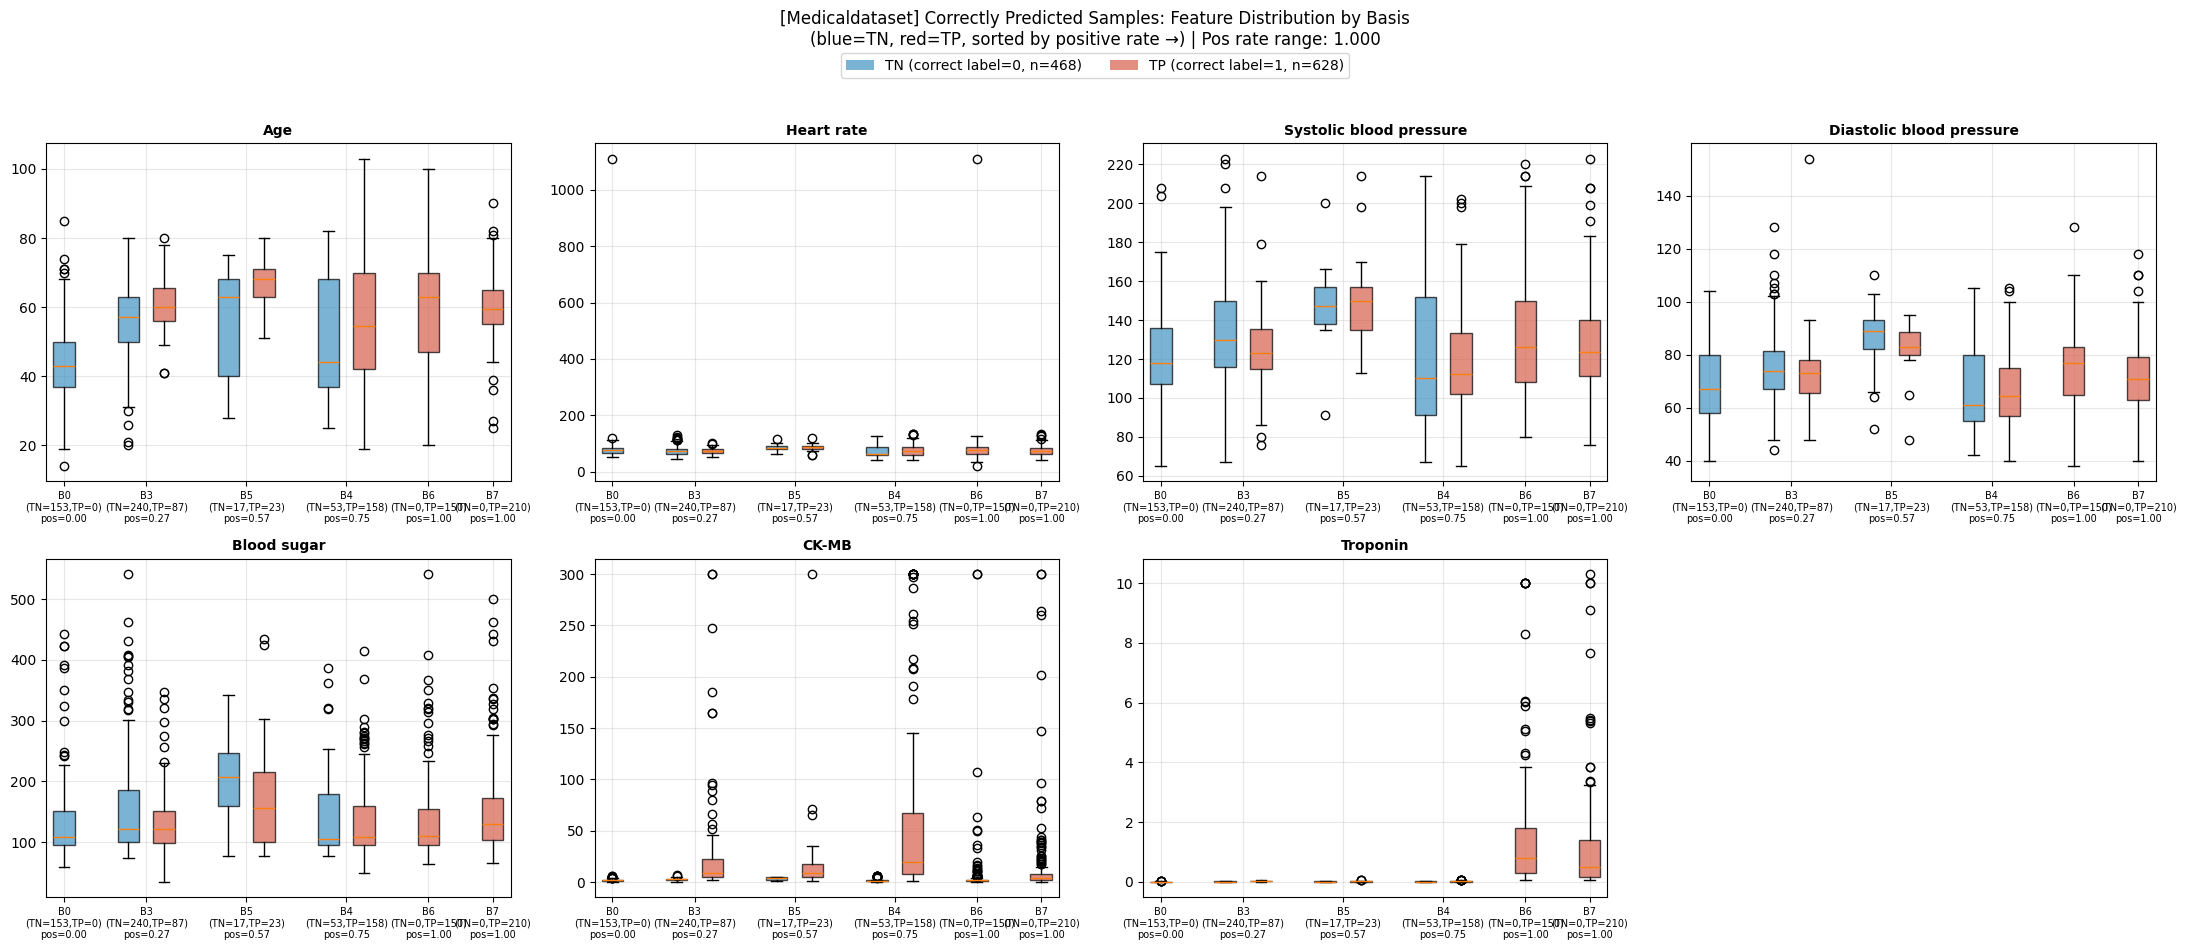


[Cardiovascular_Disease_Dataset] N=1000, TP=521, TN=384, FP=36, FN=59

[Cardiovascular_Disease_Dataset] TP+TN Combined: 905 samples (TP=521, TN=384)


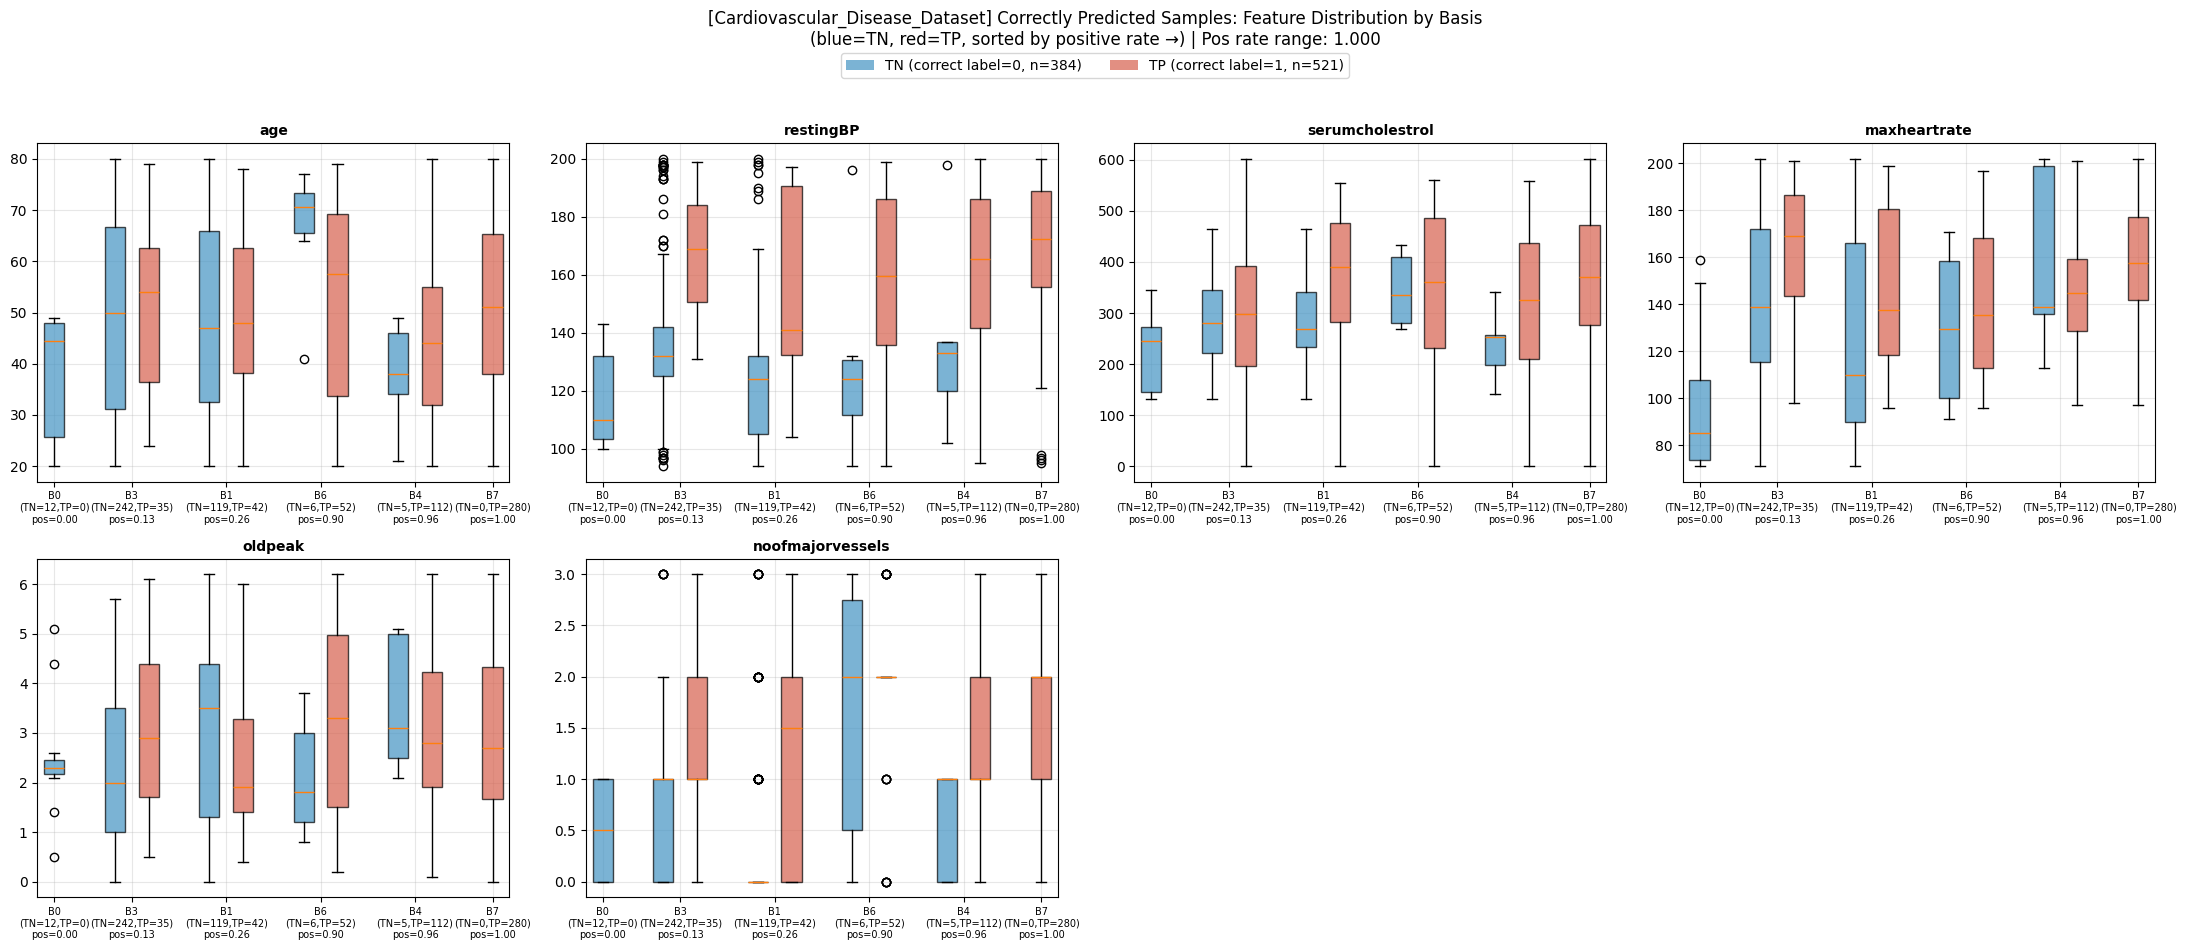


[Heart_disease_statlog] N=270, TP=87, TN=137, FP=13, FN=33

[Heart_disease_statlog] TP+TN Combined: 224 samples (TP=87, TN=137)


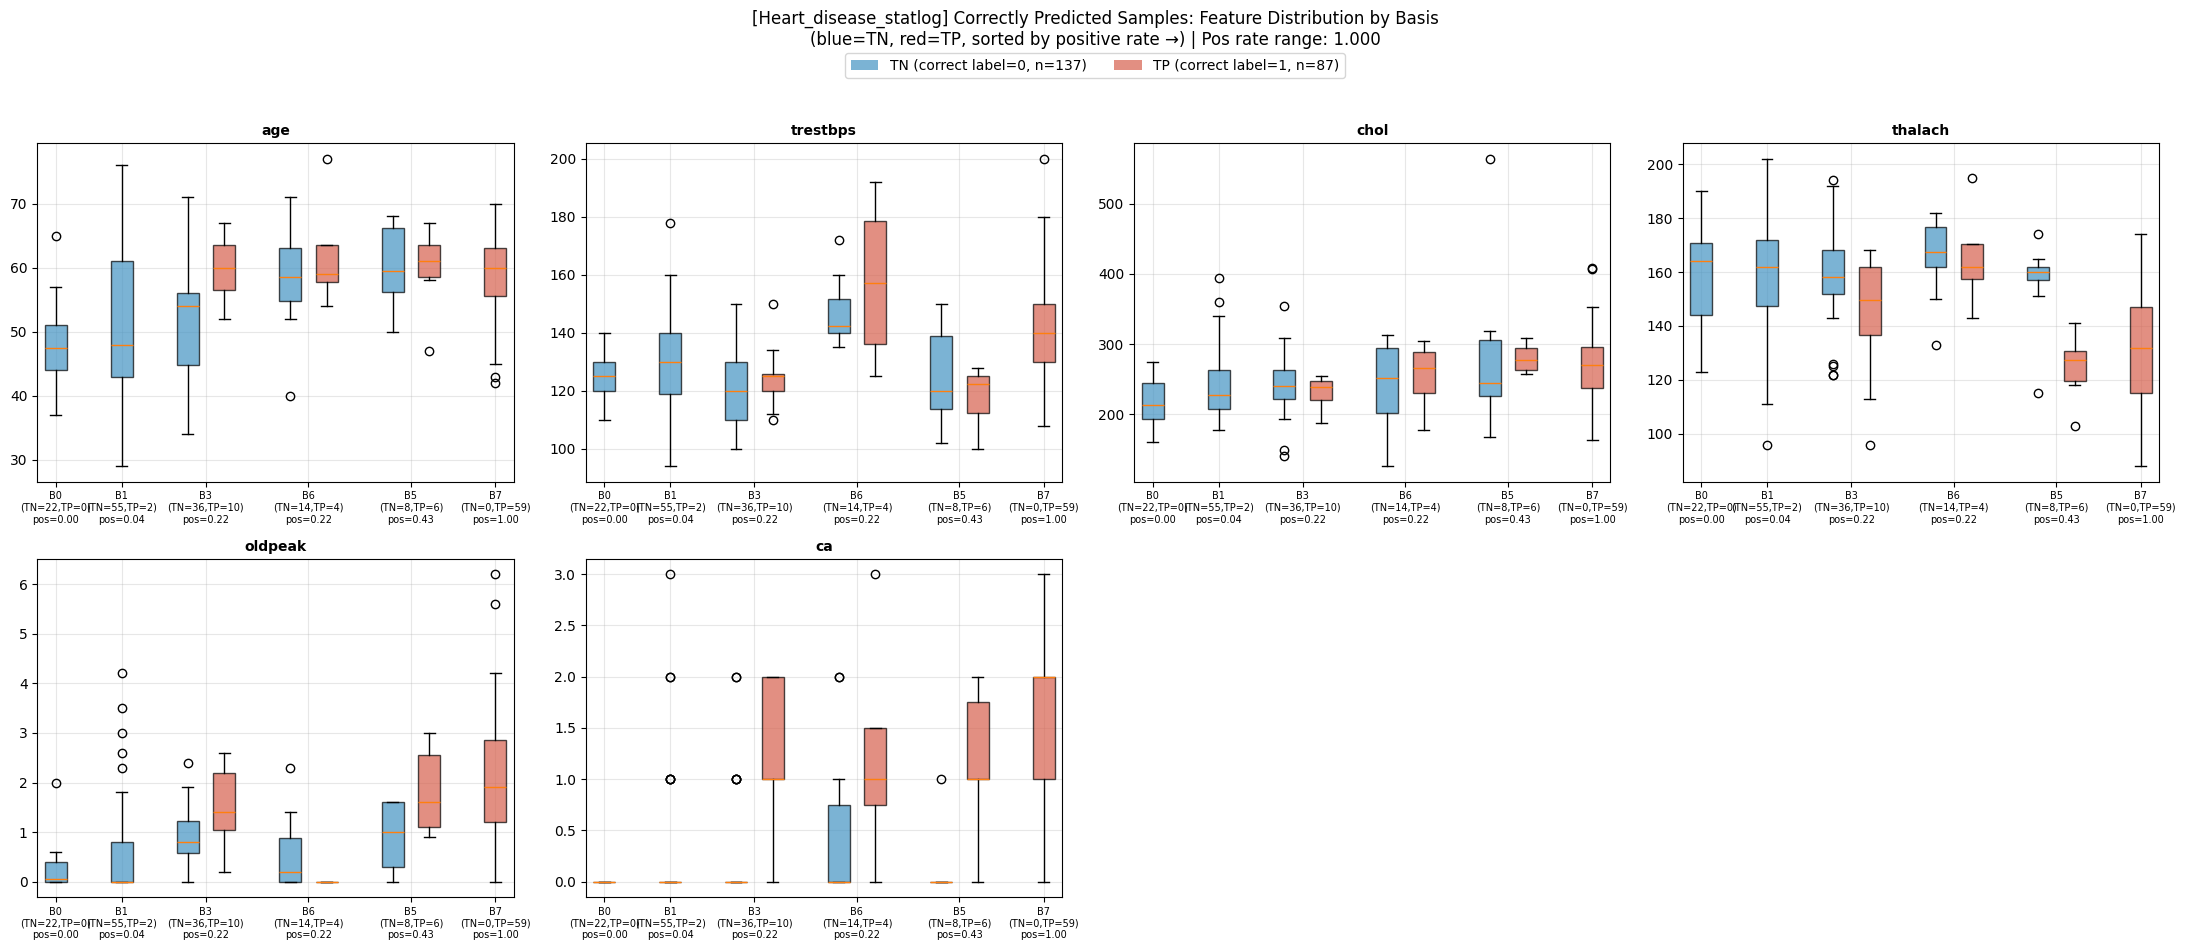


[Erbil_Cardiovascular_Health_Dataset] N=287, TP=96, TN=173, FP=12, FN=6

[Erbil_Cardiovascular_Health_Dataset] TP+TN Combined: 269 samples (TP=96, TN=173)


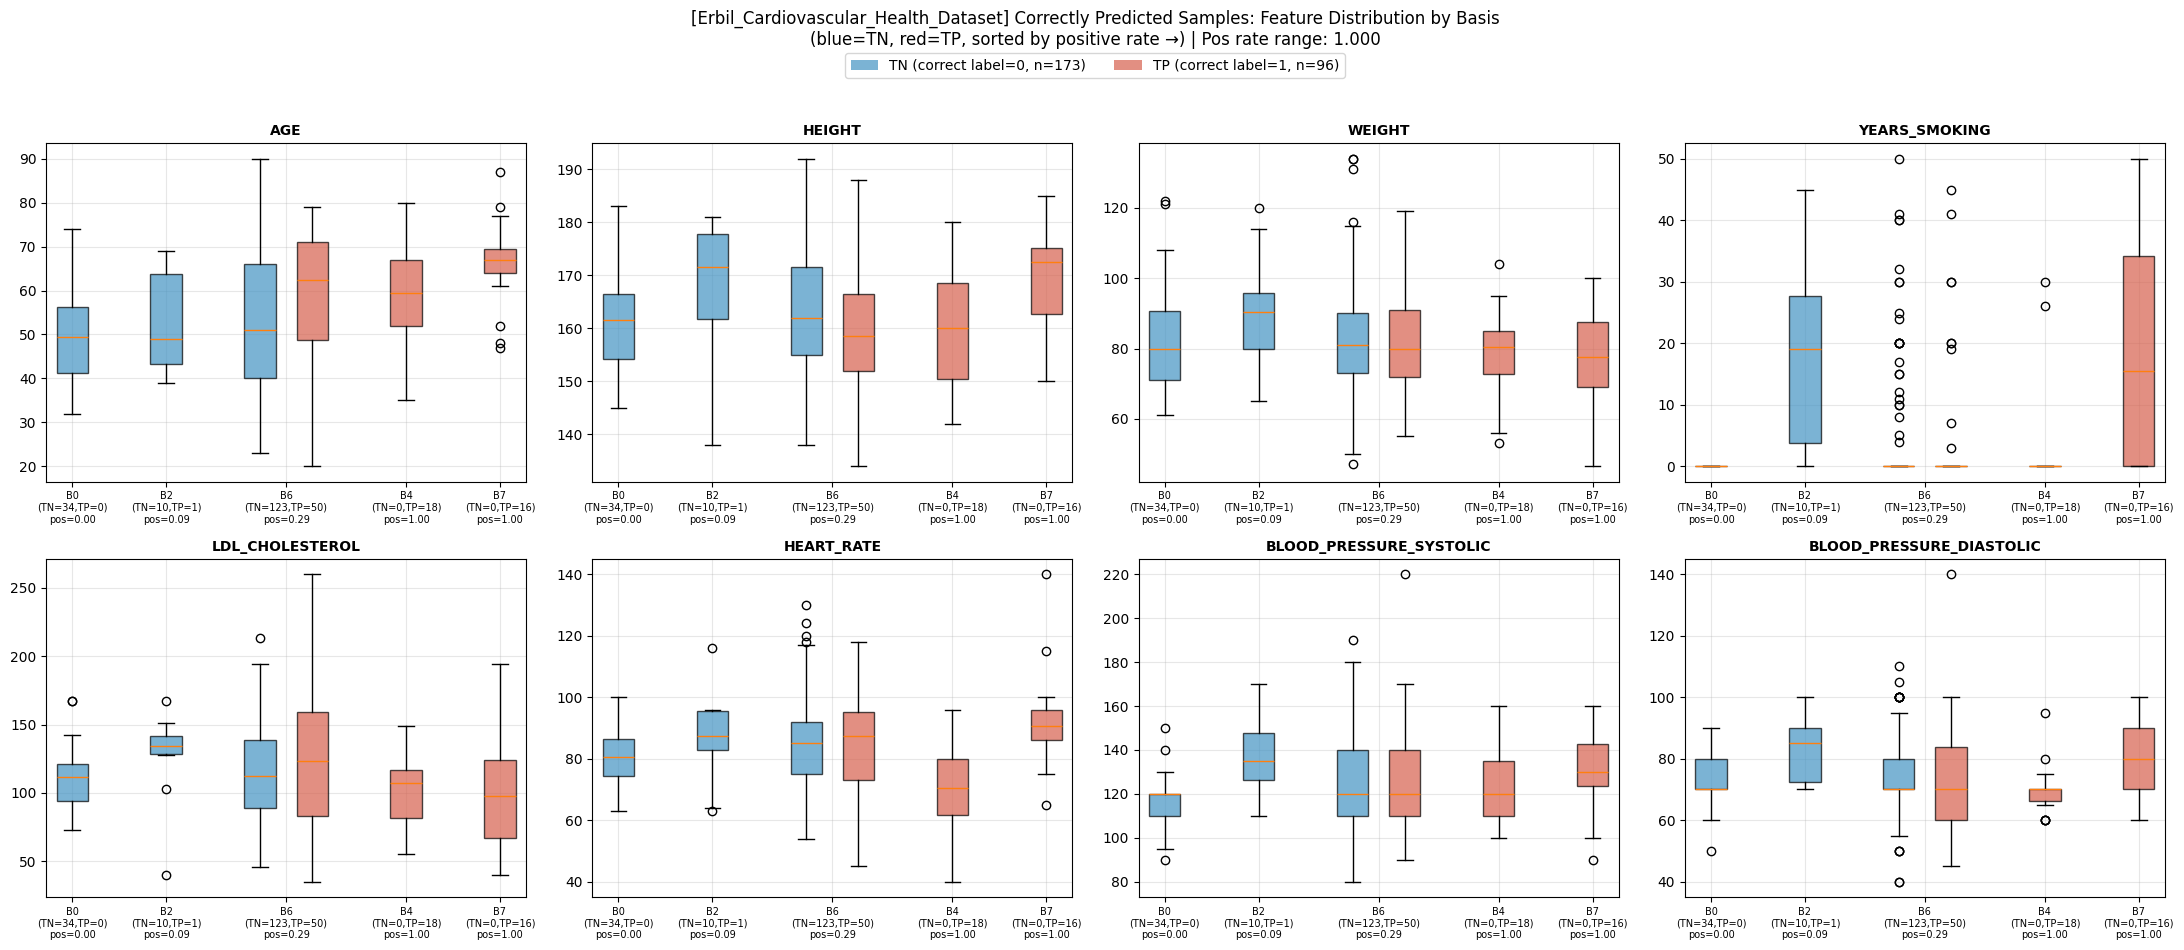


[cardio_SAheart] N=462, TP=68, TN=251, FP=51, FN=92

[cardio_SAheart] TP+TN Combined: 319 samples (TP=68, TN=251)


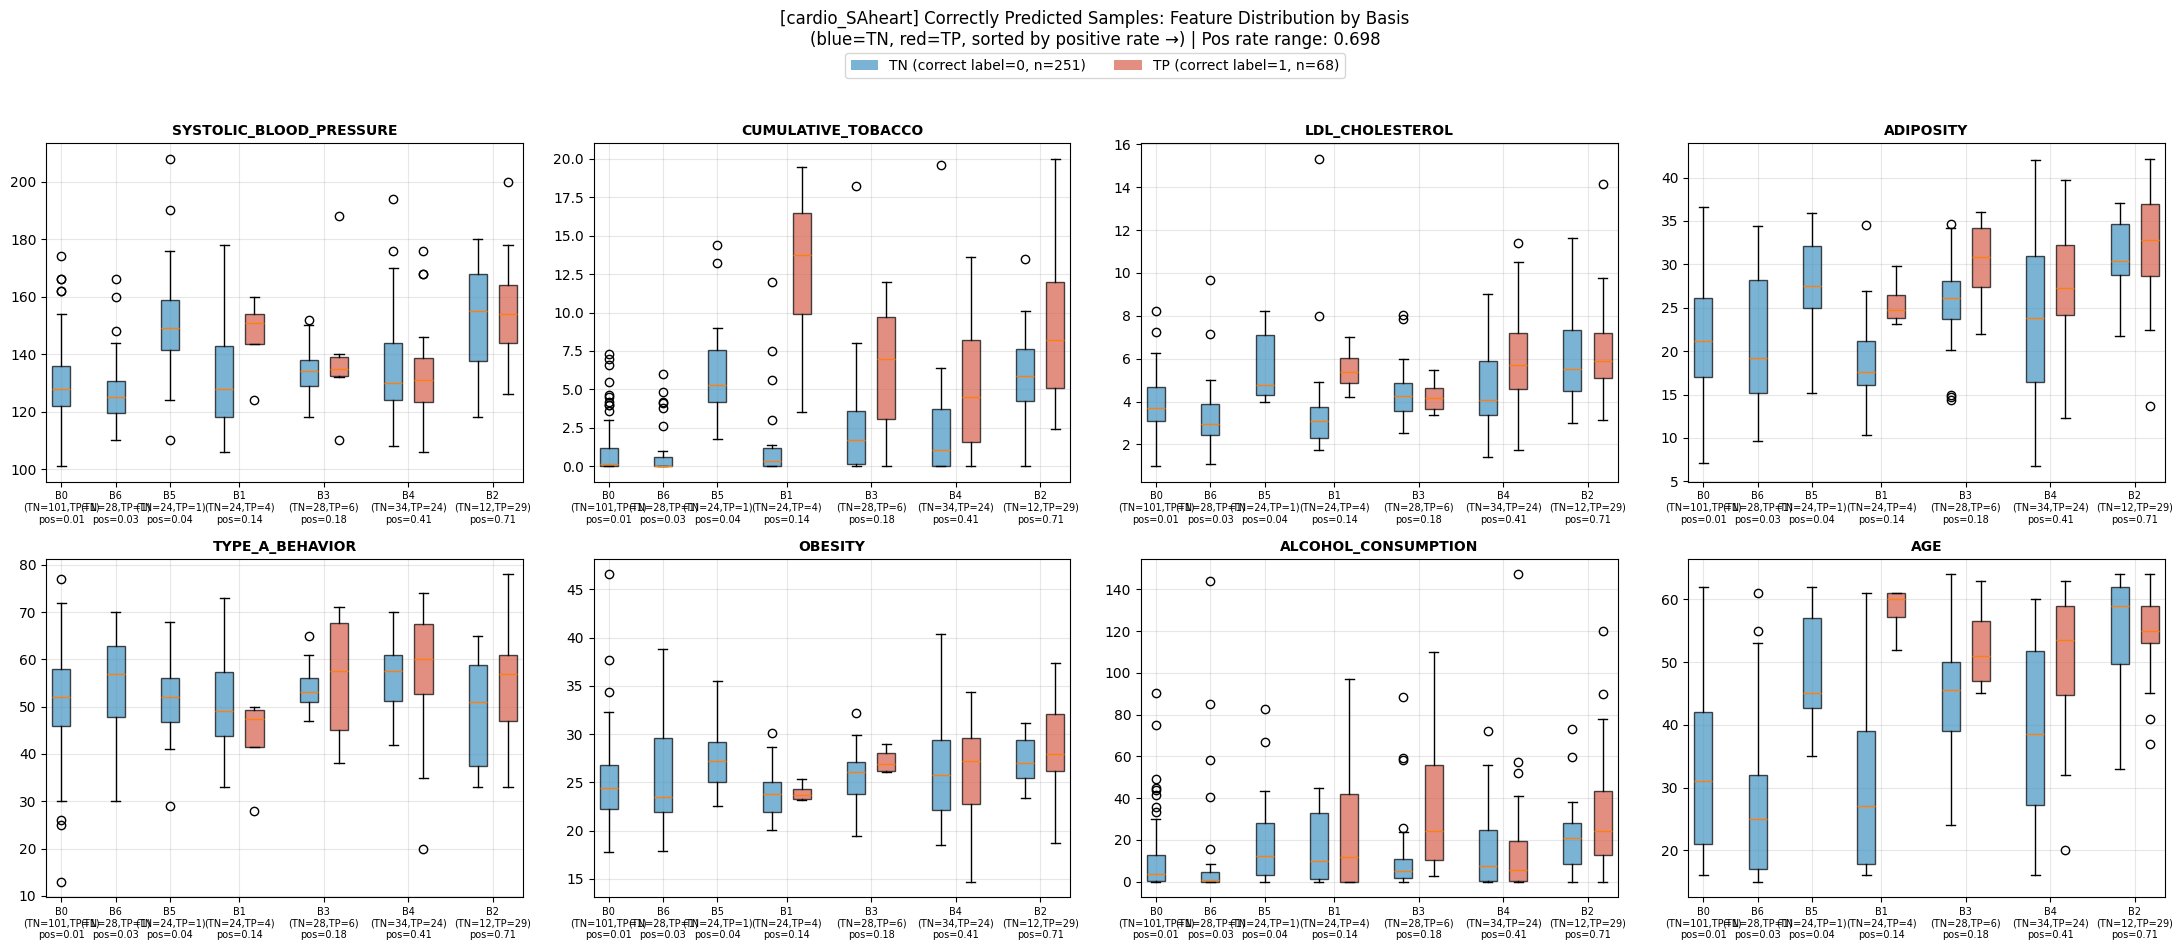


[heart_failure_clinical_records] N=299, TP=79, TN=176, FP=27, FN=17

[heart_failure_clinical_records] TP+TN Combined: 255 samples (TP=79, TN=176)


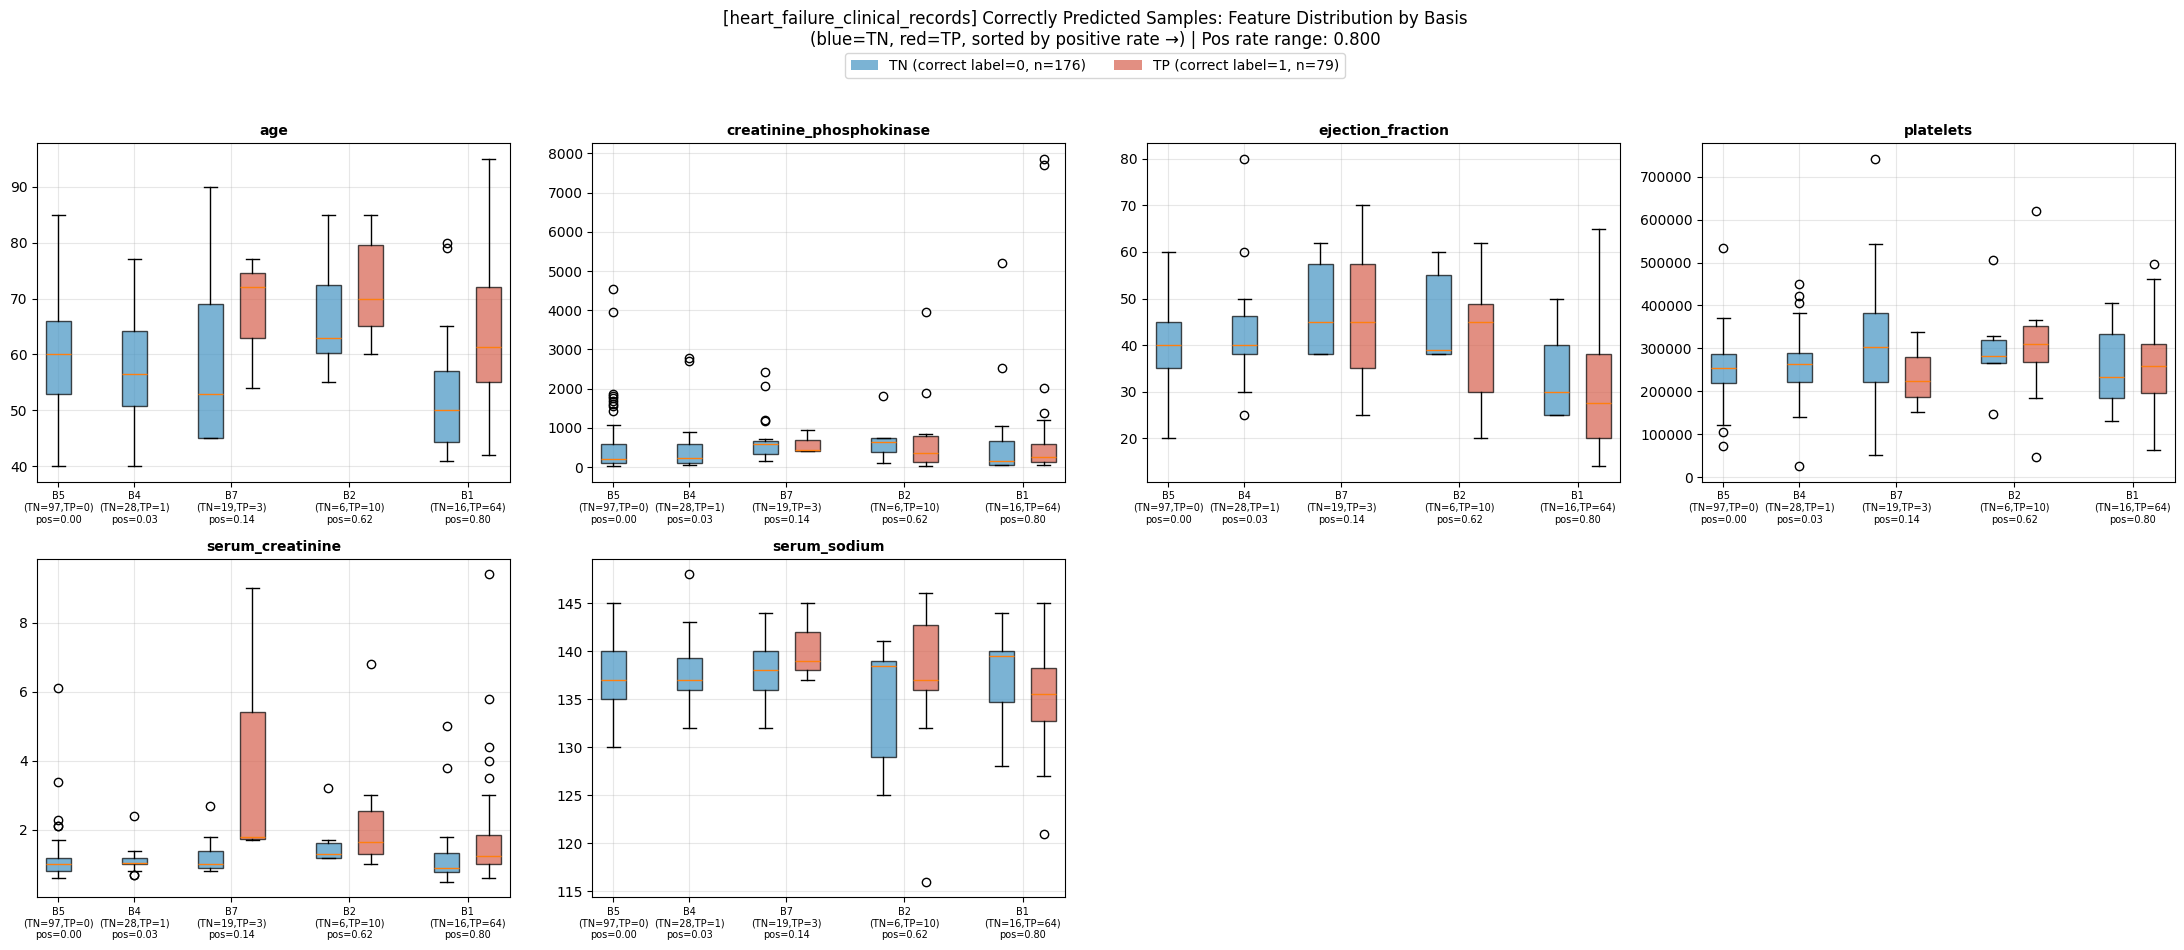

In [45]:
"""
Exp 2-1b. TP + TN Combined Feature Analysis

TP(빨강)과 TN(파랑)을 같은 basis subgroup 안에서 나란히 비교
→ 같은 basis에 배정된 "정상"과 "환자"가 feature에서 어떻게 다른지 한눈에
→ prediction이 맞은 sample만 사용
"""

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

EXCLUDE_FEATURES = {
    'patientid', 'patient_id', 'id', 'ID',
    'time',
}

# ============================================================
# 1. TP+TN Combined Boxplot
# ============================================================

def plot_tp_tn_combined(result, max_features=8, min_subgroup_size=10):
    """
    각 basis subgroup에서 TP(빨강)과 TN(파랑)을 나란히 boxplot
    - subgroup은 GT positive rate 순으로 정렬
    - prediction이 맞은 sample만 사용
    """
    dataset_name = result['dataset_name']
    X = result['X']
    argmax = result['argmax']
    tp_mask = result['tp_mask']
    tn_mask = result['tn_mask']
    probs = result['probs']
    ys = result['ys']
    
    # TP + TN만 사용
    correct_mask = tp_mask | tn_mask
    X_correct = X.loc[correct_mask].reset_index(drop=True)
    argmax_correct = argmax[correct_mask]
    ys_correct = ys[correct_mask]
    probs_correct = probs[correct_mask]
    tp_in_correct = tp_mask[correct_mask]  # correct 중에서 TP인지
    
    n_correct = correct_mask.sum()
    n_tp = tp_mask.sum()
    n_tn = tn_mask.sum()
    
    print(f"\n[{dataset_name}] TP+TN Combined: {n_correct} samples (TP={n_tp}, TN={n_tn})")
    
    # active subgroups
    M = result['pis'].shape[1]
    unique_sg, counts = np.unique(argmax_correct, return_counts=True)
    active_sg = unique_sg[counts >= min_subgroup_size]
    
    if len(active_sg) < 2:
        active_sg = unique_sg[counts >= 5]
        if len(active_sg) < 2:
            print(f"  Not enough subgroups. Skipping.")
            return
    
    # pos_rate 순 정렬 (correct sample 기준)
    pos_rates = {}
    for sg in active_sg:
        sg_mask = (argmax_correct == sg)
        pos_rates[sg] = ys_correct[sg_mask].mean()
    sorted_sg = sorted(active_sg, key=lambda s: pos_rates[s])
    
    # numerical columns
    num_cols = [c for c in X_correct.select_dtypes(include=[np.number]).columns
                if c.lower() not in {f.lower() for f in EXCLUDE_FEATURES}][:max_features]
    
    if len(num_cols) == 0:
        print(f"  No numerical columns")
        return
    
    n_cols_plot = min(4, len(num_cols))
    n_rows_plot = (len(num_cols) + n_cols_plot - 1) // n_cols_plot
    
    fig, axes = plt.subplots(n_rows_plot, n_cols_plot,
                              figsize=(5.5 * n_cols_plot, 4.5 * n_rows_plot))
    if n_rows_plot == 1 and n_cols_plot == 1:
        axes = np.array([[axes]])
    elif n_rows_plot == 1:
        axes = axes[np.newaxis, :]
    elif n_cols_plot == 1:
        axes = axes[:, np.newaxis]
    
    for i, col in enumerate(num_cols):
        row, c = i // n_cols_plot, i % n_cols_plot
        ax = axes[row, c]
        
        positions = []
        data_list = []
        colors_list = []
        tick_positions = []
        tick_labels = []
        
        pos = 0
        for sg_idx, sg in enumerate(sorted_sg):
            sg_mask = (argmax_correct == sg)
            n_sg = sg_mask.sum()
            
            # TN in this subgroup
            tn_sg = sg_mask & (~tp_in_correct)
            tp_sg = sg_mask & (tp_in_correct)
            
            tn_vals = pd.to_numeric(X_correct.loc[tn_sg, col], errors='coerce').dropna().values.astype(float)
            tp_vals = pd.to_numeric(X_correct.loc[tp_sg, col], errors='coerce').dropna().values.astype(float)
            
            has_tn = len(tn_vals) >= 3
            has_tp = len(tp_vals) >= 3
            
            if has_tn:
                data_list.append(tn_vals)
                positions.append(pos)
                colors_list.append('#4393c3')  # blue = TN
                pos += 1
            
            if has_tp:
                data_list.append(tp_vals)
                positions.append(pos)
                colors_list.append('#d6604d')  # red = TP
                pos += 1
            
            if has_tn or has_tp:
                n_tn_sg = tn_sg.sum()
                n_tp_sg = tp_sg.sum()
                center = (positions[-1] + positions[-2]) / 2 if (has_tn and has_tp) else positions[-1]
                tick_positions.append(center)
                tick_labels.append(f"B{sg}\n(TN={n_tn_sg},TP={n_tp_sg})\npos={pos_rates[sg]:.2f}")
                pos += 0.8  # gap between subgroups
        
        if len(data_list) < 2:
            ax.set_visible(False)
            continue
        
        bp = ax.boxplot(data_list, positions=positions, widths=0.6, patch_artist=True)
        for patch, color in zip(bp['boxes'], colors_list):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        
        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels, fontsize=7)
        ax.set_title(col, fontsize=10, fontweight='bold')
        ax.grid(True, alpha=0.3)
    
    # 빈 subplot 숨기기
    for i in range(len(num_cols), n_rows_plot * n_cols_plot):
        row, c = i // n_cols_plot, i % n_cols_plot
        axes[row, c].set_visible(False)
    
    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#4393c3', alpha=0.7, label=f'TN (correct label=0, n={n_tn})'),
        Patch(facecolor='#d6604d', alpha=0.7, label=f'TP (correct label=1, n={n_tp})'),
    ]
    fig.legend(handles=legend_elements, loc='upper center', ncol=2, fontsize=10,
               bbox_to_anchor=(0.5, 1.01))
    
    pos_rate_range = max(pos_rates.values()) - min(pos_rates.values())
    fig.suptitle(
        f"[{dataset_name}] Correctly Predicted Samples: Feature Distribution by Basis\n"
        f"(blue=TN, red=TP, sorted by positive rate →) | "
        f"Pos rate range: {pos_rate_range:.3f}",
        fontsize=12, y=1.05
    )
    plt.tight_layout()
    plt.show()

@torch.no_grad()
def extract_tp_tn_with_tabular(model, loader, device, dataset_name):
    model.eval()
    X_orig, y_orig = load_original_tabular(dataset_name)
    
    all_pi = []
    all_y = []
    all_prob = []
    all_sidx = []
    
    for batch in loader:
        batch_t = {k: (v.to(device) if isinstance(v, torch.Tensor) else v)
                   for k, v in batch.items()}
        
        out = model.predict(batch_t, return_all=True)
        if isinstance(out, tuple):
            global_pred, local_pred = out
        else:
            global_pred = out
        
        pi = model.graph_quantizer.last_pi
        prob = torch.sigmoid(global_pred).squeeze(-1)
        
        all_pi.append(pi.cpu().numpy())
        all_y.append(batch_t['y'].cpu().view(-1).numpy())
        all_prob.append(prob.cpu().view(-1).numpy())
        
        if 's_idx' in batch_t:
            sidx = batch_t['s_idx']
            if isinstance(sidx, torch.Tensor):
                all_sidx.append(sidx.cpu().view(-1).numpy())
            else:
                all_sidx.append(np.array([sidx] * pi.shape[0]))
        else:
            start = sum(len(s) for s in all_sidx)
            all_sidx.append(np.arange(start, start + pi.shape[0]))
    
    pis = np.concatenate(all_pi, axis=0)
    ys = np.concatenate(all_y, axis=0).astype(int)
    probs = np.concatenate(all_prob, axis=0)
    sidxs = np.concatenate(all_sidx, axis=0).astype(int)
    preds = (probs >= 0.5).astype(int)
    
    valid_mask = sidxs < len(X_orig)
    if not valid_mask.all():
        print(f"  Warning: {(~valid_mask).sum()} samples skipped")
        pis = pis[valid_mask]
        ys = ys[valid_mask]
        probs = probs[valid_mask]
        sidxs = sidxs[valid_mask]
        preds = preds[valid_mask]
    
    tp_mask = (ys == 1) & (preds == 1)
    tn_mask = (ys == 0) & (preds == 0)
    fp_mask = (ys == 0) & (preds == 1)
    fn_mask = (ys == 1) & (preds == 0)
    
    X_mapped = X_orig.iloc[sidxs].reset_index(drop=True)
    
    print(f"\n[{dataset_name}] N={len(ys)}, TP={tp_mask.sum()}, TN={tn_mask.sum()}, "
          f"FP={fp_mask.sum()}, FN={fn_mask.sum()}")
    
    return {
        'dataset_name': dataset_name,
        'X': X_mapped,
        'pis': pis,
        'ys': ys,
        'probs': probs,
        'preds': preds,
        'argmax': pis.argmax(axis=1),
        'tp_mask': tp_mask,
        'tn_mask': tn_mask,
        'fp_mask': fp_mask,
        'fn_mask': fn_mask,
        'feature_names': list(X_orig.columns),
    }
# ============================================================
# 2. 실행
# ============================================================

def run_tp_tn_combined(model, loaders, sources, device):
    """모든 source에 대해 TP+TN combined analysis"""
    # extract_tp_tn_with_tabular는 이미 정의되어 있다고 가정
    all_results = {}
    
    for src_name in sources:
        loader = loaders[src_name]
        result = extract_tp_tn_with_tabular(model, loader, device, src_name)
        plot_tp_tn_combined(result)
        all_results[src_name] = result
    
    return all_results

# 호출
combined_results = run_tp_tn_combined(joint_model_pretrain, loaders, sources, device)

## 2.2. 주성분 분석

One-Hot Basis Risk:
  B0: 0.0240 → LOW
  B1: 0.9376 → HIGH
  B2: 0.8102 → HIGH
  B3: 0.2488 → LOW
  B4: 0.4551 → LOW
  B5: 0.0379 → LOW
  B6: 0.8174 → HIGH
  B7: 0.9943 → HIGH


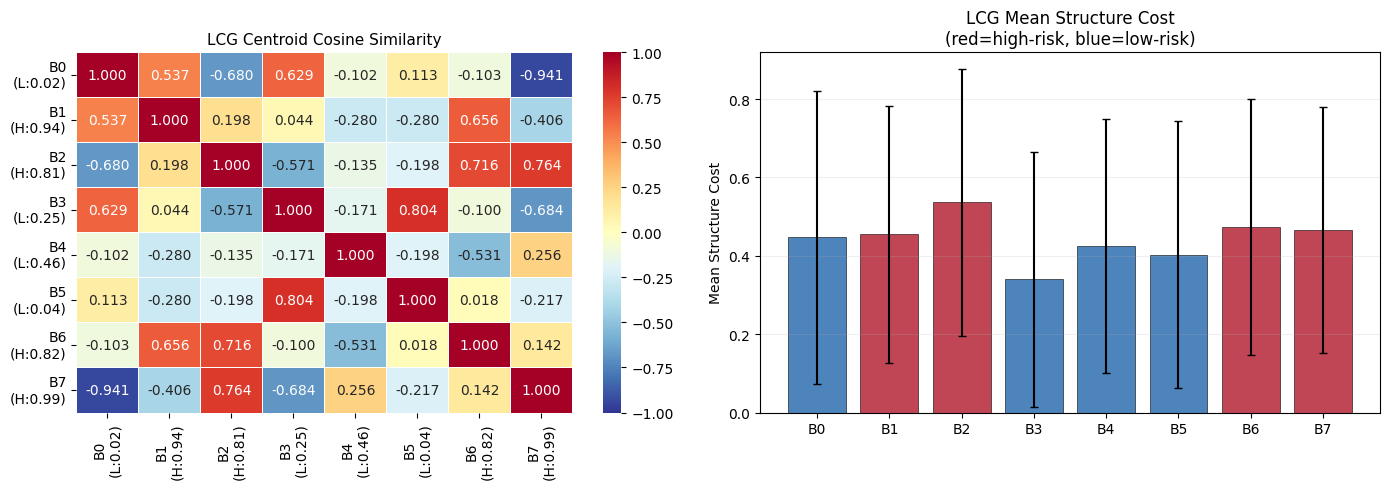


Expert Output Similarity:
  High-High: mean=0.0658
  Low-Low:   mean=-0.2349
  High-Low:  mean=-0.0270


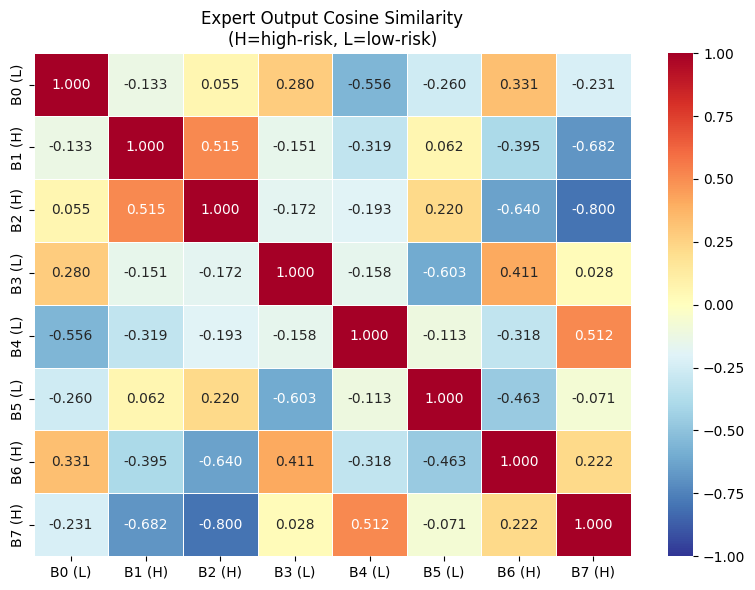

[Medicaldataset] N=1319, TP=628, TN=468, FP=41, FN=182
[Cardiovascular_Disease_Dataset] N=1000, TP=521, TN=384, FP=36, FN=59
[Heart_disease_statlog] N=270, TP=87, TN=137, FP=13, FN=33
[Erbil_Cardiovascular_Health_Dataset] N=287, TP=96, TN=173, FP=12, FN=6
[cardio_SAheart] N=462, TP=68, TN=251, FP=51, FN=92
[heart_failure_clinical_records] N=299, TP=79, TN=176, FP=27, FN=17


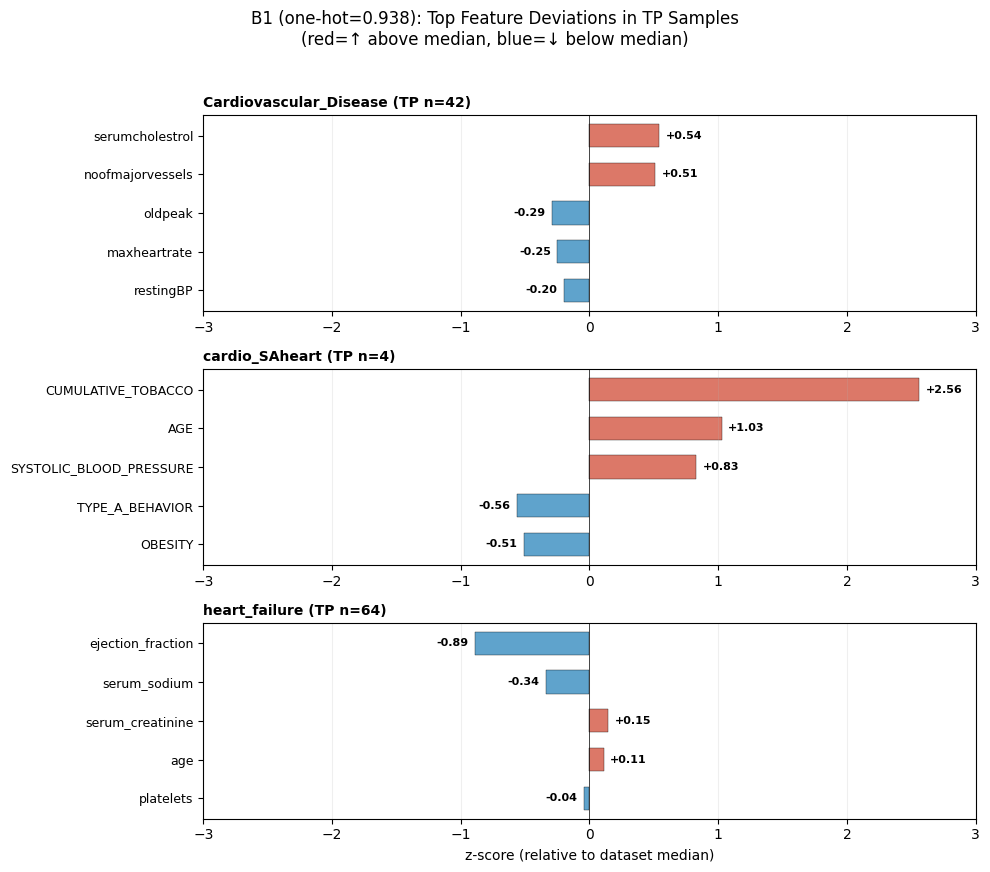

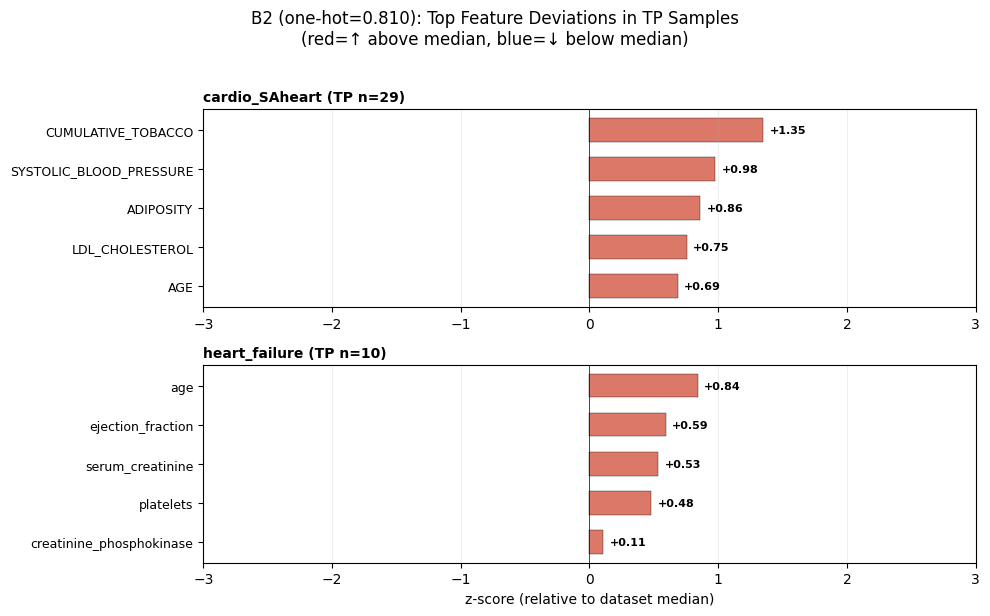

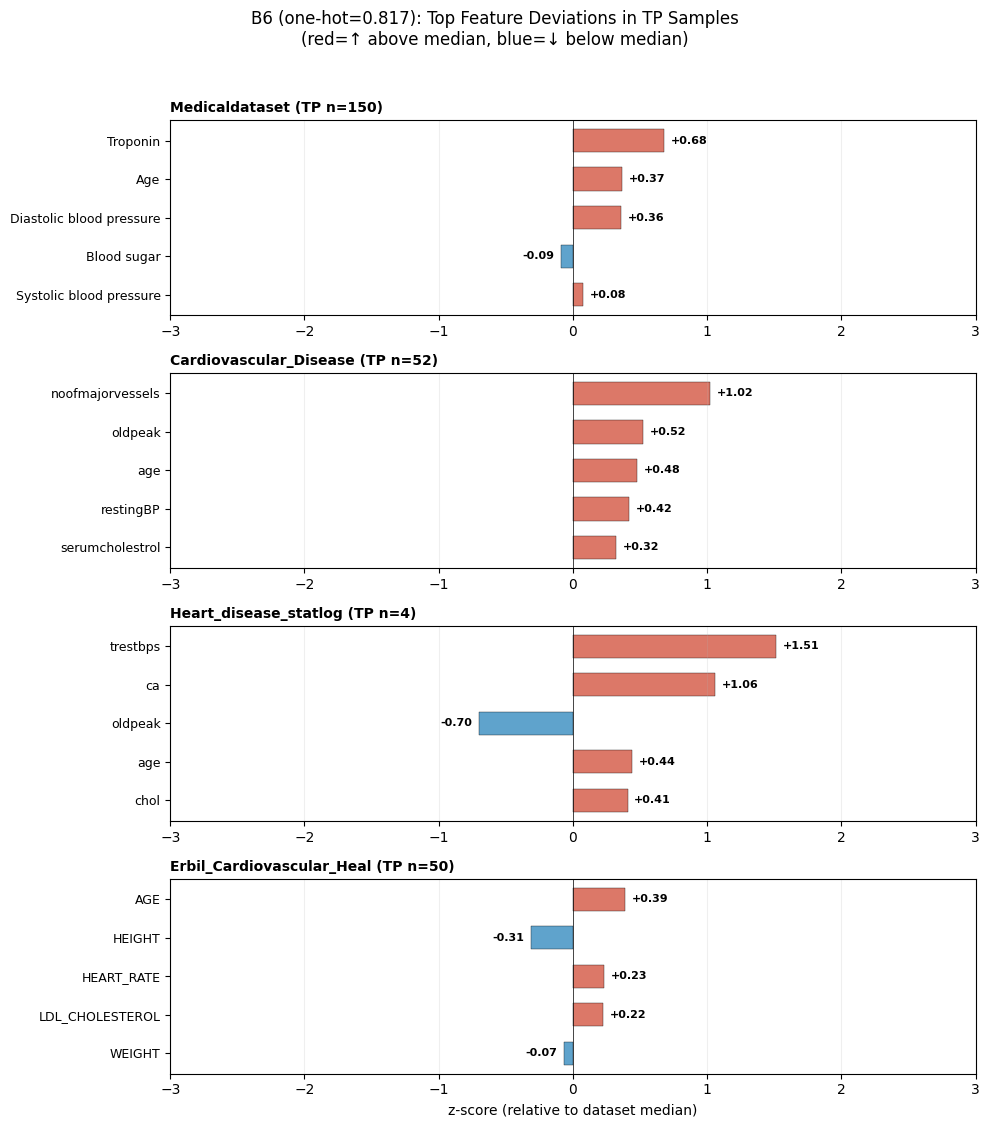

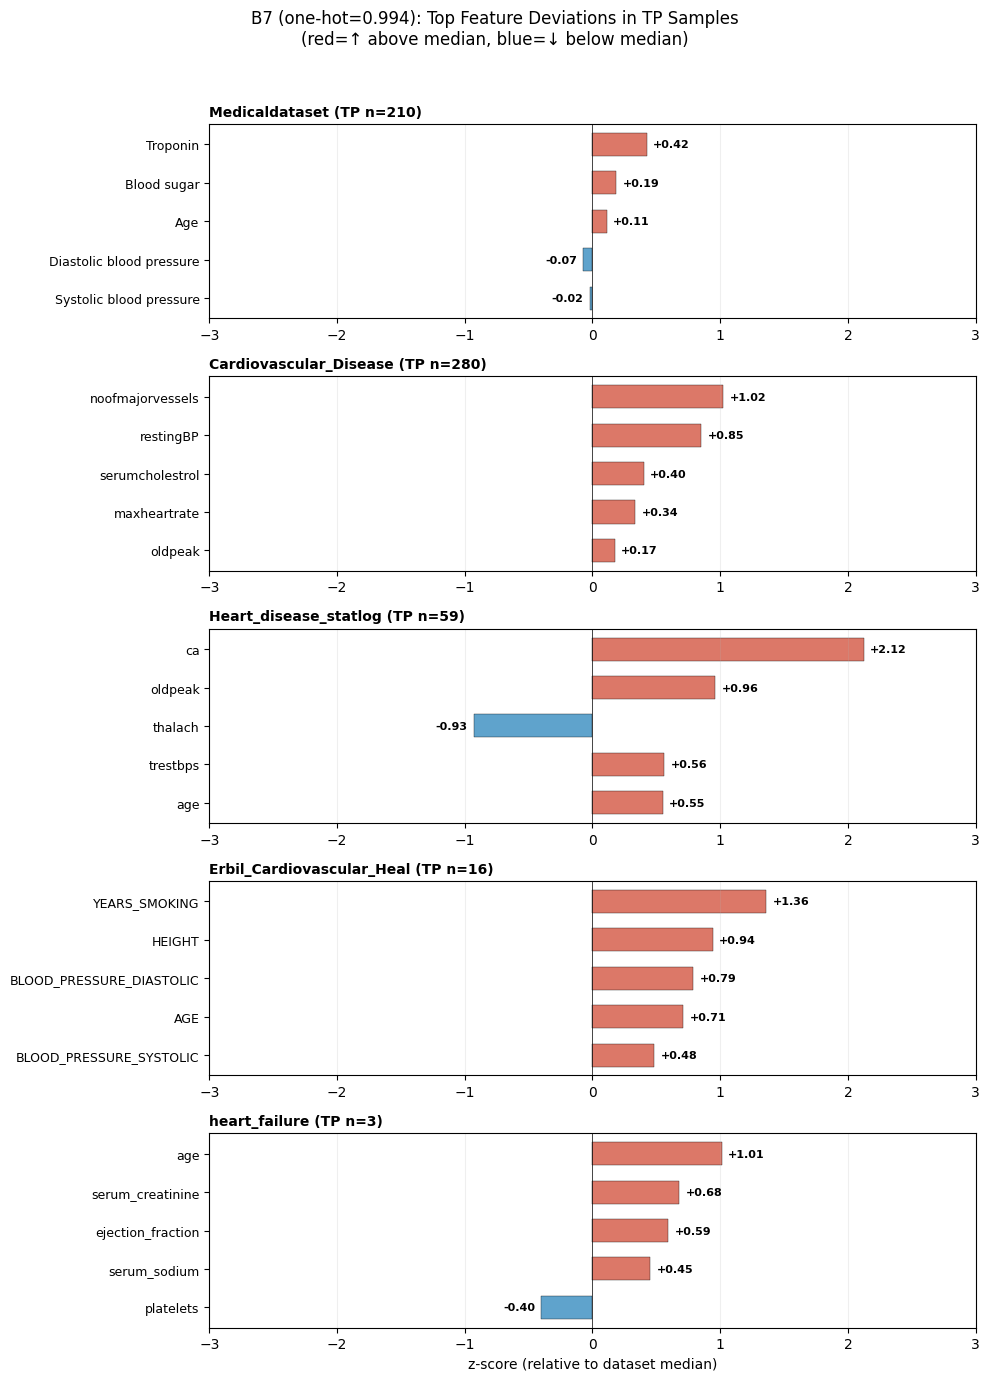

In [46]:
"""
Why are B2, B6, B1, B7 high-risk bases?
독립 실행 가능한 전체 코드

- joint_model_pretrain, loaders, sources, device 이미 로딩된 상태
"""

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn.functional as F

EXCLUDE_FEATURES = {
    'patientid', 'patient_id', 'id', 'ID',
    'time',
}

base_table_path = "/storage/personal/eungyeop/dataset/table/origin_table"

dataset_and_class = {
    "heart": ['target_binary', ['no','yes']],
    "Cardiovascular_Disease_Dataset": ['target_binary', ['no', 'yes']],
    "Medicaldataset": ['target_binary', ['no', 'yes']],
    "Heart_disease_statlog": ['target_binary', ['no','yes']],
    "Erbil_Cardiovascular_Health_Dataset": ['target_binary', ['no','yes']],
    "cardio_SAheart": ['target_binary', ['no','yes']],
    "heart_failure_clinical_records": ['target_binary', ['no','yes']],
}

label_col_map = {
    "Cardiovascular_Disease_Dataset": "target",
    "Medicaldataset": "Result",
    "heart1": "output",
}

def load_original_tabular(dataset_name):
    csv_path = f"{base_table_path}/{dataset_name}.csv"
    df = pd.read_csv(csv_path)
    class_info = dataset_and_class.get(dataset_name)
    if class_info is None:
        for col in ['target_binary', 'target', 'Result', 'output', 'target_multiclass']:
            if col in df.columns:
                y = df[col]; X = df.drop(col, axis=1)
                return X.reset_index(drop=True), y.reset_index(drop=True)
        raise ValueError(f"Cannot find label column for {dataset_name}")
    class_name = class_info[0]
    if dataset_name in label_col_map:
        orig_col = label_col_map[dataset_name]
        if orig_col in df.columns:
            df[class_name] = df[orig_col]; df = df.drop(orig_col, axis=1)
    if class_name in df.columns:
        X = df.drop(class_name, axis=1); y = df[class_name]
    else:
        raise ValueError(f"Label column '{class_name}' not found")
    return X.reset_index(drop=True), y.reset_index(drop=True)


# ============================================================
# 1. One-hot basis risk
# ============================================================

@torch.no_grad()
def compute_onehot_basis_risk(model, device):
    model.eval()
    lcg_feat, lcg_struct = model.latent_graph()
    M = lcg_feat.shape[0]
    lcg_feat_batch = lcg_feat.unsqueeze(0)
    lcg_struct_batch = lcg_struct.unsqueeze(0)
    expert_outputs = model.gnn_experts(lcg_feat_batch, lcg_struct_batch)
    
    onehot_probs = []
    for k in range(M):
        pi_onehot = torch.zeros(1, M, device=device)
        pi_onehot[0, k] = 1.0
        weighted = (pi_onehot.unsqueeze(-1) * expert_outputs).sum(dim=1)
        current_mode = getattr(model, 'mode', 'Full')
        logit = model.ghead2(weighted) if current_mode == 'Few' else model.ghead(weighted)
        onehot_probs.append(torch.sigmoid(logit).item())
    
    print(f"One-Hot Basis Risk:")
    for k in range(M):
        label = "HIGH" if onehot_probs[k] > 0.5 else "LOW"
        print(f"  B{k}: {onehot_probs[k]:.4f} → {label}")
    
    return np.array(onehot_probs)


# ============================================================
# 2. Extract TP/TN with tabular
# ============================================================

@torch.no_grad()
def extract_tp_tn_with_tabular(model, loader, device, dataset_name):
    model.eval()
    X_orig, y_orig = load_original_tabular(dataset_name)
    all_pi, all_y, all_prob, all_sidx = [], [], [], []
    
    for batch in loader:
        batch_t = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
        out = model.predict(batch_t, return_all=True)
        global_pred = out[0] if isinstance(out, tuple) else out
        pi = model.graph_quantizer.last_pi
        prob = torch.sigmoid(global_pred).squeeze(-1)
        all_pi.append(pi.cpu().numpy())
        all_y.append(batch_t['y'].cpu().view(-1).numpy())
        all_prob.append(prob.cpu().view(-1).numpy())
        if 's_idx' in batch_t:
            sidx = batch_t['s_idx']
            if isinstance(sidx, torch.Tensor): all_sidx.append(sidx.cpu().view(-1).numpy())
            else: all_sidx.append(np.array([sidx] * pi.shape[0]))
        else:
            start = sum(len(s) for s in all_sidx)
            all_sidx.append(np.arange(start, start + pi.shape[0]))
    
    pis = np.concatenate(all_pi); ys = np.concatenate(all_y).astype(int)
    probs = np.concatenate(all_prob); sidxs = np.concatenate(all_sidx).astype(int)
    preds = (probs >= 0.5).astype(int)
    valid = sidxs < len(X_orig)
    if not valid.all():
        pis, ys, probs, sidxs, preds = pis[valid], ys[valid], probs[valid], sidxs[valid], preds[valid]
    
    tp = (ys == 1) & (preds == 1); tn = (ys == 0) & (preds == 0)
    fp = (ys == 0) & (preds == 1); fn = (ys == 1) & (preds == 0)
    X_mapped = X_orig.iloc[sidxs].reset_index(drop=True)
    
    print(f"[{dataset_name}] N={len(ys)}, TP={tp.sum()}, TN={tn.sum()}, FP={fp.sum()}, FN={fn.sum()}")
    return {'dataset_name': dataset_name, 'X': X_mapped, 'pis': pis, 'ys': ys,
            'probs': probs, 'preds': preds, 'argmax': pis.argmax(axis=1),
            'tp_mask': tp, 'tn_mask': tn, 'fp_mask': fp, 'fn_mask': fn}


# ============================================================
# 3. LCG 구조 분석
# ============================================================

@torch.no_grad()
def analyze_lcg_structure(model, device, onehot_probs):
    model.eval()
    lcg_feat, lcg_struct = model.latent_graph()
    M, K, D = lcg_feat.shape
    
    centroids = lcg_feat.mean(dim=1)
    centroids_norm = F.normalize(centroids, dim=-1)
    cos_sim = (centroids_norm @ centroids_norm.t()).cpu().numpy()
    struct_np = lcg_struct.cpu().numpy()
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    labels = [f"B{m}\n({'H' if onehot_probs[m]>0.5 else 'L'}:{onehot_probs[m]:.2f})" for m in range(M)]
    sns.heatmap(cos_sim, annot=True, fmt='.3f', cmap='RdYlBu_r',
                xticklabels=labels, yticklabels=labels,
                ax=axes[0], vmin=-1, vmax=1, center=0, linewidths=0.5)
    axes[0].set_title('LCG Centroid Cosine Similarity', fontsize=11)
    
    colors = ['#b2182b' if onehot_probs[m] > 0.5 else '#2166ac' for m in range(M)]
    struct_means = [struct_np[m].mean() for m in range(M)]
    struct_stds = [struct_np[m].std() for m in range(M)]
    axes[1].bar(range(M), struct_means, yerr=struct_stds, color=colors, alpha=0.8,
                edgecolor='black', linewidth=0.5, capsize=3)
    axes[1].set_xticks(range(M))
    axes[1].set_xticklabels([f'B{m}' for m in range(M)])
    axes[1].set_ylabel('Mean Structure Cost')
    axes[1].set_title('LCG Mean Structure Cost\n(red=high-risk, blue=low-risk)')
    axes[1].grid(True, alpha=0.2, axis='y')
    plt.tight_layout(); plt.show()


# ============================================================
# 4. Expert Output 분석
# ============================================================

@torch.no_grad()
def analyze_expert_outputs(model, device, onehot_probs):
    model.eval()
    lcg_feat, lcg_struct = model.latent_graph()
    M = lcg_feat.shape[0]
    expert_outputs = model.gnn_experts(lcg_feat.unsqueeze(0), lcg_struct.unsqueeze(0)).squeeze(0)
    
    expert_norm = F.normalize(expert_outputs, dim=-1)
    expert_cos = (expert_norm @ expert_norm.t()).cpu().numpy()
    
    high_idx = [m for m in range(M) if onehot_probs[m] > 0.5]
    low_idx = [m for m in range(M) if onehot_probs[m] <= 0.5]
    
    high_sims = [expert_cos[i,j] for i in range(len(high_idx)) for j in range(i+1,len(high_idx))]
    low_sims = [expert_cos[low_idx[i],low_idx[j]] for i in range(len(low_idx)) for j in range(i+1,len(low_idx))]
    cross_sims = [expert_cos[h,l] for h in high_idx for l in low_idx]
    
    print(f"\nExpert Output Similarity:")
    print(f"  High-High: mean={np.mean(high_sims):.4f}")
    print(f"  Low-Low:   mean={np.mean(low_sims):.4f}")
    print(f"  High-Low:  mean={np.mean(cross_sims):.4f}")
    
    labels = [f"B{m} ({'H' if onehot_probs[m]>0.5 else 'L'})" for m in range(M)]
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    sns.heatmap(expert_cos, annot=True, fmt='.3f', cmap='RdYlBu_r',
                xticklabels=labels, yticklabels=labels,
                ax=ax, vmin=-1, vmax=1, center=0, linewidths=0.5)
    ax.set_title('Expert Output Cosine Similarity\n(H=high-risk, L=low-risk)')
    plt.tight_layout(); plt.show()


# ============================================================
# 5. 고위험 basis feature profile 수집
# ============================================================

def collect_high_risk_profiles(model, loaders, sources, device, onehot_probs):
    M = len(onehot_probs)
    high_risk_bases = [k for k in range(M) if onehot_probs[k] > 0.5]
    
    all_source_profiles = {}
    for src_name in sources:
        result = extract_tp_tn_with_tabular(model, loaders[src_name], device, src_name)
        X = result['X']; argmax = result['argmax']; tp_mask = result['tp_mask']
        num_cols = [c for c in X.select_dtypes(include=[np.number]).columns
                    if c.lower() not in {f.lower() for f in EXCLUDE_FEATURES}]
        
        basis_profiles = {}
        for k in high_risk_bases:
            k_tp = (argmax == k) & tp_mask
            n = k_tp.sum()
            if n >= 3:
                medians = {}
                for col in num_cols:
                    vals = pd.to_numeric(X.loc[k_tp, col], errors='coerce').dropna().values
                    if len(vals) >= 3: medians[col] = np.median(vals)
                basis_profiles[k] = {'medians': medians, 'n': int(n)}
        
        overall_med = {}; overall_std = {}
        for col in num_cols:
            vals = pd.to_numeric(X[col], errors='coerce').dropna().values
            if len(vals) > 0:
                overall_med[col] = np.median(vals)
                overall_std[col] = np.std(vals) if np.std(vals) > 0 else 1.0
        
        all_source_profiles[src_name] = {
            'basis_profiles': basis_profiles,
            'overall_medians': overall_med,
            'overall_stds': overall_std,
        }
    
    return all_source_profiles


# ============================================================
# 6. 고위험 basis feature profile 시각화 (horizontal bar)
# ============================================================

def plot_high_risk_profiles(all_source_profiles, sources, onehot_probs, top_k=5):
    M = len(onehot_probs)
    high_risk_bases = [k for k in range(M) if onehot_probs[k] > 0.5]
    
    for basis_k in high_risk_bases:
        valid_sources = [s for s in sources if basis_k in all_source_profiles[s]['basis_profiles']]
        if len(valid_sources) == 0:
            continue
        
        n_src = len(valid_sources)
        fig, axes = plt.subplots(n_src, 1, figsize=(10, 2.5 * n_src + 1))
        if n_src == 1: axes = [axes]
        
        for ax_idx, src_name in enumerate(valid_sources):
            ax = axes[ax_idx]
            sp = all_source_profiles[src_name]
            bp = sp['basis_profiles'][basis_k]
            medians = bp['medians']
            overall_med = sp['overall_medians']
            overall_std = sp['overall_stds']
            
            z_scores = {}
            for col in medians:
                if col in overall_med and col in overall_std:
                    z_scores[col] = (medians[col] - overall_med[col]) / overall_std[col]
            
            sorted_feats = sorted(z_scores.items(), key=lambda x: abs(x[1]), reverse=True)[:top_k]
            sorted_feats = sorted_feats[::-1]
            
            feat_names = [f[0][:25] for f in sorted_feats]
            z_vals = [f[1] for f in sorted_feats]
            colors = ['#d6604d' if z > 0 else '#4393c3' for z in z_vals]
            
            bars = ax.barh(range(len(feat_names)), z_vals, color=colors, alpha=0.85,
                          edgecolor='black', linewidth=0.3, height=0.6)
            ax.set_yticks(range(len(feat_names)))
            ax.set_yticklabels(feat_names, fontsize=9)
            ax.axvline(0, color='black', linewidth=0.5)
            
            for bar, z in zip(bars, z_vals):
                x_pos = z + 0.05 if z >= 0 else z - 0.05
                ha = 'left' if z >= 0 else 'right'
                ax.text(x_pos, bar.get_y() + bar.get_height()/2,
                        f'{z:+.2f}', ha=ha, va='center', fontsize=8, fontweight='bold')
            
            short_name = src_name.replace('_Dataset', '').replace('_clinical_records', '')[:25]
            ax.set_title(f"{short_name} (TP n={bp['n']})", fontsize=10, fontweight='bold', loc='left')
            ax.set_xlim(-3, 3)
            ax.grid(True, alpha=0.2, axis='x')
        
        axes[-1].set_xlabel('z-score (relative to dataset median)', fontsize=10)
        fig.suptitle(
            f"B{basis_k} (one-hot={onehot_probs[basis_k]:.3f}): "
            f"Top Feature Deviations in TP Samples\n"
            f"(red=↑ above median, blue=↓ below median)",
            fontsize=12, y=1.02
        )
        plt.tight_layout(); plt.show()


# ============================================================
# 7. 전체 실행
# ============================================================

def run_all(model, loaders, sources, device):
    onehot_probs = compute_onehot_basis_risk(model, device)
    analyze_lcg_structure(model, device, onehot_probs)
    analyze_expert_outputs(model, device, onehot_probs)
    source_profiles = collect_high_risk_profiles(model, loaders, sources, device, onehot_probs)
    plot_high_risk_profiles(source_profiles, sources, onehot_probs)
    return onehot_probs, source_profiles

# 호출
onehot_probs, source_profiles = run_all(joint_model_pretrain, loaders, sources, device)

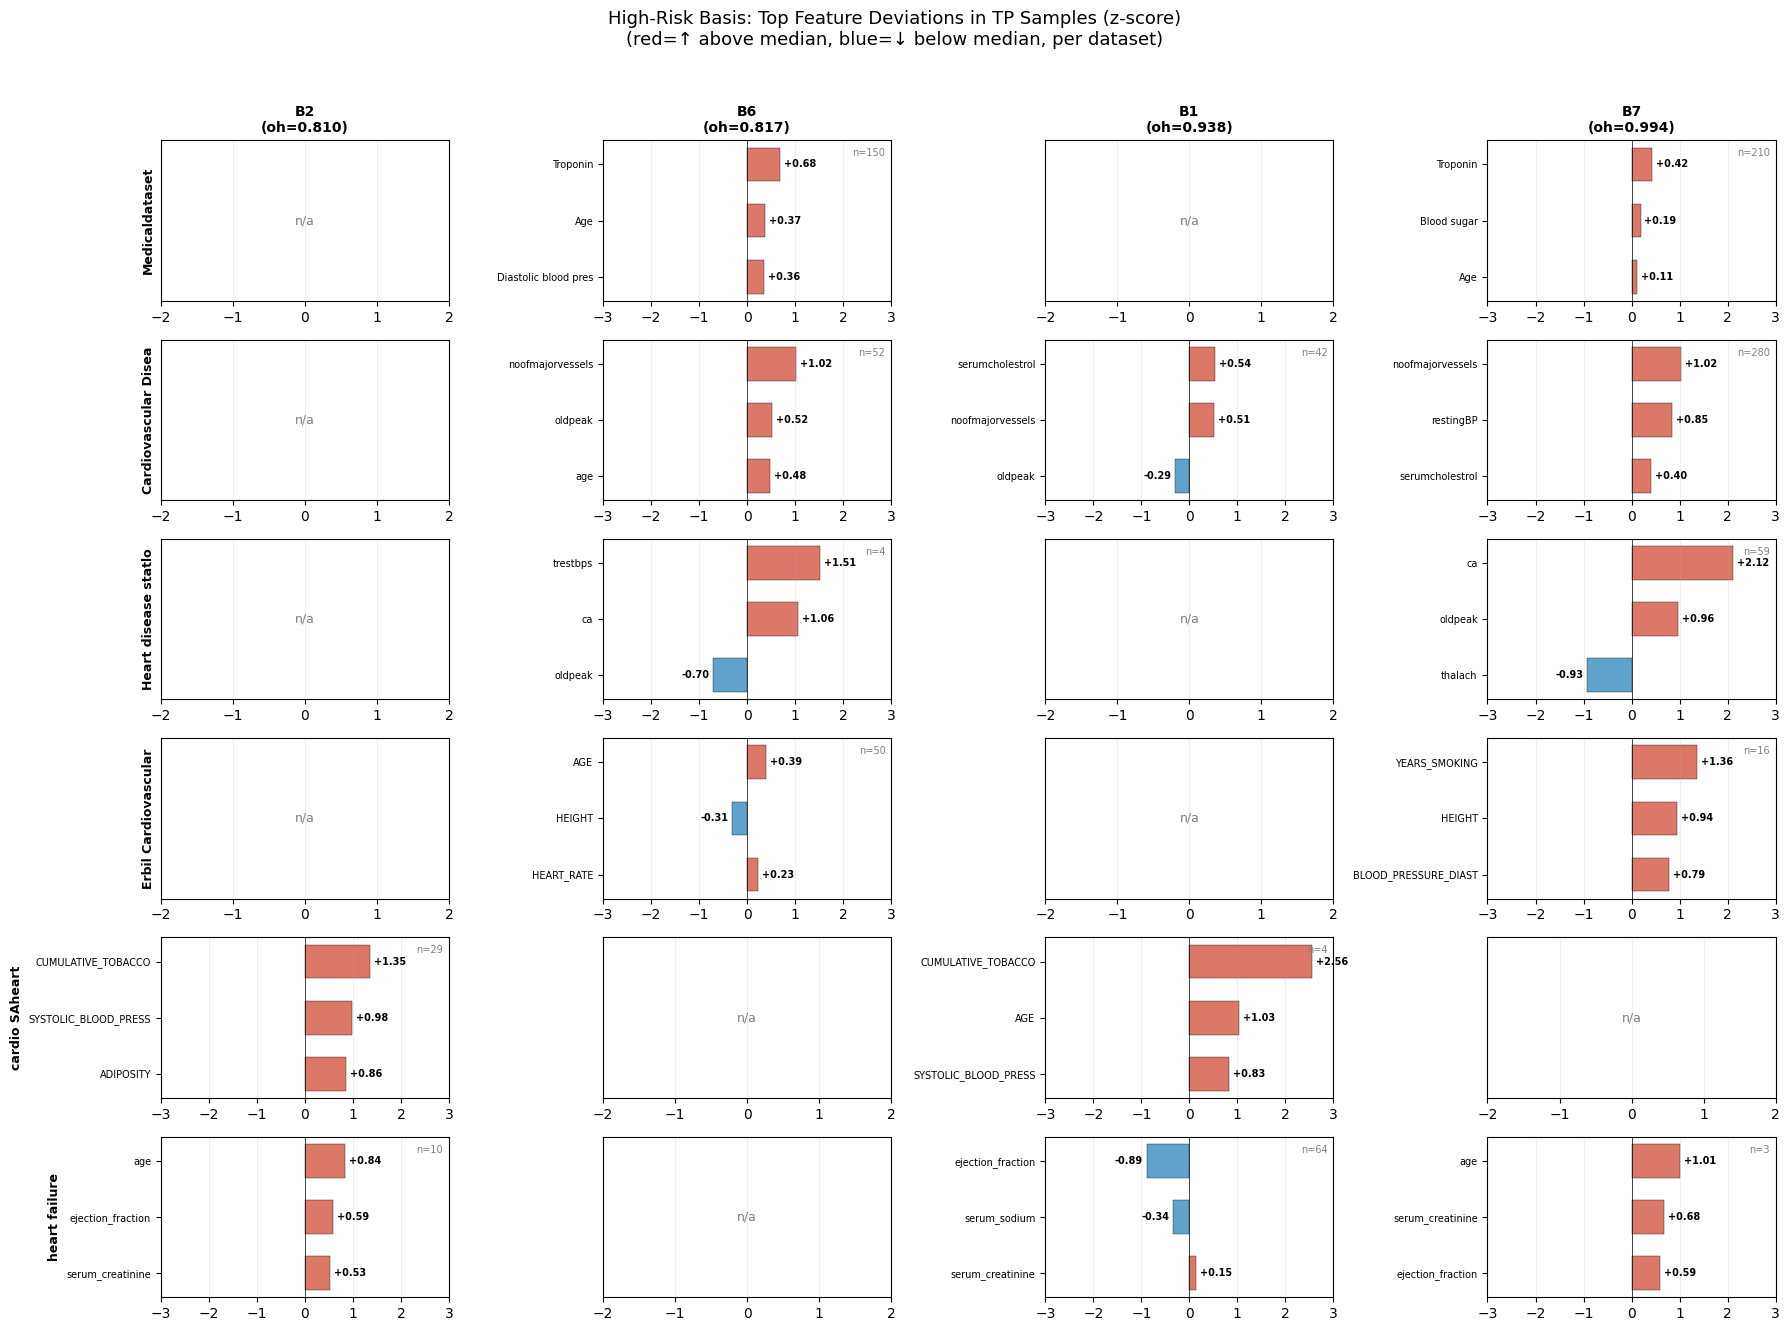

In [47]:
"""
고위험 basis feature profile - compact grid 시각화
rows = sources, columns = high-risk bases
각 셀에 top-3 feature z-score horizontal bar
"""

import numpy as np
import matplotlib.pyplot as plt


def plot_high_risk_grid(all_source_profiles, sources, onehot_probs, top_k=3):
    """
    하나의 figure에 모든 고위험 basis × source를 grid로 표시
    """
    M = len(onehot_probs)
    high_risk_bases = sorted([k for k in range(M) if onehot_probs[k] > 0.5],
                              key=lambda k: onehot_probs[k])
    
    short_names = [s.replace('_Dataset', '').replace('_Health_Dataset', '')
                     .replace('_clinical_records', '').replace('_', ' ')[:20]
                   for s in sources]
    
    n_bases = len(high_risk_bases)
    n_src = len(sources)
    
    fig, axes = plt.subplots(n_src, n_bases, figsize=(4.5 * n_bases, 2.0 * n_src + 1))
    if n_src == 1: axes = axes[np.newaxis, :]
    if n_bases == 1: axes = axes[:, np.newaxis]
    
    for col, basis_k in enumerate(high_risk_bases):
        for row, src_name in enumerate(sources):
            ax = axes[row, col]
            sp = all_source_profiles[src_name]
            
            if basis_k not in sp['basis_profiles']:
                ax.text(0.5, 0.5, 'n/a', ha='center', va='center', fontsize=9, color='gray',
                        transform=ax.transAxes)
                ax.set_xlim(-2, 2)
                ax.set_yticks([])
                if row == 0:
                    ax.set_title(f"B{basis_k}\n(oh={onehot_probs[basis_k]:.3f})", fontsize=10, fontweight='bold')
                if col == 0:
                    ax.set_ylabel(short_names[row], fontsize=9, fontweight='bold')
                ax.grid(True, alpha=0.2, axis='x')
                continue
            
            bp = sp['basis_profiles'][basis_k]
            medians = bp['medians']
            overall_med = sp['overall_medians']
            overall_std = sp['overall_stds']
            
            z_scores = {}
            for c in medians:
                if c in overall_med and c in overall_std:
                    z_scores[c] = (medians[c] - overall_med[c]) / overall_std[c]
            
            sorted_feats = sorted(z_scores.items(), key=lambda x: abs(x[1]), reverse=True)[:top_k]
            sorted_feats = sorted_feats[::-1]
            
            feat_names = [f[0][:20] for f in sorted_feats]
            z_vals = [f[1] for f in sorted_feats]
            colors = ['#d6604d' if z > 0 else '#4393c3' for z in z_vals]
            
            ax.barh(range(len(feat_names)), z_vals, color=colors, alpha=0.85,
                    edgecolor='black', linewidth=0.3, height=0.6)
            ax.set_yticks(range(len(feat_names)))
            ax.set_yticklabels(feat_names, fontsize=7)
            ax.axvline(0, color='black', linewidth=0.5)
            ax.set_xlim(-3, 3)
            ax.grid(True, alpha=0.2, axis='x')
            
            for i, z in enumerate(z_vals):
                x_pos = z + 0.08 if z >= 0 else z - 0.08
                ha = 'left' if z >= 0 else 'right'
                ax.text(x_pos, i, f'{z:+.2f}', ha=ha, va='center', fontsize=7, fontweight='bold')
            
            # TP n 표시
            ax.text(0.98, 0.95, f'n={bp["n"]}', ha='right', va='top', fontsize=7,
                    transform=ax.transAxes, color='gray')
            
            if row == 0:
                ax.set_title(f"B{basis_k}\n(oh={onehot_probs[basis_k]:.3f})", fontsize=10, fontweight='bold')
            if col == 0:
                ax.set_ylabel(short_names[row], fontsize=9, fontweight='bold')
    
    fig.suptitle(
        "High-Risk Basis: Top Feature Deviations in TP Samples (z-score)\n"
        "(red=↑ above median, blue=↓ below median, per dataset)",
        fontsize=13, y=1.02
    )
    plt.tight_layout()
    plt.show()


# 호출 (source_profiles, sources, onehot_probs가 이미 있는 상태에서)
plot_high_risk_grid(source_profiles, sources, onehot_probs)

## Latent Graph Affinity

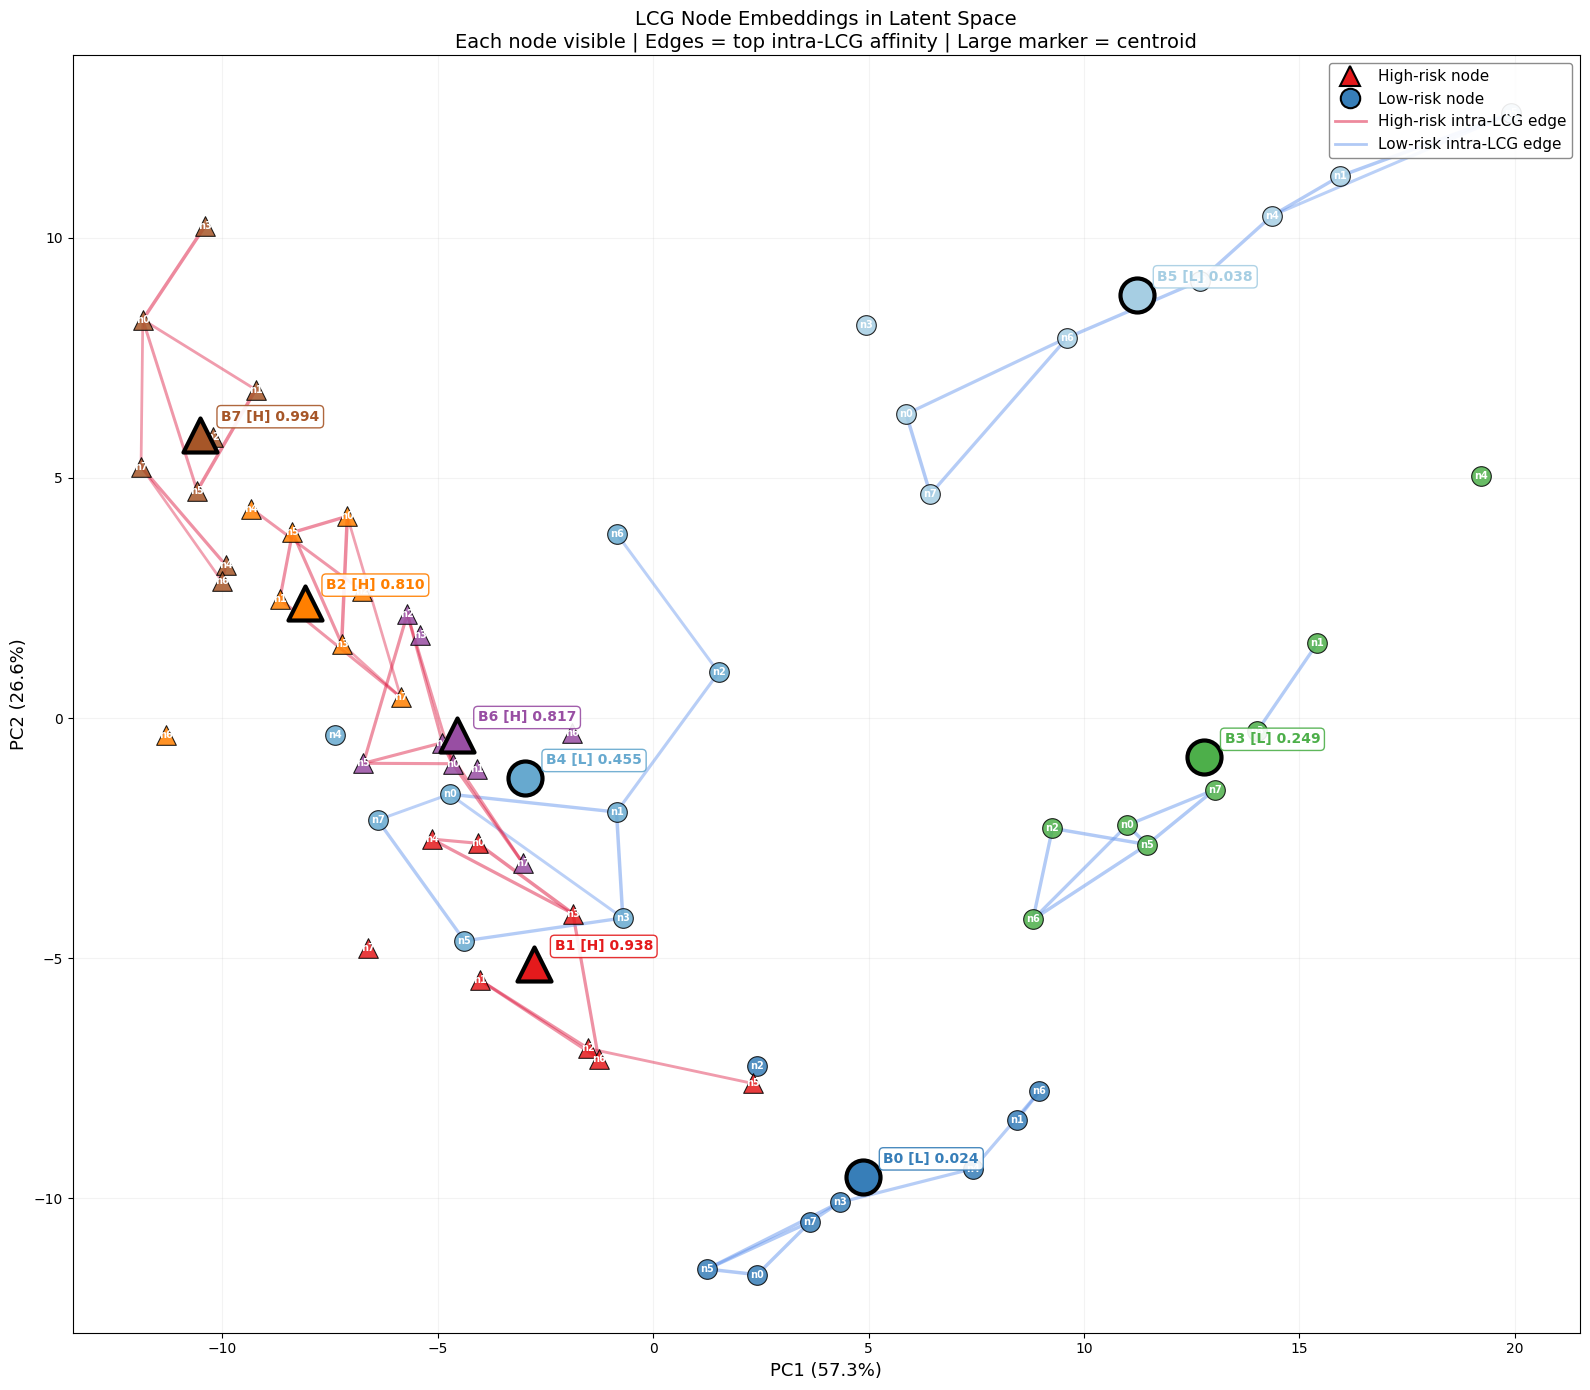

In [72]:
"""
LCG Latent Space 시각화 - 모든 노드를 제대로 보이게
"""

import torch
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.decomposition import PCA
import torch.nn.functional as F


@torch.no_grad()
def plot_lcg_latent_space(model, device, onehot_probs):
    model.eval()
    lcg_feat, lcg_struct = model.latent_graph()
    M, K, D = lcg_feat.shape
    
    affinity = (1.0 - lcg_struct).cpu().numpy()
    nodes_all = lcg_feat.reshape(M * K, D).cpu().numpy()
    basis_ids = np.repeat(np.arange(M), K)
    node_ids = np.tile(np.arange(K), M)
    
    pca = PCA(n_components=2)
    xy = pca.fit_transform(nodes_all)
    
    # 색상
    high_colors = {1: '#e41a1c', 2: '#ff7f00', 6: '#984ea3', 7: '#a65628'}
    low_colors = {0: '#377eb8', 3: '#4daf4a', 4: '#67a9cf', 5: '#a6cee3'}
    all_colors = {}
    all_colors.update(high_colors)
    all_colors.update(low_colors)
    
    fig, ax = plt.subplots(1, 1, figsize=(16, 14))
    
    G = nx.Graph()
    pos_dict = {}
    node_color_list = []
    node_label_dict = {}
    
    # 노드 추가
    for idx in range(M * K):
        m = basis_ids[idx]
        n = node_ids[idx]
        gid = f'B{m}_n{n}'
        G.add_node(gid)
        pos_dict[gid] = xy[idx]
        node_color_list.append(all_colors.get(m, 'gray'))
        node_label_dict[gid] = f'n{n}'
    
    # 같은 LCG 내 노드끼리 top edge 연결
    for m in range(M):
        aff = affinity[m]
        edges_m = []
        for i in range(K):
            for j in range(i+1, K):
                edges_m.append((i, j, aff[i, j]))
        edges_m.sort(key=lambda x: x[2], reverse=True)
        top_edges = edges_m[:8]
        
        for i, j, w in top_edges:
            gid_i = f'B{m}_n{i}'
            gid_j = f'B{m}_n{j}'
            G.add_edge(gid_i, gid_j, weight=w)
    
    # 배경 그리드
    ax.grid(True, alpha=0.15)
    ax.set_axisbelow(True)
    
    # 같은 LCG 내 edge 그리기
    for m in range(M):
        is_high = onehot_probs[m] > 0.5
        edge_color = 'crimson' if is_high else 'cornflowerblue'
        
        m_edges = [(u, v) for u, v, d in G.edges(data=True) 
                   if u.startswith(f'B{m}_') and v.startswith(f'B{m}_')]
        
        if m_edges:
            weights = [G[u][v]['weight'] for u, v in m_edges]
            max_w = max(weights) if weights else 1
            
            for (u, v), w in zip(m_edges, weights):
                norm_w = w / max(max_w, 0.001)
                ax.plot([pos_dict[u][0], pos_dict[v][0]],
                       [pos_dict[u][1], pos_dict[v][1]],
                       color=edge_color, alpha=0.15 + 0.35 * norm_w,
                       linewidth=0.5 + 2.0 * norm_w, zorder=1)
    
    # 노드 그리기 (전부 동일 크기로 크게)
    for idx in range(M * K):
        m = basis_ids[idx]
        n = node_ids[idx]
        gid = f'B{m}_n{n}'
        color = all_colors.get(m, 'gray')
        is_high = onehot_probs[m] > 0.5
        marker = '^' if is_high else 'o'
        
        ax.scatter(xy[idx, 0], xy[idx, 1], c=color, marker=marker,
                  s=200, alpha=0.85, edgecolors='black', linewidth=0.8, zorder=5)
    
    # 노드 라벨
    for idx in range(M * K):
        m = basis_ids[idx]
        n = node_ids[idx]
        ax.annotate(f'n{n}', (xy[idx, 0], xy[idx, 1]),
                   fontsize=7, ha='center', va='center', fontweight='bold',
                   color='white', zorder=6)
    
    # Centroid 표시 (검은 테두리 큰 마커)
    centroids_xy = np.array([xy[basis_ids == m].mean(axis=0) for m in range(M)])
    for m in range(M):
        color = all_colors.get(m, 'gray')
        is_high = onehot_probs[m] > 0.5
        marker = '^' if is_high else 'o'
        risk = "H" if is_high else "L"
        
        ax.scatter(centroids_xy[m, 0], centroids_xy[m, 1], c=color, marker=marker,
                  s=600, alpha=1.0, edgecolors='black', linewidth=3, zorder=8)
        
        ax.annotate(f'B{m} [{risk}] {onehot_probs[m]:.3f}',
                   (centroids_xy[m, 0], centroids_xy[m, 1]),
                   textcoords='offset points', xytext=(15, 10),
                   fontsize=10, fontweight='bold', color=color,
                   bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=color, alpha=0.9),
                   zorder=9)
    
    # Legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='^', color='w', markerfacecolor='#e41a1c',
               markersize=14, markeredgecolor='black', markeredgewidth=1.5, label='High-risk node'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#377eb8',
               markersize=14, markeredgecolor='black', markeredgewidth=1.5, label='Low-risk node'),
        Line2D([0], [0], color='crimson', linewidth=2, alpha=0.5, label='High-risk intra-LCG edge'),
        Line2D([0], [0], color='cornflowerblue', linewidth=2, alpha=0.5, label='Low-risk intra-LCG edge'),
    ]
    ax.legend(handles=legend_elements, fontsize=11, loc='upper right',
             framealpha=0.9, edgecolor='gray')
    
    ev = pca.explained_variance_ratio_
    ax.set_xlabel(f'PC1 ({ev[0]*100:.1f}%)', fontsize=13)
    ax.set_ylabel(f'PC2 ({ev[1]*100:.1f}%)', fontsize=13)
    ax.set_title('LCG Node Embeddings in Latent Space\n'
                 'Each node visible | Edges = top intra-LCG affinity | Large marker = centroid',
                 fontsize=14)
    
    plt.tight_layout()
    plt.show()


# 호출
plot_lcg_latent_space(joint_model_pretrain, device, onehot_probs)

## Coordinate Clustering

In [48]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

def compute_tsne_coords(pis, seed=42):
    N = pis.shape[0]
    perp = max(5, min(40, (N - 1) // 3))
    xy = TSNE(
        n_components=2, perplexity=perp,
        learning_rate=200, init="pca", random_state=seed
    ).fit_transform(pis)
    return xy

# =========================================================
# 1) Source 하나에서 pi, y, affinity(FGW용), raw_attn(시각화용), names 수집
# =========================================================
@torch.no_grad()
def collect_pi_and_affinity_for_one_source(model, loader, device, extract_feature_names_fn):
    model.eval()
    model.args.use_lcg = True

    all_pis = []
    all_ys = []
    all_affs = []       # FGW용: q90 정규화된 structure
    all_affs_raw = []   # 시각화용: raw attention [0,1]
    all_names = []

    for batch in loader:
        batch_t = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}

        # --- pi 수집 ---
        _ = model.predict(batch_t, return_all=True)
        pi = model.graph_quantizer.last_pi  # [B, M]
        if pi is None:
            raise RuntimeError("last_pi is None. use_lcg=True?")

        # --- attention 수집 (collect_all_samples_from_source와 동일) ---
        name_embeddings, value_embeddings = [], []
        if all(k in batch_t for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
            name_embeddings.append(batch_t['cat_name_embeddings'])
            value_embeddings.append(batch_t['cat_value_embeddings'])
        if all(k in batch_t for k in ['num_prompt_embeddings', 'num_desc_embeddings']):
            name_embeddings.append(batch_t['num_name_embeddings'])
            value_embeddings.append(batch_t['num_prompt_embeddings'])

        name = torch.cat(name_embeddings, dim=1)
        value = torch.cat(value_embeddings, dim=1)
        B = value.size(0)

        x_basis = torch.cat([model.basis_cls.expand(B, 1, model.input_dim), value], dim=1)
        last_att = None
        for l in range(model.num_basis_layers):
            norm_x = model.basis_layer_norms[l](x_basis)
            basis_outputs, att = model.basis_layers[l](name, norm_x)
            last_att = att
            x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)

        last_att = last_att[:, 0, :, :]  # [B, T, T]

        # --- feature names ---
        var_names = extract_feature_names_fn(batch_t)

        for b in range(B):
            raw_attn = last_att[b, 1:, 1:].detach().cpu()  # [N, N]

            # FGW용: 모델과 동일한 q90 정규화
            log_attn = -torch.log(raw_attn.clamp_min(1e-8))
            q90 = torch.quantile(log_attn.flatten(), 0.9).clamp_min(1e-8)
            P_basis = (log_attn / q90).clamp_max(1.0)

            all_pis.append(pi[b].detach().cpu().numpy())
            all_ys.append(int(batch_t['y'][b].item()))
            all_affs.append(P_basis.numpy())          # FGW용
            all_affs_raw.append(raw_attn.numpy())      # 시각화용
            all_names.append(var_names)

    pis = np.stack(all_pis, axis=0)     # [N_total, M]
    ys = np.array(all_ys)               # [N_total]
    return pis, ys, all_affs, all_affs_raw, all_names

from sklearn.metrics import silhouette_score

# =========================================================
# 3) KMeans + 실루엣 기반 최적 K 탐색 + 대표 샘플 뽑기
# =========================================================
def find_best_K_by_silhouette(X, K_range=range(2, 11), seed=42):
    """pi space에서 실루엣 기반 최적 K 탐색"""
    if len(X) < 4:
        return 2, []
    
    sil_scores = []
    valid_ks = []
    for k in K_range:
        if k >= len(X):
            break
        km = KMeans(n_clusters=k, random_state=seed, n_init=20).fit(X)
        sil = silhouette_score(X, km.labels_, metric='cosine')
        sil_scores.append(sil)
        valid_ks.append(k)
    
    best_k = valid_ks[np.argmax(sil_scores)]
    return best_k, list(zip(valid_ks, sil_scores))


def fit_kmeans_and_pick_reps(pis, ys, label, K="auto", K_range=range(2, 11), seed=42):
    """
    K="auto": 실루엣 기반으로 최적 K 자동 탐색
    K=int:    고정 K 사용
    """
    idx = np.where(ys == label)[0]
    if len(idx) == 0:
        return {"idx": idx, "X": None, "cid": None, "km": None,
                "reps_global": [], "k_eff": 0,
                "sil_scores": [], "best_sil": None}

    X = pis[idx]

    # --- 실루엣 기반 K 선택 ---
    if K == "auto":
        best_k, sil_scores = find_best_K_by_silhouette(X, K_range=K_range, seed=seed)
        k_eff = min(best_k, len(idx))
        print(f"  [label={label}] Silhouette sweep: best K={best_k}")
        for k, s in sil_scores:
            marker = " <<<" if k == best_k else ""
            print(f"    K={k:2d} | sil={s:.4f}{marker}")
    else:
        k_eff = min(K, len(idx))
        # 실루엣은 참고용으로 계산
        _, sil_scores = find_best_K_by_silhouette(X, K_range=K_range, seed=seed)
        best_k = k_eff

    km = KMeans(n_clusters=k_eff, random_state=seed, n_init=20)
    cid = km.fit_predict(X)
    C = km.cluster_centers_

    # 현재 k_eff에서의 실루엣
    best_sil = silhouette_score(X, cid, metric='cosine') if k_eff >= 2 else None

    # 대표 샘플
    reps_global = []
    for c in range(k_eff):
        mask = (cid == c)
        Xi = X[mask]
        d = np.linalg.norm(Xi - C[c][None, :], axis=1)
        within = int(np.argmin(d))
        local_candidates = np.where(mask)[0]
        local = int(local_candidates[within])
        reps_global.append(int(idx[local]))

    return {"idx": idx, "X": X, "cid": cid, "km": km,
            "reps_global": reps_global, "k_eff": k_eff,
            "sil_scores": sil_scores, "best_sil": best_sil}


# =========================================================
# 4) 3xK 시각화 — 실루엣 sweep 플롯 추가 (Row 0)
# =========================================================
def plot_3xK_per_label(
    pis, ys, affs_raw, names,
    label, K="auto", K_range=range(2, 11), seed=42,
    title_prefix="[source]",
    bg_alpha=0.12, fg_alpha=0.90,
    bg_size=10, fg_size=14
):
    M = pis.shape[1]
    res = fit_kmeans_and_pick_reps(pis, ys, label=label, K=K, K_range=K_range, seed=seed)
    k_eff = res["k_eff"]
    if k_eff == 0:
        print(f"[warn] label={label} has no samples.")
        return

    idx_lab = res["idx"]
    X_lab = res["X"]
    cid = res["cid"]
    C = res["km"].cluster_centers_
    reps_g = res["reps_global"]
    sil_scores = res["sil_scores"]
    best_sil = res["best_sil"]

    # t-SNE
    xy_lab = compute_tsne_coords(X_lab, seed=seed)
    x_min, x_max = xy_lab[:, 0].min(), xy_lab[:, 0].max()
    y_min, y_max = xy_lab[:, 1].min(), xy_lab[:, 1].max()
    mx = 0.03 * (x_max - x_min + 1e-9)
    my = 0.03 * (y_max - y_min + 1e-9)
    x_min, x_max = x_min - mx, x_max + mx
    y_min, y_max = y_min - my, y_max + my

    pi_ymin = max(0, float(C[:k_eff].min()) - 0.02)
    pi_ymax = float(C[:k_eff].max()) + 0.02

    mats = [affs_raw[g] for g in reps_g]
    vmin = min(m.min() for m in mats)
    vmax = max(m.max() for m in mats)

    # --- Layout: 4 rows ---
    # Row 0: silhouette sweep (한 칸으로 합침)
    # Row 1: t-SNE cluster highlight
    # Row 2: centroid pi
    # Row 3: raw attention
    fig = plt.figure(figsize=(4.2 * k_eff, 16))
    gs = fig.add_gridspec(4, k_eff, height_ratios=[0.6, 1, 0.8, 1])

    # --- Row 0: Silhouette sweep (전체 span) ---
    ax_sil = fig.add_subplot(gs[0, :])
    if sil_scores:
        ks_plot = [s[0] for s in sil_scores]
        sils_plot = [s[1] for s in sil_scores]
        ax_sil.plot(ks_plot, sils_plot, 'o-', color='steelblue')
        ax_sil.axvline(x=k_eff, color='red', linestyle='--',
                       label=f'Selected K={k_eff} (sil={best_sil:.4f})')
        ax_sil.set_xlabel('K (clusters)')
        ax_sil.set_ylabel('Silhouette Score')
        ax_sil.set_title(f'label={label} | Silhouette Sweep in Pi Space | N={len(idx_lab)}')
        ax_sil.legend()
        ax_sil.grid(True, alpha=0.3)

    for c in range(k_eff):
        # --- Row 1: t-SNE ---
        ax = fig.add_subplot(gs[1, c])
        ax.scatter(xy_lab[:, 0], xy_lab[:, 1],
                   s=bg_size, alpha=bg_alpha, color="gray")
        m = (cid == c)
        if m.sum() > 0:
            ax.scatter(xy_lab[m, 0], xy_lab[m, 1],
                       s=fg_size, alpha=fg_alpha, color=f"C{c % 10}")
            cx, cy = xy_lab[m, 0].mean(), xy_lab[m, 1].mean()
            ax.scatter([cx], [cy], s=160, marker="*",
                       edgecolors="black", linewidths=1.2, color=f"C{c % 10}")

        rep_local = int(np.where(idx_lab == reps_g[c])[0][0])
        ax.scatter([xy_lab[rep_local, 0]], [xy_lab[rep_local, 1]],
                   s=200, marker="X", edgecolors="black",
                   linewidths=2.0, color=f"C{c % 10}")
        ax.set_title(f"c={c} | N={m.sum()}", fontsize=10)
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.grid(True, alpha=0.25)

        # --- Row 2: centroid pi ---
        ax = fig.add_subplot(gs[2, c])
        ax.bar(np.arange(M), C[c])
        ax.axhline(1.0 / M, linestyle="--", linewidth=1, color="black")
        ax.set_ylim(pi_ymin, pi_ymax)
        ax.set_title(f"c={c} centroid pi", fontsize=10)
        ax.set_xlabel("LCG index")
        ax.grid(True, alpha=0.25)

        # --- Row 3: raw attention ---
        ax = fig.add_subplot(gs[3, c])
        A = affs_raw[reps_g[c]]
        node_names = names[reps_g[c]]
        N_nodes = A.shape[0]
        labels_list = list(node_names)[:N_nodes]

        im = ax.imshow(A, vmin=vmin, vmax=vmax, cmap='viridis', aspect="auto")
        ax.set_title(f"c={c} rep idx={reps_g[c]}", fontsize=10)
        ax.set_xticks(range(N_nodes))
        ax.set_yticks(range(N_nodes))
        ax.set_xticklabels(labels_list, rotation=90, fontsize=7)
        ax.set_yticklabels(labels_list, fontsize=7)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

    fig.suptitle(
        f"{title_prefix} | label={label} | K={k_eff} (sil={best_sil:.4f})",
        fontsize=16
    )
    plt.tight_layout(rect=[0, 0, 1, 0.965])
    plt.show()


# =========================================================
# 5) Wrapper
# =========================================================
def plot_3xK_by_source(model, loaders, device, source_name,
                       extract_feature_names_fn, K="auto", K_range=range(2, 11), seed=42):
    src_key = None
    loader = None
    for k, v in loaders.items():
        if source_name.lower() in k.lower():
            src_key = k
            loader = v
            break
    if loader is None:
        print(f"[ERROR] '{source_name}' not found. Keys: {list(loaders.keys())}")
        return

    print(f"Using source: {src_key}")
    pis, ys, affs, affs_raw, names = collect_pi_and_affinity_for_one_source(
        model, loader, device, extract_feature_names_fn
    )
    print(f"Collected: {len(ys)} samples, M={pis.shape[1]}")

    for label in sorted(np.unique(ys)):
        plot_3xK_per_label(
            pis, ys, affs_raw, names,
            label=label, K=K, K_range=K_range, seed=seed,
            title_prefix=f"[{src_key}]"
        )

    return {"src_key": src_key, "pis": pis, "ys": ys,
            "affs": affs, "affs_raw": affs_raw, "names": names}

In [49]:
sources

['Medicaldataset',
 'Cardiovascular_Disease_Dataset',
 'Heart_disease_statlog',
 'Erbil_Cardiovascular_Health_Dataset',
 'cardio_SAheart',
 'heart_failure_clinical_records']

In [50]:
# for src in sources:
#     result = plot_3xK_by_source(
#     model, loaders, device, src,
#     extract_feature_names, K="auto"
# )

Collected: 3637 samples, M=8, Sources=6

=== label=0 | N=1769 | K=3 | sil=0.4900 ===
  c=0 (N=972): {'Medicaldataset': 325, 'Cardiovascular_Disease_Dataset': 380, 'Heart_disease_statlog': 96, 'Erbil_Cardiovascular_Health_Dataset': 18, 'cardio_SAheart': 116, 'heart_failure_clinical_records': 37}
  c=1 (N=504): {'Medicaldataset': 2, 'Cardiovascular_Disease_Dataset': 22, 'Heart_disease_statlog': 45, 'Erbil_Cardiovascular_Health_Dataset': 165, 'cardio_SAheart': 141, 'heart_failure_clinical_records': 129}
  c=2 (N=293): {'Medicaldataset': 182, 'Cardiovascular_Disease_Dataset': 18, 'Heart_disease_statlog': 9, 'Erbil_Cardiovascular_Health_Dataset': 2, 'cardio_SAheart': 45, 'heart_failure_clinical_records': 37}


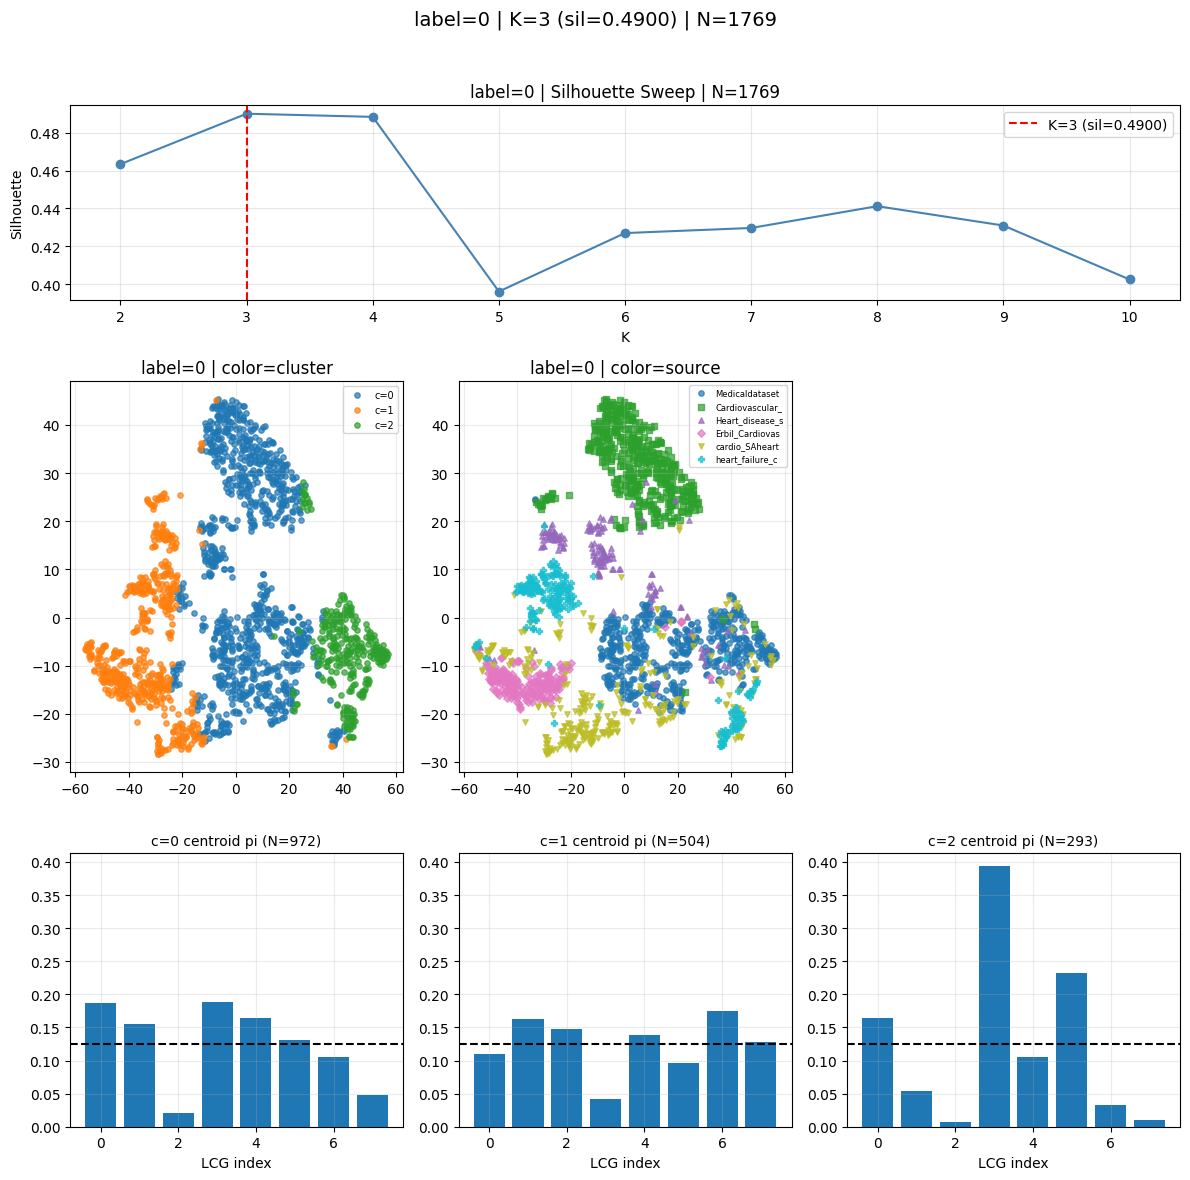


=== label=1 | N=1868 | K=2 | sil=0.6328 ===
  c=0 (N=855): {'Medicaldataset': 360, 'Cardiovascular_Disease_Dataset': 283, 'Heart_disease_statlog': 51, 'Erbil_Cardiovascular_Health_Dataset': 59, 'cardio_SAheart': 61, 'heart_failure_clinical_records': 41}
  c=1 (N=1013): {'Medicaldataset': 450, 'Cardiovascular_Disease_Dataset': 297, 'Heart_disease_statlog': 69, 'Erbil_Cardiovascular_Health_Dataset': 43, 'cardio_SAheart': 99, 'heart_failure_clinical_records': 55}


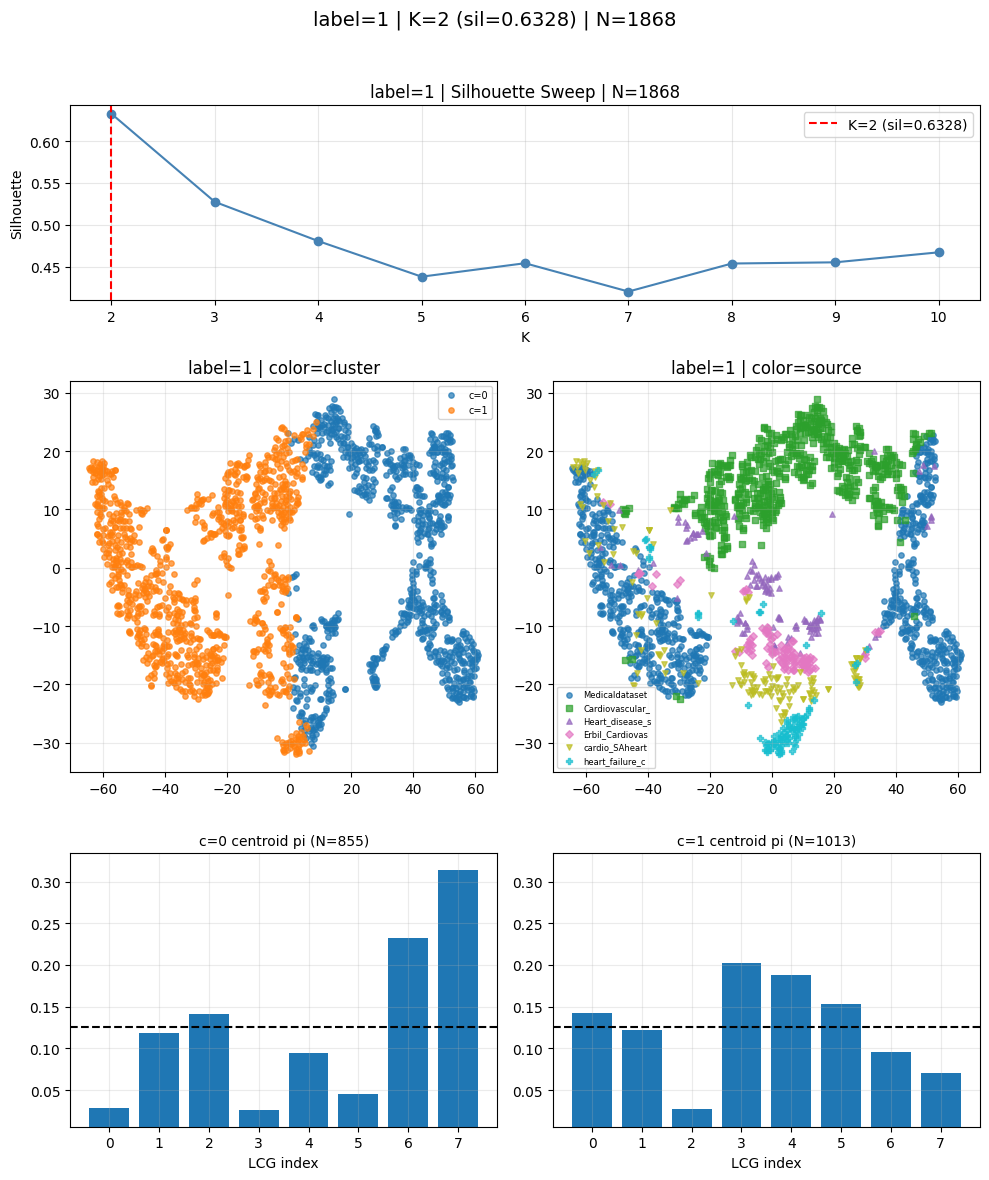

In [51]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


@torch.no_grad()
def collect_all_pi_with_meta(model, loaders, device):
    """모든 source에서 pi, y, source label 수집"""
    model.eval()
    model.args.use_lcg = True

    all_pis, all_ys, all_src = [], [], []
    src_names = []

    for src_idx, (src_name, loader) in enumerate(loaders.items()):
        src_names.append(src_name)
        for batch in loader:
            batch_t = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}
            _ = model.predict(batch_t, return_all=True)
            pi = model.graph_quantizer.last_pi
            B = pi.shape[0]
            all_pis.append(pi.detach().cpu().numpy())
            all_ys.append(batch_t['y'].detach().cpu().numpy().flatten())
            all_src.extend([src_idx] * B)

    pis = np.concatenate(all_pis, axis=0)
    ys = np.concatenate(all_ys, axis=0).astype(int)
    src_labels = np.array(all_src)
    print(f"Collected: {len(ys)} samples, M={pis.shape[1]}, Sources={len(src_names)}")
    return pis, ys, src_labels, src_names


def find_best_K(X, K_range=range(2, 11), seed=42):
    sil_scores = []
    valid_ks = []
    for k in K_range:
        if k >= len(X):
            break
        km = KMeans(n_clusters=k, random_state=seed, n_init=20).fit(X)
        sil = silhouette_score(X, km.labels_, metric='cosine')
        sil_scores.append(sil)
        valid_ks.append(k)
    best_k = valid_ks[np.argmax(sil_scores)]
    return best_k, list(zip(valid_ks, sil_scores))


def plot_pi_clusters_by_label(pis, ys, src_labels, src_names,
                               K="auto", K_range=range(2, 11), seed=42):
    M = pis.shape[1]
    src_markers = ['o', 's', '^', 'D', 'v', 'P', '*', 'X', 'h', '<']
    src_colors = plt.cm.tab10(np.linspace(0, 1, len(src_names)))

    for label in sorted(np.unique(ys)):
        mask = (ys == label)
        X = pis[mask]
        src_sub = src_labels[mask]
        n = len(X)

        # 실루엣 sweep
        if K == "auto":
            best_k, sil_scores = find_best_K(X, K_range=K_range, seed=seed)
            k_eff = best_k
        else:
            k_eff = min(K, n - 1)
            _, sil_scores = find_best_K(X, K_range=K_range, seed=seed)

        km = KMeans(n_clusters=k_eff, random_state=seed, n_init=20).fit(X)
        cid = km.labels_
        C = km.cluster_centers_
        best_sil = silhouette_score(X, cid, metric='cosine') if k_eff >= 2 else 0

        # t-SNE
        perp = max(5, min(40, (n - 1) // 3))
        xy = TSNE(n_components=2, perplexity=perp, learning_rate=200,
                  init="pca", random_state=seed).fit_transform(X)

        print(f"\n=== label={label} | N={n} | K={k_eff} | sil={best_sil:.4f} ===")
        for c in range(k_eff):
            c_mask = (cid == c)
            comp = {src_names[s]: int((c_mask & (src_sub == s)).sum())
                    for s in range(len(src_names)) if (c_mask & (src_sub == s)).sum() > 0}
            print(f"  c={c} (N={c_mask.sum()}): {comp}")

        # --- Plot: 3 rows ---
        # Row 0: silhouette sweep (full span)
        # Row 1: t-SNE (색=cluster, marker=source) + t-SNE (색=source)
        # Row 2: centroid pi bars
        fig = plt.figure(figsize=(max(4 * k_eff, 10), 12))
        gs = fig.add_gridspec(3, max(k_eff, 2), height_ratios=[0.5, 1, 0.7])

        # Row 0: silhouette
        ax = fig.add_subplot(gs[0, :])
        ks_plot = [s[0] for s in sil_scores]
        sils_plot = [s[1] for s in sil_scores]
        ax.plot(ks_plot, sils_plot, 'o-', color='steelblue')
        ax.axvline(x=k_eff, color='red', linestyle='--',
                   label=f'K={k_eff} (sil={best_sil:.4f})')
        ax.set_xlabel('K'); ax.set_ylabel('Silhouette')
        ax.set_title(f'label={label} | Silhouette Sweep | N={n}')
        ax.legend(); ax.grid(True, alpha=0.3)

        # Row 1 left: t-SNE colored by cluster
        ax = fig.add_subplot(gs[1, 0])
        for c in range(k_eff):
            c_mask = (cid == c)
            ax.scatter(xy[c_mask, 0], xy[c_mask, 1],
                       s=15, alpha=0.7, color=f"C{c % 10}", label=f"c={c}")
        ax.set_title(f"label={label} | color=cluster")
        ax.legend(fontsize=7); ax.grid(True, alpha=0.25)

        # Row 1 right: t-SNE colored by source
        if k_eff >= 2:
            ax = fig.add_subplot(gs[1, 1])
        else:
            ax = fig.add_subplot(gs[1, 0])  # 1열이면 겹침
        for s in range(len(src_names)):
            s_mask = (src_sub == s)
            if s_mask.sum() == 0:
                continue
            ax.scatter(xy[s_mask, 0], xy[s_mask, 1],
                       s=15, alpha=0.7, color=src_colors[s],
                       marker=src_markers[s % len(src_markers)],
                       label=src_names[s][:15])
        ax.set_title(f"label={label} | color=source")
        ax.legend(fontsize=6); ax.grid(True, alpha=0.25)

        # Row 2: centroid pi bars
        pi_ymin = max(0, float(C.min()) - 0.02)
        pi_ymax = float(C.max()) + 0.02
        for c in range(k_eff):
            ax = fig.add_subplot(gs[2, c])
            ax.bar(np.arange(M), C[c])
            ax.axhline(1.0 / M, linestyle="--", color="black")
            ax.set_ylim(pi_ymin, pi_ymax)
            ax.set_title(f"c={c} centroid pi (N={int((cid == c).sum())})", fontsize=10)
            ax.set_xlabel("LCG index")
            ax.grid(True, alpha=0.25)

        fig.suptitle(f"label={label} | K={k_eff} (sil={best_sil:.4f}) | N={n}", fontsize=14)
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()


# =========================================================
# 실행
# =========================================================
pis, ys, src_labels, src_names = collect_all_pi_with_meta(model, loaders, device)
plot_pi_clusters_by_label(pis, ys, src_labels, src_names, K="auto")

In [52]:
@torch.no_grad()
def collect_d_pi(model, loaders_by_src, device, max_batches=None):
    import torch.nn.functional as F
    model.eval()
    feat_distance = getattr(model.graph_quantizer.args, 'feat_distance', 'cosine')
    
    d_all, pi_all = [], []
    for src, loader in loaders_by_src.items():
        for bi, batch in enumerate(loader):
            if (max_batches is not None) and (bi >= max_batches):
                break
            batch = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}

            name_embeddings, value_embeddings = [], []
            if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
                name_embeddings.append(batch['cat_name_embeddings'])
                value_embeddings.append(batch['cat_value_embeddings'])
            if all(k in batch for k in ['num_prompt_embeddings', 'num_desc_embeddings']):
                name_embeddings.append(batch['num_name_embeddings'])
                value_embeddings.append(batch['num_prompt_embeddings'])

            name  = torch.cat(name_embeddings, dim=1)
            value = torch.cat(value_embeddings, dim=1)
            B, N, D = value.shape

            x_basis = torch.cat([model.basis_cls.expand(B, 1, model.input_dim), value], dim=1)
            last_att = None
            for l in range(model.num_basis_layers):
                norm_x = model.basis_layer_norms[l](x_basis)
                basis_outputs, att = model.basis_layers[l](name, norm_x)
                last_att = att
                x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)

            src_feat = x_basis[:, 1:, :].contiguous()
            var_att = last_att[:, 0, 1:, 1:]
            log_attn = -torch.log(var_att.clamp_min(1e-8))
            with torch.no_grad():
                q90 = torch.quantile(log_attn.flatten(), 0.9).clamp_min(1e-8)
            src_str = (log_attn / q90).clamp_max(1.0)

            lcg_feat, lcg_struct = model.latent_graph()
            M, K, _ = lcg_feat.shape

            src_feat_exp = src_feat.unsqueeze(1).expand(B, M, N, D).reshape(B*M, N, D)
            src_str_exp  = src_str.unsqueeze(1).expand(B, M, N, N).reshape(B*M, N, N)
            lcg_feat_exp = lcg_feat.unsqueeze(0).expand(B, M, K, D).reshape(B*M, K, D)
            lcg_str_exp  = lcg_struct.unsqueeze(0).expand(B, M, K, K).reshape(B*M, K, K)

            if feat_distance == 'cosine':
                src_norm = F.normalize(src_feat_exp, dim=-1)
                tgt_norm = F.normalize(lcg_feat_exp, dim=-1)
                cos_sim = torch.bmm(src_norm, tgt_norm.transpose(1, 2))
                M_cost = 1.0 - torch.exp(-(1.0 - cos_sim))
            else:
                dist_sq = torch.cdist(src_feat_exp, lcg_feat_exp, p=2) ** 2
                M_raw = dist_sq / float(D)
                q90 = torch.quantile(M_raw.detach().flatten(), 0.9).clamp_min(1e-8)
                M_cost = M_raw / q90

            a = torch.ones(B*M, N, device=device) / N
            b = torch.ones(B*M, K, device=device) / K
            alpha = float(model.graph_quantizer.alpha)
            reg   = float(model.graph_quantizer.reg)

            result = solve_gromov_batch(
                src_str_exp, lcg_str_exp, M=M_cost,
                alpha=alpha, reg=reg, a=a, b=b,
                max_iter=10, tol=1e-3, grad='envelope'
            )

            d = result.value.reshape(B, M)
            soft_tau = float(model.graph_quantizer.soft_tau)
            pi = torch.softmax(-d / soft_tau, dim=1)

            d_all.append(d.cpu().numpy())
            pi_all.append(pi.cpu().numpy())

    return np.concatenate(d_all, axis=0), np.concatenate(pi_all, axis=0)


[ALL_SOURCES:POOLED] N=3637, M=8
  H_sample_norm: mean=0.8596  (goal: LOW)
  H_batch_norm : 0.9899            (goal: HIGH)
  top1 prob    : mean=0.2890,  median=0.2509
  margin(top1-top2): mean=0.0855, median=0.0488
  mean(pi) deviation from uniform (L1): 0.1258
  argmax usage deviation from uniform (L1): 0.3990
  top4 coverage: min=0.2403, mean=0.5000, max=0.7459


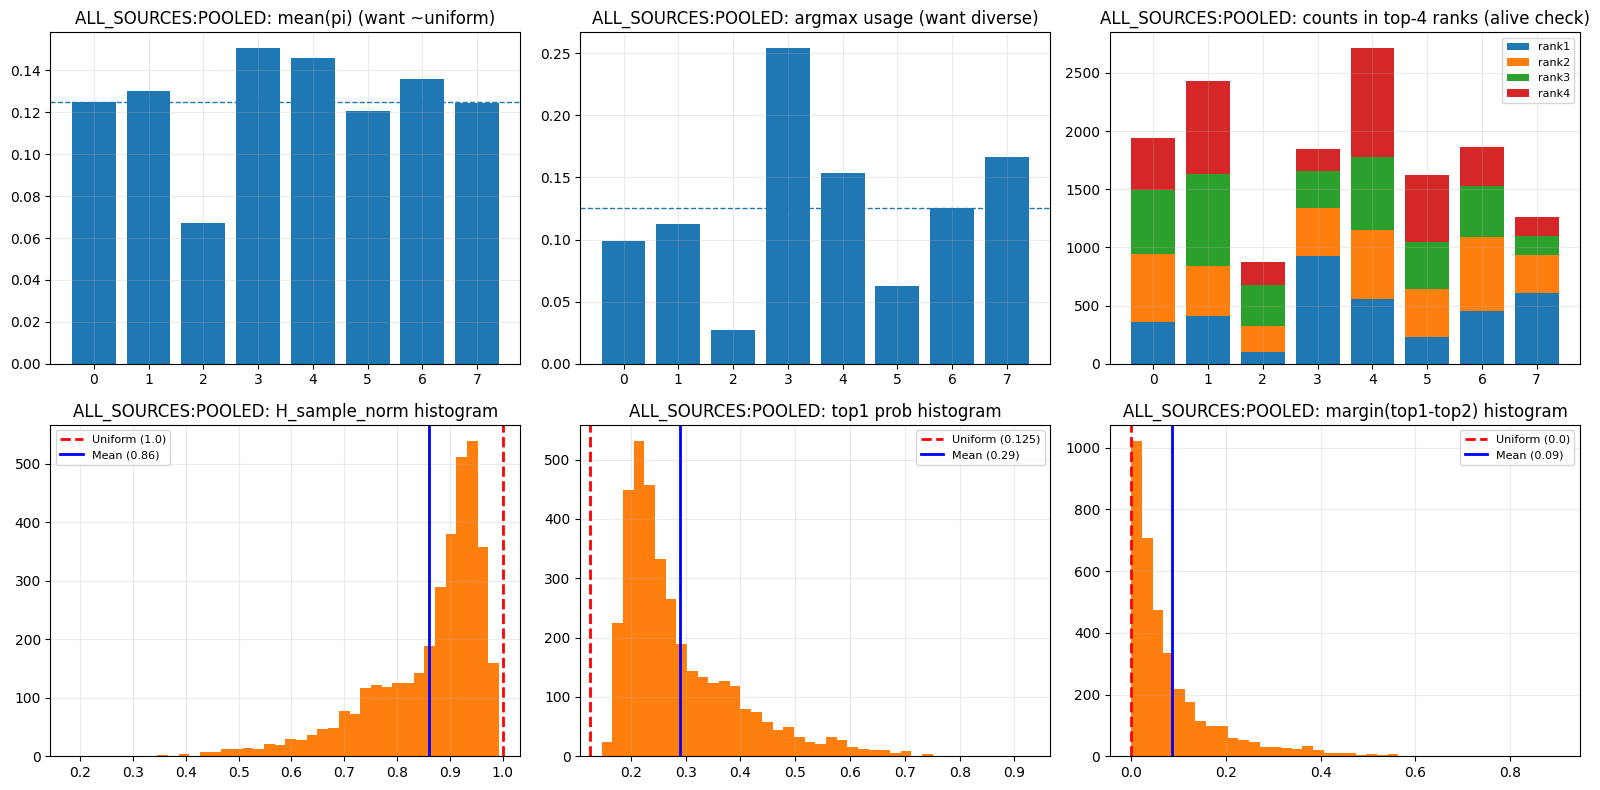


[SRC=Medicaldataset] N=1319, M=8
  H_sample_norm: mean=0.7927  (goal: LOW)
  H_batch_norm : 0.9731            (goal: HIGH)
  top1 prob    : mean=0.3347,  median=0.3142
  margin(top1-top2): mean=0.1108, median=0.0745
  mean(pi) deviation from uniform (L1): 0.2334
  argmax usage deviation from uniform (L1): 0.6740
  top4 coverage: min=0.2517, mean=0.5000, max=0.7945

[SRC=Cardiovascular_Disease_Dataset] N=1000, M=8
  H_sample_norm: mean=0.9038  (goal: LOW)
  H_batch_norm : 0.9648            (goal: HIGH)
  top1 prob    : mean=0.2605,  median=0.2311
  margin(top1-top2): mean=0.0719, median=0.0422
  mean(pi) deviation from uniform (L1): 0.2945
  argmax usage deviation from uniform (L1): 0.8500
  top4 coverage: min=0.0710, mean=0.5000, max=0.9400

[SRC=Heart_disease_statlog] N=270, M=8
  H_sample_norm: mean=0.9343  (goal: LOW)
  H_batch_norm : 0.9943            (goal: HIGH)
  top1 prob    : mean=0.2270,  median=0.2027
  margin(top1-top2): mean=0.0469, median=0.0281
  mean(pi) deviation from

In [53]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# -----------------------------
# 1) collect pi (all samples)
# -----------------------------
@torch.no_grad()
def collect_all_pi(model, loaders, device, max_batches_per_src=None):
    model.eval()
    model.args.use_lcg = True  # 체크포인트 로드 시 꺼져있을 수 있음
    out = {}
    all_pi = []

    for src, loader in loaders.items():
        pis = []
        for bi, batch in enumerate(loader):
            if max_batches_per_src is not None and bi >= max_batches_per_src:
                break
            batch_t = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}

            _ = model.predict(batch_t, return_all=True)
            pi = model.graph_quantizer.last_pi
            if pi is None:
                raise RuntimeError("last_pi is None")

            pis.append(pi.detach().cpu().numpy())

        if len(pis) == 0:
            continue
        pis = np.concatenate(pis, axis=0)
        out[src] = pis
        all_pi.append(pis)

    all_pi = np.concatenate(all_pi, axis=0) if len(all_pi) else None
    return out, all_pi


# -----------------------------
# 2) diagnostics
# -----------------------------
def _entropy_rows(P, eps=1e-12):
    P = np.clip(P, eps, 1.0)
    return -(P * np.log(P)).sum(axis=1)  # [N]

def _top1_top2(P):
    # returns top1 prob, top2 prob, margin
    part = np.partition(P, -2, axis=1)          # last two are top2 (unordered)
    top2 = part[:, -2]
    top1 = part[:, -1]
    # ensure top1>=top2 (partition doesn't guarantee order between last two)
    t1 = np.maximum(top1, top2)
    t2 = np.minimum(top1, top2)
    return t1, t2, (t1 - t2)

def _rank_hist(P, max_rank=4):
    # counts: for each m, how often it appears in rank r (1..max_rank)
    # rank 1 = argmax
    N, M = P.shape
    order = np.argsort(-P, axis=1)  # descending
    counts = np.zeros((max_rank, M), dtype=np.int64)
    for r in range(max_rank):
        idx_m = order[:, r]
        counts[r] = np.bincount(idx_m, minlength=M)
    return counts  # [max_rank, M]

def diagnose_pi(P, tag="POOLED", show=True):
    P = np.asarray(P)
    N, M = P.shape
    H_max = np.log(M)

    # --- entropies ---
    Hs = _entropy_rows(P)            # [N]
    Hs_norm = Hs / H_max
    pibar = P.mean(axis=0)
    Hb = -(np.clip(pibar, 1e-12, 1.0) * np.log(np.clip(pibar, 1e-12, 1.0))).sum()
    Hb_norm = Hb / H_max

    # --- usage / sharpness proxies ---
    argmax = P.argmax(axis=1)
    usage = np.bincount(argmax, minlength=M) / N  # [M]
    mean_pi = pibar
    t1, t2, margin = _top1_top2(P)

    # --- "dead but alive" check: rank counts ---
    rank_counts = _rank_hist(P, max_rank=4)  # [4, M] ranks 1..4

    # --- prints ---
    print(f"\n[{tag}] N={N}, M={M}")
    print(f"  H_sample_norm: mean={Hs_norm.mean():.4f}  (goal: LOW)")
    print(f"  H_batch_norm : {Hb_norm:.4f}            (goal: HIGH)")
    print(f"  top1 prob    : mean={t1.mean():.4f},  median={np.median(t1):.4f}")
    print(f"  margin(top1-top2): mean={margin.mean():.4f}, median={np.median(margin):.4f}")
    print(f"  mean(pi) deviation from uniform (L1): {np.abs(mean_pi - 1.0/M).sum():.4f}")
    print(f"  argmax usage deviation from uniform (L1): {np.abs(usage - 1.0/M).sum():.4f}")

    # rank-based "alive" quick view
    # 각 m이 rank<=4에 들어오는 비율
    top4_frac = rank_counts.sum(axis=0) / N
    print(f"  top4 coverage: min={top4_frac.min():.4f}, mean={top4_frac.mean():.4f}, max={top4_frac.max():.4f}")

    if not show:
        return

    # ---------------- plots ----------------
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))

    # (1) mean(pi) + argmax usage
    axes[0,0].bar(np.arange(M), mean_pi)
    axes[0,0].axhline(1.0/M, linestyle="--", linewidth=1)
    axes[0,0].set_title(f"{tag}: mean(pi) (want ~uniform)")
    axes[0,0].grid(True, alpha=0.25)

    axes[0,1].bar(np.arange(M), usage)
    axes[0,1].axhline(1.0/M, linestyle="--", linewidth=1)
    axes[0,1].set_title(f"{tag}: argmax usage (want diverse)")
    axes[0,1].grid(True, alpha=0.25)

    # (2) rank1~4 counts stacked (dead-but-alive 체크 핵심)
    # rank1=argmax, rank2, rank3, rank4
    bottoms = np.zeros(M, dtype=np.int64)
    labels = ["rank1", "rank2", "rank3", "rank4"]
    for r in range(4):
        axes[0,2].bar(np.arange(M), rank_counts[r], bottom=bottoms, label=labels[r])
        bottoms += rank_counts[r]
    axes[0,2].set_title(f"{tag}: counts in top-4 ranks (alive check)")
    axes[0,2].grid(True, alpha=0.25)
    axes[0,2].legend(fontsize=8, frameon=True)

    # (3) hist: sample entropy
    axes[1,0].hist(Hs_norm, bins=40)
    axes[1,0].set_title(f"{tag}: H_sample_norm histogram (want left)")
    axes[1,0].grid(True, alpha=0.25)

    # (4) hist: top1 prob
    axes[1,1].hist(t1, bins=40)
    axes[1,1].set_title(f"{tag}: top1 prob histogram (want right)")
    axes[1,1].grid(True, alpha=0.25)

    # (5) hist: margin
    axes[1,2].hist(margin, bins=40)
    axes[1,2].set_title(f"{tag}: margin(top1-top2) histogram (want right)")
    axes[1,2].grid(True, alpha=0.25)
    axes[1,0].hist(Hs_norm, bins=40)
    axes[1,0].axvline(x=1.0, color='red', linestyle='--', linewidth=2, label='Uniform (1.0)')
    axes[1,0].axvline(x=Hs_norm.mean(), color='blue', linestyle='-', linewidth=2, label=f'Mean ({Hs_norm.mean():.2f})')
    axes[1,0].set_title(f"{tag}: H_sample_norm histogram")
    axes[1,0].legend(fontsize=8)
    axes[1,0].grid(True, alpha=0.25)

    # (4) hist: top1 prob
    axes[1,1].hist(t1, bins=40)
    axes[1,1].axvline(x=1.0/M, color='red', linestyle='--', linewidth=2, label=f'Uniform ({1/M:.3f})')
    axes[1,1].axvline(x=t1.mean(), color='blue', linestyle='-', linewidth=2, label=f'Mean ({t1.mean():.2f})')
    axes[1,1].set_title(f"{tag}: top1 prob histogram")
    axes[1,1].legend(fontsize=8)
    axes[1,1].grid(True, alpha=0.25)

    # (5) hist: margin
    axes[1,2].hist(margin, bins=40)
    axes[1,2].axvline(x=0.0, color='red', linestyle='--', linewidth=2, label='Uniform (0.0)')
    axes[1,2].axvline(x=margin.mean(), color='blue', linestyle='-', linewidth=2, label=f'Mean ({margin.mean():.2f})')
    axes[1,2].set_title(f"{tag}: margin(top1-top2) histogram")
    axes[1,2].legend(fontsize=8)
    axes[1,2].grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()


# -----------------------------
# 3) run (pooled + per source)
# -----------------------------
pi_by_src, pi_all = collect_all_pi(model, loaders, device, max_batches_per_src=None)

diagnose_pi(pi_all, tag="ALL_SOURCES:POOLED", show=True)

for src, P in pi_by_src.items():
    diagnose_pi(P, tag=f"SRC={src}", show=False)  # source별은 출력만, 그림은 원하면 True로


- H_sample norm histogram (want left)
    - 각 샘플의 entropy H(pi)를 최대 엔트로피 log M으로 나누어 normalize
    - 0에 가까우면 거의 one hot이고 
    - 1에 가까우면 uniform 
    - 현재 막대가 0.98 ~ 1.0 에 몰려 있어서 sample entropy 낮게와는 정반대

- top1 prob histogram (want right)
    - 각 샘플에서 max_m pi_m 가장 큰 값의 분포 
    - flat이면 top 1이 1/M

- top1 - top2 histogram 
    - 각 샘플에서 (1등 확률 - 2등 확률) 차이 
    - 결정의 확신도 
    - 샤프하면 top1이 크고, top2가 작아서 margin이 크게 나옴 
    - 애매하면 top 1 ~ top 2여서 margin이 0 근처 
    - 현재 0 ~ 0.03 근처여서 top1과 top2가 거의 비슷함.

In [54]:
# @torch.no_grad()
# def visualize_orth_effect(model, device):
#     lcg_feat, lcg_struct = model.latent_graph()
#     M, K, D = lcg_feat.shape
    
#     # LCG centroid
#     centroids = lcg_feat.mean(dim=1)  # [M, D]
#     centroids_norm = F.normalize(centroids, dim=-1)
    
#     # Gram matrix (cosine similarity)
#     gram = (centroids_norm @ centroids_norm.t()).cpu().numpy()
    
#     fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
#     # (1) Gram matrix heatmap — 대각선만 1이고 나머지 0이면 완벽
#     im = axes[0].imshow(gram, cmap='RdBu_r', vmin=-1, vmax=1)
#     axes[0].set_title(f'LCG Centroid Cosine Similarity\n(Goal: Identity matrix)')
#     axes[0].set_xlabel('LCG Index')
#     axes[0].set_ylabel('LCG Index')
#     for i in range(M):
#         for j in range(M):
#             axes[0].text(j, i, f'{gram[i,j]:.2f}', ha='center', va='center', fontsize=7)
#     plt.colorbar(im, ax=axes[0])
    
#     # (2) Off-diagonal similarity 분포 — 0에 가까울수록 좋음
#     mask = ~np.eye(M, dtype=bool)
#     off_diag = gram[mask]
#     axes[1].hist(off_diag, bins=20, color='steelblue', alpha=0.7)
#     axes[1].axvline(x=0, color='red', linestyle='--', label='Ideal (0)')
#     axes[1].set_title(f'Off-diagonal Cosine Sim\nmean={off_diag.mean():.4f}, max={np.abs(off_diag).max():.4f}')
#     axes[1].set_xlabel('Cosine Similarity')
#     axes[1].legend()
    
#     # (3) LCG centroid L2 거리 — 클수록 좋음
#     l2_dist = torch.cdist(centroids.unsqueeze(0), centroids.unsqueeze(0)).squeeze(0).cpu().numpy()
#     off_diag_l2 = l2_dist[mask]
#     axes[2].hist(off_diag_l2, bins=20, color='coral', alpha=0.7)
#     axes[2].set_title(f'LCG Centroid L2 Distance\nmean={off_diag_l2.mean():.4f}, min={off_diag_l2.min():.4f}')
#     axes[2].set_xlabel('L2 Distance')
    
#     plt.tight_layout()
#     plt.show()
    
#     # Dead LCG 확인
#     print(f"\nOrth loss value: {(np.eye(M) - gram).__pow__(2).mean():.6f}")
#     print(f"Off-diag cosine sim: mean={off_diag.mean():.4f}, std={off_diag.std():.4f}")
#     print(f"L2 distance: mean={off_diag_l2.mean():.4f}, min={off_diag_l2.min():.4f}")

# visualize_orth_effect(model, device)

## Target Adaptation

### Target Model Loading

In [55]:
# target_rr_ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Few/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-0.3_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.01_description-XTFORMER_EVALUATION100/50/20260225_221853/Embed:carte_Edge:mlp_A:gat_v1_S:50_20260225_221853.pt"

# # checkpoint load
# ckpt = torch.load(target_rr_ckpt_path, map_location=device)
# args = ckpt['args']

# # 모델 초기화
# target_model = Model(
#     args,
#     args.input_dim,
#     args.hidden_dim,
#     args.output_dim,
#     args.dropout_rate,
#     args.llm_model,
#     experiment_id="viz",
#     mode="viz"
# ).to(device)

# sd = ckpt['model_state_dict']
# missing, unexpected = target_model.load_state_dict(sd, strict=False)
# print("Missing keys:", missing)
# print("Unexpected keys:", unexpected)

# target_model.eval()

### Target Datasaet Loading

In [56]:
# args2 = args
# fix_seed(args2.random_seed)

# # target_data가 리스트일 경우 여러 개
# target = args2.target_data if isinstance(args2.target_data, (list, tuple)) else [args2.target_data]

# loaders = {}
# for tgt in target:
#     print(f"Loading dataloader for source: {tgt}")
#     res = prepare_embedding_dataloaders(args2, tgt)
#     tr, va, te = res['loaders']
    
#     from torch.utils.data import ConcatDataset, DataLoader
#     ds = ConcatDataset([tr.dataset, va.dataset, te.dataset])
    
#     loaders[src] = DataLoader(ds, batch_size=32, shuffle=False)


In [57]:
# import torch.nn.functional as F

# target_model.eval()
# src_cls = {}

# with torch.no_grad():
#     for src_name, loader in loaders.items():
#         batch = next(iter(loader))
#         batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
        
#         name_embs, val_embs = [], []
#         if 'cat_name_embeddings' in batch: name_embs.append(batch['cat_name_embeddings'])
#         if 'num_name_embeddings' in batch: name_embs.append(batch['num_name_embeddings'])
#         if 'cat_value_embeddings' in batch: val_embs.append(batch['cat_value_embeddings'])
#         if 'num_prompt_embeddings' in batch: val_embs.append(batch['num_prompt_embeddings'])
        
#         name = torch.cat(name_embs, dim=1)
#         val = torch.cat(val_embs, dim=1)
#         x = torch.cat([target_model.basis_cls.expand(val.size(0), 1, target_model.input_dim), val], dim=1)
#         for l in range(target_model.num_basis_layers):
#             norm_x = target_model.basis_layer_norms[l](x)
#             out, _ = target_model.basis_layers[l](name, norm_x)
#             x = x + out.reshape(x.size(0), x.size(1), target_model.input_dim)
        
#         src_cls[src_name] = x[:, 0, :]
#         print(f"{src_name}: shape={x[:, 0, :].shape}")

# # Source 간 비교
# keys = list(src_cls.keys())
# print("\n=== Target cos_sim ===")
# for i in range(len(keys)):
#     for j in range(i+1, len(keys)):
#         cos = F.cosine_similarity(src_cls[keys[i]].mean(0, keepdim=True),
#                                    src_cls[keys[j]].mean(0, keepdim=True))
#         print(f"  {keys[i]} vs {keys[j]}: {cos.item():.4f}")

# # Source 내 샘플 간 비교
# print("\n=== Taret 내 intra cos_sim ===")
# for k in keys:
#     feat = src_cls[k]
#     sim = F.cosine_similarity(feat.unsqueeze(1), feat.unsqueeze(0), dim=2)
#     mask = ~torch.eye(feat.size(0), dtype=bool, device=feat.device)
#     print(f"  {k}: mean={sim[mask].mean():.4f}, min={sim[mask].min():.4f}, max={sim[mask].max():.4f}")

In [58]:
# # Source별 attention pattern 비교
# with torch.no_grad():
#     for src_name, loader in loaders.items():
#         batch = next(iter(loader))
#         batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
        
#         name_embs, val_embs = [], []
#         if 'cat_name_embeddings' in batch: name_embs.append(batch['cat_name_embeddings'])
#         if 'num_name_embeddings' in batch: name_embs.append(batch['num_name_embeddings'])
#         if 'cat_value_embeddings' in batch: val_embs.append(batch['cat_value_embeddings'])
#         if 'num_prompt_embeddings' in batch: val_embs.append(batch['num_prompt_embeddings'])
        
#         name = torch.cat(name_embs, dim=1)
#         val = torch.cat(val_embs, dim=1)
#         x = torch.cat([target_model.basis_cls.expand(val.size(0), 1, target_model.input_dim), val], dim=1)
#         for l in range(target_model.num_basis_layers):
#             norm_x = target_model.basis_layer_norms[l](x)
#             out, attn = target_model.basis_layers[l](name, norm_x)
#             x = x + out.reshape(x.size(0), x.size(1), target_model.input_dim)
        
#         # 마지막 layer의 attention
#         cs = -torch.log(attn.clamp_min(1e-8))  # 우리가 쓰는 CS
#         print(f"{src_name}: CS mean={cs.mean():.4f}, std={cs.std():.4f}, "
#               f"intra_sample_std={cs.std(dim=(1,2)).mean():.4f}")

### Target Coordinate

In [59]:
# """
# 전체 source의 pi를 모아서 t-SNE label scatter
# """

# # ============================================================
# # 1. 모든 source에서 pi, label, source name 수집
# # ============================================================
# all_pis_list = []
# all_ys_list = []
# all_tgt_names = []

# for tgt_name in target:
#     loader = loaders[tgt_name]
#     pis, ys, _, _, _ = collect_pi_and_affinity_for_one_source(
#         target_model, loader, device, extract_feature_names
#     )
#     all_pis_list.append(pis)
#     all_ys_list.append(ys)
#     all_tgt_names.extend([tgt_name] * len(ys))

# all_pis = np.concatenate(all_pis_list, axis=0)
# all_ys = np.concatenate(all_ys_list, axis=0)
# all_tgt_names = np.array(all_tgt_names)

# print(f"Total samples: {len(all_ys)}, Coordinate dim: {all_pis.shape[1]}")
# print(f"Label dist: {dict(zip(*np.unique(all_ys, return_counts=True)))}")

# # ============================================================
# # 2. t-SNE
# # ============================================================
# perp = max(5, min(40, (len(all_pis) - 1) // 3))
# xy = TSNE(n_components=2, perplexity=perp, random_state=42).fit_transform(all_pis)

# # ============================================================
# # 3. Scatter: color by label
# # ============================================================
# fig, ax = plt.subplots(1, 1, figsize=(8, 8))

# for label in [0, 1]:
#     mask = (all_ys == label)
#     ax.scatter(xy[mask, 0], xy[mask, 1], s=10, alpha=0.5,
#                label=f"label={label}", color=f"C{label}")

# ax.set_title("Pi space: label=0 vs label=1")
# ax.legend()
# ax.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()
# from sklearn.metrics import silhouette_score
# sil = silhouette_score(pis, ys)
# print(f"Silhouette (label): {sil:.4f}")

In [60]:
# data = extract_pi_and_labels(target_model, loaders, target, device)

# # 전체 합산 분석
# plot_mean_pi_by_label(data)
# plot_argmax_distribution_by_label(data)
# plot_pi_distribution_by_label(data)

# # ★ Source별 분석
# plot_per_source_grid(data)

In [61]:
# results_v2 = {}
# for tgt_name in target:
#     loader = loaders[tgt_name]
#     res = analyze_one_source_v2(
#         joint_model_pretrain, loader, device, tgt_name, extract_feature_names
#     )
#     results_v2[tgt_name] = res
    
#     # 전체에서 GT positive rate 기반으로 시각화
#     plot_subgroup_features_v2(res)
#     print_feature_risk_summary(res)

In [62]:
# all_pis_for_plot = []
# all_ys_for_plot = []

# target_model.eval()
# with torch.no_grad():
#     for tgt_name in target:
#         loader = loaders[tgt_name]
#         pis, ys, _, _, _ = collect_pi_and_affinity_for_one_source(
#             target_model, loader, device, extract_feature_names
#         )
#         all_pis_for_plot.append(pis)
#         all_ys_for_plot.append(ys)

# all_pis_for_plot = np.concatenate(all_pis_for_plot, axis=0)
# all_ys_for_plot = np.concatenate(all_ys_for_plot, axis=0).astype(int)

# # 전체
# plot_centroid_pi(result, label=None, pis_all=all_pis_for_plot, ys_all=all_ys_for_plot)

# # label별
# plot_centroid_pi(result, label=0, pis_all=all_pis_for_plot, ys_all=all_ys_for_plot)
# plot_centroid_pi(result, label=1, pis_all=all_pis_for_plot, ys_all=all_ys_for_plot)